In [123]:
import pandas as pd
import os

current_dir = os.path.abspath('.')
root_dir = os.path.dirname(current_dir) 
file_path = os.path.join(root_dir, 'data', 'creditcard_pret_ingestion.csv')
    
# Charger le CSV dans un DataFrame
df = pd.read_csv(file_path)
df_initial = df.copy()


In [124]:
df = df.set_index('ID')
print(df.columns.tolist())
initial_col=df.columns.tolist()

['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm']


In [125]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm
ID,,,,,,,,,,,,,,,,,,,,,
1,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
2,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## Les montants extrêmes

In [126]:
import pandas as pd
import numpy as np

# --- CONFIGURATION ---
THRESHOLD = 1_000_000
payment_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

# 1. FILTRAGE DES LIGNES
mask_large_payment = df[payment_columns].ge(THRESHOLD).any(axis=1)
df_large_payments = df[mask_large_payment].copy()

print(f"--- RÉSULTATS ---")
print(f"Nombre total de lignes avec au moins un paiement >= {THRESHOLD:,} : {len(df_large_payments)}")

if len(df_large_payments) == 0:
    print("Aucune ligne trouvée. Vérifie l'échelle de tes données.")
else:
    # 2. AFFICHAGE CLASSIQUE (sans .T)
    print(f"\n--- Exemple de 10 lignes (format classique) ---")
    
    # On peut limiter le nombre de colonnes affichées si le dataframe est très large
    # Sinon, pandas l'affichera tel quel
    print(df_large_payments.head(10))


--- RÉSULTATS ---
Nombre total de lignes avec au moins un paiement >= 1,000,000 : 4

--- Exemple de 10 lignes (format classique) ---
       LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_1  PAY_2  PAY_3  PAY_4  \
ID                                                                            
5297      500000    2          1         1   33     -2     -2     -1     -1   
25732      80000    2          3         1   37      0      0     -2     -2   
28004     510000    2          1         2   30     -1     -1     -1     -1   
28717     340000    2          1         3   42     -1     -1     -1     -1   

       PAY_5  ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  \
ID            ...                                                        
5297      -2  ...     121757      97115     377217      4366   1684259   
25732     -2  ...        632        632     124542       215   1024516   
28004      0  ...     163628     117475     116656    493358   1227082   
28717     -1  ...     

Les paiements de +1M semblent incohérents avec leur contexte, les cartes voient leur plafond exploser.  
Même si ces 4 lignes seront un bruit imperceptibles pour les modèles, les répartitions et stats sont complètement déformées par ces anomalies.  
En terme de métier, il n'est pas impossible de dépasser le plafond maximum d'une carte de crédit d'un certain pourcentage, mais ici, on parle de plusieurs fois le plafond autorisé

In [127]:
import pandas as pd
import numpy as np

# --- CONFIGURATION ---
THRESHOLD = 500000
payment_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

# 1. FILTRAGE DES LIGNES
mask_large_payment = df[payment_columns].ge(THRESHOLD).any(axis=1)
df_large_payments = df[mask_large_payment].copy()

print(f"--- RÉSULTATS ---")
print(f"Nombre total de lignes avec au moins un paiement >= {THRESHOLD:,} : {len(df_large_payments)}")

if len(df_large_payments) == 0:
    print("Aucune ligne trouvée. Vérifie l'échelle de tes données.")
else:
    # 2. AFFICHAGE CLASSIQUE (sans .T)
    print(f"\n--- Exemple de 10 lignes (format classique) ---")
    
    # On peut limiter le nombre de colonnes affichées si le dataframe est très large
    # Sinon, pandas l'affichera tel quel
    print(df_large_payments.head(10))


--- RÉSULTATS ---
Nombre total de lignes avec au moins un paiement >= 500,000 : 11

--- Exemple de 10 lignes (format classique) ---
       LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_1  PAY_2  PAY_3  PAY_4  \
ID                                                                            
507       500000    2          2         2   43     -1     -1     -1      0   
2198     1000000    2          1         1   47      0      0      0     -1   
5297      500000    2          1         1   33     -2     -2     -1     -1   
12331     300000    1          2         1   37      1     -1      2      0   
14512     500000    1          1         2   30     -1     -1     -1      0   
14514     460000    2          1         1   43     -2     -2     -1      0   
24687     730000    1          2         1   37      0      0      0      0   
25732      80000    2          3         1   37      0      0     -2     -2   
27441     500000    1          1         1   35      2      0      0     -1   

Pour les paiements à +500 000 NT$, le constat est plus mitigé pour les lignes entre 500 00 et 1 000 000
**=> les montants de +1M nT$ ressemblent fortement à des anomalies, je supprime ces 4 lignes

In [128]:
import pandas as pd
import numpy as np

# 1. Définition des colonnes à filtrer
cols_pay = [f'PAY_AMT{i}' for i in range(1, 7)]
# Filtrer pour ne garder que celles qui existent dans le dataframe
cols_presentes = [c for c in cols_pay if c in df.columns]

if len(cols_presentes) > 0:
    # Seuil de suppression
    seuil_suppression = 1_000_000
    
    # 2. Identification des lignes à supprimer
    # On crée un masque qui est True si AU MOINS une colonne PAY_AMT dépasse le seuil
    is_outlier = False
    for col in cols_presentes:
        is_outlier = is_outlier | (df[col] > seuil_suppression)
        
    nb_lignes_avant = len(df)
    
    # 3. Suppression
    df_cleaned = df[~is_outlier].copy()
    nb_lignes_apres = len(df_cleaned)
    nb_supprimees = nb_lignes_avant - nb_lignes_apres
    
    print(f"--- Nettoyage des Paiements Anormaux (> 1M) ---")
    print(f"Lignes avant : {nb_lignes_avant}")
    print(f"Lignes supprimées : {nb_supprimees} ({(nb_supprimees/nb_lignes_avant)*100:.2f}%)")
    print(f"Lignes restantes : {nb_lignes_apres}")

    # Affichage des colonnes concernées pour vérifier qu'elles ont bien été nettoyées
    print("\nValeurs max par colonne PAY_AMT après nettoyage :")
    for col in cols_presentes:
        if col in df_cleaned.columns:
            print(f"{col}: {df_cleaned[col].max()}")

else:
    print("Aucune colonne PAY_AMT trouvée.")

df = df_cleaned

--- Nettoyage des Paiements Anormaux (> 1M) ---
Lignes avant : 30000
Lignes supprimées : 4 (0.01%)
Lignes restantes : 29996

Valeurs max par colonne PAY_AMT après nettoyage :
PAY_AMT1: 505000
PAY_AMT2: 580464
PAY_AMT3: 896040
PAY_AMT4: 528897
PAY_AMT5: 426529
PAY_AMT6: 528666


In [129]:
import pandas as pd

# 1. Définir les colonnes de montants payés
cols_paiements = [f'PAY_AMT{i}' for i in range(1, 7)]

# 2. Calculer le seuil : 2.1 fois la LIMIT_BAL pour chaque ligne (chaque client)
seuil_ridicule = df['LIMIT_BAL'] * 2.1

# 3. Créer un mask booléen : True si au moins un paiement dépasse ce seuil
# axis=1 signifie "par ligne"
mask_lignes_incohérentes = df[cols_paiements].ge(seuil_ridicule, axis=0).any(axis=1)

# 4. Extraire et compter ces lignes
lignes_incohérentes = df[mask_lignes_incohérentes]
nombre_lignes_incohérentes = len(lignes_incohérentes)

print(f"Nombre de lignes potentiellement incohérentes pour une limite à 2.1 x le plafond: {nombre_lignes_incohérentes}")

# 5. Visualisation rapide pour vérifier les valeurs
if nombre_lignes_incohérentes > 0:
    # On affiche les clients problématiques avec leurs montants pour inspection
    display(lignes_incohérentes[['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm']].head())
    
    # 2. Calculer le seuil : 2.1 fois la LIMIT_BAL pour chaque ligne (chaque client)
seuil_ridicule = df['LIMIT_BAL'] * 1.2

# 3. Créer un mask booléen : True si au moins un paiement dépasse ce seuil
# axis=1 signifie "par ligne"
mask_lignes_incohérentes = df[cols_paiements].ge(seuil_ridicule, axis=0).any(axis=1)

# 4. Extraire et compter ces lignes
lignes_incohérentes = df[mask_lignes_incohérentes]
nombre_lignes_incohérentes = len(lignes_incohérentes)

print(f"Nombre de lignes potentiellement incohérentes pour une limite à 1.2 x le plafond: {nombre_lignes_incohérentes}")

# 5. Visualisation rapide pour vérifier les valeurs
if nombre_lignes_incohérentes > 0:
    # On affiche les clients problématiques avec leurs montants pour inspection
    display(lignes_incohérentes[['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm']].head())
    
    # 2. Calculer le seuil : 2.1 fois la LIMIT_BAL pour chaque ligne (chaque client)
seuil_ridicule = df['LIMIT_BAL'] * 5

# 3. Créer un mask booléen : True si au moins un paiement dépasse ce seuil
# axis=1 signifie "par ligne"
mask_lignes_incohérentes = df[cols_paiements].ge(seuil_ridicule, axis=0).any(axis=1)

# 4. Extraire et compter ces lignes
lignes_incohérentes = df[mask_lignes_incohérentes]
nombre_lignes_incohérentes = len(lignes_incohérentes)

print(f"Nombre de lignes potentiellement incohérentes pour une limite à 5 x le plafond: {nombre_lignes_incohérentes}")

# 5. Visualisation rapide pour vérifier les valeurs
if nombre_lignes_incohérentes > 0:
    # On affiche les clients problématiques avec leurs montants pour inspection
    display(lignes_incohérentes[['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm']].head())

Nombre de lignes potentiellement incohérentes pour une limite à 2.1 x le plafond: 12


,LIMIT_BAL,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm
ID,,,,,,,,,,,,,,
3554,40000,32228,38904,4235,87230,72647,65070,8040,4235,87230,3000,10000,4317,0
5844,10000,885,1475,780,390,780,390,1475,780,0,31250,0,0,0
7419,20000,-1213,30322,20033,19871,15410,18969,52082,15800,2000,20085,39070,25000,0
7640,20000,-739,-5978,16089,14457,20106,10258,0,42400,289,201,410,0,1
7667,20000,34213,30100,25871,21970,18669,19669,0,0,0,0,1000,53301,1


Nombre de lignes potentiellement incohérentes pour une limite à 1.2 x le plafond: 78


,LIMIT_BAL,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm
ID,,,,,,,,,,,,,,
291,280000,898,898,325,898,325,-339603,898,325,898,325,0,345293,1
991,50000,58300,59727,142,29886,30510,31276,7876,161,74354,927,1089,9100,0
1740,20000,15789,21698,21054,20355,19980,3470,6500,0,0,10000,25065,177,0
1844,20000,18803,18376,19342,19081,19799,18718,36147,1281,658,1000,1000,760,1
3184,260000,200716,203751,205530,-170000,171696,174151,8812,9158,0,497000,10000,7000,0


Nombre de lignes potentiellement incohérentes pour une limite à 5 x le plafond: 0


In [130]:
import pandas as pd

# 1. Définition des colonnes concernées
cols_bill = [f'BILL_AMT{i}' for i in range(1, 7)]
col_plafond = 'LIMIT_BAL'

# Filtrer pour ne garder que les colonnes présentes dans le dataframe
cols_presentes = [c for c in cols_bill if c in df.columns]

if col_plafond not in df.columns:
    print(f"Attention : La colonne '{col_plafond}' est manquante.")
elif len(cols_presentes) == 0:
    print(f"Attention : Aucune colonne BILL_AMT trouvée.")
else:
    # 2. Calcul du seuil par ligne (2.1 * LIMIT_BAL)
    # On filtre d'abord les plafonds valides (> 0) pour éviter les divisions/errements logiques
    df_valide = df[df[col_plafond] > 0].copy()
    
    if len(df_valide) == 0:
        print("Aucune limite de crédit valide trouvée.")
    else:
        # On identifie les lignes où AU MOINS UN des BILL_AMT dépasse le seuil
        is_outlier = False
        for col in cols_presentes:
            # Condition : Valeur > 2.1 * LIMIT_BAL
            is_outlier = is_outlier | (df_valide[col] > (2.1 * df_valide[col_plafond]))
        
        # On ajoute la colonne 'Is_Outlier' au dataframe pour analyse détaillée si besoin
        df_valide['Depasse_Plafond_X2.1'] = is_outlier
        
        # 3. Comptage
        nb_lignes_totales = len(df)
        nb_depassements = is_outlier.sum()
        
        print(f"--- Analyse de Dépassement de Plafond ---")
        print(f"Total lignes dans le dataset : {nb_lignes_totales}")
        print(f"Lignes avec AU MOINS un BILL_AMT > 2.1 * LIMIT_BAL : {nb_depassements}")
        
        if nb_lignes_totales > 0:
            pourcentage = (nb_depassements / nb_lignes_totales) * 100
            print(f"Pourcentage de la population concernée : {pourcentage:.2f}%")

    # Optionnel : Afficher un échantillon des cas extrêmes pour vérifier leur nature
    if nb_depassements > 0:
        df_extremes = df_valide[(df_valide['Depasse_Plafond_X2.1'])].head(10)
        print("\nExemple de lignes dépassant le seuil (10 premiers cas) :")
        print(df_extremes.to_string())

--- Analyse de Dépassement de Plafond ---
Total lignes dans le dataset : 29996
Lignes avec AU MOINS un BILL_AMT > 2.1 * LIMIT_BAL : 40
Pourcentage de la population concernée : 0.13%

Exemple de lignes dépassant le seuil (10 premiers cas) :
      LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_1  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  dpnm  Depasse_Plafond_X2.1
ID                                                                                                                                                                                                                                                
671       30000    2          2         2   34      2     -1      2      2      2      2      99568      32326      31840      37075      37662      36904     33000     33000      5810      1325         0      3095     0                  True
969       20000    2          2

Dans le domaine des crédits renouvelables, il est rare de dépasser son plafond de plus de 100% mais c'est possible. Ce qui est compliqué, c'est de dépasser 120% du plafond.  Les valeurs supérieures à cette limite sont probablement erronnées.  
Cependant dans ce dataset, on voit des clients payer en avance, des décalages de comptabilisation dans les paiements, des clients qui remboursent intégralement leur carte chaque mois ; alors la limite de 120% (dépassée pour 78 clients) devient sévère.  
Fixer une limite raisonnable à 2 fois la limite en ajoutant une petite marge sécurise sur le nettoyage et garantit de vraiment éliminer les lignes contenant des erreurs de type (montant compté x 100, montants saisis plusieurs fois par erreur).  La seule explication à ceci serait un abaissement du plafond sur la période mais il est impossible d'avoir la moindre information sur la temporalité de ce montant maximum autorisé.  
L'analyse des lignes ne montre pas d'aberrations dans les montants
Si j'applique le même filtre sur les encours et que j'observe un échantillon de quelques lignes, je ne détecte pas d'anormalité de comportement dans les paiements et les encours utilisés, on remarque en effet une envolée de l'encours mais rien n'indique une erreur de montant. Supprimer ces lignes de fort dépassement du plafong supprimerait une catégorie de clients non justifiée ici.  
La raison la plus probable ici semble être une baisse du plafond autorisé.  
=> **je ne nettoie pas ces lignes qui ne présentent pas suffisamment d'anomalies**

## Les codifications face aux factures et aux paiements

Lecture des colonnes établie dans l'audit ([01_01_audit.ipynb](01_01_audit.ipynb), partie « Temporalité des colonnes ») : `PAY_n` juge **la facture de fin du mois n** (`BILL_AMTn`) **sur le paiement fait le mois suivant** (`PAY_AMT(n-1)`). `PAY_1` porte sur la facture de fin septembre, réglée par un paiement d'octobre absent du dataset : pour septembre, seule la facture est connue.

In [131]:
# Créer la liste des colonnes à analyser
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

print("=== ANALYSE DES RETARDS DE PAIEMENT ===")

# Analyser chaque colonne de paiement
results = {}
total_records = len(df)

for col in pay_columns:
    # Compter les valeurs strictement inférieures à -1
    count_less_than_neg1 = (df[col] < -1).sum()
    percentage_less_than_neg1 = (count_less_than_neg1 / total_records) * 100
    
    # Compter les valeurs égales à 0
    count_zeros = (df[col] == 0).sum()
    percentage_zeros = (count_zeros / total_records) * 100
    
    # Statistiques générales
    min_val = df[col].min()
    max_val = df[col].max()
    mean_val = df[col].mean()
    
    results[col] = {
        'count_less_than_neg1': count_less_than_neg1,
        'percentage_less_than_neg1': percentage_less_than_neg1,
        'count_zeros': count_zeros,
        'percentage_zeros': percentage_zeros,
        'min': min_val,
        'max': max_val,
        'mean': mean_val
    }
    
    print(f"\n{col}:")
    print(f"  - Nombre de valeurs < -1: {count_less_than_neg1}")
    print(f"  - Pourcentage < -1: {percentage_less_than_neg1:.2f}%")
    print(f"  - Nombre de valeurs = 0: {count_zeros}")
    print(f"  - Pourcentage = 0: {percentage_zeros:.2f}%")
    print(f"  - Valeur minimale: {min_val}")
    print(f"  - Valeur maximale: {max_val}")
    print(f"  - Moyenne: {mean_val:.2f}")
    
    # Afficher quelques exemples de valeurs < -1
    if count_less_than_neg1 > 0:
        negative_values = df[df[col] < -1][col].head()
        print(f"  - Exemples (< -1): {negative_values.tolist()}")

print("\n=== ANALYSE SPÉCIFIQUE ===")
print("Nombre de valeurs strictement inférieures à -1 dans chaque colonne :")

total_negative = 0
total_zeros = 0

for col in pay_columns:
    count_negative = (df[col] < -1).sum()
    count_zero = (df[col] == 0).sum()
    
    total_negative += count_negative
    total_zeros += count_zero
    
    print(f"  {col}: {count_negative} valeurs < -1, {count_zero} valeurs = 0")

print(f"\nTotal de toutes les valeurs < -1: {total_negative}")
print(f"Total de toutes les valeurs = 0: {total_zeros}")
    

=== ANALYSE DES RETARDS DE PAIEMENT ===

PAY_1:
  - Nombre de valeurs < -1: 2758
  - Pourcentage < -1: 9.19%
  - Nombre de valeurs = 0: 14736
  - Pourcentage = 0: 49.13%
  - Valeur minimale: -2
  - Valeur maximale: 8
  - Moyenne: -0.02
  - Exemples (< -1): [-2, -2, -2, -2, -2]

PAY_2:
  - Nombre de valeurs < -1: 3781
  - Pourcentage < -1: 12.61%
  - Nombre de valeurs = 0: 15729
  - Pourcentage = 0: 52.44%
  - Valeur minimale: -2
  - Valeur maximale: 8
  - Moyenne: -0.13
  - Exemples (< -1): [-2, -2, -2, -2, -2]

PAY_3:
  - Nombre de valeurs < -1: 4084
  - Pourcentage < -1: 13.62%
  - Nombre de valeurs = 0: 15764
  - Pourcentage = 0: 52.55%
  - Valeur minimale: -2
  - Valeur maximale: 8
  - Moyenne: -0.17
  - Exemples (< -1): [-2, -2, -2, -2, -2]

PAY_4:
  - Nombre de valeurs < -1: 4347
  - Pourcentage < -1: 14.49%
  - Nombre de valeurs = 0: 16455
  - Pourcentage = 0: 54.86%
  - Valeur minimale: -2
  - Valeur maximale: 8
  - Moyenne: -0.22
  - Exemples (< -1): [-2, -2, -2, -2, -2]

PAY_

In [132]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
# Compter le nombre de lignes avec uniquement des -2
count_all_neg2 = df[pay_columns].eq(-2).all(axis=1).sum()
print(f"Nombre de lignes contenant uniquement des -2 : {count_all_neg2}")

Nombre de lignes contenant uniquement des -2 : 2109


In [133]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
# Compter le nombre de lignes avec au moins un -2
count_at_least_one_neg2 = df[pay_columns].eq(-2).any(axis=1).sum()
print(f"Nombre de lignes contenant au moins un -2 : {count_at_least_one_neg2}")

Nombre de lignes contenant au moins un -2 : 6559


In [134]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
# Compter le nombre de lignes avec uniquement des -2
count_all_neg1 = df[pay_columns].eq(-1).all(axis=1).sum()
print(f"Nombre de lignes contenant uniquement des -1 : {count_all_neg1}")

Nombre de lignes contenant uniquement des -1 : 1992


In [135]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
# Compter le nombre de lignes avec au moins un -1
count_at_least_one_neg1 = df[pay_columns].eq(-1).any(axis=1).sum()
print(f"Nombre de lignes contenant au moins un -1 : {count_at_least_one_neg1}")

Nombre de lignes contenant au moins un -1 : 10224


In [136]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
# Compter le nombre de lignes avec uniquement des -2
count_all_0 = df[pay_columns].eq(0).all(axis=1).sum()
print(f"Nombre de lignes contenant uniquement des 0 : {count_all_0}")

Nombre de lignes contenant uniquement des 0 : 9821


In [137]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
# Compter le nombre de lignes avec au moins un -2
count_at_least_one_0 = df[pay_columns].eq(0).any(axis=1).sum()
print(f"Nombre de lignes contenant au moins un 0 : {count_at_least_one_0}")

Nombre de lignes contenant au moins un 0 : 21170


In [138]:
# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

print("=== RÉPARTITION DES VALEURS DANS LES COLONNES PAY_N ===")

# Calcul de la répartition pour chaque colonne
for col in pay_columns:
    print(f"\n--- {col} ---")
    value_counts = df[col].value_counts().sort_index()
    
    for value, count in value_counts.items():
        percentage = (count / len(df)) * 100
        print(f"  - Valeur {value} : {count} sur {len(df)} ({percentage:.2f}%)")

print(f"\n=== RÉPARTITION CUMULÉE DE TOUTES LES COLONNES PAY_N ===")

# Répartition cumulative de toutes les valeurs
all_values = []
value_counts_cumul = {}

for col in pay_columns:
    values = df[col].value_counts()
    for value, count in values.items():
        if value not in value_counts_cumul:
            value_counts_cumul[value] = 0
        value_counts_cumul[value] += count

# Afficher la répartition cumulative
total_rows = len(df)
for value in sorted(value_counts_cumul.keys()):
    percentage = (value_counts_cumul[value] / total_rows) * 100 /6
    print(f"  - Valeur {value} : {value_counts_cumul[value]} sur {total_rows} ({percentage:.2f}%)")

=== RÉPARTITION DES VALEURS DANS LES COLONNES PAY_N ===

--- PAY_1 ---
  - Valeur -2 : 2758 sur 29996 (9.19%)
  - Valeur -1 : 5684 sur 29996 (18.95%)
  - Valeur 0 : 14736 sur 29996 (49.13%)
  - Valeur 1 : 3688 sur 29996 (12.29%)
  - Valeur 2 : 2667 sur 29996 (8.89%)
  - Valeur 3 : 322 sur 29996 (1.07%)
  - Valeur 4 : 76 sur 29996 (0.25%)
  - Valeur 5 : 26 sur 29996 (0.09%)
  - Valeur 6 : 11 sur 29996 (0.04%)
  - Valeur 7 : 9 sur 29996 (0.03%)
  - Valeur 8 : 19 sur 29996 (0.06%)

--- PAY_2 ---
  - Valeur -2 : 3781 sur 29996 (12.61%)
  - Valeur -1 : 6048 sur 29996 (20.16%)
  - Valeur 0 : 15729 sur 29996 (52.44%)
  - Valeur 1 : 28 sur 29996 (0.09%)
  - Valeur 2 : 3927 sur 29996 (13.09%)
  - Valeur 3 : 326 sur 29996 (1.09%)
  - Valeur 4 : 99 sur 29996 (0.33%)
  - Valeur 5 : 25 sur 29996 (0.08%)
  - Valeur 6 : 12 sur 29996 (0.04%)
  - Valeur 7 : 20 sur 29996 (0.07%)
  - Valeur 8 : 1 sur 29996 (0.00%)

--- PAY_3 ---
  - Valeur -2 : 4084 sur 29996 (13.62%)
  - Valeur -1 : 5935 sur 29996 (19.7

=== HISTOGRAMMES DES VALEURS PAY_N ===


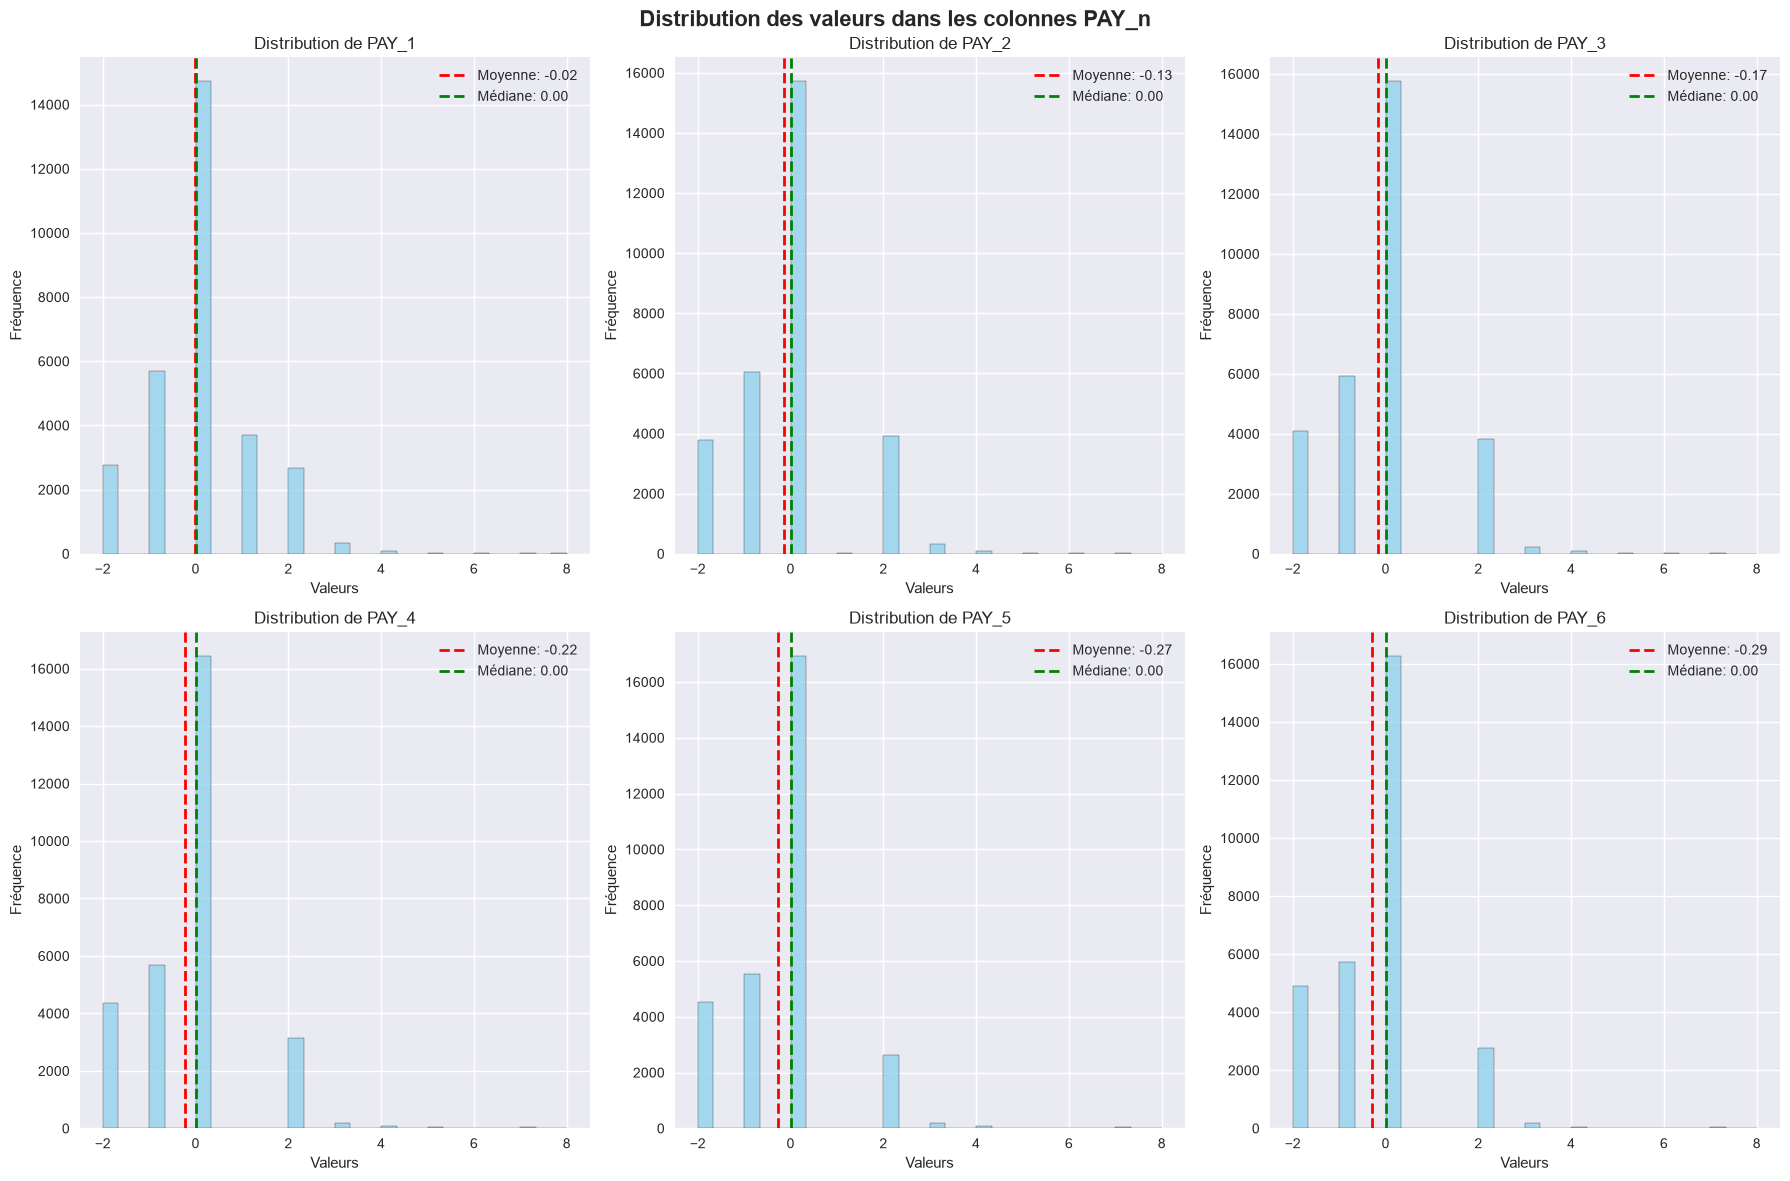


=== HISTOGRAMME CUMULÉ ===


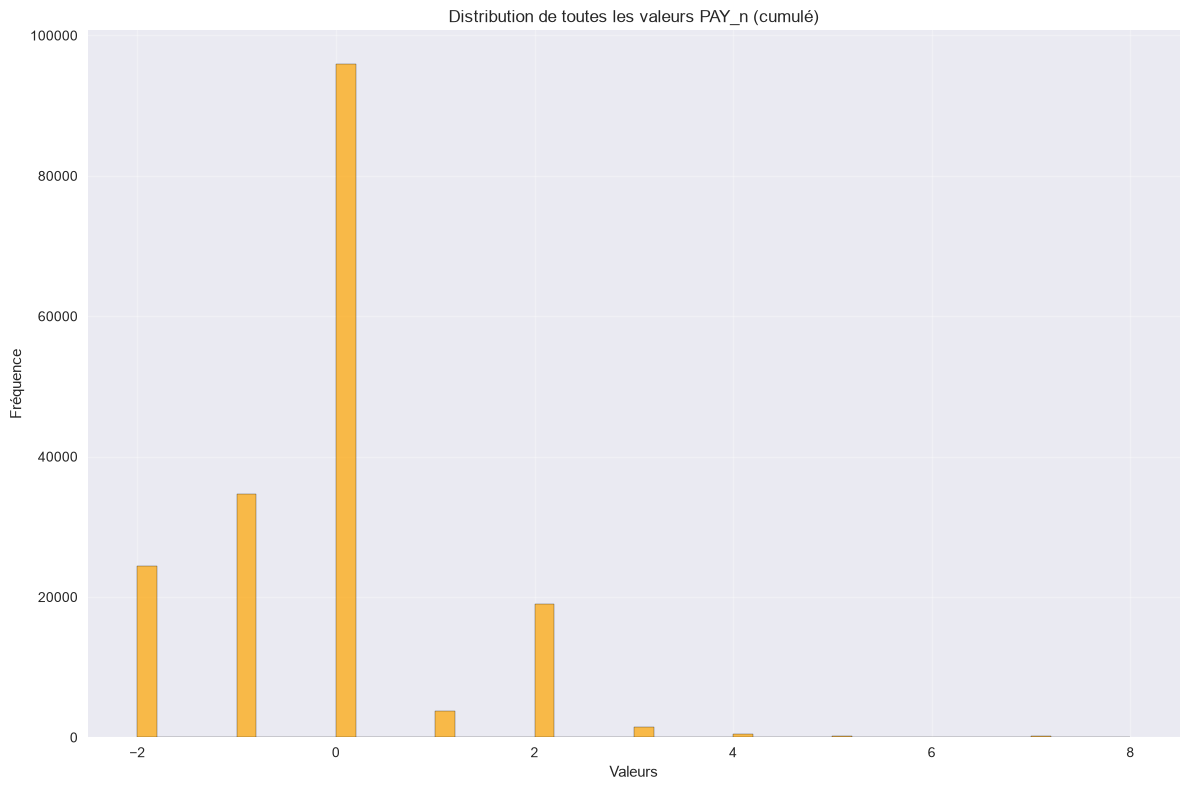

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

print("=== HISTOGRAMMES DES VALEURS PAY_N ===")

# Configuration du style
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Distribution des valeurs dans les colonnes PAY_n', fontsize=16, fontweight='bold')

# Création des histogrammes pour chaque colonne
for i, col in enumerate(pay_columns):
    row = i // 3
    col_idx = i % 3
    
    # Filtrer les valeurs non nulles pour l'histogramme
    data = df[col].dropna()
    
    axes[row, col_idx].hist(data, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[row, col_idx].set_title(f'Distribution de {col}')
    axes[row, col_idx].set_xlabel('Valeurs')
    axes[row, col_idx].set_ylabel('Fréquence')
    
    # Ajout des statistiques
    mean_val = data.mean()
    median_val = data.median()
    axes[row, col_idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                              label=f'Moyenne: {mean_val:.2f}')
    axes[row, col_idx].axvline(median_val, color='green', linestyle='--', linewidth=2, 
                              label=f'Médiane: {median_val:.2f}')
    axes[row, col_idx].legend()

# Cacher l'axe vide si nécessaire
if len(pay_columns) < 6:
    axes[1, 2].set_visible(False)

plt.tight_layout()
plt.show()

print("\n=== HISTOGRAMME CUMULÉ ===")
# Histogramme cumulé de toutes les colonnes - CORRECTION
fig, ax = plt.subplots(figsize=(12, 8))

# Rassembler toutes les valeurs (pas de cumulative=True)
all_values = []
for col in pay_columns:
    all_values.extend(df[col].dropna())

# Créer l'histogramme standard avec toutes les données
ax.hist(all_values, bins=50, alpha=0.7, color='orange', edgecolor='black')
ax.set_title('Distribution de toutes les valeurs PAY_n (cumulé)')
ax.set_xlabel('Valeurs')
ax.set_ylabel('Fréquence')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Approche de compréhension**  
Je cherche à comprendre à quoi correspondent les valeurs '-2', '-1' et '0' des colonnes 'PAY_n'.  
Ces 3 valeurs signifient-elles la même chose ? Représentent-elles des retards mal saisis ?  
Selon la documentation du dataset, '-1' signifie client à jour et des entiers positifs représentent le nombre de mois de retard de paiement  
Je regarde pour ces 3 valeurs à quoi cela peut correspondre en terme de paiements et d'encours

In [140]:
import numpy as np
import pandas as pd

# PAY_n va avec la facture BILL_AMTn et le paiement du mois suivant PAY_AMT(n-1) (pas de paiement connu pour PAY_1)
MOIS = {1: 'septembre', 2: 'août', 3: 'juillet', 4: 'juin', 5: 'mai', 6: 'avril'}
CODIFS = {'-2': lambda p: p == -2, '-1': lambda p: p == -1, '0': lambda p: p == 0, '2 et plus': lambda p: p >= 2}

lignes = []
for n in range(1, 7):
    for nom, test in CODIFS.items():
        m = test(df[f'PAY_{n}'])
        lignes.append({'Mois': f'{MOIS[n]} (PAY_{n})', 'Codification': nom, 'Clients': int(m.sum()),
                       'Facture moyenne du mois (BILL_AMTn)': round(df.loc[m, f'BILL_AMT{n}'].mean()),
                       'Paiement moyen le mois suivant (PAY_AMT(n-1))': round(df.loc[m, f'PAY_AMT{n - 1}'].mean()) if n >= 2 else np.nan})
display(pd.DataFrame(lignes).set_index(['Mois', 'Codification']))


Clients  Facture moyenne du mois (BILL_AMTn)  \
Mois              Codification                                                 
septembre (PAY_1) -2               2758                                 8796   
                  -1               5684                                10451   
                  0               14736                                78420   
                  2 et plus        3130                                62951   
août (PAY_2)      -2               3781                                 5144   
                  -1               6048                                 9246   
                  0               15729                                74634   
                  2 et plus        4410                                50946   
juillet (PAY_3)   -2               4084                                 4117   
                  -1               5935                                10655   
                  0               15764                                71547   
                  2 et plus        4209                                47253   
juin (PAY_4)      -2               4347                                 3355   
                  -1               5684                                10422   
                  0               16455                                64288   
                  2 et plus        3508                                47134   
mai (PAY_5)       -2               4544                                 2805   
                  -1               5538                                 9691   
                  0               16946                                58736   
                  2 et plus        2968                                49566   
avril (PAY_6)     -2               4895                                 2467   
                  -1               5738                                 9082   
                  0               16284                                58233   
                  2 et plus        3079                                49632   

                                Paiement moyen le mois suivant (PAY_AMT(n-1))  
Mois              Codification                                                 
septembre (PAY_1) -2                                                      NaN  
                  -1                                                      NaN  
                  0                                                       NaN  
                  2 et plus                                               NaN  
août (PAY_2)      -2                                                   3750.0  
                  -1                                                   9349.0  
                  0                                                    5736.0  
                  2 et plus                                            1695.0  
juillet (PAY_3)   -2                                                   3340.0  
                  -1                                                  10965.0  
                  0                                                    5520.0  
                  2 et plus                                            1594.0  
juin (PAY_4)      -2                                                   2971.0  
                  -1                                                  10755.0  
                  0                                                    4638.0  
                  2 et plus                                            1486.0  
mai (PAY_5)       -2                                                   2484.0  
                  -1                                                  10116.0  
                  0                                                    4249.0  
                  2 et plus                                            1599.0  
avril (PAY_6)     -2                                                   2306.0  
                  -1                                                   9411.0  
                  0            

**Interprétation**
Les codifications saines ne se ressemblent pas : 0 a les plus grosses factures (crédit renouvelable), -1 des factures modestes, -2 les plus petites.
Le paiement du mois suivant va dans le même sens : le -1 paie le plus (il solde sa facture), le 0 paie une partie, le -2 a peu à payer. Les retards (2 et plus) ont de grosses factures et ne paient presque rien le mois suivant.
Je regarde la part des factures nulles et des paiements nuls pour chaque codification.

In [141]:
lignes = []
for n in range(1, 7):
    for nom, test in CODIFS.items():
        m = test(df[f'PAY_{n}'])
        lignes.append({'Mois': f'{MOIS[n]} (PAY_{n})', 'Codification': nom, 'Clients': int(m.sum()),
                       'Facture du mois nulle ou négative (%)': round((df.loc[m, f'BILL_AMT{n}'] <= 0).mean() * 100, 1),
                       'Rien payé le mois suivant (%)': round((df.loc[m, f'PAY_AMT{n - 1}'] == 0).mean() * 100, 1) if n >= 2 else np.nan})
display(pd.DataFrame(lignes).set_index(['Mois', 'Codification']))


Clients  \
Mois              Codification            
septembre (PAY_1) -2               2758   
                  -1               5684   
                  0               14736   
                  2 et plus        3130   
août (PAY_2)      -2               3781   
                  -1               6048   
                  0               15729   
                  2 et plus        4410   
juillet (PAY_3)   -2               4084   
                  -1               5935   
                  0               15764   
                  2 et plus        4209   
juin (PAY_4)      -2               4347   
                  -1               5684   
                  0               16455   
                  2 et plus        3508   
mai (PAY_5)       -2               4544   
                  -1               5538   
                  0               16946   
                  2 et plus        2968   
avril (PAY_6)     -2               4895   
                  -1               5738   
                  0               16284   
                  2 et plus        3079   

                                Facture du mois nulle ou négative (%)  \
Mois              Codification                                          
septembre (PAY_1) -2                                             32.7   
                  -1                                              0.1   
                  0                                               0.0   
                  2 et plus                                       0.0   
août (PAY_2)      -2                                             55.7   
                  -1                                             11.6   
                  0                                               1.8   
                  2 et plus                                       1.4   
juillet (PAY_3)   -2                                             61.5   
                  -1                                              9.5   
                  0                                               2.0   
                  2 et plus                                       3.0   
juin (PAY_4)      -2                                             66.8   
                  -1                                             10.2   
                  0                                               1.8   
                  2 et plus                                       2.7   
mai (PAY_5)       -2                                             68.2   
                  -1                                             10.8   
                  0                                               2.4   
                  2 et plus                                       1.8   
avril (PAY_6)     -2                                             70.8   
                  -1                                             10.4   
                  0                                               3.8   
                  2 et plus                                       0.7   

                                Rien payé le mois suivant (%)  
Mois              Codification                                 
septembre (PAY_1) -2                                      NaN  
                  -1                                      NaN  
                  0                                       NaN  
                  2 et plus                               NaN  
août (PAY_2)      -2                                     54.1  
                  -1                                     11.1  
                  0                                       1.7  
                  2 et plus                              51.2  
juillet (PAY_3)   -2                                     59.8  
                  -1                                      8.9  
                  0                                       1.9  
                  2 et plus                              50.4  
juin (PAY_4)      -2                                     65.1  
                  -1                                  

**Interprétation**
-2 : plus de la moitié des mois sans facture et sans paiement, souvent un compte qui ne sert pas.
-1 et 0 : presque toujours une facture et un paiement (en septembre, toujours une facture).
2 et plus : presque toujours une facture, et rien payé le mois suivant une fois sur deux.
Regardons à l'inverse : quelles codifications quand la facture du mois est nulle, et quand une facture est due mais rien n'est payé le mois suivant.

In [142]:
# 1. Facture du mois nulle ou négative : répartition des codifications (en % des clients du mois)
lignes = []
for n in range(1, 7):
    b, p = df[f'BILL_AMT{n}'], df[f'PAY_{n}']
    for libelle, m in [('facture nulle (= 0)', b == 0), ('facture négative (< 0)', b < 0)]:
        r = p[m].clip(upper=2).value_counts(normalize=True) * 100
        lignes.append({'Mois': f'{MOIS[n]} (PAY_{n})', 'Facture du mois': libelle, 'Clients': int(m.sum()),
                       **{('2 et plus' if k == 2 else str(int(k))): round(r.get(k, 0), 1) for k in (-2, -1, 0, 1, 2)}})
display(pd.DataFrame(lignes).set_index(['Mois', 'Facture du mois']))

# 2. Part des retards (2 et plus) : tous les mois, et seulement les mois où la facture est nulle ou négative
P = pd.concat([df[f'PAY_{n}'] for n in range(1, 7)])
B = pd.concat([df[f'BILL_AMT{n}'] for n in range(1, 7)])
print(f"Part des retards, tous les mois (avril à septembre) : {(P >= 2).mean() * 100:.1f} %")
print(f"Part des retards quand la facture du mois est nulle ou négative : {(P[B <= 0] >= 2).mean() * 100:.1f} %")

# 3. Facture due, rien payé le mois suivant : répartition des codifications (pas de paiement connu pour septembre)
lignes = []
for n in range(2, 7):
    m = (df[f'BILL_AMT{n}'] > 0) & (df[f'PAY_AMT{n - 1}'] == 0)
    r = df.loc[m, f'PAY_{n}'].clip(upper=2).value_counts(normalize=True) * 100
    lignes.append({'Mois': f'{MOIS[n]} (PAY_{n})', 'Clients': int(m.sum()),
                   **{('2 et plus' if k == 2 else str(int(k))): round(r.get(k, 0), 1) for k in (-2, -1, 0, 1, 2)}})
display(pd.DataFrame(lignes).set_index('Mois'))


Clients    -2    -1     0     1  \
Mois              Facture du mois                                           
septembre (PAY_1) facture nulle (= 0)        2008  34.6   0.1   0.0  65.3   
                  facture négative (< 0)      590  35.4   0.7   0.0  63.9   
août (PAY_2)      facture nulle (= 0)        2506  67.4  20.9   9.4   0.2   
                  facture négative (< 0)      667  62.5  26.5   7.0   2.2   
juillet (PAY_3)   facture nulle (= 0)        2870  72.6  14.8   9.4   0.0   
                  facture négative (< 0)      655  65.5  21.2   8.1   0.0   
juin (PAY_4)      facture nulle (= 0)        3195  76.8  13.9   7.1   0.0   
                  facture négative (< 0)      675  66.5  20.0   9.8   0.0   
mai (PAY_5)       facture nulle (= 0)        3506  76.3  13.7   8.9   0.0   
                  facture négative (< 0)      655  64.7  18.0  15.1   0.0   
avril (PAY_6)     facture nulle (= 0)        4020  74.4  12.3  12.9   0.0   
                  facture négative (< 0)      688  69.3  15.0  14.8   0.0   

                                          2 et plus  
Mois              Facture du mois                    
septembre (PAY_1) facture nulle (= 0)           0.0  
                  facture négative (< 0)        0.0  
août (PAY_2)      facture nulle (= 0)           2.1  
                  facture négative (< 0)        1.6  
juillet (PAY_3)   facture nulle (= 0)           3.2  
                  facture négative (< 0)        5.2  
juin (PAY_4)      facture nulle (= 0)           2.2  
                  facture négative (< 0)        3.7  
mai (PAY_5)       facture nulle (= 0)           1.1  
                  facture négative (< 0)        2.1  
avril (PAY_6)     facture nulle (= 0)           0.4  
                  facture négative (< 0)        0.9

Part des retards, tous les mois (avril à septembre) : 11.8 %
Part des retards quand la facture du mois est nulle ou négative : 1.6 %


,Clients,-2,-1,0,1,2 et plus
Mois,,,,,,
août (PAY_2),2220,0.5,0.3,0.2,0,99.1
juillet (PAY_3),2032,0.5,0.1,0.4,0,98.9
juin (PAY_4),2269,0.6,0.6,22.0,0,76.8
mai (PAY_5),2425,0.7,0.9,35.9,0,62.5
avril (PAY_6),2172,0.9,0.8,24.8,0,73.5


**Interprétation**
Sans facture du mois, la banque codifie surtout -2, parfois -1 ou 0. Un retard posé sur une facture nulle existe mais reste rare, beaucoup plus rare que sur l'ensemble des mois, et il n'y en a aucun en septembre.
En septembre, une facture nulle donne -2 ou 1 : les 1 de septembre concernent souvent des clients sans facture (codification étudiée dans [05_04_EDA_codification1.ipynb](05_04_EDA_codification1.ipynb)).
Quand une facture est due et que rien n'est payé le mois suivant, la banque pose un retard dans la grande majorité des cas en juillet et en août ; en avril, mai et juin, une part de ces clients reste à 0.

Je regarde d'où viennent et ce que deviennent les retards posés sur une facture nulle.

In [143]:
# Retards (2 et plus) posés sur une facture du mois nulle ou négative (n = 2 à 6 : le mois suivant doit exister)
lignes = []
for n in range(2, 7):
    m = (df[f'PAY_{n}'] >= 2) & (df[f'BILL_AMT{n}'] <= 0)
    lignes.append({'Mois': f'{MOIS[n]} (PAY_{n})', 'Retards sur facture nulle': int(m.sum()),
                   'Sain le mois précédent (%)': round((df.loc[m, f'PAY_{n + 1}'] <= 0).mean() * 100, 1) if n < 6 else np.nan,
                   'Facture due le mois suivant (%)': round((df.loc[m, f'BILL_AMT{n - 1}'] > 0).mean() * 100, 1),
                   'Encore en retard le mois suivant (%)': round((df.loc[m, f'PAY_{n - 1}'] >= 2).mean() * 100, 1)})
display(pd.DataFrame(lignes).set_index('Mois'))


,Retards sur facture nulle,Sain le mois précédent (%),Facture due le mois suivant (%),Encore en retard le mois suivant (%)
Mois,,,,
août (PAY_2),63,100.0,100.0,100.0
juillet (PAY_3),125,99.2,100.0,100.0
juin (PAY_4),96,100.0,100.0,100.0
mai (PAY_5),52,100.0,100.0,100.0
avril (PAY_6),22,NaN,100.0,100.0


**Interprétation**  
Les retards posés sur une facture nulle sont tous de nouveaux retards (le mois précédent était sain), toujours suivis d'une facture le mois suivant et d'un retard qui continue : le client se ressert de sa carte et ne paie pas. Ce ne sont donc pas de faux retards : ils annoncent un vrai retard.

**Les impayés selon leur montant : la banque les met-elle tous en retard ?**

Un **impayé**, ici, c'est une facture du mois positive (`BILL_AMTn` > 0) sans **aucun** paiement le mois suivant (`PAY_AMT(n-1)` = 0). En juillet et en août, la banque met presque tous ces clients en retard ; en avril, mai et juin, une part reste codifiée saine. Je regarde si c'est une question de montant : pour chaque mois et chaque taille de facture, combien d'impayés, et quelle part la banque a mise en retard (codification 2 et plus). Les codifications 1 sont écartées.

In [144]:
BORNES = [0, 100, 500, 1000, 2000, 5000, np.inf]   # tranches ]a, b] : une facture de 100 NT$ tombe dans la première
TAILLES = ['plus de 0 à 100 NT$', 'plus de 100 à 500 NT$', 'plus de 500 à 1 000 NT$', 'plus de 1 000 à 2 000 NT$',
           'plus de 2 000 à 5 000 NT$', 'plus de 5 000 NT$']
ORDRE_MOIS = [f'{MOIS[n]} (PAY_{n})' for n in range(6, 1, -1)]   # ordre chronologique : avril à août
lignes = []
for n in range(2, 7):
    impaye = (df[f'BILL_AMT{n}'] > 0) & (df[f'PAY_AMT{n - 1}'] == 0) & (df[f'PAY_{n}'] != 1)
    taille = pd.cut(df.loc[impaye, f'BILL_AMT{n}'], BORNES, right=True, labels=TAILLES)
    en_retard = df.loc[impaye, f'PAY_{n}'] >= 2
    for t in TAILLES:
        m = taille == t
        lignes.append({'Mois': f'{MOIS[n]} (PAY_{n})', 'Facture du mois': t, 'Impayés': int(m.sum()),
                       'Mis en retard par la banque (%)': round(en_retard[m].mean() * 100, 1) if m.any() else np.nan})
tableau = pd.DataFrame(lignes)
display(tableau.pivot(index='Facture du mois', columns='Mois', values='Mis en retard par la banque (%)').reindex(index=TAILLES, columns=ORDRE_MOIS))
display(tableau.pivot(index='Facture du mois', columns='Mois', values='Impayés').reindex(index=TAILLES, columns=ORDRE_MOIS))


Mois,avril (PAY_6),mai (PAY_5),juin (PAY_4),juillet (PAY_3),août (PAY_2)
Facture du mois,,,,,
plus de 0 à 100 NT$,21.7,50.0,58.3,83.3,71.4
plus de 100 à 500 NT$,42.4,26.4,53.2,95.6,98.1
plus de 500 à 1 000 NT$,38.5,24.6,40.6,98.9,97.6
plus de 1 000 à 2 000 NT$,55.1,34.5,51.9,100.0,99.2
plus de 2 000 à 5 000 NT$,59.1,47.9,69.2,100.0,98.6
plus de 5 000 NT$,86.3,77.4,86.3,99.3,99.6


Mois,avril (PAY_6),mai (PAY_5),juin (PAY_4),juillet (PAY_3),août (PAY_2)
Facture du mois,,,,,
plus de 0 à 100 NT$,23,26,24,18,14
plus de 100 à 500 NT$,203,227,173,158,157
plus de 500 à 1 000 NT$,135,171,128,91,83
plus de 1 000 à 2 000 NT$,158,177,156,94,119
plus de 2 000 à 5 000 NT$,225,242,224,201,218
plus de 5 000 NT$,1428,1582,1564,1470,1629


**Comment lire** : premier tableau, la part des impayés mis en retard (une colonne par mois, une ligne par taille de facture) ; second tableau, le nombre d'impayés de chaque case.

**Interprétation**  
En juillet et en août, la règle de la banque est nette : dès 100 NT$ de facture, un impayé donne un retard presque à chaque fois ; en dessous de 100 NT$, pas toujours.  
En avril, mai et juin, la banque était plus souple : même au-delà de 100 NT$, une grande partie des impayés reste saine, d'autant plus que la facture est petite.  
Le dataset ne suit donc pas la même règle sur toute la période : un même comportement (ne rien payer) donne un retard en août et pas en mai.

**Correctif proposé (à décider, pas appliqué ici)** : appliquer à toute la période la règle que la banque suit en juillet et en août. Une facture du mois d'au moins 100 NT$, sans aucun paiement le mois suivant, vaut un retard : **2** si le client était sain le mois précédent, **le niveau du mois précédent + 1** s'il était déjà en retard. Les mois sont traités d'avril à août, dans l'ordre (un retard ajouté en avril compte pour mai). Septembre n'est pas touché (paiement d'octobre inconnu), ni les factures de moins de 100 NT$ (la banque elle-même n'y est pas systématique).  
La cellule suivante compte les codifications que ce correctif changerait, sur une copie : les codifications du lab restent d'origine. S'il est retenu, il s'appliquera au nettoyage.

In [145]:
SEUIL = 100   # NT$ : plus petite facture pour laquelle la banque met un impayé en retard presque à chaque fois en juillet et en août
codes = df[[f'PAY_{n}' for n in range(1, 7)]].copy()   # copie : les codifications du lab ne sont pas modifiées
lignes = []
for n in range(6, 1, -1):   # d'avril (6) à août (2)
    condition = (codes[f'PAY_{n}'] <= 1) & (df[f'BILL_AMT{n}'] >= SEUIL) & (df[f'PAY_AMT{n - 1}'] == 0)
    avant = codes[f'PAY_{n + 1}'] if n < 6 else pd.Series(np.nan, index=df.index)
    retard_avant = avant >= 2
    lignes.append({'Mois': f'{MOIS[n]} (PAY_{n})', 'Codifications changées': int(condition.sum()),
                   'dont client sain le mois précédent (devient 2)': int((condition & ~retard_avant).sum()),
                   'dont client déjà en retard (niveau + 1)': int((condition & retard_avant).sum())})
    codes.loc[condition, f'PAY_{n}'] = np.where(retard_avant[condition], avant[condition] + 1, 2)
display(pd.DataFrame(lignes).set_index('Mois'))
change = (codes != df[[f'PAY_{n}' for n in range(1, 7)]]).any(axis=1)
print(f"Clients avec au moins une codification changée : {int(change.sum())} sur {len(df)}")


,Codifications changées,dont client sain le mois précédent (devient 2),dont client déjà en retard (niveau + 1)
Mois,,,
avril (PAY_6),558,558,0
mai (PAY_5),897,730,167
juin (PAY_4),518,380,138
juillet (PAY_3),19,13,6
août (PAY_2),16,12,4


Clients avec au moins une codification changée : 1672 sur 29996


**Interprétation**  
Le correctif touche surtout avril, mai et juin, presque pas juillet et août : il ne fait qu'étendre aux trois premiers mois la règle que la banque applique déjà ensuite. Décision à prendre avec l'étude du contentieux et le nettoyage.

**Codification 1 (PAY_n = 1)** : analyses et interprétations déplacées dans [05_04_EDA_codification1.ipynb](05_04_EDA_codification1.ipynb) (annexe), où cette codification est étudiée en détail.

## Défaut de paiement sans encours

Le défaut de paiement futur 'dpnm' est de 22% dans le dataset.  
Une banque ne survivrait pas plusieurs mois avec un taux de défaillance aussi élevé, on peut s'interroger sur l'origine du dataset et de son éventuel biais, surtout mis en relation avec la forte proportion de PAY_1 = 1.  
Ceci est à mettre dans le contexte suivant : une crise importante a eu lieu en 2005 à Taïwan sur le crédit avec un emballement soudain de son usage et du taux de défaut.

In [146]:
# Afficher la proportion de dpnm == 1 alors que BILL_AMT1 <= 0
print("=== ANALYSE DE dpnm LORSQUE BILL_AMT1 <= 0 ===")

# Création des masques
mask_bill_zero = df['BILL_AMT1'] <= 0
total_with_bill_zero = mask_bill_zero.sum()

print(f"Nombre total de lignes où BILL_AMT1 <= 0 : {total_with_bill_zero}")

if total_with_bill_zero > 0:
    # Proportion de dpnm == 1 dans ces lignes
    mask_dpnm_one = (df['BILL_AMT1'] <= 0) & (df['dpnm'] == 1)
    count_dpnm_one = mask_dpnm_one.sum()
    
    percentage_dpnm_one = (count_dpnm_one / total_with_bill_zero) * 100
    
    print(f"Nombre de lignes où BILL_AMT1 <= 0 ET dpnm == 1 : {count_dpnm_one}")
    print(f"Proportion de dpnm == 1 parmi les lignes où BILL_AMT1 <= 0 : {percentage_dpnm_one:.2f}%")
    
    # Répartition complète de dpnm dans ces lignes
    dpnm_distribution = df[mask_bill_zero]['dpnm'].value_counts().sort_index()
    print(f"\nRépartition complète de dpnm pour les lignes où BILL_AMT1 <= 0 :")
    for value, count in dpnm_distribution.items():
        percentage = (count / total_with_bill_zero) * 100
        print(f"  - dpnm = {value} : {count} sur {total_with_bill_zero} ({percentage:.2f}%)")
    
    # Comparaison avec l'ensemble du dataset
    total_dataset = len(df)
    dpnm_global = df['dpnm'].value_counts().sort_index()
    
    print(f"\n=== COMPARAISON AVEC L'ENSEMBLE DU DATASET ===")
    print(f"Nombre total de lignes : {total_dataset}")
    print(f"Répartition globale de dpnm :")
    for value, count in dpnm_global.items():
        percentage = (count / total_dataset) * 100
        print(f"  - dpnm = {value} : {count} sur {total_dataset} ({percentage:.2f}%)")
    
    print(f"\n=== ANALYSE DÉTAILLÉE ===")
    # Calcul des proportions dans les deux cas
    if total_with_bill_zero > 0:
        print(f"Pourcentage de dpnm = 1 dans les lignes avec BILL_AMT1 <= 0 : {percentage_dpnm_one:.2f}%")
        print(f"Pourcentage de dpnm = 1 dans l'ensemble du dataset : {(dpnm_global.get(1, 0) / total_dataset * 100):.2f}%")
        
        # Calcul de l'impact
        global_dpnm_1 = (dpnm_global.get(1, 0) / total_dataset) * 100
        if global_dpnm_1 > 0:
            impact = percentage_dpnm_one - global_dpnm_1
            print(f"Écart par rapport à la moyenne : {impact:.2f}%")
    
    # Afficher quelques exemples de lignes
    print(f"\n=== EXEMPLES DE LIGNES ===")
    sample_rows = df[mask_bill_zero].head(5)
    print("Premières lignes où BILL_AMT1 <= 0 :")
    print(sample_rows[['BILL_AMT1', 'dpnm']])
    
else:
    print("Aucune ligne ne correspond à la condition BILL_AMT1 <= 0")

print("\n=== ANALYSE COMPARATIVE ===")
# Comparaison avec d'autres conditions
conditions = [
    ("BILL_AMT1 <= 0", df['BILL_AMT1'] <= 0),
    ("BILL_AMT1 > 0", df['BILL_AMT1'] > 0),
    ("BILL_AMT1 < 0", df['BILL_AMT1'] < 0)
]

for condition_name, condition_mask in conditions:
    if condition_mask.sum() > 0:
        dpnm_counts = df[condition_mask]['dpnm'].value_counts()
        print(f"\n{condition_name} :")
        for value, count in dpnm_counts.items():
            percentage = (count / condition_mask.sum()) * 100
            print(f"  - dpnm = {value} : {count} sur {condition_mask.sum()} ({percentage:.2f}%)")

=== ANALYSE DE dpnm LORSQUE BILL_AMT1 <= 0 ===
Nombre total de lignes où BILL_AMT1 <= 0 : 2598
Nombre de lignes où BILL_AMT1 <= 0 ET dpnm == 1 : 643
Proportion de dpnm == 1 parmi les lignes où BILL_AMT1 <= 0 : 24.75%

Répartition complète de dpnm pour les lignes où BILL_AMT1 <= 0 :
  - dpnm = 0 : 1955 sur 2598 (75.25%)
  - dpnm = 1 : 643 sur 2598 (24.75%)

=== COMPARAISON AVEC L'ENSEMBLE DU DATASET ===
Nombre total de lignes : 29996
Répartition globale de dpnm :
  - dpnm = 0 : 23360 sur 29996 (77.88%)
  - dpnm = 1 : 6636 sur 29996 (22.12%)

=== ANALYSE DÉTAILLÉE ===
Pourcentage de dpnm = 1 dans les lignes avec BILL_AMT1 <= 0 : 24.75%
Pourcentage de dpnm = 1 dans l'ensemble du dataset : 22.12%
Écart par rapport à la moyenne : 2.63%

=== EXEMPLES DE LIGNES ===
Premières lignes où BILL_AMT1 <= 0 :
    BILL_AMT1  dpnm
ID                 
10          0     0
19          0     0
20          0     0
27       -109     1
39          0     1

=== ANALYSE COMPARATIVE ===

BILL_AMT1 <= 0 :
  - dpn

Ces résultats sont extrêmement illogiques, une banque ne peut pas avoir un incident de paiement futur sans encours.  
Cela est surtout un bruit conséquent que les modèles ne pourront pas atténuer. De plus, pour une banque, c'est la sécurisation de l'encours réel qui compte

In [147]:
# Afficher la proportion de dpnm == 1 alors que TOUS les BILL_AMTn < 0
print("=== ANALYSE DE dpnm LORSQUE TOUS LES BILL_AMTn < 0 ===")

# Création des listes de colonnes
bill_amt_columns = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

# Trouver les lignes où TOUS les BILL_AMTn sont < 0
mask_all_bill_neg = df[bill_amt_columns].lt(0).all(axis=1)
total_with_all_bill_neg = mask_all_bill_neg.sum()

print(f"Nombre total de lignes où TOUS les BILL_AMTn < 0 : {total_with_all_bill_neg}")

if total_with_all_bill_neg > 0:
    # Proportion de dpnm == 1 dans ces lignes
    mask_dpnm_one = (df[bill_amt_columns].lt(0).all(axis=1)) & (df['dpnm'] == 1)
    count_dpnm_one = mask_dpnm_one.sum()
    
    percentage_dpnm_one = (count_dpnm_one / total_with_all_bill_neg) * 100
    
    print(f"Nombre de lignes où TOUS les BILL_AMTn < 0 ET dpnm == 1 : {count_dpnm_one}")
    print(f"Proportion de dpnm == 1 parmi les lignes où TOUS les BILL_AMTn < 0 : {percentage_dpnm_one:.2f}%")
    
    # Répartition complète de dpnm dans ces lignes
    dpnm_distribution = df[mask_all_bill_neg]['dpnm'].value_counts().sort_index()
    print(f"\nRépartition complète de dpnm pour les lignes où TOUS les BILL_AMTn < 0 :")
    for value, count in dpnm_distribution.items():
        percentage = (count / total_with_all_bill_neg) * 100
        print(f"  - dpnm = {value} : {count} sur {total_with_all_bill_neg} ({percentage:.2f}%)")
    
    # Comparaison avec l'ensemble du dataset
    total_dataset = len(df)
    dpnm_global = df['dpnm'].value_counts().sort_index()
    
    print(f"\n=== COMPARAISON AVEC L'ENSEMBLE DU DATASET ===")
    print(f"Nombre total de lignes : {total_dataset}")
    print(f"Répartition globale de dpnm :")
    for value, count in dpnm_global.items():
        percentage = (count / total_dataset) * 100
        print(f"  - dpnm = {value} : {count} sur {total_dataset} ({percentage:.2f}%)")
    
    print(f"\n=== ANALYSE DÉTAILLÉE ===")
    # Calcul des proportions dans les deux cas
    if total_with_all_bill_neg > 0:
        print(f"Pourcentage de dpnm = 1 dans les lignes avec TOUS les BILL_AMTn < 0 : {percentage_dpnm_one:.2f}%")
        print(f"Pourcentage de dpnm = 1 dans l'ensemble du dataset : {(dpnm_global.get(1, 0) / total_dataset * 100):.2f}%")
        
        # Calcul de l'impact
        global_dpnm_1 = (dpnm_global.get(1, 0) / total_dataset) * 100
        if global_dpnm_1 > 0:
            impact = percentage_dpnm_one - global_dpnm_1
            print(f"Écart par rapport à la moyenne : {impact:.2f}%")
    
    # Afficher quelques exemples de lignes
    print(f"\n=== EXEMPLES DE LIGNES ===")
    sample_rows = df[mask_all_bill_neg].head(5)
    print("Premières lignes où TOUS les BILL_AMTn < 0 :")
    print(sample_rows[['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'dpnm']])
else:
    print("Aucune ligne ne correspond à la condition TOUS les BILL_AMTn < 0")

print("\n=== ANALYSE COMPARATIVE ===")
# Comparaison avec d'autres conditions
conditions = [
    ("TOUS les BILL_AMTn < 0", df[bill_amt_columns].lt(0).all(axis=1)),
    ("AU MOINS UN BILL_AMTn < 0", df[bill_amt_columns].lt(0).any(axis=1)),
    ("TOUS les BILL_AMTn > 0", df[bill_amt_columns].gt(0).all(axis=1))
]

for condition_name, condition_mask in conditions:
    if condition_mask.sum() > 0:
        dpnm_counts = df[condition_mask]['dpnm'].value_counts()
        print(f"\n{condition_name} :")
        for value, count in dpnm_counts.items():
            percentage = (count / condition_mask.sum()) * 100
            print(f"  - dpnm = {value} : {count} sur {condition_mask.sum()} ({percentage:.2f}%)")

=== ANALYSE DE dpnm LORSQUE TOUS LES BILL_AMTn < 0 ===
Nombre total de lignes où TOUS les BILL_AMTn < 0 : 88
Nombre de lignes où TOUS les BILL_AMTn < 0 ET dpnm == 1 : 26
Proportion de dpnm == 1 parmi les lignes où TOUS les BILL_AMTn < 0 : 29.55%

Répartition complète de dpnm pour les lignes où TOUS les BILL_AMTn < 0 :
  - dpnm = 0 : 62 sur 88 (70.45%)
  - dpnm = 1 : 26 sur 88 (29.55%)

=== COMPARAISON AVEC L'ENSEMBLE DU DATASET ===
Nombre total de lignes : 29996
Répartition globale de dpnm :
  - dpnm = 0 : 23360 sur 29996 (77.88%)
  - dpnm = 1 : 6636 sur 29996 (22.12%)

=== ANALYSE DÉTAILLÉE ===
Pourcentage de dpnm = 1 dans les lignes avec TOUS les BILL_AMTn < 0 : 29.55%
Pourcentage de dpnm = 1 dans l'ensemble du dataset : 22.12%
Écart par rapport à la moyenne : 7.42%

=== EXEMPLES DE LIGNES ===
Premières lignes où TOUS les BILL_AMTn < 0 :
     BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  dpnm
ID                                                              
110       -103    

In [148]:
# Afficher la proportion de dpnm == 1 alors que TOUS les BILL_AMTn == 0
print("=== ANALYSE DE dpnm LORSQUE TOUS LES BILL_AMTn == 0 ===")

# Création des listes de colonnes
bill_amt_columns = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

# Trouver les lignes où TOUS les BILL_AMTn sont == 0
mask_all_bill_zero = df[bill_amt_columns].eq(0).all(axis=1)
total_with_all_bill_zero = mask_all_bill_zero.sum()

print(f"Nombre total de lignes où TOUS les BILL_AMTn == 0 : {total_with_all_bill_zero}")

if total_with_all_bill_zero > 0:
    # Proportion de dpnm == 1 dans ces lignes
    mask_dpnm_one = (df[bill_amt_columns].eq(0).all(axis=1)) & (df['dpnm'] == 1)
    count_dpnm_one = mask_dpnm_one.sum()
    
    percentage_dpnm_one = (count_dpnm_one / total_with_all_bill_zero) * 100
    
    print(f"Nombre de lignes où TOUS les BILL_AMTn == 0 ET dpnm == 1 : {count_dpnm_one}")
    print(f"Proportion de dpnm == 1 parmi les lignes où TOUS les BILL_AMTn == 0 : {percentage_dpnm_one:.2f}%")
    
    # Répartition complète de dpnm dans ces lignes
    dpnm_distribution = df[mask_all_bill_zero]['dpnm'].value_counts().sort_index()
    print(f"\nRépartition complète de dpnm pour les lignes où TOUS les BILL_AMTn == 0 :")
    for value, count in dpnm_distribution.items():
        percentage = (count / total_with_all_bill_zero) * 100
        print(f"  - dpnm = {value} : {count} sur {total_with_all_bill_zero} ({percentage:.2f}%)")
    
    # Comparaison avec l'ensemble du dataset
    total_dataset = len(df)
    dpnm_global = df['dpnm'].value_counts().sort_index()
    
    print(f"\n=== COMPARAISON AVEC L'ENSEMBLE DU DATASET ===")
    print(f"Nombre total de lignes : {total_dataset}")
    print(f"Répartition globale de dpnm :")
    for value, count in dpnm_global.items():
        percentage = (count / total_dataset) * 100
        print(f"  - dpnm = {value} : {count} sur {total_dataset} ({percentage:.2f}%)")
    
    print(f"\n=== ANALYSE DÉTAILLÉE ===")
    # Calcul des proportions dans les deux cas
    if total_with_all_bill_zero > 0:
        print(f"Pourcentage de dpnm = 1 dans les lignes avec TOUS les BILL_AMTn == 0 : {percentage_dpnm_one:.2f}%")
        print(f"Pourcentage de dpnm = 1 dans l'ensemble du dataset : {(dpnm_global.get(1, 0) / total_dataset * 100):.2f}%")
        
        # Calcul de l'impact
        global_dpnm_1 = (dpnm_global.get(1, 0) / total_dataset) * 100
        if global_dpnm_1 > 0:
            impact = percentage_dpnm_one - global_dpnm_1
            print(f"Écart par rapport à la moyenne : {impact:.2f}%")
    
    # Afficher quelques exemples de lignes
    print(f"\n=== EXEMPLES DE LIGNES ===")
    sample_rows = df[mask_all_bill_zero].head(5)
    print("Premières lignes où TOUS les BILL_AMTn == 0 :")
    print(sample_rows[['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'dpnm']])
    
else:
    print("Aucune ligne ne correspond à la condition TOUS les BILL_AMTn == 0")

print("\n=== ANALYSE COMPARATIVE ===")
# Comparaison avec d'autres conditions
conditions = [
    ("TOUS les BILL_AMTn == 0", df[bill_amt_columns].eq(0).all(axis=1)),
    ("TOUS les BILL_AMTn <= 0", df[bill_amt_columns].le(0).all(axis=1)),
    ("AU MOINS UN BILL_AMTn == 0", df[bill_amt_columns].eq(0).any(axis=1)),
    ("TOUS les BILL_AMTn > 0", df[bill_amt_columns].gt(0).all(axis=1))
]

for condition_name, condition_mask in conditions:
    if condition_mask.sum() > 0:
        dpnm_counts = df[condition_mask]['dpnm'].value_counts()
        print(f"\n{condition_name} :")
        for value, count in dpnm_counts.items():
            percentage = (count / condition_mask.sum()) * 100
            print(f"  - dpnm = {value} : {count} sur {condition_mask.sum()} ({percentage:.2f}%)")

=== ANALYSE DE dpnm LORSQUE TOUS LES BILL_AMTn == 0 ===
Nombre total de lignes où TOUS les BILL_AMTn == 0 : 866
Nombre de lignes où TOUS les BILL_AMTn == 0 ET dpnm == 1 : 317
Proportion de dpnm == 1 parmi les lignes où TOUS les BILL_AMTn == 0 : 36.61%

Répartition complète de dpnm pour les lignes où TOUS les BILL_AMTn == 0 :
  - dpnm = 0 : 549 sur 866 (63.39%)
  - dpnm = 1 : 317 sur 866 (36.61%)

=== COMPARAISON AVEC L'ENSEMBLE DU DATASET ===
Nombre total de lignes : 29996
Répartition globale de dpnm :
  - dpnm = 0 : 23360 sur 29996 (77.88%)
  - dpnm = 1 : 6636 sur 29996 (22.12%)

=== ANALYSE DÉTAILLÉE ===
Pourcentage de dpnm = 1 dans les lignes avec TOUS les BILL_AMTn == 0 : 36.61%
Pourcentage de dpnm = 1 dans l'ensemble du dataset : 22.12%
Écart par rapport à la moyenne : 14.48%

=== EXEMPLES DE LIGNES ===
Premières lignes où TOUS les BILL_AMTn == 0 :
     BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  dpnm
ID                                                              
19  

Aucune information n'existe sur internet ni dans l'étude originelle de 2009 sur ces incidents de paiement qui ne semblent pas concerner un encours. Si on raisonne logique métier, nous cherchons à sécuriser un encours et à prévoir le défaut de paiement réel.  
Il conviendra donc de ne pas inclure ces comptes inactifs dans les modèles d'apprentissage et de ne pas prédire le risque de défaut sur un crédit non utilisé.

**Sur quoi porte le défaut ?**

`dpnm` veut dire « défaut de paiement le mois prochain », sans plus de précision. Trois lectures sont possibles, chacune avec ce qu'on devrait voir dans les données :
- **Lecture 1 : le paiement d'octobre de la facture de septembre** (`BILL_AMT1`). `PAY_1` juge déjà cette facture sur ce paiement : `dpnm` devrait presque coïncider avec `PAY_1`, et un client sans facture de septembre ne devrait pas faire défaut.
- **Lecture 2 : `PAY_1` annonce la suite, mais n'est pas encore figée.** C'est une photo provisoire, prise avant que le paiement d'octobre soit connu ou traité ; aucune valeur de la colonne n'est sûre à 100 %, et `dpnm` est le statut final de la même facture. Les 1 seraient des dossiers en attente, mais un client codifié sain pourrait encore basculer et un retard se régulariser ; un client sans facture de septembre ne devrait toujours pas faire défaut.
- **Lecture 3 : la codification d'octobre**, qui jugerait la facture de fin octobre sur le paiement de novembre (deux montants absents du dataset). Le défaut selon `PAY_1` devrait alors ressembler au passage d'un mois au suivant observé d'avril à septembre.

`dpnm` ne sert ici qu'à décrire.

In [149]:
# 1. Défaut selon la codification de septembre, avec et sans facture de septembre
p1 = df['PAY_1'].clip(upper=2).map({-2: '-2', -1: '-1', 0: '0', 1: '1', 2: '2 et plus'})
facture = np.where(df['BILL_AMT1'] > 0, 'facture de septembre due', 'pas de facture de septembre')
t = df.groupby([p1, facture])['dpnm'].agg(Clients='size', Défauts='sum')
t['Taux de défaut (%)'] = (t['Défauts'] / t['Clients'] * 100).round(1)
display(t.unstack().reindex(['-2', '-1', '0', '1', '2 et plus']))
print(f"Taux de défaut avec une facture de septembre : {df.loc[df['BILL_AMT1'] > 0, 'dpnm'].mean() * 100:.1f} % ; "
      f"sans facture : {df.loc[df['BILL_AMT1'] <= 0, 'dpnm'].mean() * 100:.1f} %")
print(f"Part des défauts dont la codification de septembre est saine (-2, -1 ou 0) : "
      f"{((df['PAY_1'] <= 0) & (df['dpnm'] == 1)).sum() / df['dpnm'].sum() * 100:.1f} %")


Clients                              \
          facture de septembre due pas de facture de septembre   
PAY_1                                                            
-2                          1855.0                       903.0   
-1                          5678.0                         6.0   
0                          14736.0                         NaN   
1                           1999.0                      1689.0   
2 et plus                   3130.0                         NaN   

                           Défauts                              \
          facture de septembre due pas de facture de septembre   
PAY_1                                                            
-2                           182.0                       183.0   
-1                           953.0                         1.0   
0                           1888.0                         NaN   
1                            793.0                       459.0   
2 et plus                   2177.0                         NaN   

                Taux de défaut (%)                              
          facture de septembre due pas de facture de septembre  
PAY_1                                                           
-2                             9.8                        20.3  
-1                            16.8                        16.7  
0                             12.8                         NaN  
1                             39.7                        27.2  
2 et plus                     69.6                         NaN

Taux de défaut avec une facture de septembre : 21.9 % ; sans facture : 24.7 %
Part des défauts dont la codification de septembre est saine (-2, -1 ou 0) : 48.3 %


**Interprétation**  
`dpnm` ne coïncide pas avec `PAY_1` : les clients codifiés sains en septembre font quand même défaut, ceux en retard ne font pas tous défaut, et près de la moitié des défauts ont une codification de septembre saine. C'est compatible avec une colonne `PAY_1` non figée (lecture 2), où aucune valeur n'est sûre.  
Les clients sans facture de septembre font défaut presque aussi souvent que les autres : ce défaut-là ne peut pas porter sur la facture de septembre, qu'elle soit codifiée définitivement ou non.

In [150]:
# 2. Les 1 de septembre, selon la codification d'août et la facture de septembre
famille = lambda p: np.select([p <= 0, p == 1], ['sain', '1'], 'retard (2 et plus)')
uns = df[df['PAY_1'] == 1]
t = uns.groupby([famille(uns['PAY_2']), np.where(uns['BILL_AMT1'] > 0, 'facture de septembre due', 'pas de facture de septembre')])['dpnm']        .agg(Clients='size', Défauts='sum')
t['Taux de défaut (%)'] = (t['Défauts'] / t['Clients'] * 100).round(1)
t.index.names = ["Codification d'août", 'Facture de septembre']
display(t)

# Repère : clients sains en août, sans facture de septembre, selon leur codification de septembre
reperes = df[(df['PAY_2'] <= 0) & (df['BILL_AMT1'] <= 0)]
r = reperes.groupby(np.select([reperes['PAY_1'] == 1, reperes['PAY_1'] == -2], ['1', '-2'], 'autre'))['dpnm'].agg(Clients='size', Défauts='sum')
r['Taux de défaut (%)'] = (r['Défauts'] / r['Clients'] * 100).round(1)
r.index.name = 'Sains en août sans facture de septembre : codification de septembre'
display(r)


Clients  Défauts  \
Codification d'août Facture de septembre                            
1                   facture de septembre due          28        5   
retard (2 et plus)  facture de septembre due        1823      774   
                    pas de facture de septembre        1        1   
sain                facture de septembre due         148       14   
                    pas de facture de septembre     1688      458   

                                                 Taux de défaut (%)  
Codification d'août Facture de septembre                             
1                   facture de septembre due                   17.9  
retard (2 et plus)  facture de septembre due                   42.5  
                    pas de facture de septembre               100.0  
sain                facture de septembre due                    9.5  
                    pas de facture de septembre                27.1

,Clients,Défauts,Taux de défaut (%)
Sains en août sans facture de septembre : codification de septembre,,,
-2,903,183,20.3
1,1688,458,27.1
autre,6,1,16.7


**Interprétation**  
Les 1 de septembre ne forment pas un seul groupe.  
Après un retard en août, le 1 porte sur un client encore endetté et son défaut se situe entre celui des clients sains et celui des retards : c'est ce qu'on attendrait d'un dossier en attente (lecture 2).  
Après un mois sain, le 1 porte presque toujours sur un client sans facture de septembre. Ces clients font défaut un peu plus souvent que ceux du même profil codifiés -2, et beaucoup plus que la moyenne des clients sains, alors qu'ils n'ont rien à payer en septembre.

In [151]:
# 3. Passage d'un mois au suivant (avril à septembre) : part des clients en retard le mois suivant, selon la codification du mois
#    (codifications 1 écartées), à côté du taux de défaut selon la codification de septembre
lignes = {}
for n in range(6, 1, -1):
    avant, apres = df[f'PAY_{n}'], df[f'PAY_{n - 1}']
    garde = (avant != 1) & (apres != 1)
    part = (apres[garde] >= 2).groupby(avant[garde].clip(upper=2)).mean() * 100
    lignes[f'{MOIS[n]} → {MOIS[n - 1]} : en retard le mois suivant (%)'] = part.round(1)
passages = pd.DataFrame(lignes)
passages['septembre → cible : taux de défaut (%)'] = (df.groupby(df['PAY_1'].clip(upper=2))['dpnm'].mean() * 100).round(1)
passages.index = passages.index.map({-2: '-2', -1: '-1', 0: '0', 2: '2 et plus'})
passages.index.name = 'Codification du mois'
display(passages)


,avril → mai : en retard le mois suivant (%),mai → juin : en retard le mois suivant (%),juin → juillet : en retard le mois suivant (%),juillet → août : en retard le mois suivant (%),août → septembre : en retard le mois suivant (%),septembre → cible : taux de défaut (%)
Codification du mois,,,,,,
-2,1.1,1.4,1.9,1.4,0.0,13.2
-1,1.6,3.4,5.7,5.2,2.3,16.8
0,4.4,5.9,7.4,7.1,5.5,12.8
2 et plus,68.4,76.0,73.7,69.7,82.7,69.6


**Interprétation**  
Pour les clients en retard, le taux de défaut ressemble à la part des retards qui continuent le mois suivant, d'avril à septembre : sur ce point, la cible se comporte comme une codification d'octobre (lecture 3).  
Pour les clients sains, le défaut est bien plus fréquent que les nouveaux retards observés d'un mois à l'autre. Si la cible est la codification d'octobre, octobre aurait connu beaucoup plus de nouveaux retards que les autres mois ; sinon, la cible compte autre chose que les retards de ces comptes.

## Les ratios de paiement

Un tableau de dispersion ici n'a pas beaucoup d'intéret.
Je fais un heatmap.

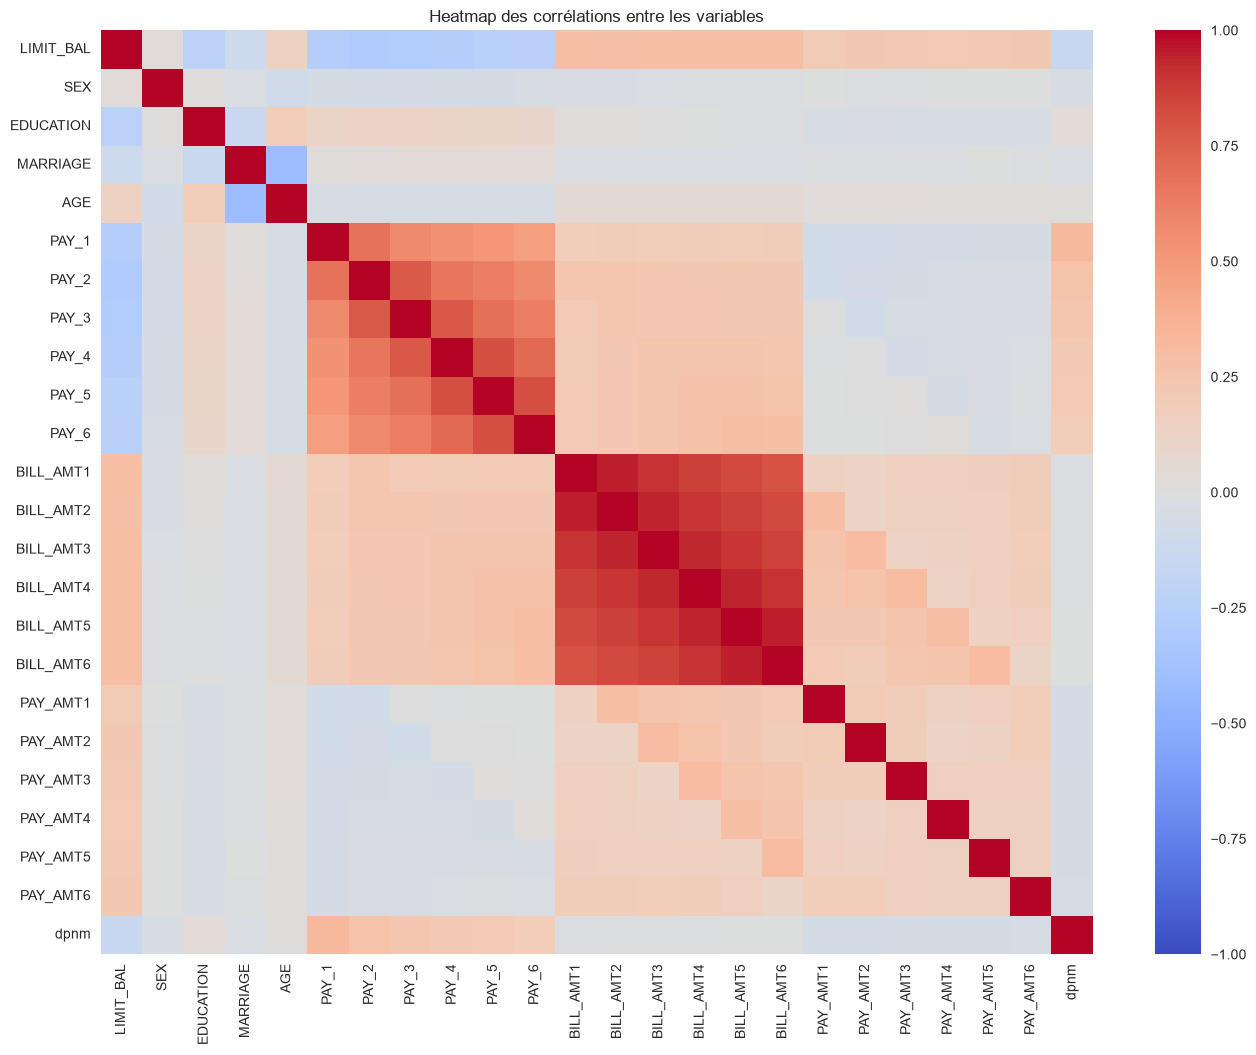

In [152]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assurez-vous que 'df' est votre DataFrame contenant les variables mentionnées
# Exemple : df = pd.read_csv('votre_fichier.csv')

# Sélectionner les variables pour la heatmap
variables = ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 
             'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 
             'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm']

# Calculer la matrice de corrélation
correlation_matrix = df[variables].corr()

# Créer la heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heatmap des corrélations entre les variables')
plt.show()

on voit des tendances, parfois contre intuitives :
- le défaut de paiement est plus important sur les plus petits plafond de crédit
- le défaut de paiement est directement lié avec le retard d'échéances
- les retards de paiement sont plus importants/fréquents quand l'encours augmente

y a t il un seuil de montant payé ou montant payé / encours à partir duquel la banque considère l'échéance payée ?  
Je commence par regarder si des montants sont payés alors que les encours sont négatifs ou nuls  

Analyse des cas où PAY_AMTn > 0 et BILL_AMTn+1 <= 0 :
Cas où PAY_AMTn > 0 et BILL_AMTn+1 <= 0 :
                         Paire  Nombre d'observations  Moyenne PAY_AMT1  Moyenne BILL_AMT2  Ratio moyen  Moyenne PAY_AMT2  Moyenne BILL_AMT3  Moyenne PAY_AMT3  Moyenne BILL_AMT4  Moyenne PAY_AMT4  Moyenne BILL_AMT5  Moyenne PAY_AMT5  Moyenne BILL_AMT6
PAY_AMT1 > 0 et BILL_AMT2 <= 0                    144           2264.22           -2187.69      -103.50               NaN                NaN               NaN                NaN               NaN                NaN               NaN                NaN
PAY_AMT2 > 0 et BILL_AMT3 <= 0                    161               NaN                NaN      -158.93           4486.48            -2823.0               NaN                NaN               NaN                NaN               NaN                NaN
PAY_AMT3 > 0 et BILL_AMT4 <= 0                    171               NaN                NaN      -117.55               NaN                NaN        

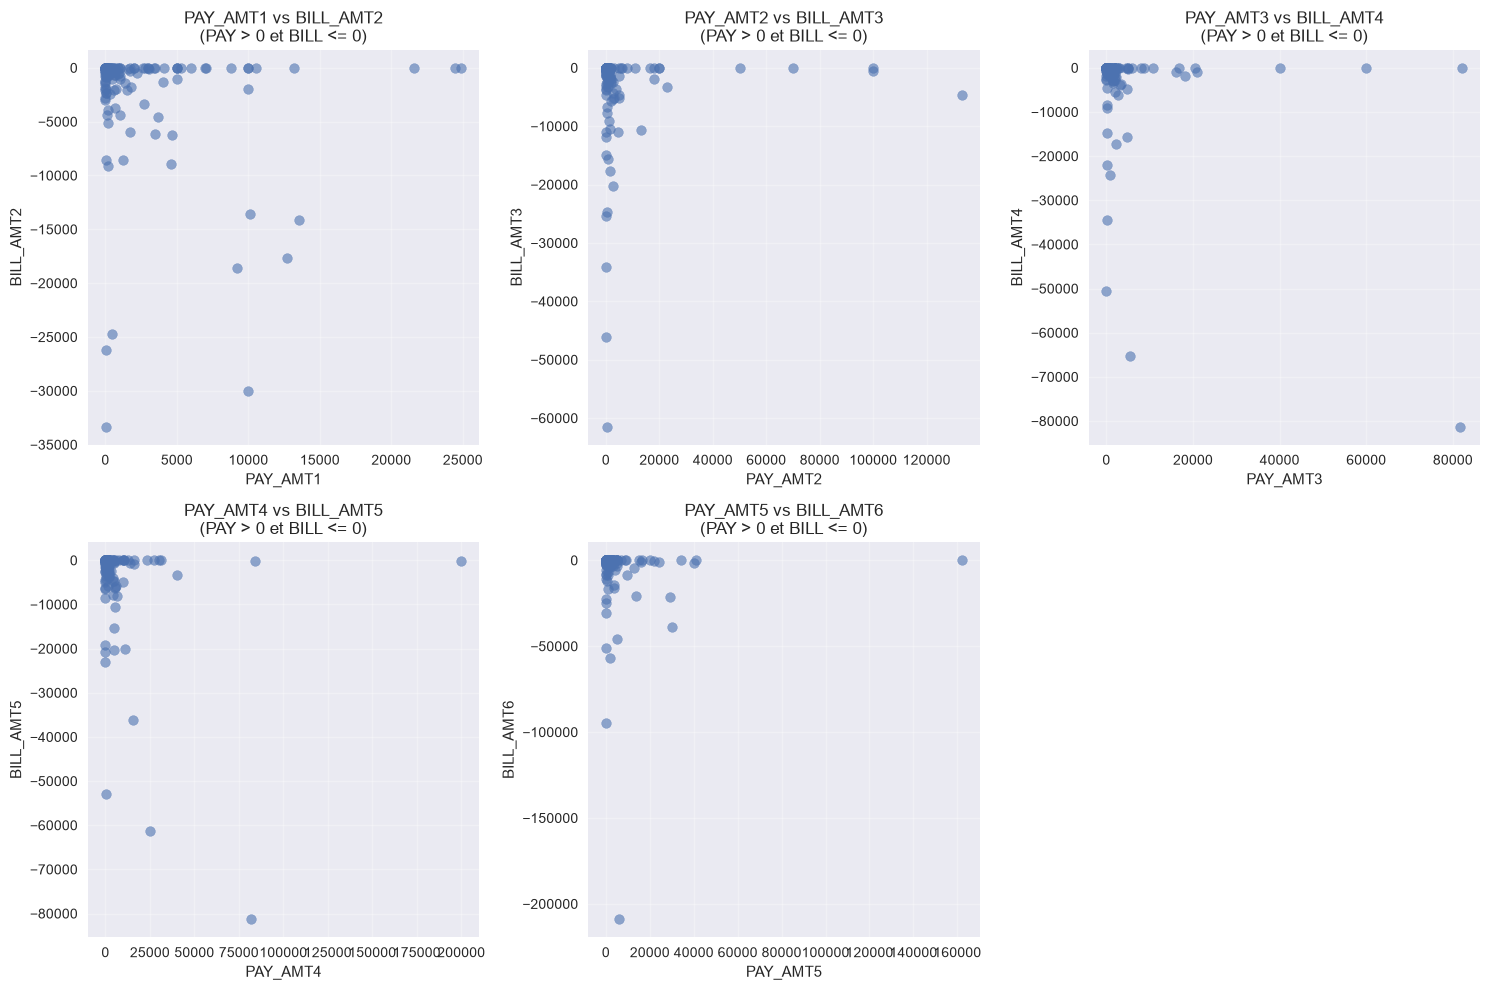


Analyse des cas extrêmes :

PAY_AMT1 / BILL_AMT2:
  Nombre de cas : 144
  PAY max : 24890
  BILL min : -33350

PAY_AMT2 / BILL_AMT3:
  Nombre de cas : 161
  PAY max : 133122
  BILL min : -61506

PAY_AMT3 / BILL_AMT4:
  Nombre de cas : 171
  PAY max : 82150
  BILL min : -81334

PAY_AMT4 / BILL_AMT5:
  Nombre de cas : 178
  PAY max : 200000
  BILL min : -81334

PAY_AMT5 / BILL_AMT6:
  Nombre de cas : 177
  PAY max : 162000
  BILL min : -209051

Résumé global :
Total de cas où PAY_AMTn > 0 et BILL_AMTn+1 <= 0 : 831


In [153]:
import pandas as pd
import numpy as np

# Vérification des cas où PAY_AMTn est positif mais BILL_AMTn+1 <= 0
print("Analyse des cas où PAY_AMTn > 0 et BILL_AMTn+1 <= 0 :")

# Colonnes de paiement et de facturation
payment_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

# Création d'une liste pour stocker les résultats
results = []

for i, (pay_col, bill_col) in enumerate(zip(payment_columns, bill_columns)):
    # Identifier les lignes où PAY_AMTn > 0 ET BILL_AMTn+1 <= 0
    condition = (df[pay_col] > 0) & (df[bill_col] <= 0)
    filtered_data = df[condition]
    
    count = len(filtered_data)
    if count > 0:
        # Calcul des statistiques sur ces données
        mean_pay = filtered_data[pay_col].mean()
        mean_bill = filtered_data[bill_col].mean()
        
        results.append({
            'Paire': f'{pay_col} > 0 et {bill_col} <= 0',
            'Nombre d\'observations': count,
            f'Moyenne {pay_col}': round(mean_pay, 2),
            f'Moyenne {bill_col}': round(mean_bill, 2),
            'Ratio moyen': round(mean_pay / mean_bill * 100, 2) if mean_bill != 0 else None
        })
    else:
        results.append({
            'Paire': f'{pay_col} > 0 et {bill_col} <= 0',
            'Nombre d\'observations': 0,
            f'Moyenne {pay_col}': None,
            f'Moyenne {bill_col}': None,
            'Ratio moyen': None
        })

# Création du tableau de résultats
results_df = pd.DataFrame(results)
print("Cas où PAY_AMTn > 0 et BILL_AMTn+1 <= 0 :")
print(results_df.to_string(index=False))

# Analyse plus détaillée : compter combien de fois chaque condition est remplie
print("\nAnalyse globale des conditions :")

# Compter les cas pour chaque paire
for i, (pay_col, bill_col) in enumerate(zip(payment_columns, bill_columns)):
    # Cas 1 : PAY_AMTn > 0 et BILL_AMTn+1 <= 0
    condition1 = (df[pay_col] > 0) & (df[bill_col] <= 0)
    
    # Cas 2 : PAY_AMTn <= 0 et BILL_AMTn+1 > 0  
    condition2 = (df[pay_col] <= 0) & (df[bill_col] > 0)
    
    # Cas 3 : PAY_AMTn > 0 et BILL_AMTn+1 > 0
    condition3 = (df[pay_col] > 0) & (df[bill_col] > 0)
    
    # Cas 4 : PAY_AMTn <= 0 et BILL_AMTn+1 <= 0
    condition4 = (df[pay_col] <= 0) & (df[bill_col] <= 0)
    
    print(f"\n{pay_col} / {bill_col}:")
    print(f"  PAY > 0 et BILL <= 0 : {condition1.sum()}")
    print(f"  PAY <= 0 et BILL > 0 : {condition2.sum()}")
    print(f"  PAY > 0 et BILL > 0 : {condition3.sum()}")
    print(f"  PAY <= 0 et BILL <= 0 : {condition4.sum()}")

# Visualisation de la distribution des paiements et factures
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

# Histogramme pour chaque paire
for i, (pay_col, bill_col) in enumerate(zip(payment_columns, bill_columns)):
    plt.subplot(2, 3, i+1)
    
    # Filtrer les données pour cette paire
    condition = (df[pay_col] > 0) & (df[bill_col] <= 0)
    data = df[condition]
    
    if len(data) > 0:
        plt.scatter(data[pay_col], data[bill_col], alpha=0.6)
        plt.xlabel(f'{pay_col}')
        plt.ylabel(f'{bill_col}')
        plt.title(f'{pay_col} vs {bill_col}\n(PAY > 0 et BILL <= 0)')
        plt.grid(True, alpha=0.3)
    else:
        plt.text(0.5, 0.5, 'Aucune donnée', ha='center', va='center', transform=plt.gca().transAxes)
        plt.title(f'{pay_col} vs {bill_col}\n(PAY > 0 et BILL <= 0)')

plt.tight_layout()
plt.show()

# Analyse des cas extrêmes
print("\nAnalyse des cas extrêmes :")

# Identifier les valeurs maximales et minimales dans chaque colonne
for pay_col, bill_col in zip(payment_columns, bill_columns):
    print(f"\n{pay_col} / {bill_col}:")
    
    # Cas où PAY > 0 et BILL <= 0
    condition = (df[pay_col] > 0) & (df[bill_col] <= 0)
    extreme_data = df[condition]
    
    if len(extreme_data) > 0:
        print(f"  Nombre de cas : {len(extreme_data)}")
        print(f"  PAY max : {extreme_data[pay_col].max()}")
        print(f"  BILL min : {extreme_data[bill_col].min()}")
    else:
        print("  Aucun cas trouvé")

# Résumé global
print("\nRésumé global :")
total_cases = sum([len(df[(df[pay_col] > 0) & (df[bill_col] <= 0)]) 
                   for pay_col, bill_col in zip(payment_columns, bill_columns)])
print(f"Total de cas où PAY_AMTn > 0 et BILL_AMTn+1 <= 0 : {total_cases}")

trouver une mensualité payée sur un encours nul ou négatif est un non-sens métier  
les anomalies sont elles groupées sur 200 lignes ou sont elles 1000 lignes distinctes ?

In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. INITIALISATION DES VARIABLES
payment_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

# Ensemble global pour compter les LIGNES DISTINCTES
unique_problematic_lines = set()

# Dictionnaire pour stocker les indices spécifiques à chaque paire (utile pour l'analyse détaillée)
pairs_indices = {}

print("Analyse des paiements effectués sur un encours <= 0 :\n")

# Itération sur chaque mois pour identifier les conditions
for i, (pay_col, bill_col) in enumerate(zip(payment_columns, bill_columns)):
    # Condition : Paiement > 0 ET Encours (Facture précédente) <= 0
    condition = (df[pay_col] > 0) & (df[bill_col] <= 0)
    
    # Récupération des indices de lignes pour cette paire spécifique
    current_indices = set(df[condition].index)
    
    # Ajout à l'ensemble global (gère l'unicité automatique)
    unique_problematic_lines.update(current_indices)
    
    print(f"--- {pay_col} vs {bill_col} ---")
    print(f"Lignes spécifiques à cette paire : {len(current_indices)}")
    
    pairs_indices[f"{pay_col} (sur {bill_col})"] = current_indices

# 2. RÉSULTAT PRINCIPAL : NOMBRE DE LIGNES DISTINCTES
print("\n" + "="*50)
print(f"TOTAL DES LIGNES DISTINCTES AVEC AU MOINS UN PAIEMENT SUR ENCOURS <= 0")
print(f"Nombre de clients/lignes concernés : {len(unique_problematic_lines)}")
print(f"Pourcentage du dataset : {len(unique_problematic_lines)/len(df)*100:.2f}%")
print("="*50)

# Récupération des index sous forme de liste pour manipuler le DataFrame
list_unique_lines = list(unique_problematic_lines)

# 3. AFFICHAGE D'UN EXEMPLE DE 10 LIGNES
print("\n--- Exemple de 10 lignes concernées ---")
# On prend les 10 premiers index trouvés
if len(list_unique_lines) > 0:
    sample_indices = list_unique_lines[:10]
    
    # Sélection des colonnes pertinentes pour l'analyse visuelle
    columns_to_show = payment_columns + bill_columns + ['SEX', 'EDUCATION', 'MARRIAGE']
    
    df_sample = df.loc[sample_indices, columns_to_show].copy()
    
    # Pour plus de clarté, on colorie ou indique simplement les données brutes
    print(df_sample.to_string())
else:
    print("Aucune ligne concernée.")

# 4. ANALYSE DE LA RÉCURRENCE (Optionnel mais informatif)
recurrence = {line: 0 for line in unique_problematic_lines}
for indices_set in pairs_indices.values():
    for line in indices_set:
        recurrence[line] += 1

clients_multi_fois = {line: count for line, count in recurrence.items() if count > 1}
print(f"\n--- Analyse de récurrence ---")
print(f"Lignes concernées par PLUSIEURS mois : {len(clients_multi_fois)}")

# 5. TABLEAU RÉCAPITULATIF STATISTIQUE PAR PAIRE (sur l'ensemble unique)
stats_list = []
for i, (pay_col, bill_col) in enumerate(zip(payment_columns, bill_columns)):
    # Intersection : lignes qui ont payé >0 sur cette facture <=0 ET qui sont dans notre ensemble global
    valid_indices = pairs_indices[f"{pay_col} (sur {bill_col})"].intersection(unique_problematic_lines)
    
    if len(valid_indices) > 0:
        sub_df = df.loc[list(valid_indices)]
        mean_pay = sub_df[pay_col].mean()
        std_pay = sub_df[pay_col].std()
        
        stats_list.append({
            'Paire': f'{pay_col} / {bill_col}',
            'Nb Lignes Distinctes dans ce lot': len(valid_indices),
            'Moyenne Payée': round(mean_pay, 2),
            'Ecart-Type': round(std_pay, 2)
        })

if stats_list:
    df_stats = pd.DataFrame(stats_list)
    print("\n--- Tableau détaillé par paire (sur les lignes distinctes globales) ---")
    print(df_stats.to_string(index=False))

Analyse des paiements effectués sur un encours <= 0 :

--- PAY_AMT1 vs BILL_AMT2 ---
Lignes spécifiques à cette paire : 144
--- PAY_AMT2 vs BILL_AMT3 ---
Lignes spécifiques à cette paire : 161
--- PAY_AMT3 vs BILL_AMT4 ---
Lignes spécifiques à cette paire : 171
--- PAY_AMT4 vs BILL_AMT5 ---
Lignes spécifiques à cette paire : 178
--- PAY_AMT5 vs BILL_AMT6 ---
Lignes spécifiques à cette paire : 177

TOTAL DES LIGNES DISTINCTES AVEC AU MOINS UN PAIEMENT SUR ENCOURS <= 0
Nombre de clients/lignes concernés : 690
Pourcentage du dataset : 2.30%

--- Exemple de 10 lignes concernées ---
       PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  SEX  EDUCATION  MARRIAGE
ID                                                                                                                                      
12293      5000     15066      5007         0      3000     113974     126194      17832      -3000          0    2          2         2
8198

Les 10 lignes montrées en exemple montrent clairement un remboursement trop important qui a mené à un encours négatif.  
Ces lignes atypiques correspondent en grande partie à des situations plausibles.  
Je n'y touche pas

In [155]:
import pandas as pd
import numpy as np

# Définition des colonnes
payment_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

print("Calcul des ratios conditionnels (uniquement si BILL > 0) :\n")

for i, (pay_col, bill_col) in enumerate(zip(payment_columns, bill_columns)):
    new_col_name = f"ratio_brut_PAY_BILL{pay_col.replace('PAY_AMT', '')}"
    
    # Création de la nouvelle colonne initialisée à NaN
    df[new_col_name] = np.nan
    
    # Sélection des lignes où la facture (dénominateur) est strictement positive
    valid_mask = df[bill_col] > 0
    
    if valid_mask.any():
        # Calcul du ratio uniquement sur les lignes valides
        # On évite ainsi la division par zéro ou par un négatif
        df.loc[valid_mask, new_col_name] = (df.loc[valid_mask, pay_col] / df.loc[valid_mask, bill_col]) * 100
        
        print(f"- {new_col_name}: Calculé sur {valid_mask.sum()} lignes valides")
    else:
        print(f"- {new_col_name}: Aucune facture positive trouvée ({bill_col} <= 0 pour tous), colonne vide (NaN).")

# Affichage des nouvelles colonnes créées
print("\nNouvelles colonnes créées :")
for i, (pay_col, bill_col) in enumerate(zip(payment_columns, bill_columns)):
    new_col_name = f"ratio_brut_PAY_BILL{pay_col.replace('PAY_AMT', '')}"
    print(f"- {new_col_name}")

# Vérification rapide pour voir combien de NaN il y a dans une colonne exemple
example_col = 'ratio_brut_PAY_BILL1'
print(f"\nVérification sur '{example_col}':")
print(f" - Valeurs valides (non-NaN) : {df[example_col].notna().sum()}")
print(f" - Valeurs NaN : {df[example_col].isna().sum()}")

Calcul des ratios conditionnels (uniquement si BILL > 0) :

- ratio_brut_PAY_BILL1: Calculé sur 26823 lignes valides
- ratio_brut_PAY_BILL2: Calculé sur 26471 lignes valides
- ratio_brut_PAY_BILL3: Calculé sur 26126 lignes valides
- ratio_brut_PAY_BILL4: Calculé sur 25835 lignes valides
- ratio_brut_PAY_BILL5: Calculé sur 25288 lignes valides

Nouvelles colonnes créées :
- ratio_brut_PAY_BILL1
- ratio_brut_PAY_BILL2
- ratio_brut_PAY_BILL3
- ratio_brut_PAY_BILL4
- ratio_brut_PAY_BILL5

Vérification sur 'ratio_brut_PAY_BILL1':
 - Valeurs valides (non-NaN) : 26823
 - Valeurs NaN : 3173


In [156]:
import pandas as pd
import numpy as np

# Définition des colonnes de ratio
payment_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

ratio_columns = [f"ratio_brut_PAY_BILL{pay.replace('PAY_AMT', '')}" for pay, bill in zip(payment_columns, bill_columns)]

# Liste pour stocker les statistiques par colonne
stats_data = []

print("--- Statistiques Descriptives des Ratios ---\n")

for col in ratio_columns:
    # On filtre les valeurs non NaN pour éviter les erreurs de calcul
    clean_values = df[col].dropna()
    
    if len(clean_values) > 0:
        min_val = clean_values.min()
        mean_val = clean_values.mean()
        median_val = clean_values.median()
        max_val = clean_values.max()
        
        stats_data.append({
            'Colonne': col,
            'Min': round(min_val, 2),
            'Moyenne': round(mean_val, 2),
            'Médiane': round(median_val, 2),
            'Max': round(max_val, 2)
        })

# Création du DataFrame de statistiques
df_stats = pd.DataFrame(stats_data)

print(df_stats.to_string(index=False))

# Optionnel : Afficher la distribution globale de toutes ces colonnes combinées
all_ratios = df[ratio_columns].stack().dropna()
print(f"\n--- Statistiques Globales (tous ratios confondus) ---")
print(f"Min Global: {all_ratios.min():.2f}")
print(f"Moyenne Globale: {all_ratios.mean():.2f}")
print(f"Médiane Globale: {all_ratios.median():.2f}")
print(f"Max Global: {all_ratios.max():.2f}")

--- Statistiques Descriptives des Ratios ---

             Colonne  Min  Moyenne  Médiane       Max
ratio_brut_PAY_BILL1  0.0    52.97     7.83 444433.33
ratio_brut_PAY_BILL2  0.0    73.52     7.75 500100.00
ratio_brut_PAY_BILL3  0.0    52.11     6.17 444433.33
ratio_brut_PAY_BILL4  0.0    34.89     5.17  12970.51
ratio_brut_PAY_BILL5  0.0    42.18     5.59  69065.52

--- Statistiques Globales (tous ratios confondus) ---
Min Global: 0.00
Moyenne Globale: 51.30
Médiane Globale: 6.57
Max Global: 500100.00


In [157]:
import pandas as pd

# Définition des colonnes de ratio créées précédemment
payment_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

ratio_columns = [f"ratio_brut_PAY_BILL{pay.replace('PAY_AMT', '')}" for pay, bill in zip(payment_columns, bill_columns)]

# 1. Compter les lignes avec au moins un ratio > 100%
count_high_ratio = df[ratio_columns].gt(100).any(axis=1).sum()

print(f"Nombre de lignes montrant un ratio > 100% : {count_high_ratio}")

# 2. Afficher les détails (optionnel, pour vérifier)
if count_high_ratio > 0:
    df_with_high_ratio = df[df[ratio_columns].gt(100).any(axis=1)]
    print("\n--- Exemple de lignes concernées ---")
    # On montre les ratios concernés surlignés
    cols_display = ratio_columns
    print(df_with_high_ratio[cols_display].head(5).to_string())

Nombre de lignes montrant un ratio > 100% : 5934

--- Exemple de lignes concernées ---
    ratio_brut_PAY_BILL1  ratio_brut_PAY_BILL2  ratio_brut_PAY_BILL3  ratio_brut_PAY_BILL4  ratio_brut_PAY_BILL5
ID                                                                                                              
5              35.273369            102.360820             47.755492             47.007208              3.601485
8             100.000000            100.000000              0.000000                   NaN            297.530864
11             23.561868              0.216802              1.989654             16.411379            100.187617
12            100.682972            100.000000            100.774921            100.062817              0.000000
18              4.201415              5.137083            108.371150            341.530055            100.000000


In [158]:
import pandas as pd

# Définition des colonnes de ratio créées précédemment
payment_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

ratio_columns = [f"ratio_brut_PAY_BILL{pay.replace('PAY_AMT', '')}" for pay, bill in zip(payment_columns, bill_columns)]

# 1. Compter les lignes avec au moins un ratio > 120%
count_high_ratio = df[ratio_columns].gt(120).any(axis=1).sum()

print(f"Nombre de lignes montrant un ratio > 120% : {count_high_ratio}")

# 2. Afficher les détails (optionnel, pour vérifier)
if count_high_ratio > 0:
    df_with_high_ratio = df[df[ratio_columns].gt(120).any(axis=1)]
    print("\n--- Exemple de lignes concernées ---")
    # On montre les ratios concernés surlignés
    cols_display = ratio_columns
    print(df_with_high_ratio[cols_display].head(5).to_string())

Nombre de lignes montrant un ratio > 120% : 1445

--- Exemple de lignes concernées ---
    ratio_brut_PAY_BILL1  ratio_brut_PAY_BILL2  ratio_brut_PAY_BILL3  ratio_brut_PAY_BILL4  ratio_brut_PAY_BILL5
ID                                                                                                              
8             100.000000            100.000000              0.000000                   NaN            297.530864
18              4.201415              5.137083            108.371150            341.530055            100.000000
27                   NaN            386.100386                   NaN            393.700787                   NaN
38             15.296757             13.715215             33.903087                   NaN            255.471597
62              5.585623              2.995510              6.054002             14.188422            361.445783


In [159]:
import pandas as pd

# Définition des colonnes de ratio créées précédemment
payment_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

ratio_columns = [f"ratio_brut_PAY_BILL{pay.replace('PAY_AMT', '')}" for pay, bill in zip(payment_columns, bill_columns)]

# 1. Filtrage des lignes avec au moins un ratio > 1000%
mask_extreme_ratio = df[ratio_columns].gt(1000).any(axis=1)
df_with_high_ratio = df[mask_extreme_ratio]

print(f"Nombre de lignes montrant un ratio > 1000% : {len(df_with_high_ratio)}")

# 2. Affichage des lignes complètes
if len(df_with_high_ratio) > 0:
    print("\n--- Lignes complètes avec Ratio > 1000% ---")
    # On affiche les 5 premières lignes pour l'exemple
    # Tu peux enlever .head(5) si tu veux tout voir (attention à la longueur)
    print(df_with_high_ratio.head(5).to_string())
else:
    print("Aucune ligne trouvée.")

Nombre de lignes montrant un ratio > 1000% : 89

--- Lignes complètes avec Ratio > 1000% ---
     LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_1  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  dpnm  ratio_brut_PAY_BILL1  ratio_brut_PAY_BILL2  ratio_brut_PAY_BILL3  ratio_brut_PAY_BILL4  ratio_brut_PAY_BILL5
ID                                                                                                                                                                                                                                                                                                                                       
344     180000    1          1         1   39      0      0     -1      0      0     -1     274731     281713     242063     122295      -1005       1005     11000    145000     26000         0    101005      1898     0              3.904683      

--- Analyse des Valeurs Aberrantes ---

             Colonne  Min Aberrant  Max Aberrant  Nombre d'aberrations  Borne Basse (Q1-1.5*IQR)  Borne Haute (Q3+1.5*IQR)
ratio_brut_PAY_BILL1    248.819876 444433.333333                    78                   -139.29                    243.58
ratio_brut_PAY_BILL2    245.766773 500100.000000                    89                   -139.40                    243.64
ratio_brut_PAY_BILL3    233.333333 444433.333333                   104                   -134.17                    233.30
ratio_brut_PAY_BILL4    201.827676  12970.512821                   132                   -115.26                    201.64
ratio_brut_PAY_BILL5    246.366559  69065.517241                    92                   -140.81                    244.49


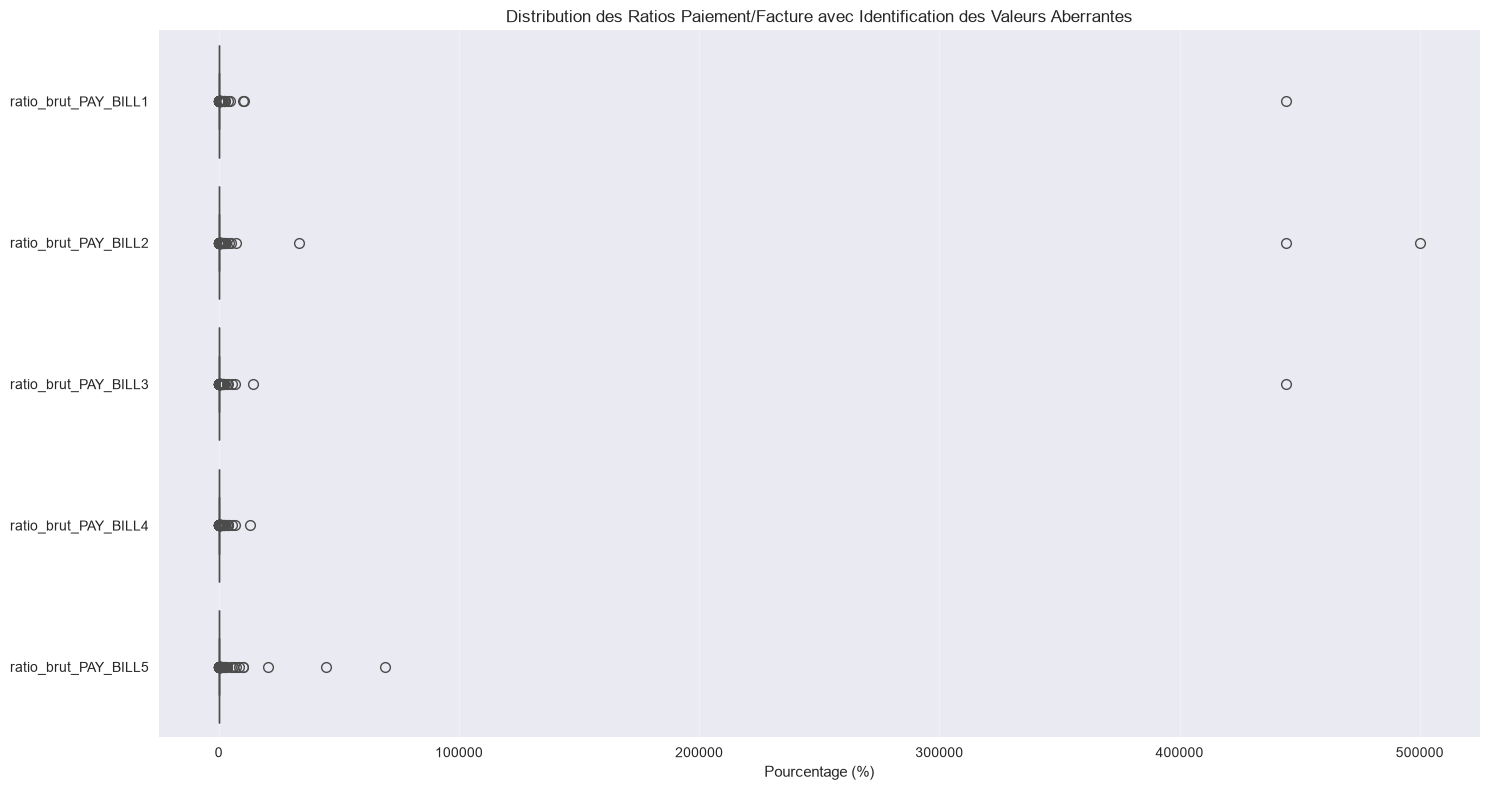

In [160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ratio_columns = [f"ratio_brut_PAY_BILL{pay.replace('PAY_AMT', '')}" for pay, bill in zip(
    ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5'],
    ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
)]

# 1. DÉFINITION DES VALEURS ABERRANTES (Outliers)
# Une valeur est aberrante si elle est < Q1 - 1.5*IQR ou > Q3 + 1.5*IQR
def find_outliers_stats(df_col):
    """Calcule les bornes d'aberration pour une série de données"""
    q1 = df_col.quantile(0.25)
    q3 = df_col.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return lower_bound, upper_bound

# Liste pour stocker les résultats statistiques par colonne
outlier_stats = []

print("--- Analyse des Valeurs Aberrantes ---\n")

for col in ratio_columns:
    # On travaille sur les données non nulles/NaN
    clean_data = df[col].dropna()
    
    if len(clean_data) < 10: 
        continue
        
    lower, upper = find_outliers_stats(clean_data)
    
    # Identification des valeurs aberrantes
    outliers = clean_data[(clean_data < lower) | (clean_data > upper)]
    
    outlier_stats.append({
        'Colonne': col,
        'Min Aberrant': min(outliers) if len(outliers) > 0 else None,
        'Max Aberrant': max(outliers) if len(outliers) > 0 else None,
        'Nombre d\'aberrations': len(outliers),
        'Borne Basse (Q1-1.5*IQR)': round(lower, 2),
        'Borne Haute (Q3+1.5*IQR)': round(upper, 2)
    })

# Tableau récapitulatif des aberrations
df_outliers = pd.DataFrame(outlier_stats)
print(df_outliers.to_string(index=False))

# 2. VISUALISATION DES VALEURS ABERRANTES (Boxplots)
plt.figure(figsize=(15, 8))

# On filtre le dataframe pour ne garder que les colonnes de ratio
df_ratios = df[ratio_columns]

# Boxplot global pour voir la distribution et identifier visuellement les points aberrants (losanges)
sns.boxplot(data=df_ratios, patch_artist=True, orient='h')
plt.title('Distribution des Ratios Paiement/Facture avec Identification des Valeurs Aberrantes')
plt.xlabel('Pourcentage (%)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()



pour l'ID 344 on devine une anomalie : la somme due passe de 1005 à -1005 et le client a payé 101005, une coquille s'est probablement glissé dans le paiement.  
Les autres lignes ne présentent pas d'anomalie qui saute aux yeux.  
Corriger des lignes manuellement est impossible.  
Les modes de paiement et habitudes de 2005 suggèrent que les clients payaient parfois avec un peu d'avance ou un peu de retard et créent des distorsions sur certaines période.  De plus, certains paiements pouvaient être saisis à la main dans des bureau de tabac ou des bureaux de poste. Ces features ne sont pas exploitables en tant que tel pour visualisation, comparaison, mais des modèles de ML pourraient y voir les tendances.  
Il faudrait peut etre créer une sorte de feature glissante où on regarde plusieurs mois pour lisser les extremes et les décalages de paiements.  
Appliquons la meme limite de 2,1 que pour les paiements sur plafond pour voir ce qu'on trouve :  

In [161]:
import pandas as pd

# 1. Définition des colonnes cibles
colonnes_ratio = [
    'ratio_brut_PAY_BILL1',
    'ratio_brut_PAY_BILL2',
    'ratio_brut_PAY_BILL3',
    'ratio_brut_PAY_BILL4',
    'ratio_brut_PAY_BILL5'
]

# Filtrer pour ne garder que celles qui existent dans ton dataframe
colonnes_presentes = [col for col in colonnes_ratio if col in df.columns]

if len(colonnes_presentes) > 0:
    # 2. Identification des lignes où AU MOINS une colonne est > 210
    # On crée un masque (booléen True/False) pour chaque colonne
    masque_anomalies = pd.Series([False] * len(df), index=df.index)
    
    for col in colonnes_presentes:
        # Condition stricte : > 210 (donc plus de 210%)
        masque_anomalies = masque_anomalies | (df[col] > 210)
    
    nb_lignes_totales = len(df)
    nb_anomalies = masque_anomalies.sum()

    print(f"--- Analyse des Ratios de Paiement > 210% ---")
    print(f"Total lignes dans le dataset : {nb_lignes_totales}")
    print(f"Lignes avec AU MOINS un ratio > 210 : {nb_anomalies}")
    
    if nb_anomalies > 0:
        # 3. Extraction et affichage des 10 lignes complètes
        # On trie par la valeur maximale de ces ratios pour voir les cas les plus extrêmes en premier
        df_anomalies = df[masque_anomalies].copy()
        
        # On calcule le max de ces colonnes pour chaque ligne afin de trier
        df_anomalies['Max_Ratio'] = df_anomalies[colonnes_presentes].max(axis=1)
        df_anomalies_sorted = df_anomalies.sort_values(by='Max_Ratio', ascending=False)
        
        # On affiche les 10 premières lignes complètes
        print("\n--- Les 10 cas extrêmes (Raisonnements possibles : Rattrapage de dette ou Erreur) ---")
        print(df_anomalies_sorted.head(10).drop(columns=['Max_Ratio']).to_string())
    else:
        print("\nAucune ligne trouvée avec un ratio > 210.")

else:
    print("Colonnes de ratio non trouvées dans le dataframe.")

--- Analyse des Ratios de Paiement > 210% ---
Total lignes dans le dataset : 29996
Lignes avec AU MOINS un ratio > 210 : 486

--- Les 10 cas extrêmes (Raisonnements possibles : Rattrapage de dette ou Erreur) ---
       LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_1  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  dpnm  ratio_brut_PAY_BILL1  ratio_brut_PAY_BILL2  ratio_brut_PAY_BILL3  ratio_brut_PAY_BILL4  ratio_brut_PAY_BILL5
ID                                                                                                                                                                                                                                                                                                                                         
21349      70000    1          1         1   67      1     -1     -1      2      2      2        275        400          2  

480 lignes présentent un paiement > 210% du montant dû le mois précédent, soit 1.6% du dataset.  
Des anomalies flagrantes apparaissent sur certaines lignes ci dessus (encore des montant multipliés par 100 par exemple).  
On peut retranscrire ce qu'on a dit sur les paiements et leur délai de comptabilisation également pour les utilisations car si un client retire de l'argent à un bureau de poste, il se peut que le montant soit mal saisi, ne soit pas comptabilisé pour le mois en cours...  
Corriger ces lignes aberrantes est impossible.  
Mais on pourrait limiter ces valeurs extrêmes en ne calculant les colonnes ratios qu'à partir non pas de BILL_AMT > 0 mais un autre montant par exemple 100 :  



--- Analyse des Valeurs Aberrantes avec Volumétrie (BILL_AMT >= 100) ---

             Colonne  Lignes Initiales  Lignes Conservées  Lignes Filtrées (<100) % Filtré  Aberrations (IQR)  Borne Basse  Borne Haute
ratio_brut_PAY_BILL1             26823              26758                      65    0.24%                 70      -139.30       243.58
ratio_brut_PAY_BILL2             26471              26411                      60    0.23%                 82      -139.40       243.64
ratio_brut_PAY_BILL3             26126              26071                      55    0.21%                 99      -131.96       229.62
ratio_brut_PAY_BILL4             25835              25761                      74    0.29%                157      -110.86       194.31
ratio_brut_PAY_BILL5             25288              25220                      68    0.27%                 84      -140.81       244.49


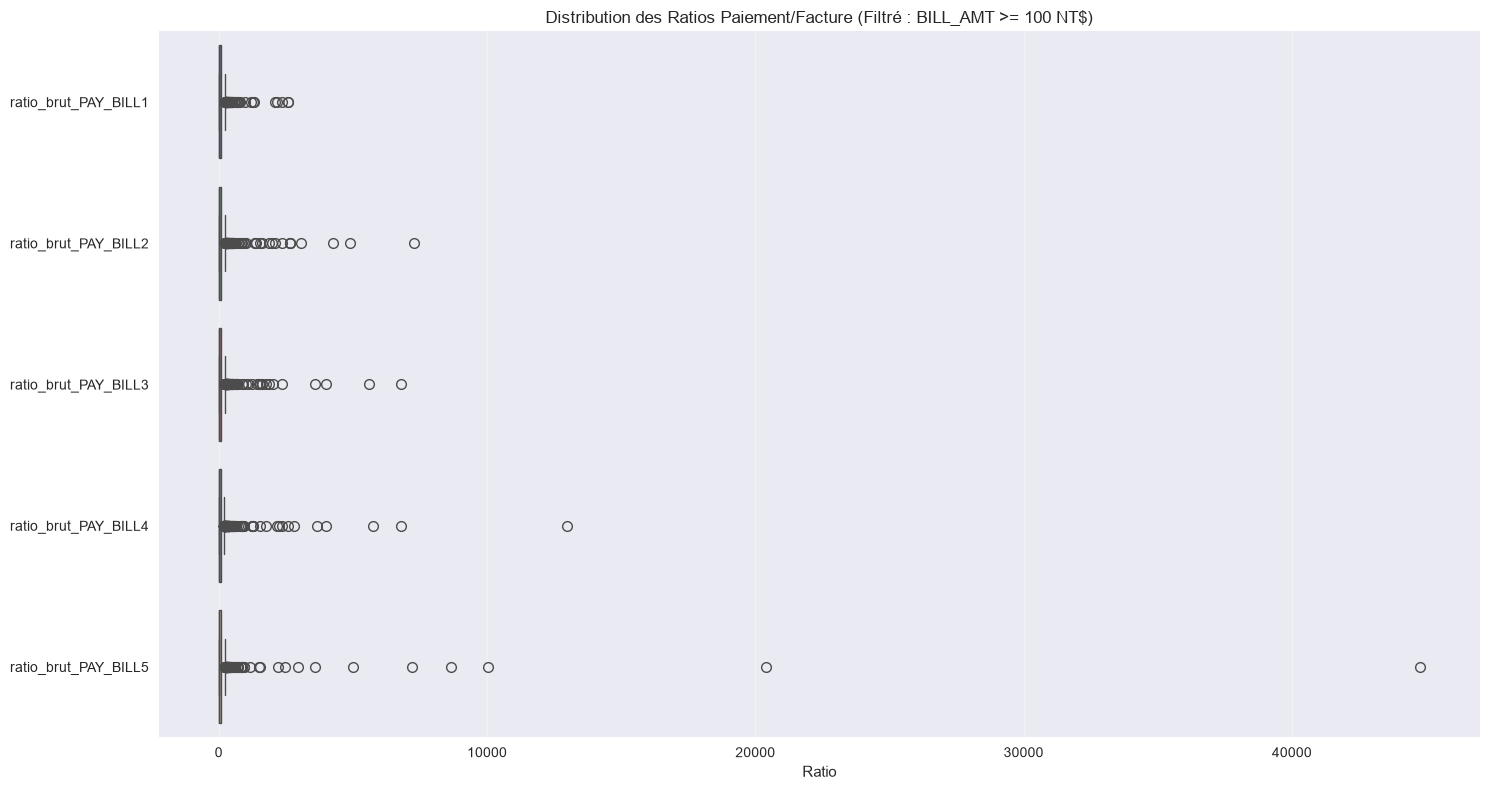

In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pairs = [
    ('PAY_AMT1', 'BILL_AMT2'),
    ('PAY_AMT2', 'BILL_AMT3'),
    ('PAY_AMT3', 'BILL_AMT4'),
    ('PAY_AMT4', 'BILL_AMT5'),
    ('PAY_AMT5', 'BILL_AMT6')
]

outlier_stats = []
df_ratios_filtered = pd.DataFrame()

print("--- Analyse des Valeurs Aberrantes avec Volumétrie (BILL_AMT >= 100) ---\n")

for pay_col, bill_col in pairs:
    ratio_col = f"ratio_brut_PAY_BILL{pay_col.replace('PAY_AMT', '')}"
    
    # Masque appliqué à la facture du mois correspondant
    mask = df[bill_col] >= 100
    
    # Population initiale non nulle sur ce ratio
    raw_data = df[ratio_col].dropna()
    n_initial = len(raw_data)
    
    # Population conservée après masque (BILL_AMT >= 100)
    clean_data = df.loc[mask, ratio_col].dropna()
    n_kept = len(clean_data)
    
    # Volumétrie éliminée par le masque
    n_eliminated = n_initial - n_kept
    pct_eliminated = (n_eliminated / n_initial * 100) if n_initial > 0 else 0.0
    
    # Stockage des valeurs filtrées pour la visualisation
    df_ratios_filtered[ratio_col] = df[ratio_col].where(mask)
    
    if n_kept < 10: 
        continue
        
    lower, upper = find_outliers_stats(clean_data)
    
    # Outliers statistiques (IQR) sur la population filtrée
    outliers = clean_data[(clean_data < lower) | (clean_data > upper)]
    
    outlier_stats.append({
        'Colonne': ratio_col,
        'Lignes Initiales': n_initial,
        'Lignes Conservées': n_kept,
        'Lignes Filtrées (<100)': n_eliminated,
        '% Filtré': f"{pct_eliminated:.2f}%",
        'Aberrations (IQR)': len(outliers),
        'Borne Basse': round(lower, 2),
        'Borne Haute': round(upper, 2)
    })

# Tableau récapitulatif
df_outliers = pd.DataFrame(outlier_stats)
print(df_outliers.to_string(index=False))

# Visualisation des Boxplots (sur données filtrées)
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_ratios_filtered, patch_artist=True, orient='h')
plt.title('Distribution des Ratios Paiement/Facture (Filtré : BILL_AMT >= 100 NT$)')
plt.xlabel('Ratio')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Même à 200 de cut off, 2 valeurs sortent du lot à 20 000 et 45 000%.  
Afin de vérifier la cohérence, regardons quelques lignes en détail

In [163]:
import pandas as pd
import numpy as np

# 1. Définition stricte des colonnes de ratio et de leur dénominateur BILL_AMT correspondante
paires = [
    ('ratio_brut_PAY_BILL1', 'BILL_AMT2'),
    ('ratio_brut_PAY_BILL2', 'BILL_AMT3'),
    ('ratio_brut_PAY_BILL3', 'BILL_AMT4'),
    ('ratio_brut_PAY_BILL4', 'BILL_AMT5'),
    ('ratio_brut_PAY_BILL5', 'BILL_AMT6')
]

lignes_anormales_details = []

print("--- Analyse : Ratios > 1000% avec Facture BILL_AMT >= 100 ---\n")

for col_ratio, col_bill in paires:
    if col_ratio not in df.columns or col_bill not in df.columns:
        continue
    
    # Condition 1 : Le ratio est extrêmement élevé (> 1000)
    condition_ratio = df[col_ratio] > 1000
    
    # Condition 2 : La facture associée est structurante (>= 100)
    condition_facture = df[col_bill] >= 100
    
    # Intersection stricte
    mask_anomalie = condition_ratio & condition_facture
    
    nb_cas = mask_anomalie.sum()
    
    if nb_cas > 0:
        print(f"[{col_ratio}] : {nb_cas} cas trouvés avec BILL_AMT >= 100 ET Ratio > 1000")
        
        df_cas = df[mask_anomalie].copy()
        df_cas['Source_Ratio'] = col_ratio
        df_cas['Facture_Source'] = col_bill
        
        # Tri pour voir les plus extrêmes
        df_cas = df_cas.sort_values(by=col_ratio, ascending=False)
        
        lignes_anormales_details.append(df_cas.head(10))

# 3. Affichage Global
if lignes_anormales_details:
    df_anomalies_final = pd.concat(lignes_anormales_details).drop_duplicates()
    
    print(f"\n--- Résumé Global ---")
    print(f"Total de cas uniques identifiés : {len(df_anomalies_final)}")
    
    print(f"\n--- Les 10 lignes les plus extrêmes (Complètes) ---")
    display_data = df_anomalies_final.head(10).drop(columns=['Source_Ratio', 'Facture_Source'])
    
    # Affichage de toutes les colonnes pour vérification
    print(display_data.to_string())

else:
    print("\n--- RÉSULTAT NÉGATIF ---")
    print("Aucune ligne ne répond à la fois à : Ratio > 1000 ET BILL_AMT >= 100.")
    print("Conclusion : Les ratios > 1000% sont exclusivement liés à des factures < 100€ (micro-dettes).")
    
    # Vérification complémentaire : combien de ratios > 1000 existent sans filtre de facture ?
    total_extremes = 0
    for col_ratio, _ in paires:
        if col_ratio in df.columns:
            total_extremes += (df[col_ratio] > 1000).sum()
    
    print(f"\nTotal de ratios > 1000 sur tout le dataset (sans filtre facture) : {total_extremes}")

--- Analyse : Ratios > 1000% avec Facture BILL_AMT >= 100 ---

[ratio_brut_PAY_BILL1] : 8 cas trouvés avec BILL_AMT >= 100 ET Ratio > 1000
[ratio_brut_PAY_BILL2] : 17 cas trouvés avec BILL_AMT >= 100 ET Ratio > 1000
[ratio_brut_PAY_BILL3] : 16 cas trouvés avec BILL_AMT >= 100 ET Ratio > 1000
[ratio_brut_PAY_BILL4] : 16 cas trouvés avec BILL_AMT >= 100 ET Ratio > 1000
[ratio_brut_PAY_BILL5] : 13 cas trouvés avec BILL_AMT >= 100 ET Ratio > 1000

--- Résumé Global ---
Total de cas uniques identifiés : 48

--- Les 10 lignes les plus extrêmes (Complètes) ---
       LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_1  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  dpnm  ratio_brut_PAY_BILL1  ratio_brut_PAY_BILL2  ratio_brut_PAY_BILL3  ratio_brut_PAY_BILL4  ratio_brut_PAY_BILL5
ID                                                                                                          

pas d'anomalie visible en terme métier => aucune modification à faire.  
**solution pour exploiter ces statistiques**
Appliquer un masque pour les graphiques du type BILL_AMTn >= 100
**Définition retenue** (identique à `02_01_nettoyage`, utilisée par l'EDA, Streamlit et le ML) : `ratio_PAY_BILLn` = PAY_AMTn / BILL_AMT(n+1) en %, écrêté entre 0 et 200 %, et 100 % si aucune facture n'était exigible. Plus de valeurs aberrantes ni de NaN pour le ML.  
Le ratio brut (`ratio_brut_PAY_BILLn`) ne sert qu'à l'étude des valeurs aberrantes ci-dessus.

In [164]:
# Définition unique retenue (identique à 02_01_nettoyage) : ratio_PAY_BILLn = PAY_AMTn / BILL_AMT(n+1) en %,
# écrêté entre 0 et 200 %, et 100 % si aucune facture n'était exigible (BILL_AMT(n+1) <= 0).
# Le ratio brut (ratio_brut_PAY_BILLn) ne sert qu'à l'étude des valeurs aberrantes ci-dessus.
for n in range(1, 6):
    bill = df[f'BILL_AMT{n+1}']
    ratio = (df[f'PAY_AMT{n}'] / bill.where(bill > 0) * 100).clip(lower=0, upper=200)
    df[f'ratio_PAY_BILL{n}'] = ratio.fillna(100)

def ratios_affichables(d, cols):
    """Ratios de paiement à afficher dans les graphiques : uniquement quand une facture était exigible
    (BILL_AMT(n+1) > 0). La colonne ratio_PAY_BILLn garde sa définition unique (100 % sans facture
    exigible, voir docs/colonnes_creees.md) : ce filtre ne sert qu'à l'affichage."""
    out = d[cols].copy()
    for col in cols:
        n = int(col.replace('ratio_PAY_BILL', ''))
        out[col] = out[col].where(d[f'BILL_AMT{n + 1}'] > 0)
    return out

df[[f'ratio_PAY_BILL{n}' for n in range(1, 6)]].describe().round(2)


,ratio_PAY_BILL1,ratio_PAY_BILL2,ratio_PAY_BILL3,ratio_PAY_BILL4,ratio_PAY_BILL5
count,29996.00,29996.00,29996.00,29996.00,29996.00
mean,41.19,42.13,41.23,41.21,43.85
std,45.92,46.34,46.68,46.99,47.29
min,0.00,0.00,0.00,0.00,0.00
25%,4.47,4.46,3.79,3.64,3.81
50%,10.15,10.37,8.43,7.69,9.04
75%,100.00,100.00,100.00,100.00,100.00
max,200.00,200.00,200.00,200.00,200.00


Analyse des ratios avec PAY_n <= 0 :
Statistiques pour les valeurs où PAY_n <= 0 :
        Colonne  Moyenne (PAY_n <= 0)  Minimum (PAY_n <= 0)  Médiane (PAY_n <= 0)  Maximum (PAY_n <= 0)  Nombre d'observations
ratio_PAY_BILL1                 39.92                   0.0                 10.23                 200.0                  22469
ratio_PAY_BILL2                 39.86                   0.0                  9.94                 200.0                  22383
ratio_PAY_BILL3                 36.80                   0.0                  7.44                 200.0                  22712
ratio_PAY_BILL4                 35.29                   0.0                  6.04                 200.0                  22919
ratio_PAY_BILL5                 37.43                   0.0                  6.93                 200.0                  22231


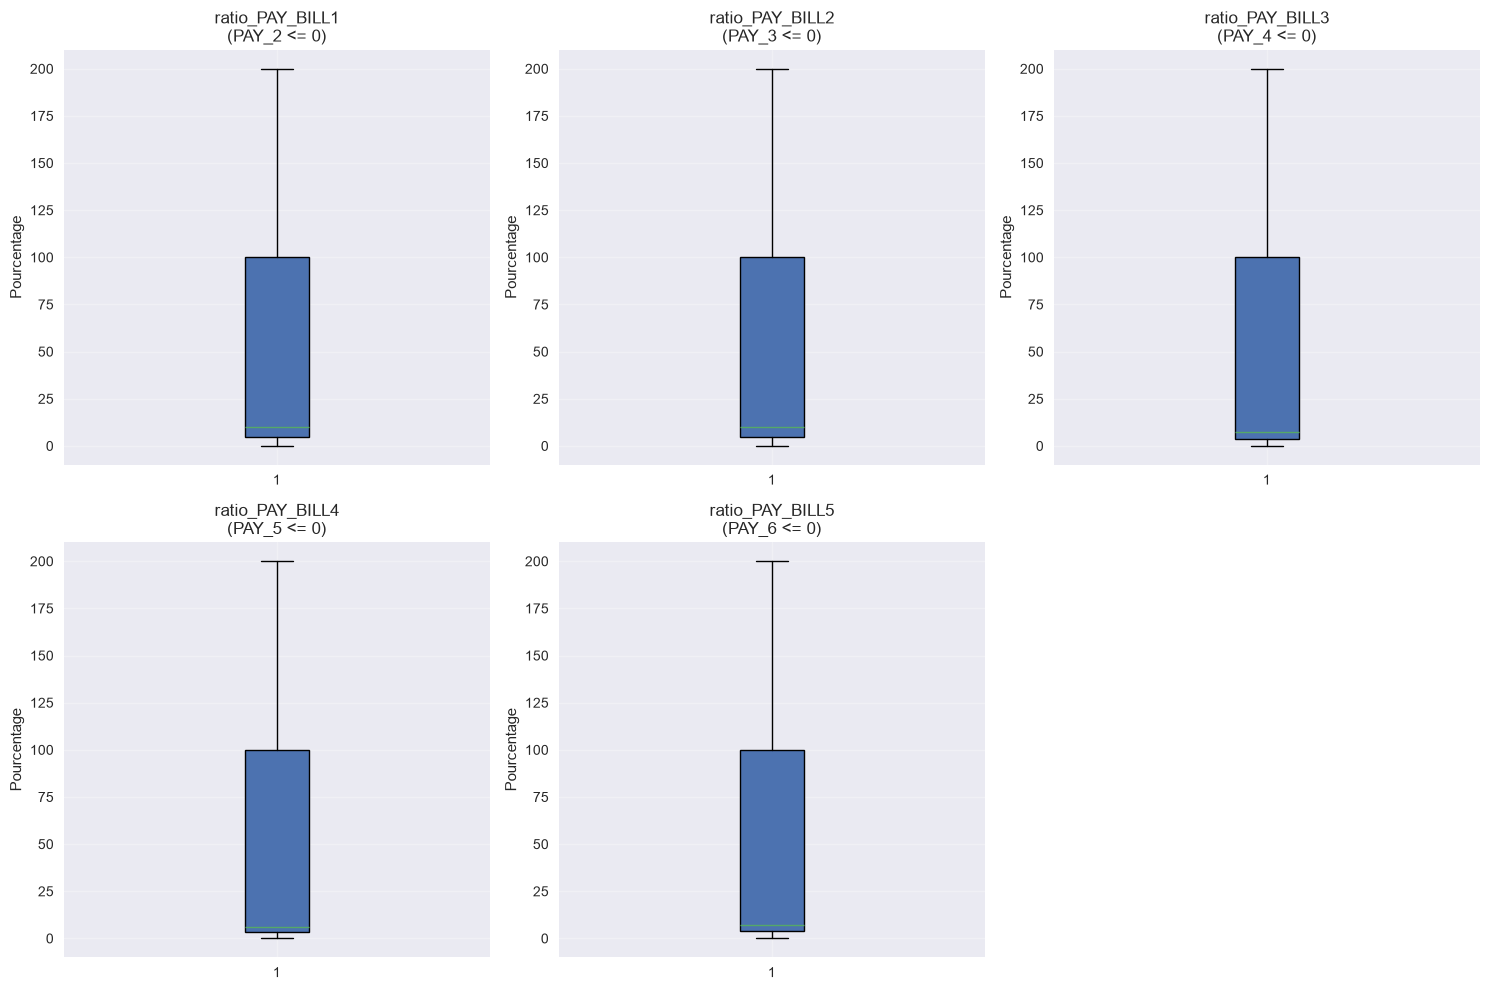

In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Supposons que les colonnes ratio_PAY_BILL1, etc. existent déjà
# Création de la liste des colonnes ratio existantes
ratio_columns = ['ratio_PAY_BILL1', 'ratio_PAY_BILL2', 
                 'ratio_PAY_BILL3', 'ratio_PAY_BILL4', 
                 'ratio_PAY_BILL5']
df_aff = ratios_affichables(df, ratio_columns)  # affichage : factures exigibles seulement

# Analyse statistique pour les valeurs où PAY_n <= 0
print("Analyse des ratios avec PAY_n <= 0 :")

# Création d'une liste pour stocker les résultats
results = []

for col in ratio_columns:
    # Pour chaque colonne ratio, je dois identifier la colonne PAY_n correspondante
    # Exemple : ratio_PAY_BILL1 -> PAY_2 (codification de la facture BILL_AMT2)
    # On extrait le numéro de la colonne PAY
    pay_n_col = f"PAY_{int(col.replace('ratio_PAY_BILL', '')) + 1}"  # ratio_PAY_BILLn règle BILL_AMT(n+1), codifiée par PAY_(n+1) : ratio_PAY_BILL1 -> PAY_2
    
    # Filtrer les données où PAY_n <= 0
    filtered_data = df_aff.loc[df[pay_n_col] <= 0, col].dropna()
    
    if len(filtered_data) > 0:
        mean_val = filtered_data.mean()
        min_val = filtered_data.min()
        median_val = filtered_data.median()
        max_val = filtered_data.max()
        count = len(filtered_data)
        
        results.append({
            'Colonne': col,
            'Moyenne (PAY_n <= 0)': round(mean_val, 2) if not pd.isna(mean_val) else None,
            'Minimum (PAY_n <= 0)': round(min_val, 2) if not pd.isna(min_val) else None,
            'Médiane (PAY_n <= 0)': round(median_val, 2) if not pd.isna(median_val) else None,
            'Maximum (PAY_n <= 0)': round(max_val, 2) if not pd.isna(max_val) else None,
            'Nombre d\'observations': count
        })
    else:
        results.append({
            'Colonne': col,
            'Moyenne (PAY_n <= 0)': None,
            'Minimum (PAY_n <= 0)': None,
            'Médiane (PAY_n <= 0)': None,
            'Maximum (PAY_n <= 0)': None,
            'Nombre d\'observations': 0
        })

# Création du tableau de résultats
results_df = pd.DataFrame(results)
print("Statistiques pour les valeurs où PAY_n <= 0 :")
print(results_df.to_string(index=False))

# Boxplot individuel pour chaque colonne
plt.figure(figsize=(15, 10))

for i, col in enumerate(ratio_columns):
    plt.subplot(2, 3, i+1)
    
    # Identifier la colonne PAY_n correspondante
    pay_n_col = f"PAY_{int(col.replace('ratio_PAY_BILL', '')) + 1}"  # ratio_PAY_BILLn règle BILL_AMT(n+1), codifiée par PAY_(n+1) : ratio_PAY_BILL1 -> PAY_2
    
    # Filtrer les données où PAY_n <= 0
    filtered_data = df_aff.loc[df[pay_n_col] <= 0, col].dropna().dropna()
    
    if len(filtered_data) > 0:
        plt.boxplot(filtered_data, patch_artist=True)
        plt.title(f'{col}\n(PAY_{pay_n_col.split("_")[1]} <= 0)')
        plt.ylabel('Pourcentage')
        plt.grid(True, alpha=0.3)
    else:
        plt.text(0.5, 0.5, 'Pas de données\n(PAY_n > 0)', ha='center', va='center', transform=plt.gca().transAxes)
        plt.title(f'{col}\n(PAY_{pay_n_col.split("_")[1]} <= 0)')

plt.tight_layout()
plt.show()



**Interprétation**  
Remis dans le bon ordre (le ratio d'une facture avec sa propre codification, `PAY_(n+1)`), les clients codifiés sains paient une part réelle de leur facture, alors que les clients codifiés en retard ne paient le plus souvent rien du tout. Un seuil se dessine : sans paiement, retard ; avec un vrai paiement, pas de retard. La frontière exacte se regarde plus bas, avec la sortie du retard.

Analyse des ratios avec PAY_n > 0 :

Statistiques pour les valeurs où PAY_n > 0 :
        Colonne  Moyenne (PAY_n > 0)  Minimum (PAY_n > 0)  Médiane (PAY_n > 0)  Maximum (PAY_n > 0)  Nombre d'observations
ratio_PAY_BILL1                 4.87                  0.0                 0.00               200.00                   4354
ratio_PAY_BILL2                 4.66                  0.0                 0.01               131.59                   4088
ratio_PAY_BILL3                 4.08                  0.0                 0.00               200.00                   3414
ratio_PAY_BILL4                 3.85                  0.0                 0.00               200.00                   2916
ratio_PAY_BILL5                 4.07                  0.0                 0.00               200.00                   3057


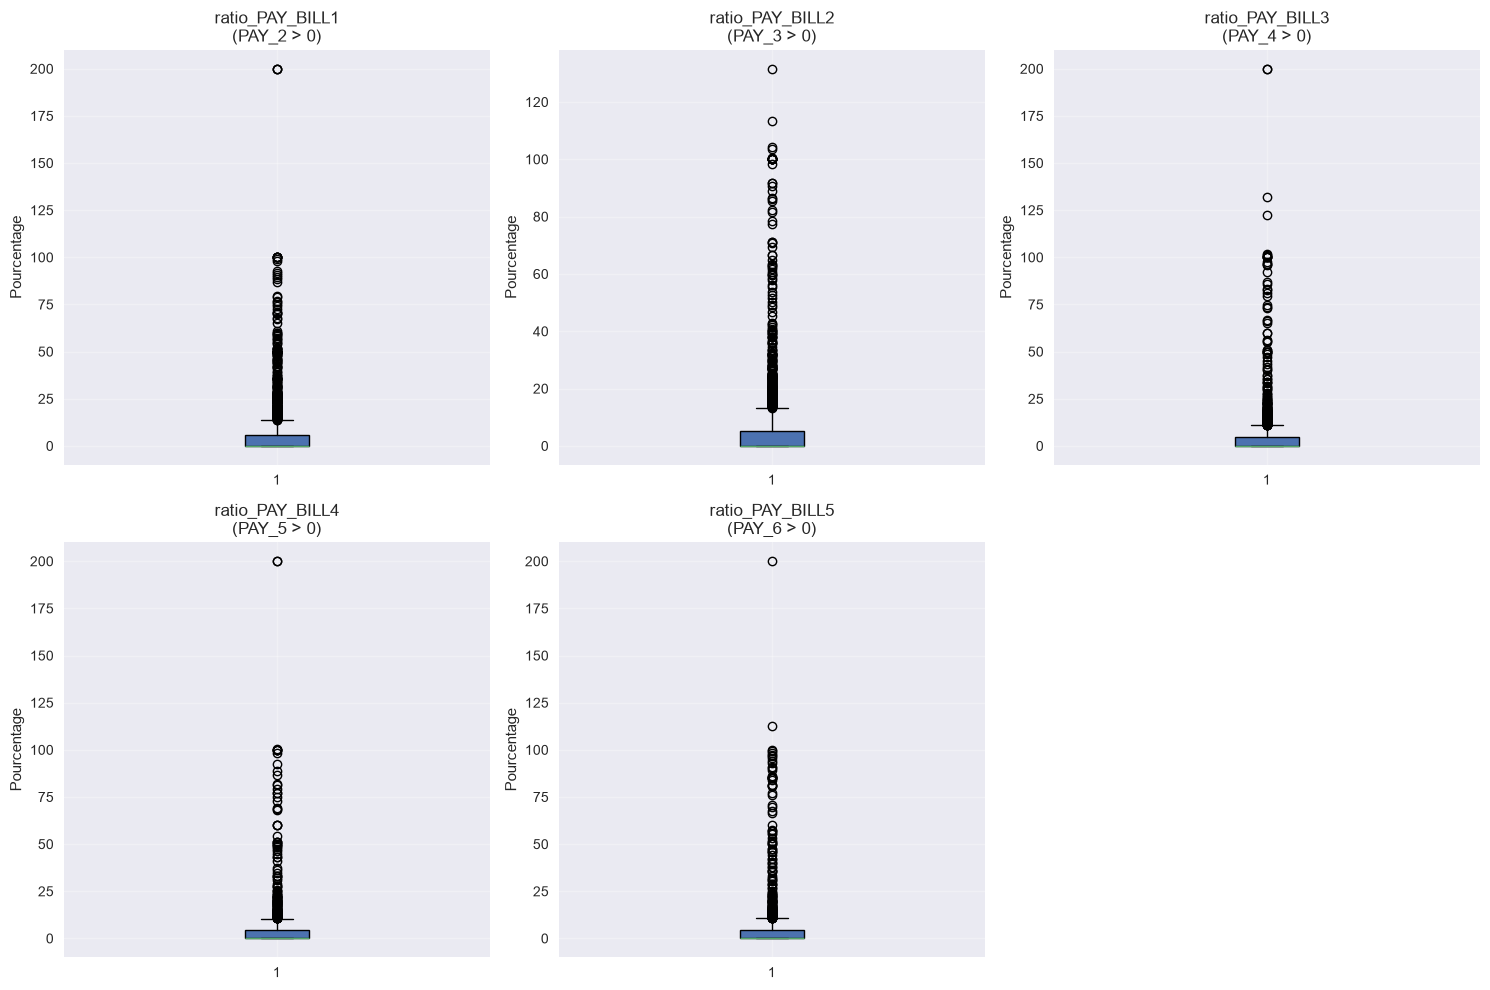

In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Définition des colonnes ratio existantes
ratio_columns = ['ratio_PAY_BILL1', 'ratio_PAY_BILL2', 
                 'ratio_PAY_BILL3', 'ratio_PAY_BILL4', 
                 'ratio_PAY_BILL5']
df_aff = ratios_affichables(df, ratio_columns)  # affichage : factures exigibles seulement

# Analyse statistique pour les valeurs où PAY_n > 0
print("Analyse des ratios avec PAY_n > 0 :\n")

results = []

for col in ratio_columns:
    # Identification de la colonne PAY_n correspondante (ex: PAY_1, PAY_2...)
    pay_n_col = f"PAY_{int(col.replace('ratio_PAY_BILL', '')) + 1}"  # ratio_PAY_BILLn règle BILL_AMT(n+1), codifiée par PAY_(n+1) : ratio_PAY_BILL1 -> PAY_2
    
    # Filtrer les données où PAY_n > 0 (Attention à l'espace dans '> 0')
    filtered_data = df_aff.loc[df[pay_n_col] > 0, col].dropna()
    
    if len(filtered_data) > 0:
        mean_val = filtered_data.mean()
        min_val = filtered_data.min()
        median_val = filtered_data.median()
        max_val = filtered_data.max()
        count = len(filtered_data)
        
        results.append({
            'Colonne': col,
            'Moyenne (PAY_n > 0)': round(mean_val, 2) if not pd.isna(mean_val) else None,
            'Minimum (PAY_n > 0)': round(min_val, 2) if not pd.isna(min_val) else None,
            'Médiane (PAY_n > 0)': round(median_val, 2) if not pd.isna(median_val) else None,
            'Maximum (PAY_n > 0)': round(max_val, 2) if not pd.isna(max_val) else None,
            'Nombre d\'observations': count
        })
    else:
        results.append({
            'Colonne': col,
            'Moyenne (PAY_n > 0)': None,
            'Minimum (PAY_n > 0)': None,
            'Médiane (PAY_n > 0)': None,
            'Maximum (PAY_n > 0)': None,
            'Nombre d\'observations': 0
        })

# Création du tableau de résultats
results_df = pd.DataFrame(results)
print("Statistiques pour les valeurs où PAY_n > 0 :")
print(results_df.to_string(index=False))

# Boxplot individuel pour chaque colonne
plt.figure(figsize=(15, 10))

for i, col in enumerate(ratio_columns):
    plt.subplot(2, 3, i+1)
    
    # Identifier la colonne PAY_n correspondante
    pay_n_col = f"PAY_{int(col.replace('ratio_PAY_BILL', '')) + 1}"  # ratio_PAY_BILLn règle BILL_AMT(n+1), codifiée par PAY_(n+1) : ratio_PAY_BILL1 -> PAY_2
    
    # Filtrer les données où PAY_n > 0 et retirer les NaN du ratio
    filtered_data = df_aff.loc[df[pay_n_col] > 0, col].dropna().dropna()
    
    if len(filtered_data) > 0:
        plt.boxplot(filtered_data, patch_artist=True)
        plt.title(f'{col}\n(PAY_{pay_n_col.split("_")[1]} > 0)')
        plt.ylabel('Pourcentage')
        plt.grid(True, alpha=0.3)
    else:
        # Correction du texte affiché quand il n'y a pas de données
        plt.text(0.5, 0.5, 'Pas de données\n(PAY_n <= 0)', ha='center', va='center', transform=plt.gca().transAxes)
        plt.title(f'{col}\n(PAY_{pay_n_col.split("_")[1]} > 0)')

plt.tight_layout()
plt.show()

Le ratio de remboursement est quasi nul pour les factures codifiées en retard : la plupart ne sont pas payées du tout.

--- Analyse Focus Zone 0-20% ---
Distribution par Bucket (0-20%) :

Condition  PAY <= 0  PAY > 0
Bucket                      
[0, 1)         2514     9876
[1, 2)          551      167
[2, 3)         2995      261
[3, 4)        20760     1685
[4, 5)        14748     1484
[5, 6)         7086      579
[6, 7)         4000      401
[7, 8)         3520      701
[8, 9)         2680      585
[9, 10)        1983      311
[10, 11)       1795      214
[11, 12)       1411      220
[12, 13)       1181      163
[13, 14)       1000      119
[14, 15)        918      113


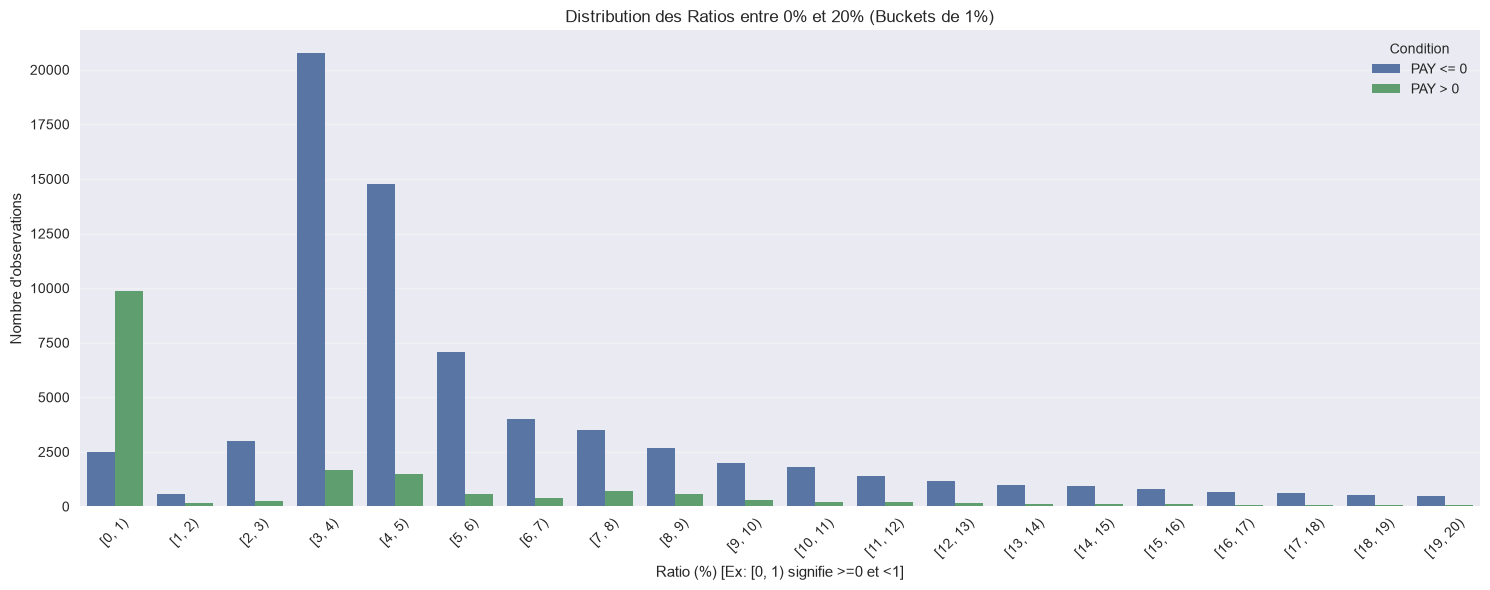


Pourcentage global PAY > 0 avec Ratio >= 20% : 3.44%
Pourcentage global PAY <= 0 avec Ratio >= 20% : 37.68%


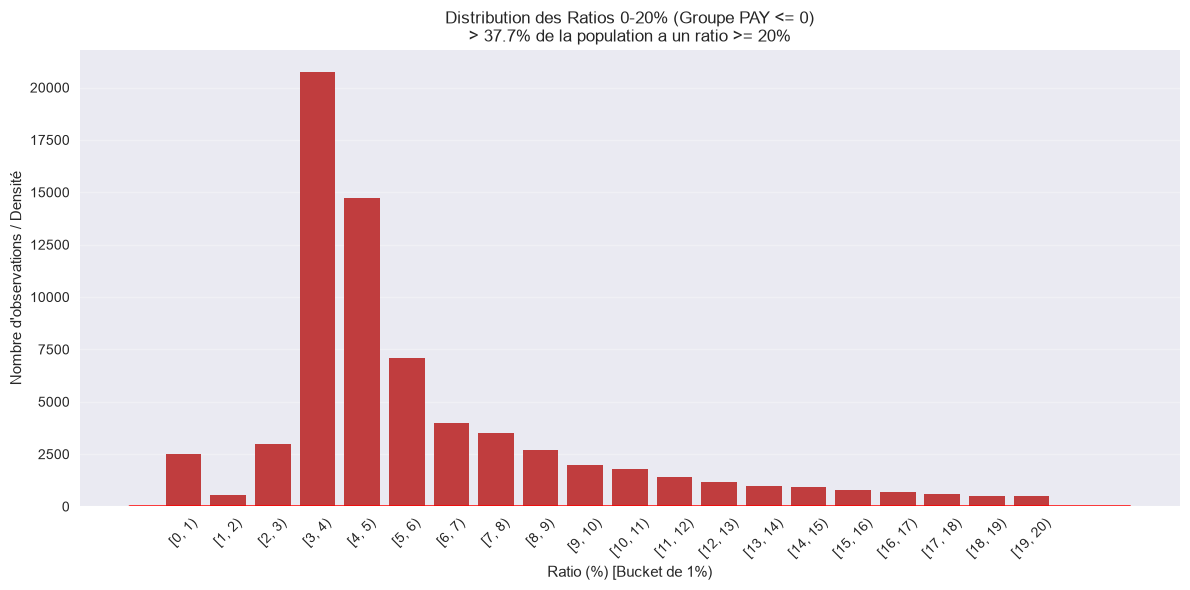

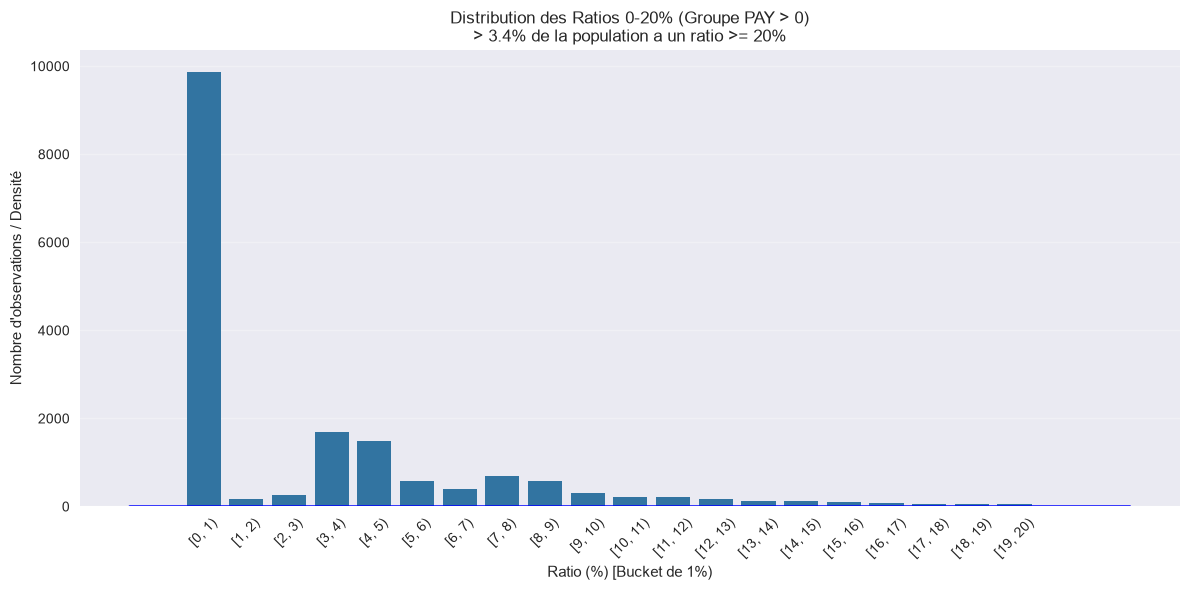

In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tes colonnes définies
ratio_columns = [
    'ratio_PAY_BILL1', 
    'ratio_PAY_BILL2', 
    'ratio_PAY_BILL3', 
    'ratio_PAY_BILL4', 
    'ratio_PAY_BILL5'
]

# On prépare une liste plate pour stocker toutes les lignes de données
data_all = []
print("--- Analyse Focus Zone 0-20% ---")

for col_ratio in ratio_columns:
    # 1. Identifier la colonne PAY associée
    pay_part = col_ratio.split('_to_')[0] 
    base_pay = pay_part.replace('ratio_', '') 
    n = base_pay.replace('PAY_BILL', '') 
    
    # On construit le nom de la colonne PAY correspondante (ex: 'PAY1')
    col_pay = f"PAY_{int(n) + 1}"  # codification de la facture réglée : PAY_(n+1)
    
    # Vérification de sécurité avec fallback
    if col_pay not in df.columns:
        col_pay_fallback = f"PAY_AMT{n}"
        if col_pay_fallback in df.columns:
            col_pay = col_pay_fallback
        else:
            print(f"Avertissement: Colonne {col_pay} et {col_pay_fallback} non trouvées pour {col_ratio}")
            continue

    # 2. Extraction des données
    bill_col_target = f'BILL_AMT{int(n)+1}'
    
    # On considère le ratio valide si Bill > 0
    mask_valid = df[col_ratio].notna() & (df[bill_col_target] > 0)
    valid_ratios = df.loc[mask_valid, col_ratio].dropna()
    
    if len(valid_ratios) == 0:
        continue

    # 3. Filtre de la zone d'intérêt (0% à 20%)
    mask_zone = (valid_ratios >= 0) & (valid_ratios < 20)
    ratios_in_zone = valid_ratios[mask_zone]
    
    if len(ratios_in_zone) == 0:
        continue
        
    # 4. Condition sur le paiement PAY_n
    pay_values = df.loc[valid_ratios.index, col_pay]
    
    for is_positive in [True, False]:
        if is_positive:
            cond_name = "PAY > 0"
            cond_mask = pay_values > 0
        else:
            cond_name = "PAY <= 0"
            cond_mask = pay_values <= 0
            
        data_cond = ratios_in_zone[cond_mask]
        
        if len(data_cond) > 0:
            # Création des buckets de 1%
            bins_edges = np.arange(0, 21, 1) 
            buckets = pd.cut(data_cond, bins=bins_edges, right=False, include_lowest=True)
            
            df_temp = pd.DataFrame({
                'Ratio_Value': data_cond.values,
                'Bucket': buckets.astype(str),
                'Condition': cond_name
            })
            data_all.append(df_temp)

# --- Traitement Global et Premier Graphique (Non modifié) ---
if not data_all:
    print("Aucune donnée trouvée dans la zone 0-20%.")
else:
    df_all_buckets = pd.concat(data_all, ignore_index=True)
    
    # Définition de l'ordre explicite des catégories
    levels = [f"[{i}, {i+1})" for i in range(0, 20)]
    df_all_buckets['Bucket'] = pd.Categorical(df_all_buckets['Bucket'], categories=levels, ordered=True)

    # Tableau récapitulatif
    df_counts = df_all_buckets.groupby(['Bucket', 'Condition']).size().unstack(fill_value=0)
    print("Distribution par Bucket (0-20%) :\n")
    print(df_counts.head(15)) 

    # --- GRAPHIQUE 1 : Barplot global 0-20% (PAY > 0 ET PAY <= 0 confondus) ---
    plt.figure(figsize=(15, 6))
    counts = df_all_buckets.value_counts(['Bucket', 'Condition'])
    
    sns.barplot(
        x=counts.index.get_level_values('Bucket'), 
        y=counts.values, 
        hue=counts.index.get_level_values('Condition')
    )
    
    plt.title('Distribution des Ratios entre 0% et 20% (Buckets de 1%)')
    plt.xlabel('Ratio (%) [Ex: [0, 1) signifie >=0 et <1]')
    plt.ylabel('Nombre d\'observations')
    plt.xticks(ticks=range(len(levels)), labels=levels, rotation=45) 
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- GRAPHIQUES 2 & 3 : Séparés par Condition avec Statistiques > 20% ---
    
    # Réinitialisation pour cumul brut
    cum_high_pos = 0
    cum_total_pos = 0
    cum_high_neg = 0
    cum_total_neg = 0

    for col_ratio in ratio_columns:
        pay_part = col_ratio.split('_to_')[0] 
        base_pay = pay_part.replace('ratio_', '') 
        n_str = base_pay.replace('PAY_BILL', '') 
        col_pay_name = f"PAY_{int(n_str) + 1}"  # codification de la facture réglée : PAY_(n+1)
        if col_pay_name not in df.columns:
            col_pay_name = f"PAY_AMT_{n_str}"
            
        if col_pay_name in df.columns:
            bill_col_target = f'BILL_AMT{int(n_str)+1}'
            mask_valid_total = df[col_ratio].notna() & (df[bill_col_target] > 0)
            valid_ratios_all = df.loc[mask_valid_total, col_ratio]
            pay_vals = df.loc[valid_ratios_all.index, col_pay_name]
            
            # Groupe PAY > 0
            mask_pos = pay_vals > 0
            cum_total_pos += mask_pos.sum()
            # On compte ceux qui sont >= 20
            vals_pos = valid_ratios_all[mask_pos]
            cum_high_pos += vals_pos[(vals_pos >= 20)].notna().sum()

            # Groupe PAY <= 0
            mask_neg = pay_vals <= 0
            cum_total_neg += mask_neg.sum()
            vals_neg = valid_ratios_all[mask_neg]
            cum_high_neg += vals_neg[(vals_neg >= 20)].notna().sum()

    # Pourcentages finaux
    final_pct_high_pos = (cum_high_pos / cum_total_pos * 100) if cum_total_pos > 0 else 0
    final_pct_high_neg = (cum_high_neg / cum_total_neg * 100) if cum_total_neg > 0 else 0

    print(f"\nPourcentage global PAY > 0 avec Ratio >= 20% : {final_pct_high_pos:.2f}%")
    print(f"Pourcentage global PAY <= 0 avec Ratio >= 20% : {final_pct_high_neg:.2f}%")

    # --- GRAPHIQUE 2 : Zoom pour PAY <= 0 ---
    df_neg = df_all_buckets[df_all_buckets['Condition'] == 'PAY <= 0'].copy()
    if len(df_neg) > 0:
        levels = [f"[{i}, {i+1})" for i in range(0, 20)]
        df_neg['Bucket'] = pd.Categorical(df_neg['Bucket'], categories=levels, ordered=True)

        plt.figure(figsize=(12, 6))
        
        # Histogramme des buckets 0-20%
        counts_neg = df_neg.value_counts(['Bucket', 'Condition'])
        sns.barplot(
            x=counts_neg.index.get_level_values('Bucket'), 
            y=counts_neg.values, 
            color='#d62728' # Rouge
        )
        
        # Courbe KDE sur les données brutes du groupe
        if len(df_neg) > 0:
            sns.kdeplot(data=df_neg[df_neg['Ratio_Value'] < 20], x='Ratio_Value', color='red')

        plt.title(f'Distribution des Ratios 0-20% (Groupe PAY <= 0)\n> {final_pct_high_neg:.1f}% de la population a un ratio >= 20%')
        plt.xlabel('Ratio (%) [Bucket de 1%)')
        plt.ylabel('Nombre d\'observations / Densité')
        plt.xticks(ticks=range(len(levels)), labels=levels, rotation=45)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("Pas de données dans le groupe PAY <= 0 pour afficher le graphique.")

    # --- GRAPHIQUE 3 : Zoom pour PAY > 0 ---
    df_pos = df_all_buckets[df_all_buckets['Condition'] == 'PAY > 0'].copy()
    if len(df_pos) > 0:
        levels = [f"[{i}, {i+1})" for i in range(0, 20)]
        df_pos['Bucket'] = pd.Categorical(df_pos['Bucket'], categories=levels, ordered=True)

        plt.figure(figsize=(12, 6))
        
        # Histogramme des buckets 0-20%
        counts_pos = df_pos.value_counts(['Bucket', 'Condition'])
        sns.barplot(
            x=counts_pos.index.get_level_values('Bucket'), 
            y=counts_pos.values, 
            color='#1f77b4' # Bleu
        )
        
        # Courbe KDE sur les données brutes du groupe
        if len(df_pos) > 0:
            sns.kdeplot(data=df_pos[df_pos['Ratio_Value'] < 20], x='Ratio_Value', color='blue')

        plt.title(f'Distribution des Ratios 0-20% (Groupe PAY > 0)\n> {final_pct_high_pos:.1f}% de la population a un ratio >= 20%')
        plt.xlabel('Ratio (%) [Bucket de 1%)')
        plt.ylabel('Nombre d\'observations / Densité')
        plt.xticks(ticks=range(len(levels)), labels=levels, rotation=45)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("Pas de données dans le groupe PAY > 0 pour afficher le graphique.")

C'est intéressant mais on regarde également le ratio payé par des gens qui sont suceptibles d'agraver ou de diminuer leur retard.  
Tentons de regarder le ratio selon que les gens n'agravent pas leur retard ou l'agravent

--- Analyse Focus Zone 0-20% (codification de la facture PAY_(n+1) comparée à celle d'avant PAY_(n+2)) ---

% Global Groupe 'Stagnant/Baisse' >= 20% : 34.94%
% Global Groupe 'Hausse' >= 20%           : 1.23%


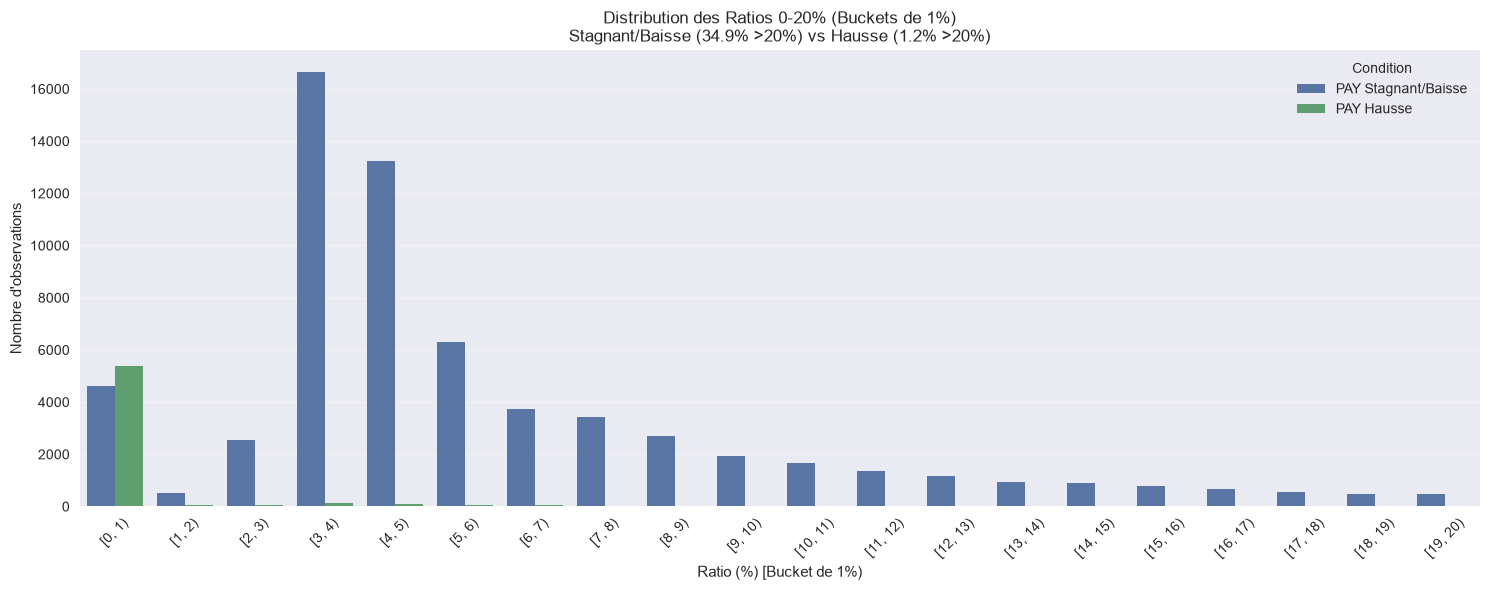

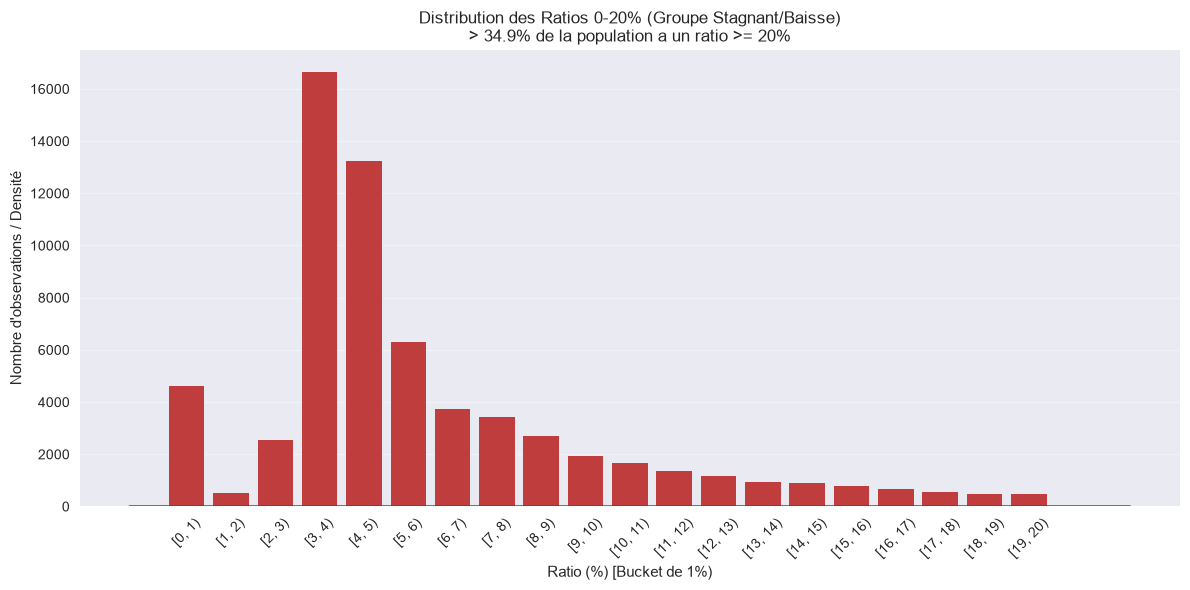

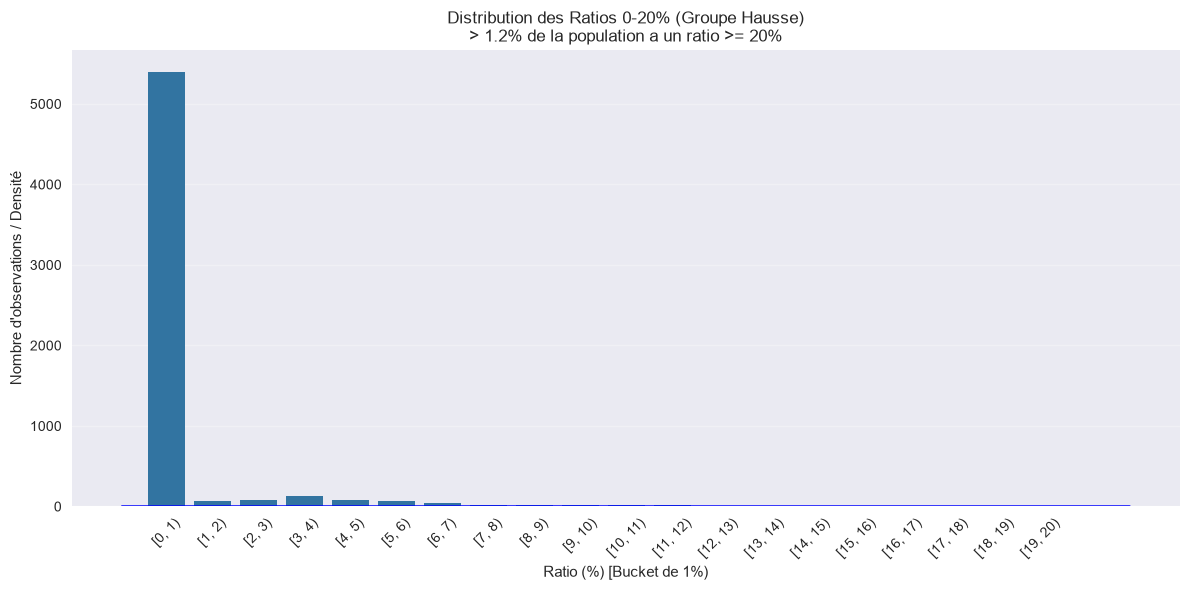

In [168]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tes colonnes définies
ratio_columns = [
    'ratio_PAY_BILL1', 
    'ratio_PAY_BILL2', 
    'ratio_PAY_BILL3', 
    'ratio_PAY_BILL4'
]

data_all = []
print("--- Analyse Focus Zone 0-20% (codification de la facture PAY_(n+1) comparée à celle d'avant PAY_(n+2)) ---")

# Pour calculer le % global > 20% par groupe à la fin
stats_globales = {
    'PAY Stagnant/Baisse': {'total': 0, 'high': 0},
    'PAY Hausse': {'total': 0, 'high': 0}
}

for col_ratio in ratio_columns:
    # 1. Identifier la codification de la facture réglée (PAY_(n+1))
    pay_part = col_ratio.split('_to_')[0] 
    base_pay = pay_part.replace('ratio_', '') 
    n_str = base_pay.replace('PAY_BILL', '') 
    
    col_pay_n = f"PAY_{int(n_str) + 1}"  # codification de la facture réglée par ce paiement
    if col_pay_n not in df.columns:
        col_pay_n = f"PAY_AMT{n_str}" # Fallback
    
    if col_pay_n not in df.columns:
        continue

    # 2. Identifier la codification du mois d'avant, PAY_(n+2)
    n_next = int(n_str) + 2  # codification du mois d'avant
    col_pay_next = f"PAY_{n_next}"
    
    if col_pay_next not in df.columns:
        col_pay_next_fallback = f"PAY_AMT{n_next}"
        if col_pay_next_fallback in df.columns:
            col_pay_next = col_pay_next_fallback
        else:
            continue # Si la colonne suivante n'existe pas, on passe cette boucle

    # 3. Extraction : On ne garde que les ratios qui existent (non-NaN)
    mask_valid = df[col_ratio].notna() & (df[f'BILL_AMT{int(n_str) + 1}'] > 0)  # affichage : factures exigibles seulement
    df_subset = df[mask_valid]
    
    if len(df_subset) == 0:
        continue

    ratios = df_subset[col_ratio]
    pay_n_vals = df_subset[col_pay_n]
    pay_next_vals = df_subset[col_pay_next]

    # --- Logique de groupement dynamique ---
    # On ne compare que si la codification d'avant existe aussi (sinon pas de comparaison possible)
    valid_dynamic_mask = pay_next_vals.notna()
    
    pay_n_comp = pay_n_vals[valid_dynamic_mask]
    pay_next_comp = pay_next_vals[valid_dynamic_mask]
    ratios_comp = ratios[valid_dynamic_mask]

    # Groupe A : STAGNANT / BAISSE (PAY_(n+1) <= 0 OU PAY_(n+1) <= PAY_(n+2))
    mask_stagnant = (pay_n_comp <= 0) | (pay_n_comp <= pay_next_comp)
    
    # Groupe B : HAUSSE (PAY_(n+1) > 0 ET PAY_(n+1) > PAY_(n+2))
    mask_hausse = (pay_n_comp > 0) & (pay_n_comp > pay_next_comp)

    # --- Stats Globales pour le % > 20% (sur tout le groupe, pas juste < 20%) ---
    stats_globales['PAY Stagnant/Baisse']['total'] += mask_stagnant.sum()
    stats_globales['PAY Stagnant/Baisse']['high'] += ratios_comp[mask_stagnant][ratios_comp[mask_stagnant] >= 20].notna().sum()
    
    stats_globales['PAY Hausse']['total'] += mask_hausse.sum()
    stats_globales['PAY Hausse']['high'] += ratios_comp[mask_hausse][ratios_comp[mask_hausse] >= 20].notna().sum()

    # --- Filtrage Zone [0, 20%) pour les graphiques ---
    
    def process_group(ratios_grp, cond_name):
        if len(ratios_grp) == 0:
            return None
        
        # Filtre zone 0-20
        mask_zone = (ratios_grp >= 0) & (ratios_grp < 20)
        vals_in_zone = ratios_grp[mask_zone]
        
        if len(vals_in_zone) == 0:
            return None
        
        bins_edges = np.arange(0, 21, 1) 
        buckets = pd.cut(vals_in_zone, bins=bins_edges, right=False, include_lowest=True)
        
        # On retourne un dataframe propre pour que seaborn soit content
        df_res = pd.DataFrame({
            'Bucket': buckets.astype(str),
            'Condition': cond_name,
            'Ratio_Value': vals_in_zone.values
        })
        return df_res

    df_stag = process_group(ratios_comp[mask_stagnant], "PAY Stagnant/Baisse")
    if df_stag is not None:
        data_all.append(df_stag)

    df_haut = process_group(ratios_comp[mask_hausse], "PAY Hausse")
    if df_haut is not None:
        data_all.append(df_haut)

# --- Calculs finaux des % > 20% ---
pct_stag_gt_20 = (stats_globales['PAY Stagnant/Baisse']['high'] / stats_globales['PAY Stagnant/Baisse']['total'] * 100) if stats_globales['PAY Stagnant/Baisse']['total'] > 0 else 0
pct_haut_gt_20 = (stats_globales['PAY Hausse']['high'] / stats_globales['PAY Hausse']['total'] * 100) if stats_globales['PAY Hausse']['total'] > 0 else 0

print(f"\n% Global Groupe 'Stagnant/Baisse' >= 20% : {pct_stag_gt_20:.2f}%")
print(f"% Global Groupe 'Hausse' >= 20%           : {pct_haut_gt_20:.2f}%")

# --- Graphiques ---

if not data_all:
    print("Aucune donnée dans la zone 0-20%.")
else:
    df_all_buckets = pd.concat(data_all, ignore_index=True)
    levels = [f"[{i}, {i+1})" for i in range(0, 20)]
    df_all_buckets['Bucket'] = pd.Categorical(df_all_buckets['Bucket'], categories=levels, ordered=True)

    # GRAPHIQUE 1 : Global (Les deux groupes comparés)
    plt.figure(figsize=(15, 6))
    
    # On utilise value_counts pour avoir un comptage propre par bucket et condition
    counts = df_all_buckets.value_counts(['Bucket', 'Condition'])
    
    sns.barplot(
        x=counts.index.get_level_values('Bucket'), 
        y=counts.values, 
        hue=counts.index.get_level_values('Condition') # Ici c'est OK car on passe le dataframe complet via index
    )
    plt.title(f'Distribution des Ratios 0-20% (Buckets de 1%)\nStagnant/Baisse ({pct_stag_gt_20:.1f}% >20%) vs Hausse ({pct_haut_gt_20:.1f}% >20%)')
    plt.xlabel('Ratio (%) [Bucket de 1%)')
    plt.ylabel('Nombre d\'observations')
    plt.xticks(ticks=range(len(levels)), labels=levels, rotation=45) 
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # GRAPHIQUE 2 : Zoom Stagnant/Baisse
    df_stag_only = df_all_buckets[df_all_buckets['Condition'] == "PAY Stagnant/Baisse"]
    
    if len(df_stag_only) > 0:
        levels = [f"[{i}, {i+1})" for i in range(0, 20)]
        df_stag_only['Bucket'] = pd.Categorical(df_stag_only['Bucket'], categories=levels, ordered=True)
        
        plt.figure(figsize=(12, 6))
        
        # Comptage propre pour le barplot
        counts_neg = df_stag_only.value_counts(['Bucket', 'Condition'])
        sns.barplot(
            x=counts_neg.index.get_level_values('Bucket'), 
            y=counts_neg.values, 
            color='#d62728'
        )
        
        # KDE sur les valeurs brutes de ce groupe (fibrées à < 20)
        sns.kdeplot(data=df_stag_only[df_stag_only['Ratio_Value'] < 20], x='Ratio_Value', color='red')
        
        plt.title(f'Distribution des Ratios 0-20% (Groupe Stagnant/Baisse)\n> {pct_stag_gt_20:.1f}% de la population a un ratio >= 20%')
        plt.xlabel('Ratio (%) [Bucket de 1%)')
        plt.ylabel('Nombre d\'observations / Densité')
        plt.xticks(ticks=range(len(levels)), labels=levels, rotation=45)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

    # GRAPHIQUE 3 : Zoom Hausse
    df_haut_only = df_all_buckets[df_all_buckets['Condition'] == "PAY Hausse"]
    
    if len(df_haut_only) > 0:
        levels = [f"[{i}, {i+1})" for i in range(0, 20)]
        df_haut_only['Bucket'] = pd.Categorical(df_haut_only['Bucket'], categories=levels, ordered=True)
        
        plt.figure(figsize=(12, 6))
        
        # Comptage propre pour le barplot
        counts_pos = df_haut_only.value_counts(['Bucket', 'Condition'])
        sns.barplot(
            x=counts_pos.index.get_level_values('Bucket'), 
            y=counts_pos.values, 
            color='#1f77b4'
        )
        
        # KDE sur les valeurs brutes de ce groupe (filtrées à < 20)
        sns.kdeplot(data=df_haut_only[df_haut_only['Ratio_Value'] < 20], x='Ratio_Value', color='blue')
        
        plt.title(f'Distribution des Ratios 0-20% (Groupe Hausse)\n> {pct_haut_gt_20:.1f}% de la population a un ratio >= 20%')
        plt.xlabel('Ratio (%) [Bucket de 1%)')
        plt.ylabel('Nombre d\'observations / Densité')
        plt.xticks(ticks=range(len(levels)), labels=levels, rotation=45)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

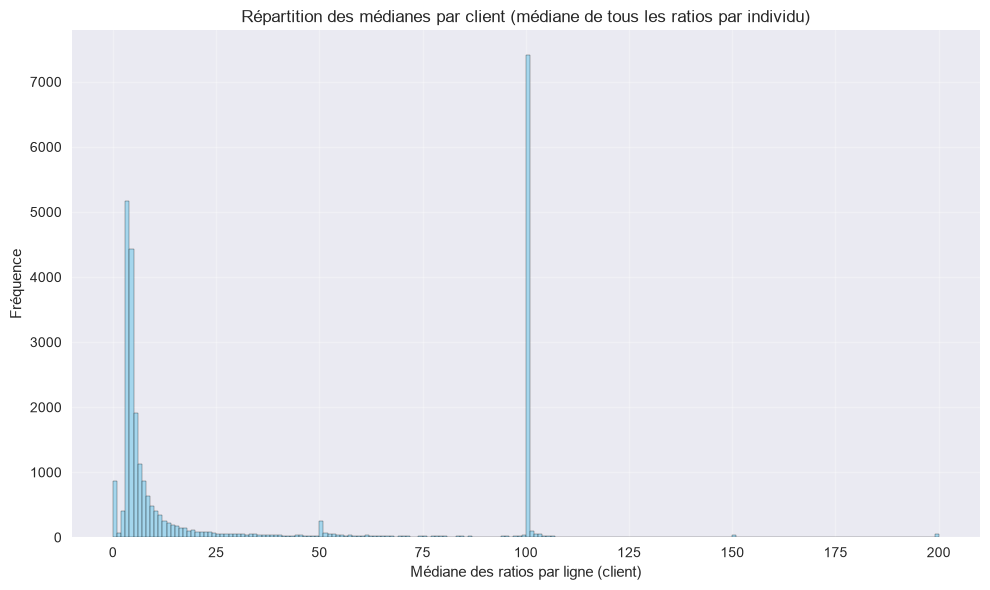

Statistiques de la répartition des médianes par client :
Nombre total de clients : 28590
Moyenne des médianes : 36.1739
Médiane : 7.3601
Écart-type : 43.1257
Minimum : 0.0000
Maximum : 200.0000


In [169]:
import matplotlib.pyplot as plt

# Définir les colonnes des ratios
ratio_columns = [
    'ratio_PAY_BILL1',
    'ratio_PAY_BILL2', 
    'ratio_PAY_BILL3', 
    'ratio_PAY_BILL4', 
    'ratio_PAY_BILL5'
]

# Calculer la médiane de chaque ligne (médiane des ratios pour chaque client)
# Colonne créée : définition unique (docs/colonnes_creees.md)
df['ratio_PAY_to_BILL_median'] = df[ratio_columns].median(axis=1)
# Graphique : médiane des seuls mois avec une facture exigible
row_medians = ratios_affichables(df, ratio_columns).median(axis=1).dropna()

# Enregistrer la médiane dans une nouvelle colonne du DataFrame

# Créer l'histogramme
plt.figure(figsize=(10, 6))
plt.hist(row_medians, bins=200, color='skyblue', edgecolor='black', alpha=0.7)

# Ajouter les étiquettes et le titre
plt.xlabel('Médiane des ratios par ligne (client)')
plt.ylabel('Fréquence')
plt.title('Répartition des médianes par client (médiane de tous les ratios par individu)')
plt.grid(True, alpha=0.3)

# Afficher le graphique
plt.tight_layout()
plt.show()

# Afficher quelques statistiques descriptives
print("Statistiques de la répartition des médianes par client :")
print(f"Nombre total de clients : {len(row_medians)}")
print(f"Moyenne des médianes : {row_medians.mean():.4f}")
print(f"Médiane : {row_medians.median():.4f}")
print(f"Écart-type : {row_medians.std():.4f}")
print(f"Minimum : {row_medians.min():.4f}")
print(f"Maximum : {row_medians.max():.4f}")

**Interprétation**  
2 comportements de paiement distincts :
- le paiement par mensualité, le client rembourse des intérets et une partie du capital
- le paiement comptant à l'échéance, le client paie l'intégralité de ses dépenses du mois

**Interprétation**  
Les clients dont le retard s'aggrave n'ont presque rien payé, la plupart rien du tout ; ceux qui restent à jour ou dont le retard ne monte pas paient une part réelle de leur facture. Il y a bien une fracture : ne rien payer fait tomber en retard.  
Autre constat : un groupe important de clients paient entre 3 et 5 % de la facture, la mensualité minimale.

=== Médiane des PAY_ par groupe ===
Médiane des PAY_ pour ratio_PAY_to_BILL_median [90; 110] : -1.0000
Médiane des PAY_ pour ratio_PAY_to_BILL_median > 90 : -1.0000


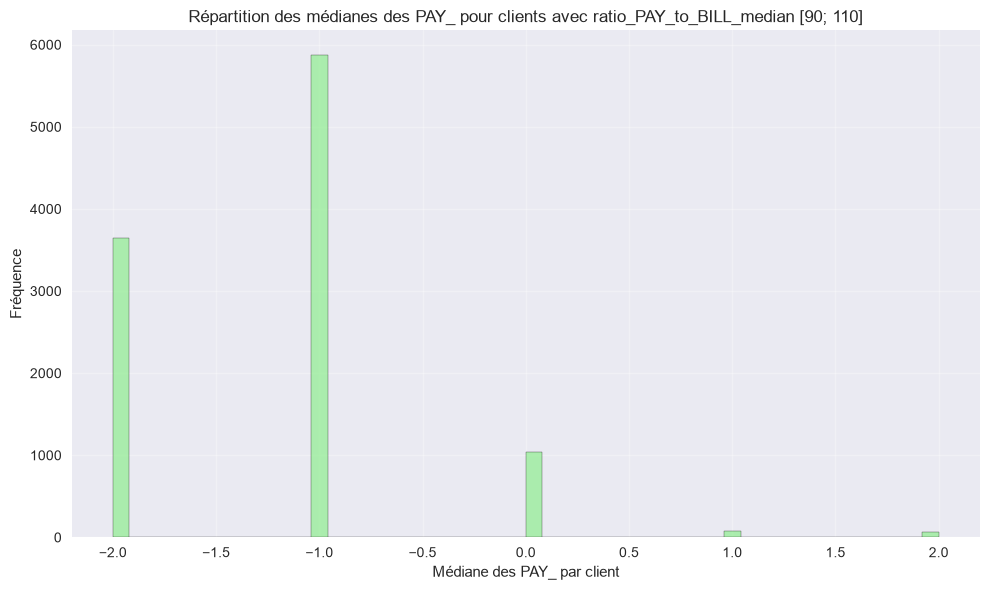

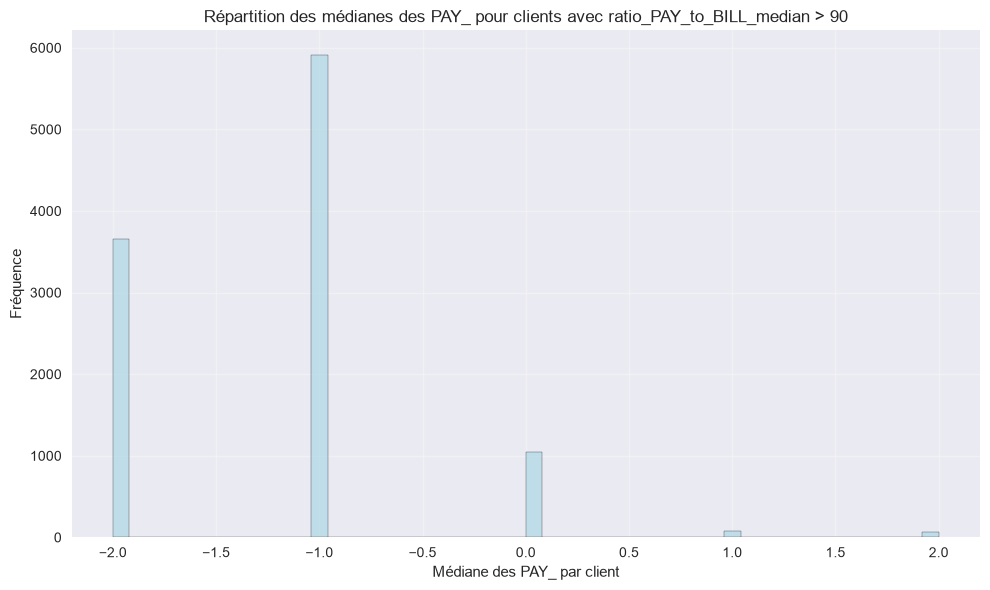

In [170]:
import matplotlib.pyplot as plt

# Définir les colonnes PAY_
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5']

# Calculer la médiane des PAY_ pour les clients avec ratio_PAY_to_BILL_median compris entre 90 et 110
mask_90_110 = (df['ratio_PAY_to_BILL_median'] >= 90) & (df['ratio_PAY_to_BILL_median'] <= 110)
median_pay_90_110 = df.loc[mask_90_110, pay_columns].median(axis=1).median()

# Calculer la médiane des PAY_ pour les clients avec ratio_PAY_to_BILL_median > 90
mask_gt_90 = df['ratio_PAY_to_BILL_median'] > 90
median_pay_gt_90 = df.loc[mask_gt_90, pay_columns].median(axis=1).median()

# Afficher les résultats
print("=== Médiane des PAY_ par groupe ===")
print(f"Médiane des PAY_ pour ratio_PAY_to_BILL_median [90; 110] : {median_pay_90_110:.4f}")
print(f"Médiane des PAY_ pour ratio_PAY_to_BILL_median > 90 : {median_pay_gt_90:.4f}")

# Créer un histogramme de la distribution des PAY_ pour le groupe [90; 110]
if mask_90_110.sum() > 0:
    pay_medians_90_110 = df.loc[mask_90_110, pay_columns].median(axis=1)
    plt.figure(figsize=(10, 6))
    plt.hist(pay_medians_90_110, bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
    plt.xlabel('Médiane des PAY_ par client')
    plt.ylabel('Fréquence')
    plt.title('Répartition des médianes des PAY_ pour clients avec ratio_PAY_to_BILL_median [90; 110]')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Créer un histogramme de la distribution des PAY_ pour le groupe > 90
if mask_gt_90.sum() > 0:
    pay_medians_gt_90 = df.loc[mask_gt_90, pay_columns].median(axis=1)
    plt.figure(figsize=(10, 6))
    plt.hist(pay_medians_gt_90, bins=50, color='lightblue', edgecolor='black', alpha=0.7)
    plt.xlabel('Médiane des PAY_ par client')
    plt.ylabel('Fréquence')
    plt.title('Répartition des médianes des PAY_ pour clients avec ratio_PAY_to_BILL_median > 90')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

=== Valeur la plus fréquente des PAY_ par groupe ===
Valeur la plus fréquente pour ratio_PAY_to_BILL_median [90; 110] : -1.0000
Valeur la plus fréquente pour ratio_PAY_to_BILL_median > 90 : -1.0000


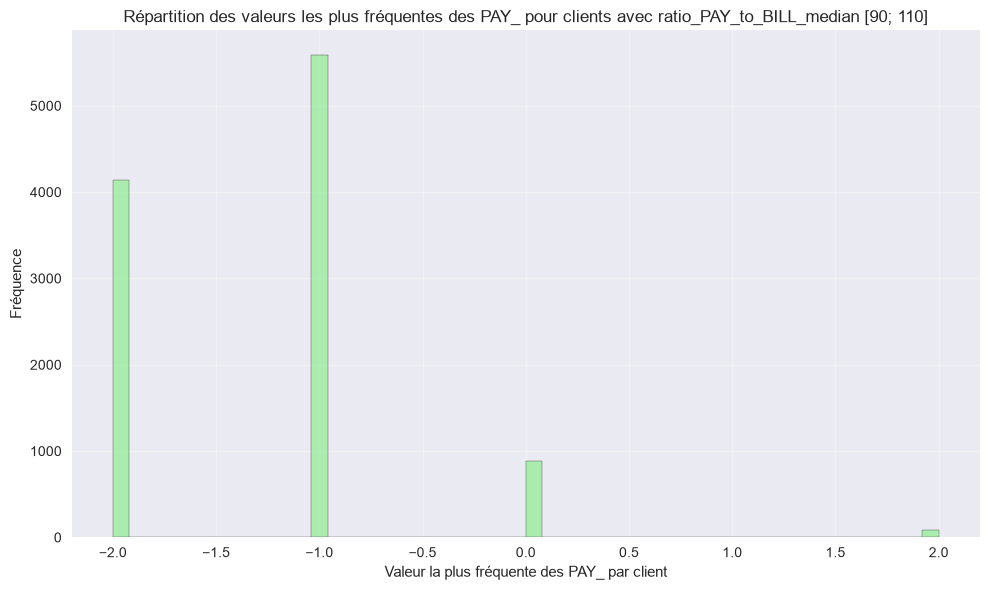

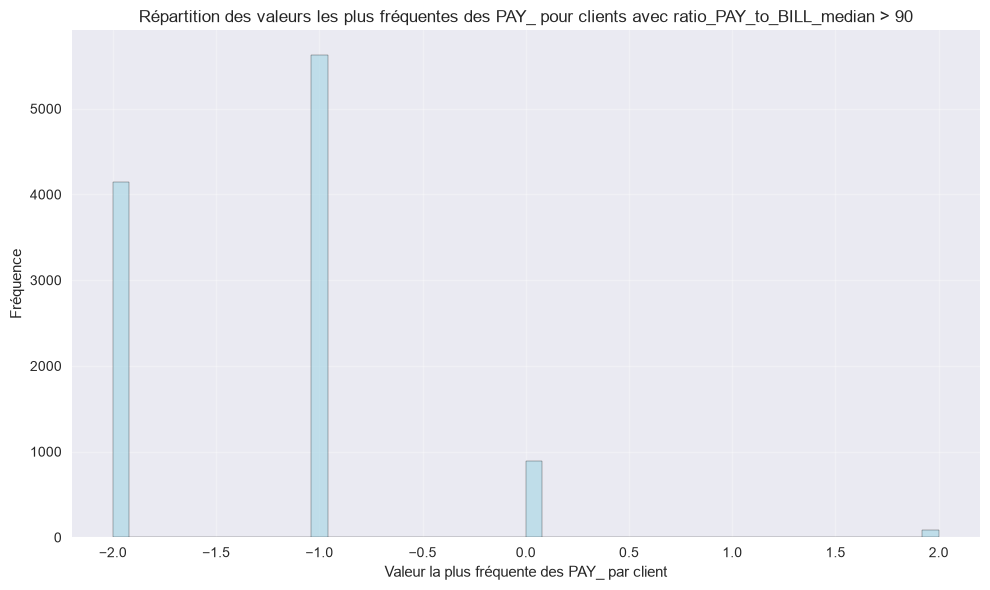

In [171]:
import matplotlib.pyplot as plt
from scipy.stats import mode

# Définir les colonnes PAY_
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5']

# Calculer la valeur la plus fréquente des PAY_ pour les clients avec ratio_PAY_to_BILL_median compris entre 90 et 110
mask_90_110 = (df['ratio_PAY_to_BILL_median'] >= 90) & (df['ratio_PAY_to_BILL_median'] <= 110)
# Pour chaque client, on calcule le mode de ses PAY_ valeurs
mode_pay_90_110 = []
for idx in df.loc[mask_90_110].index:
    client_values = df.loc[idx, pay_columns]
    # On prend toutes les valeurs sans exclusion
    if len(client_values) > 0:
        mode_result = mode(client_values, keepdims=True)
        mode_pay_90_110.append(mode_result.mode[0])
    else:
        mode_pay_90_110.append(0)

# Calculer la valeur la plus fréquente globale
mode_pay_90_110 = pd.Series(mode_pay_90_110).mode()[0] if len(mode_pay_90_110) > 0 else 0

# Calculer la valeur la plus fréquente des PAY_ pour les clients avec ratio_PAY_to_BILL_median > 90
mask_gt_90 = df['ratio_PAY_to_BILL_median'] > 90
mode_pay_gt_90 = []
for idx in df.loc[mask_gt_90].index:
    client_values = df.loc[idx, pay_columns]
    # On prend toutes les valeurs sans exclusion
    if len(client_values) > 0:
        mode_result = mode(client_values, keepdims=True)
        mode_pay_gt_90.append(mode_result.mode[0])
    else:
        mode_pay_gt_90.append(0)

# Calculer la valeur la plus fréquente globale
mode_pay_gt_90 = pd.Series(mode_pay_gt_90).mode()[0] if len(mode_pay_gt_90) > 0 else 0

# Afficher les résultats
print("=== Valeur la plus fréquente des PAY_ par groupe ===")
print(f"Valeur la plus fréquente pour ratio_PAY_to_BILL_median [90; 110] : {mode_pay_90_110:.4f}")
print(f"Valeur la plus fréquente pour ratio_PAY_to_BILL_median > 90 : {mode_pay_gt_90:.4f}")

# Créer un histogramme de la distribution des valeurs les plus fréquentes pour le groupe [90; 110]
if mask_90_110.sum() > 0:
    # Recalculer les modes pour chaque client dans ce groupe
    pay_modes_90_110 = []
    for idx in df.loc[mask_90_110].index:
        client_values = df.loc[idx, pay_columns]
        if len(client_values) > 0:
            mode_result = mode(client_values, keepdims=True)
            pay_modes_90_110.append(mode_result.mode[0])
        else:
            pay_modes_90_110.append(0)
    
    plt.figure(figsize=(10, 6))
    plt.hist(pay_modes_90_110, bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
    plt.xlabel('Valeur la plus fréquente des PAY_ par client')
    plt.ylabel('Fréquence')
    plt.title('Répartition des valeurs les plus fréquentes des PAY_ pour clients avec ratio_PAY_to_BILL_median [90; 110]')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Créer un histogramme de la distribution des valeurs les plus fréquentes pour le groupe > 90
if mask_gt_90.sum() > 0:
    # Recalculer les modes pour chaque client dans ce groupe
    pay_modes_gt_90 = []
    for idx in df.loc[mask_gt_90].index:
        client_values = df.loc[idx, pay_columns]
        if len(client_values) > 0:
            mode_result = mode(client_values, keepdims=True)
            pay_modes_gt_90.append(mode_result.mode[0])
        else:
            pay_modes_gt_90.append(0)
    
    plt.figure(figsize=(10, 6))
    plt.hist(pay_modes_gt_90, bins=50, color='lightblue', edgecolor='black', alpha=0.7)
    plt.xlabel('Valeur la plus fréquente des PAY_ par client')
    plt.ylabel('Fréquence')
    plt.title('Répartition des valeurs les plus fréquentes des PAY_ pour clients avec ratio_PAY_to_BILL_median > 90')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

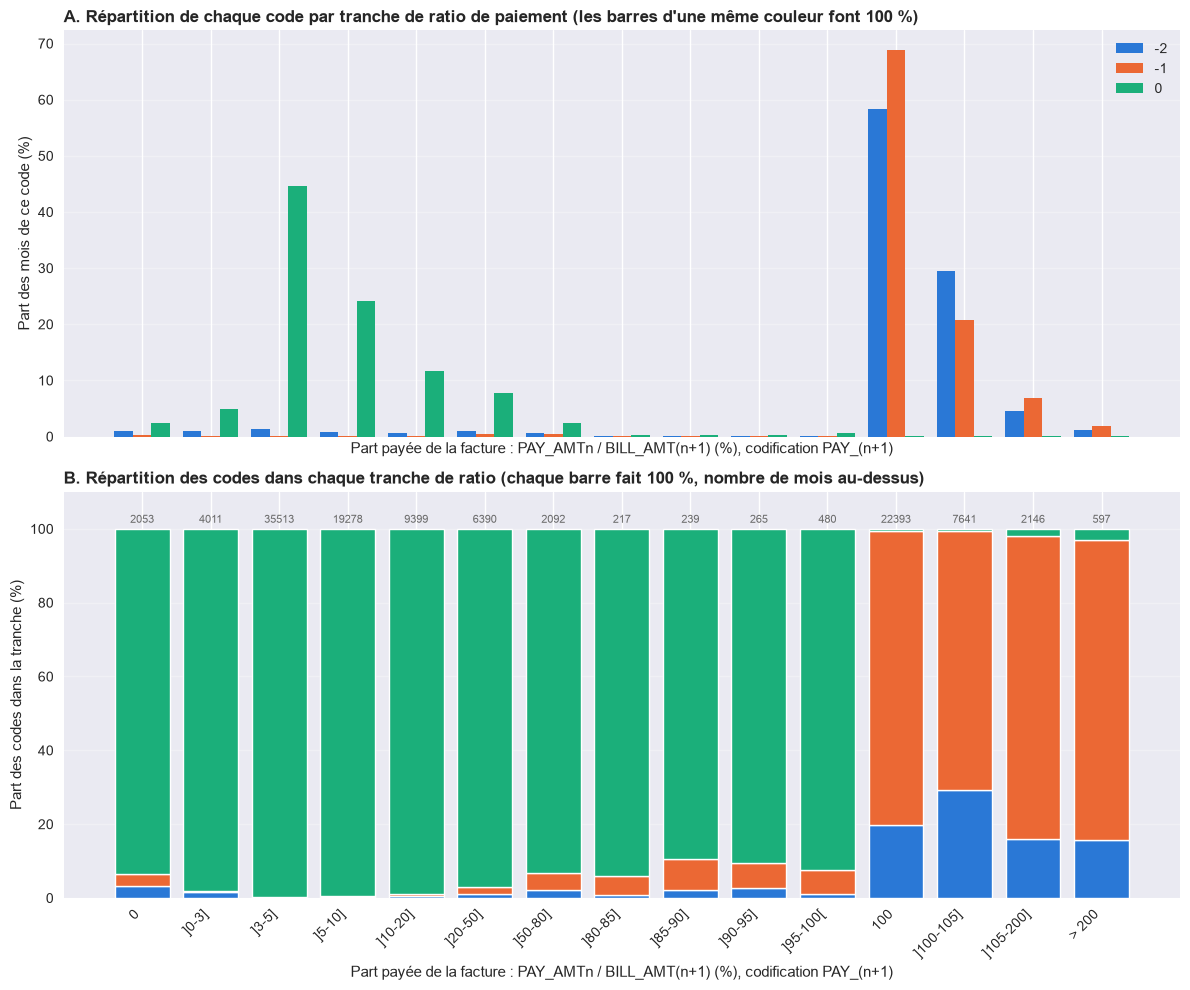

Quartiles du ratio de paiement par code (%) :


,0.10,0.25,0.50,0.75,0.90
Code,,,,,
-2,100.0,100.0,100.0,100.4,101.0
-1,100.0,100.0,100.0,100.3,103.2
0,3.3,3.7,4.9,9.5,24.1


In [172]:
# Frontière de ratio de paiement entre les codes sains -2, -1 et 0 (données brutes, sans dpnm)
# Le paiement PAY_AMTn règle la facture BILL_AMT(n+1), codifiée par PAY_(n+1) (n = 1 à 5)
# Seuls les mois avec une facture exigible positive sont gardés (sinon pas de ratio)
lignes = []
for n in range(1, 6):
    facture = df[f'BILL_AMT{n+1}']
    ok = facture > 0
    lignes.append(pd.DataFrame({
        'Code': df.loc[ok, f'PAY_{n+1}'],   # codification de la facture réglée
        'Ratio': df.loc[ok, f'PAY_AMT{n}'] / facture[ok] * 100,
    }))
paires = pd.concat(lignes, ignore_index=True)
paires = paires[paires['Code'].isin([-2, -1, 0])]

codes = [-2, -1, 0]
couleurs = {-2: '#2a78d6', -1: '#eb6834', 0: '#1baf7a'}
libelles = {-2: '-2', -1: '-1', 0: '0'}

# Tranches de ratio (%) : fines autour du paiement minimum et autour de 100 %
bornes = [-0.1, 0, 3, 5, 10, 20, 50, 80, 85, 90, 95, 99.9, 100.1, 105, 200, np.inf]
noms = ['0', ']0-3]', ']3-5]', ']5-10]', ']10-20]', ']20-50]', ']50-80]', ']80-85]', ']85-90]',
        ']90-95]', ']95-100[', '100', ']100-105]', ']105-200]', '> 200']
tranche = pd.cut(paires['Ratio'], bornes, labels=noms)

# A. Répartition du ratio pour chaque code (chaque colonne fait 100 %)
repartition = pd.crosstab(tranche, paires['Code'], normalize='columns') * 100
# B. Part de chaque code dans chaque tranche de ratio (chaque ligne fait 100 %)
part_codes = pd.crosstab(tranche, paires['Code'], normalize='index') * 100
effectifs = tranche.value_counts().reindex(noms)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex = True)
x = np.arange(len(noms))
largeur = 0.27
for i, code in enumerate(codes):
    ax1.bar(x + (i - 1) * largeur, repartition[code], width=largeur, color=couleurs[code], label=libelles[code])
ax1.set_ylabel('Part des mois de ce code (%)')
ax1.set_title('A. Répartition de chaque code par tranche de ratio de paiement (les barres d\'une même couleur font 100 %)',
              fontweight='bold', loc='left')
ax1.set_xticks(x)
ax1.set_xticklabels(noms, rotation=45, ha='right')
ax1.set_xlabel('Part payée de la facture : PAY_AMTn / BILL_AMT(n+1) (%), codification PAY_(n+1)')

ax1.legend(frameon=False)
ax1.grid(axis='y', alpha=0.3)

bas = np.zeros(len(noms))
for code in codes:
    ax2.bar(x, part_codes[code], bottom=bas, color=couleurs[code], edgecolor='white', linewidth=1, label=libelles[code])
    bas += part_codes[code].values
for xi, nb in zip(x, effectifs):
    ax2.text(xi, 101, f'{nb}', ha='center', va='bottom', fontsize=8, color='dimgrey')
ax2.set_ylim(0, 110)
ax2.set_ylabel('Part des codes dans la tranche (%)')
ax2.set_title('B. Quel code pour quel ratio ? (nombre de mois au-dessus des barres)', fontweight='bold', loc='left')
ax2.set_xticks(x)
ax2.set_xticklabels(noms, rotation=45, ha='right')
ax2.set_xlabel('Part payée de la facture : PAY_AMTn / BILL_AMT(n+1) (%), codification PAY_(n+1)')
ax2.set_title('B. Répartition des codes dans chaque tranche de ratio (chaque barre fait 100 %, nombre de mois au-dessus)',
              fontweight='bold', loc='left')

ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Quartiles du ratio de paiement par code (%) :")
display(paires.groupby('Code')['Ratio'].quantile([0.1, 0.25, 0.5, 0.75, 0.9]).unstack().round(1))


Plage [0 ; 105[ en 100 bins de 1.05 points : 109970 mois retenus, 2744 hors plage


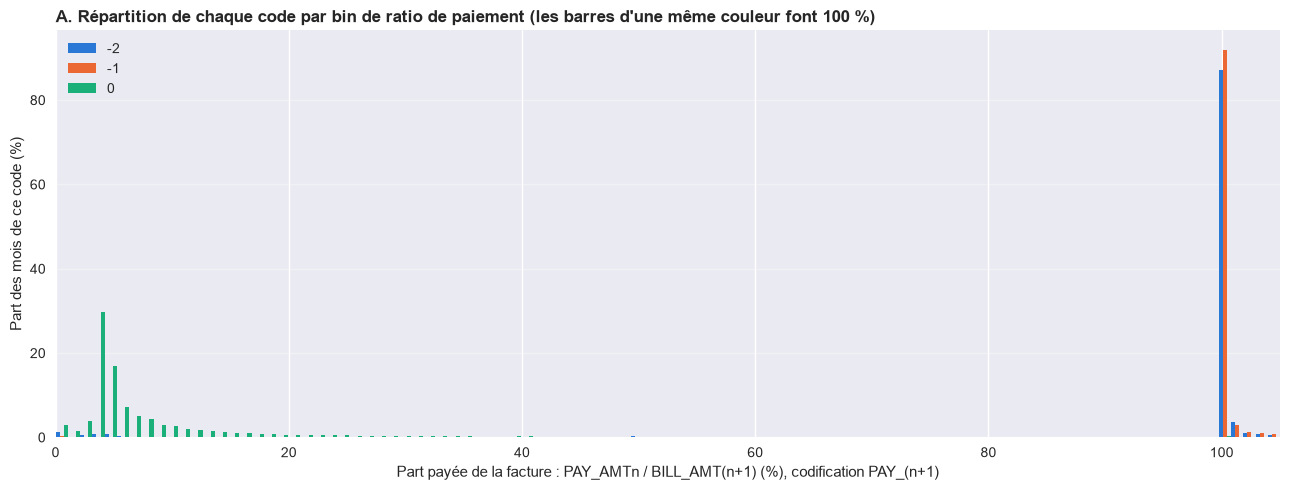

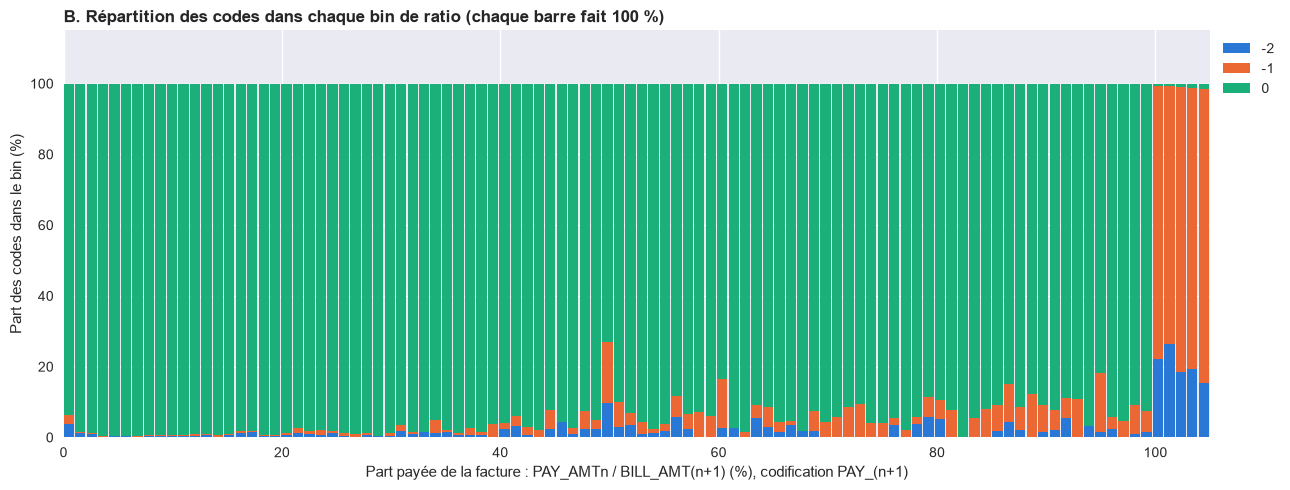

In [173]:
# Paramètres à ajuster pour affiner les frontières
debut, fin = 0, 105   # plage de ratio étudiée (%)
nb_bins = 100           # nombre de bins de même largeur sur la plage

# Ratios réels uniquement : mois avec une facture exigible positive (BILL_AMT(n+1) > 0)
# (sans facture, ratio_PAY_BILLn vaut 100 % par convention : ces mois sont exclus)
lignes = []
for n in range(1, 6):
    facture_due = df[f'BILL_AMT{n+1}'] > 0
    lignes.append(pd.DataFrame({'Code': df.loc[facture_due, f'PAY_{n+1}'],   # codification de la facture réglée
                                'Ratio': df.loc[facture_due, f'ratio_PAY_BILL{n}']}))
paires = pd.concat(lignes, ignore_index=True)
paires = paires[paires['Code'].isin(codes)]

bornes = np.linspace(debut, fin, nb_bins + 1)
largeur_bin = (fin - debut) / nb_bins
# Bins fermés à gauche : [a, b[ (un ratio de 100 % tombe dans le bin qui commence à 100)
dans_plage = paires[(paires['Ratio'] >= debut) & (paires['Ratio'] < fin)]
bin_gauche = pd.cut(dans_plage['Ratio'], bornes, right=False, labels=bornes[:-1]).astype(float)
print(f"Plage [{debut} ; {fin}[ en {nb_bins} bins de {largeur_bin:g} points : "
      f"{len(dans_plage)} mois retenus, {len(paires) - len(dans_plage)} hors plage")

# A. Pour chaque code, répartition de ses mois par bin (les barres d'une même couleur font 100 %)
repartition = pd.crosstab(bin_gauche, dans_plage['Code'], normalize='columns').reindex(bornes[:-1], fill_value=0) * 100

fig, ax = plt.subplots(figsize=(13, 5))
for i, code in enumerate(codes):
    ax.bar(repartition.index + i * largeur_bin / 3, repartition[code], width=largeur_bin / 3, align='edge',
           color=couleurs[code], label=libelles[code])
ax.set_title("A. Répartition de chaque code par bin de ratio de paiement (les barres d'une même couleur font 100 %)",
             fontweight='bold', loc='left')
ax.set_xlabel('Part payée de la facture : PAY_AMTn / BILL_AMT(n+1) (%), codification PAY_(n+1)')
ax.set_ylabel('Part des mois de ce code (%)')
ax.set_xlim(debut, fin)
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# B. Dans chaque bin, part de chaque code (chaque barre fait 100 %)
part_codes = pd.crosstab(bin_gauche, dans_plage['Code'], normalize='index').reindex(columns=codes, fill_value=0) * 100
effectifs = bin_gauche.value_counts().reindex(part_codes.index)

fig, ax = plt.subplots(figsize=(13, 5))
bas = np.zeros(len(part_codes))
for code in codes:
    ax.bar(part_codes.index, part_codes[code], bottom=bas, width=0.9 * largeur_bin, align='edge',
           color=couleurs[code], label=libelles[code])
    bas += part_codes[code].values
# Nombre de mois au-dessus des barres, seulement si les bins ne sont pas trop nombreux
if nb_bins <= 40:
    for x, nb in effectifs.items():
        ax.text(x + largeur_bin / 2, 101, f'{nb}', ha='center', va='bottom', fontsize=7, color='dimgrey', rotation=90)
ax.set_title('B. Répartition des codes dans chaque bin de ratio (chaque barre fait 100 %)', fontweight='bold', loc='left')
ax.set_xlabel('Part payée de la facture : PAY_AMTn / BILL_AMT(n+1) (%), codification PAY_(n+1)')
ax.set_ylabel('Part des codes dans le bin (%)')
ax.set_xlim(debut, fin)
ax.set_ylim(0, 115)
ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


**Interprétation**
Avec la codification de la facture elle-même, les codes sains se séparent nettement :
- -1 et -2 : la facture est soldée (part payée à 100 %) presque à chaque fois ;
- 0 : la facture est payée en partie, le plus souvent autour de la mensualité minimale.
La frontière entre 0 et -1 passe par le solde de la facture. Je regarde maintenant sur le comportement médian du client pour voir si des délimitations ou des comportements sont plus tranchés.

Clients sans code dominant (égalité) : 1575 | code dominant hors -2, -1, 0 : 2622
Plage [0 ; 100] en 10 bins de 10 points : 24287 clients retenus, 1512 hors plage


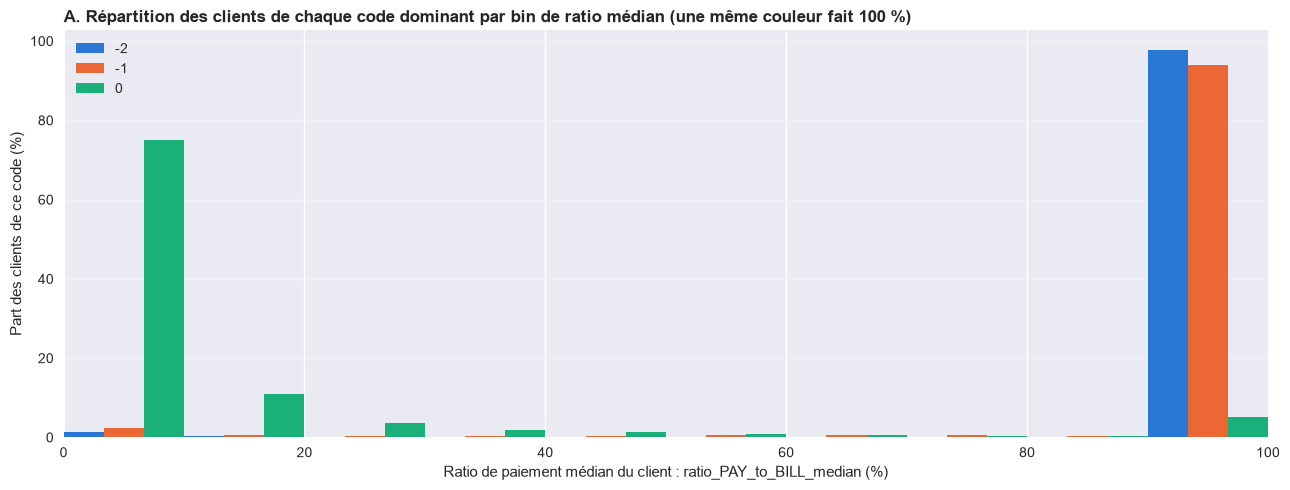

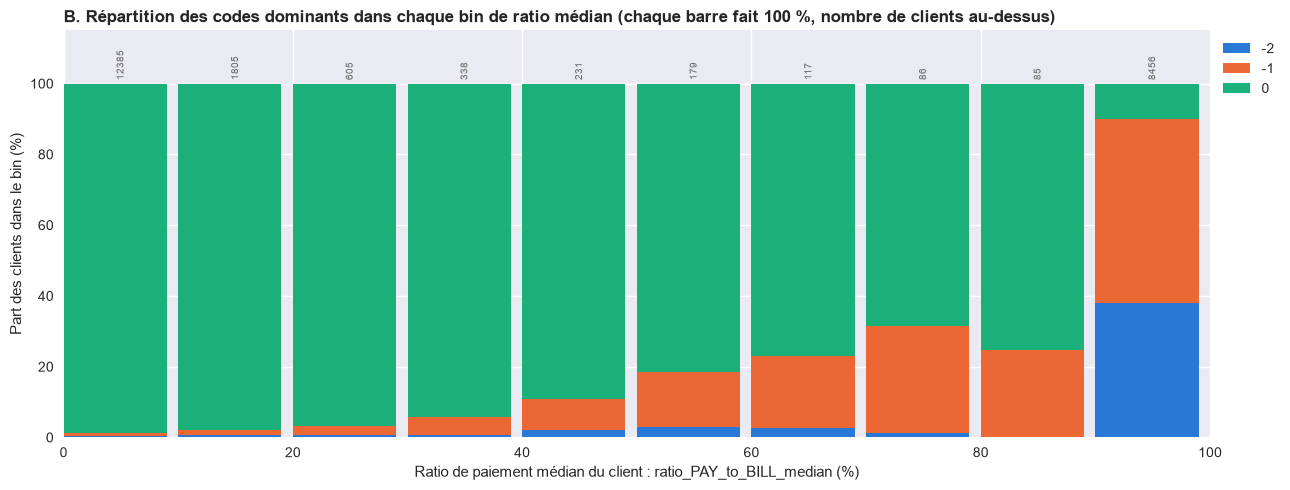

In [174]:
# Paramètres à ajuster pour affiner les frontières
debut, fin = 0, 100     # plage de ratio médian étudiée (%)
nb_bins = 10         # nombre de bins de même largeur sur la plage

codes = [-2, -1, 0]
couleurs = {-2: '#2a78d6', -1: '#eb6834', 0: '#1baf7a'}
libelles = {-2: '-2', -1: '-1', 0: '0'}
titre_x = 'Ratio de paiement médian du client : ratio_PAY_to_BILL_median (%)'

# Un client = une ligne : son ratio médian et son code dominant de PAY_1 à PAY_5
# (code le plus fréquent ; en cas d'égalité, pas de profil net : client exclu)
codes_mois = df[[f'PAY_{n}' for n in range(1, 6)]]
modes = codes_mois.mode(axis=1)
egalite = modes.shape[1] > 1 and True
code_dominant = modes[0].where(modes.iloc[:, 1:].isna().all(axis=1)) if modes.shape[1] > 1 else modes[0]
clients = pd.DataFrame({'Code': code_dominant, 'Ratio': df['ratio_PAY_to_BILL_median']})
print(f"Clients sans code dominant (égalité) : {code_dominant.isna().sum()} | "
      f"code dominant hors -2, -1, 0 : {(code_dominant.notna() & ~code_dominant.isin(codes)).sum()}")
clients = clients[clients['Code'].isin(codes)]

bornes = np.linspace(debut, fin, nb_bins + 1)
largeur_bin = (fin - debut) / nb_bins
# Bins fermés à gauche : [a, b[ (fin incluse pour garder les ratios écrêtés à 200 %)
dans_plage = clients[(clients['Ratio'] >= debut) & (clients['Ratio'] <= fin)]
bin_gauche = pd.cut(dans_plage['Ratio'].clip(upper=fin - 1e-9), bornes, right=False, labels=bornes[:-1]).astype(float)
print(f"Plage [{debut} ; {fin}] en {nb_bins} bins de {largeur_bin:g} points : "
      f"{len(dans_plage)} clients retenus, {len(clients) - len(dans_plage)} hors plage")

# A. Pour chaque code dominant, répartition de ses clients par bin (les barres d'une même couleur font 100 %)
repartition = pd.crosstab(bin_gauche, dans_plage['Code'], normalize='columns').reindex(bornes[:-1], fill_value=0) * 100

fig, ax = plt.subplots(figsize=(13, 5))
for i, code in enumerate(codes):
    ax.bar(repartition.index + i * largeur_bin / 3, repartition[code], width=largeur_bin / 3, align='edge',
           color=couleurs[code], label=libelles[code])
ax.set_title("A. Répartition des clients de chaque code dominant par bin de ratio médian (une même couleur fait 100 %)",
             fontweight='bold', loc='left')
ax.set_xlabel(titre_x)
ax.set_ylabel('Part des clients de ce code (%)')
ax.set_xlim(debut, fin)
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# B. Dans chaque bin, part de chaque code dominant (chaque barre fait 100 %)
part_codes = pd.crosstab(bin_gauche, dans_plage['Code'], normalize='index').reindex(columns=codes, fill_value=0) * 100
effectifs = bin_gauche.value_counts().reindex(part_codes.index)

fig, ax = plt.subplots(figsize=(13, 5))
bas = np.zeros(len(part_codes))
for code in codes:
    ax.bar(part_codes.index, part_codes[code], bottom=bas, width=0.9 * largeur_bin, align='edge',
           color=couleurs[code], label=libelles[code])
    bas += part_codes[code].values
# Nombre de clients au-dessus des barres, seulement si les bins ne sont pas trop nombreux
if nb_bins <= 40:
    for x, nb in effectifs.items():
        ax.text(x + largeur_bin / 2, 101, f'{nb}', ha='center', va='bottom', fontsize=7, color='dimgrey', rotation=90)
ax.set_title('B. Répartition des codes dominants dans chaque bin de ratio médian (chaque barre fait 100 %, nombre de clients au-dessus)',
             fontweight='bold', loc='left')
ax.set_xlabel(titre_x)
ax.set_ylabel('Part des clients dans le bin (%)')
ax.set_xlim(debut, fin)
ax.set_ylim(0, 115)
ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


Certains ratios médians sont très peu représentés.  
La codification -1 pour un ratio médian à 0 semble importante mais elle ne représente que 161 clients


La banque met-elle un client en retard selon ce qu'il paie, et à partir de quand sort-on d'un retard ?
Pour chaque mois d'avril à août, je rapproche la codification d'une facture (`PAY_n`) de la part de cette facture payée le mois suivant (`PAY_AMT(n-1) / BILL_AMTn`), d'abord pour les clients sains le mois précédent, puis pour les clients déjà en retard. Les codifications 1 sont écartées.

In [175]:
TRANCHES = ['rien payé', 'moins de 3 %', '3 à 5 %', '5 à 10 %', '10 à 20 %', '20 à 50 %', '50 à 90 %', '90 % et plus']
def tranche_paiement(paiement, facture):
    part = paiement / facture.where(facture > 0) * 100
    return pd.Series(np.select([paiement <= 0, part < 3, part < 5, part < 10, part < 20, part < 50, part < 90], TRANCHES[:7], TRANCHES[7]),
                     index=paiement.index).where(facture > 0)

blocs = []
for n in range(2, 6):   # août (2) à mai (5) : la codification du mois d'avant (PAY_(n+1)) et le paiement du mois suivant (PAY_AMT(n-1)) existent
    blocs.append(pd.DataFrame({'mois': MOIS[n], 'avant': df[f'PAY_{n + 1}'], 'codif': df[f'PAY_{n}'],
                               'paye': tranche_paiement(df[f'PAY_AMT{n - 1}'], df[f'BILL_AMT{n}'])}))
ex = pd.concat(blocs, ignore_index=True)   # un client compte une fois par mois : lignes renumérotées
ex = ex[(ex['avant'] != 1) & (ex['codif'] != 1) & ex['paye'].notna()]

# 1. Clients sains le mois précédent : part mis en retard (2 et plus), selon la part payée de la facture
sains = ex[ex['avant'] <= 0]
mise = (sains['codif'] >= 2).groupby(sains['paye']).agg(['size', 'mean']).reindex(TRANCHES)
mise.columns = ['Factures (clients sains le mois précédent)', 'Mis en retard (%)']
mise['Mis en retard (%)'] = (mise['Mis en retard (%)'] * 100).round(1)
mise.index.name = 'Part payée de la facture le mois suivant'
display(mise)


,Factures (clients sains le mois précédent),Mis en retard (%)
Part payée de la facture le mois suivant,,
rien payé,5302,72.2
moins de 3 %,3797,16.4
3 à 5 %,27683,0.6
5 à 10 %,14948,0.9
10 à 20 %,6926,0.8
20 à 50 %,4765,0.3
50 à 90 %,1956,0.8
90 % et plus,26107,0.1


**Interprétation**
Un client sain qui ne paie rien de sa facture passe en retard dans la plupart des cas ; s'il paie moins de 3 %, parfois ; dès la mensualité minimale (3 %), presque jamais. La mise en retard suit le paiement de la facture, sans décalage.

Quelle part de la facture faut-il payer pour ne pas tomber en retard ? Je regarde finement les clients sains le mois précédent qui paient entre 0 et 5 % d'une facture d'au moins 100 NT$, sur tous les mois, puis en juillet-août (la banque y met en retard presque tous les impayés) et en mai-juin. Pour les petites factures, je regarde aussi le montant payé en NT$.

In [176]:
# Clients sains le mois précédent, facture d'au moins 100 NT$ : part mis en retard selon la part payée, par pas fins
sains_fin = []
for n in range(2, 6):
    sains_fin.append(pd.DataFrame({'mois': MOIS[n], 'avant': df[f'PAY_{n + 1}'].to_numpy(), 'codif': df[f'PAY_{n}'].to_numpy(),
                                   'paiement': df[f'PAY_AMT{n - 1}'].to_numpy(), 'facture': df[f'BILL_AMT{n}'].to_numpy()}))
sains_fin = pd.concat(sains_fin, ignore_index=True)
sains_fin = sains_fin[(sains_fin['avant'] <= 0) & (sains_fin['codif'] != 1) & (sains_fin['facture'] >= 100)]   # dette d'au moins 100 NT$
sains_fin['part'] = sains_fin['paiement'] / sains_fin['facture'] * 100
sains_fin['en_retard'] = sains_fin['codif'] >= 2

BORNES_FINES = [-0.001, 0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 5, 10, 100, np.inf]
NOMS_FINS = ['rien payé', '0 à 0,5 %', '0,5 à 1 %', '1 à 1,5 %', '1,5 à 2 %', '2 à 2,5 %', '2,5 à 3 %', '3 à 3,5 %', '3,5 à 4 %',
             '4 à 5 %', '5 à 10 %', '10 à 100 %', 'plus de 100 %']
sains_fin['tranche'] = pd.cut(sains_fin['part'], BORNES_FINES, labels=NOMS_FINS)
colonnes = {}
for nom, sel in [('tous les mois (mai à août)', sains_fin['mois'].notna()),
                 ('juillet-août', sains_fin['mois'].isin(['juillet', 'août'])),
                 ('mai-juin', sains_fin['mois'].isin(['mai', 'juin']))]:
    g = sains_fin[sel].groupby('tranche', observed=False)['en_retard']
    colonnes[(nom, 'factures')] = g.size()
    colonnes[(nom, 'mis en retard (%)')] = (g.mean() * 100).round(1)
seuil = pd.DataFrame(colonnes)
seuil.index.name = 'Part payée de la facture le mois suivant'
display(seuil)

# Petites factures (5 000 NT$ au plus), paiement partiel de moins de 10 % : la part payée et le montant payé, croisés
petites = sains_fin[(sains_fin['facture'] <= 5000) & (sains_fin['paiement'] > 0) & (sains_fin['part'] < 10)]
part_payee = pd.cut(petites['part'], [0, 1.5, 3, 10], labels=['moins de 1,5 %', '1,5 à 3 %', '3 à 10 %'])
montant = pd.cut(petites['paiement'], [0, 50, 100, 500], labels=['1 à 50 NT$', '51 à 100 NT$', '101 à 500 NT$'])
g = petites.groupby([part_payee, montant], observed=False)['en_retard']
display((g.mean() * 100).round(1).unstack().rename_axis(index='Part payée', columns='Montant payé : mis en retard (%)'))
display(g.size().unstack().rename_axis(index='Part payée', columns='Montant payé : factures'))


tous les mois (mai à août)  \
                                                           factures   
Part payée de la facture le mois suivant                              
rien payé                                                      5258   
0 à 0,5 %                                                       769   
0,5 à 1 %                                                       116   
1 à 1,5 %                                                        56   
1,5 à 2 %                                                       482   
2 à 2,5 %                                                      1037   
2,5 à 3 %                                                      1338   
3 à 3,5 %                                                      4041   
3,5 à 4 %                                                     11566   
4 à 5 %                                                       12079   
5 à 10 %                                                      14959   
10 à 100 %                                                    30181   
plus de 100 %                                                  9391   

                                                           juillet-août  \
                                         mis en retard (%)     factures   
Part payée de la facture le mois suivant                                  
rien payé                                             72.5         2240   
0 à 0,5 %                                             63.5          335   
0,5 à 1 %                                             36.2           30   
1 à 1,5 %                                             39.3           13   
1,5 à 2 %                                              4.4           55   
2 à 2,5 %                                              1.8          203   
2,5 à 3 %                                              2.4          393   
3 à 3,5 %                                              1.1         1096   
3,5 à 4 %                                              0.5         4369   
4 à 5 %                                                0.5         7017   
5 à 10 %                                               0.9         8848   
10 à 100 %                                             0.3        15599   
plus de 100 %                                          0.2         5270   

                                                           mai-juin  \
                                         mis en retard (%) factures   
Part payée de la facture le mois suivant                              
rien payé                                             98.6     3018   
0 à 0,5 %                                             97.9      434   
0,5 à 1 %                                             93.3       86   
1 à 1,5 %                                             92.3       43   
1,5 à 2 %                                             29.1      427   
2 à 2,5 %                                              3.0      834   
2,5 à 3 %                                              5.6      945   
3 à 3,5 %                                              2.7     2945   
3,5 à 4 %                                              0.8     7197   
4 à 5 %                                                0.7     5062   
5 à 10 %                                               1.0     6111   
10 à 100 %                                             0.4    14582   
plus de 100 %                                          0.2     4121   

                                                            
                                         mis en retard (%)  
Part payée de la facture le mois suivant                    
rien payé                                             53.1  
0 à 0,5 %                                             36.9  
0,5 à 1 %                                             16.3  
1 à 1,5 %                                             23.3  
1,5 à 2 %                                              1.2  
2 à 2,5 %                                              1.6  
2,5 à 3 %        

,factures,mis en retard (%)
Montant payé (petites factures),,
1 à 50 NT$,255,33.3
51 à 100 NT$,82,1.2
101 à 200 NT$,60,5.0
201 à 500 NT$,35,2.9
plus de 500 NT$,0,NaN


**Comment lire** : premier tableau, pour chaque tranche de part payée, le nombre de factures et la part mise en retard, sur tous les mois puis séparément ; puis, pour les petites factures, la part mise en retard et le nombre de factures selon la part payée et le montant payé.

**Interprétation**  
La bascule se fait autour de 2 % de la facture : en juillet-août, en dessous de 1,5 % presque tous les clients passent en retard, entre 1,5 et 2 % une partie, à partir de 2 % presque aucun. En mai-juin, la même bascule existe mais la banque est plus souple sous le seuil.  
Les clients paient le plus souvent entre 3 et 5 %, un peu au-dessus de ce seuil.  
Pour les petites factures, un très petit paiement (50 NT$ au plus) ne fait passer en retard que lorsqu'il représente moins de 1,5 % de la facture ; au même montant, entre 1,5 et 3 % de la facture, presque personne ne passe en retard. C'est la part de la facture qui compte, pas le montant payé.

À partir de quelle part payée un client reste-t-il sain dans au moins 98 % des cas ? Je fais glisser une fenêtre d'un demi-point de part payée (de 1 à 4,5 %, par pas de 0,1 point) et je mesure, dans chaque fenêtre, la part des clients sains le mois précédent qui restent sains. Le calcul est fait mois par mois, sur les factures d'au moins 100 NT$.

In [177]:
OBJECTIF = 98   # % de clients qui restent sains
lignes = []
for debut in np.round(np.arange(1.0, 4.01, 0.1), 1):
    ligne = {'Part payée de la facture': f'{debut:.1f} à {debut + 0.5:.1f} %'.replace('.', ',')}
    for nom_mois in ['mai', 'juin', 'juillet', 'août']:   # ordre chronologique
        fenetre = sains_fin[(sains_fin['mois'] == nom_mois) & (sains_fin['part'] >= debut) & (sains_fin['part'] < debut + 0.5)]
        reste_sain = (~fenetre['en_retard']).mean() * 100
        ligne[(nom_mois, 'factures')] = len(fenetre)
        ligne[(nom_mois, 'restent sains (%)')] = round(reste_sain, 1)
        ligne[(nom_mois, 'objectif')] = 'oui' if reste_sain >= OBJECTIF else ''
    lignes.append(ligne)
fenetres = pd.DataFrame(lignes).set_index('Part payée de la facture')
fenetres.columns = pd.MultiIndex.from_tuples(fenetres.columns)
display(fenetres)


mai                                juin  \
                         factures restent sains (%) objectif factures   
Part payée de la facture                                                
1,0 à 1,5 %                    29              93.1                21   
1,1 à 1,6 %                    21              90.5                17   
1,2 à 1,7 %                    18             100.0      oui       18   
1,3 à 1,8 %                    26              96.2                25   
1,4 à 1,9 %                    47              97.9                34   
1,5 à 2,0 %                   202              99.5      oui      151   
1,6 à 2,1 %                   476              99.4      oui      346   
1,7 à 2,2 %                   520              99.2      oui      388   
1,8 à 2,3 %                   566              99.5      oui      424   
1,9 à 2,4 %                   592              99.3      oui      456   
2,0 à 2,5 %                   501              99.0      oui      402   
2,1 à 2,6 %                   285              98.6      oui      268   
2,2 à 2,7 %                   310              98.4      oui      298   
2,3 à 2,8 %                   338              98.5      oui      353   
2,4 à 2,9 %                   423              99.1      oui      413   
2,5 à 3,0 %                   478              99.0      oui      471   
2,6 à 3,1 %                   557              99.1      oui      561   
2,7 à 3,2 %                   646              99.5      oui      669   
2,8 à 3,3 %                   810              99.4      oui      796   
2,9 à 3,4 %                  1010              99.3      oui     1011   
3,0 à 3,5 %                  1499              99.5      oui     1447   
3,1 à 3,6 %                  2525              99.6      oui     2281   
3,2 à 3,7 %                  3575              99.7      oui     2764   
3,3 à 3,8 %                  4038              99.8      oui     3023   
3,4 à 3,9 %                  4315              99.8      oui     3123   
3,5 à 4,0 %                  4207              99.9      oui     2985   
3,6 à 4,1 %                  3456              99.9      oui     2388   
3,7 à 4,2 %                  2651              99.9      oui     2042   
3,8 à 4,3 %                  2225              99.9      oui     1873   
3,9 à 4,4 %                  1840              99.9      oui     1750   
4,0 à 4,5 %                  1570              99.9      oui     1644   

                                                     juillet  \
                         restent sains (%) objectif factures   
Part payée de la facture                                       
1,0 à 1,5 %                           61.9                 9   
1,1 à 1,6 %                           64.7                 9   
1,2 à 1,7 %                           66.7                13   
1,3 à 1,8 %                           80.0                12   
1,4 à 1,9 %                           91.2                16   
1,5 à 2,0 %                           97.4                28   
1,6 à 2,1 %                           98.0                53   
1,7 à 2,2 %                           98.2      oui       69   
1,8 à 2,3 %                           98.6      oui       83   
1,9 à 2,4 %                           98.7      oui      101   
2,0 à 2,5 %                           98.0      oui      127   
2,1 à 2,6 %                           98.1      oui      135   
2,2 à 2,7 %                           98.7      oui      157   
2,3 à 2,8 %                           98.6      oui      181   
2,4 à 2,9 %                           98.3      oui      227   
2,5 à 3,0 %                           98.9      oui      255   
2,6 à 3,1 %                           98.8      oui      300   
2,7 à 3,2 %                           99.0      oui      352   
2,8 à 3,3 %                           98.9      oui      424   
2,9 à 3,4 %                           99.2      oui      503   
3,0 à 3,5 %                           99.4      oui      659   
3,1 à 3,6 %

**Comment lire** : une ligne par fenêtre d'un demi-point ; pour chaque mois, le nombre de factures, la part des clients qui restent sains, et « oui » si elle atteint 98 %.

**Interprétation**  
Le seuil n'est pas le même tous les mois : en mai et en juin, les clients restent sains dans 98 % des cas dès environ 1,5 % de la facture ; en juillet et en août, seulement à partir d'environ 3 %. La banque semble avoir relevé sa règle en juillet, ce qui rejoint les petits impayés tolérés en avril, mai et juin.  
Le montant payé n'ajoute presque rien : c'est la part de la facture qui compte.

In [240]:
# Nouveaux retards selon la codification qui précède l'impayé (-2, -1 ou 0), par tranche de part payée
# (clients sains le mois précédent, factures d'au moins 100 NT$ ; mai-juin et juillet-août séparés)
BORNES_SEUIL = [-0.001, 0, 1.5, 2, 2.5, 3, 3.5, 5, 10, np.inf]
NOMS_SEUIL = ['rien payé', '0 à 1,5 %', '1,5 à 2 %', '2 à 2,5 %', '2,5 à 3 %', '3 à 3,5 %', '3,5 à 5 %', '5 à 10 %', 'plus de 10 %']
tranche_seuil = pd.cut(sains_fin['part'], BORNES_SEUIL, labels=NOMS_SEUIL)
for periode, mois_periode in [('mai-juin', ['mai', 'juin']), ('juillet-août', ['juillet', 'août'])]:
    sel = sains_fin['mois'].isin(mois_periode)
    g = sains_fin[sel].groupby([sains_fin.loc[sel, 'avant'], tranche_seuil[sel]], observed=False)['en_retard']
    display((f"**{periode}** : part mise en retard (%), puis nombre de factures"))
    display((g.mean() * 100).round(1).unstack().rename_axis(index='Codification du mois précédent', columns='Part payée de la facture'))
    display(g.size().unstack().rename_axis(index='Codification du mois précédent', columns='Part payée de la facture'))


'**mai-juin** : part mise en retard (%), puis nombre de factures'

Part payée de la facture,rien payé,"0 à 1,5 %","1,5 à 2 %","2 à 2,5 %","2,5 à 3 %","3 à 3,5 %","3,5 à 5 %",5 à 10 %,plus de 10 %
Codification du mois précédent,,,,,,,,,
-2,14.3,0.0,0.0,0.0,0.0,11.8,0.0,10.5,0.4
-1,24.5,15.8,0.0,1.7,0.0,3.7,3.4,2.0,0.1
0,63.1,40.8,1.3,1.6,1.1,0.4,0.2,0.7,0.4


Part payée de la facture,rien payé,"0 à 1,5 %","1,5 à 2 %","2 à 2,5 %","2,5 à 3 %","3 à 3,5 %","3,5 à 5 %",5 à 10 %,plus de 10 %
Codification du mois précédent,,,,,,,,,
-2,35,15,3,7,4,17,27,19,2748
-1,739,158,50,120,28,27,58,149,8387
0,2244,390,374,707,913,2901,12174,5943,7568


'**juillet-août** : part mise en retard (%), puis nombre de factures'

Part payée de la facture,rien payé,"0 à 1,5 %","1,5 à 2 %","2 à 2,5 %","2,5 à 3 %","3 à 3,5 %","3,5 à 5 %",5 à 10 %,plus de 10 %
Codification du mois précédent,,,,,,,,,
-2,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.3
-1,98.4,96.7,23.1,3.3,5.0,13.3,1.3,3.0,0.2
0,99.6,99.3,31.0,3.0,5.7,2.6,0.8,1.0,0.5


Part payée de la facture,rien payé,"0 à 1,5 %","1,5 à 2 %","2 à 2,5 %","2,5 à 3 %","3 à 3,5 %","3,5 à 5 %",5 à 10 %,plus de 10 %
Codification du mois précédent,,,,,,,,,
-2,16,5,0,7,7,11,37,28,3049
-1,445,91,13,30,20,15,75,169,9247
0,1779,282,42,166,366,1070,11274,8651,8573


Un client codifié -2 qui ne paie pas sa facture suivante n'est presque jamais mis en retard. Je regarde la codification posée sur ces impayés (factures d'au moins 100 NT$, aucun paiement le mois suivant) selon la codification du mois précédent, puis, pour ceux qui restent à -2, ce qu'ils paient les mois suivants.

In [241]:
# 1. Codification d'un impayé (facture >= 100 NT$, aucun paiement le mois suivant) selon la codification du mois précédent
lignes = []
for n in range(2, 6):
    impaye = (df[f'BILL_AMT{n}'] >= 100) & (df[f'PAY_AMT{n - 1}'] == 0) & (df[f'PAY_{n}'] != 1) & df[f'PAY_{n + 1}'].isin([-2, -1, 0])
    lignes.append(pd.DataFrame({'avant': df.loc[impaye, f'PAY_{n + 1}'], 'codif': df.loc[impaye, f'PAY_{n}'].clip(upper=2)}))
impayes = pd.concat(lignes, ignore_index=True)
t = pd.crosstab(impayes['avant'], impayes['codif'].map({-2: '-2', -1: '-1', 0: '0', 2: '2 et plus'}), normalize='index') * 100
t = t.reindex(columns=['-2', '-1', '0', '2 et plus']).fillna(0).round(1)
t.insert(0, 'Impayés', impayes['avant'].value_counts())
display(t.rename_axis(index='Codification du mois précédent', columns="Codification de l'impayé (%)"))

# 2. Impayés restés à -2 après un mois à -2 : paiements des mois suivants (jusqu'en septembre)
lignes = []
for n in range(2, 6):
    reste_moins2 = (df[f'PAY_{n + 1}'] == -2) & (df[f'BILL_AMT{n}'] >= 100) & (df[f'PAY_AMT{n - 1}'] == 0) & (df[f'PAY_{n}'] == -2)
    for client, ligne in df[reste_moins2].iterrows():
        facture = ligne[f'BILL_AMT{n}']
        suivants = [ligne[f'PAY_AMT{k}'] for k in range(n - 2, 0, -1)]   # paiements après le mois sans paiement
        lignes.append({'Client': client, 'Mois de la facture': MOIS[n], 'Facture (NT$)': facture,
                       'Payé deux mois après la facture (%)': round(suivants[0] / facture * 100, 1) if suivants else np.nan,
                       "Payé en cumul jusqu'en septembre (%)": round(sum(suivants) / facture * 100, 1) if suivants else np.nan,
                       'Codifications des mois suivants': [int(ligne[f'PAY_{k}']) for k in range(n - 1, 0, -1)]})
differes = pd.DataFrame(lignes)
observables = differes.dropna(subset=['Payé deux mois après la facture (%)'])
print(f"Impayés restés à -2 après un mois à -2 : {len(differes)} ; avec au moins un mois observable ensuite : {len(observables)}")
print(f"  soldés deux mois après la facture (90 % et plus) : {(observables['Payé deux mois après la facture (%)'] >= 90).sum()}")
print(f"  soldés en cumul jusqu'en septembre : {(observables["Payé en cumul jusqu'en septembre (%)"] >= 90).sum()}")
print(f"  jamais aucun paiement jusqu'en septembre : {(observables["Payé en cumul jusqu'en septembre (%)"] == 0).sum()}")
display(differes.set_index('Client'))


Codification de l'impayé (%),Impayés,-2,-1,0,2 et plus
Codification du mois précédent,,,,,
-2,51,82.4,3.9,3.9,9.8
-1,1184,0.6,1.7,45.4,52.3
0,4023,0.0,0.0,20.7,79.2


Impayés restés à -2 après un mois à -2 : 42 ; avec au moins un mois observable ensuite : 33
  soldés deux mois après la facture (90 % et plus) : 22
  soldés en cumul jusqu'en septembre : 25
  jamais aucun paiement jusqu'en septembre : 3


,Mois de la facture,Facture (NT$),Payé deux mois après la facture (%),Payé en cumul jusqu'en septembre (%),Codifications des mois suivants
Client,,,,,
66,août,148751,NaN,NaN,[-2]
7166,août,1000,NaN,NaN,[-2]
8147,août,661,NaN,NaN,[-2]
9494,août,3362,NaN,NaN,[-2]
9622,août,83894,NaN,NaN,[-2]
10333,août,22369,NaN,NaN,[-2]
11427,août,31195,NaN,NaN,[-2]
12540,août,316,NaN,NaN,[-2]
13087,août,20736,NaN,NaN,[-2]


**Comment lire** : premier tableau, pour chaque codification du mois précédent, le nombre d'impayés et la répartition de la codification posée sur l'impayé (chaque ligne fait 100 %, hors nombre d'impayés) ; puis le décompte et la liste des impayés restés à -2, avec ce que le client paie ensuite. Les factures d'août n'ont pas de mois suivant observable (septembre est le dernier).

**Interprétation**  
Après un 0, un impayé passe en retard dans la plupart des cas ; après un -1, une fois sur deux environ ; après un -2, presque jamais : la codification reste -2.  
La plupart de ces clients soldent leur facture un ou deux mois plus tard, en restant codifiés -2 : la banque semble accepter un paiement différé de plus d'un mois sans poser de retard. Quelques comptes ne paient jamais, avec un solde qui ne bouge pas, toujours à -2.  
Les volumes sont faibles (quelques dizaines de factures sur la période).

Dans quelle zone la banque met-elle (presque) toujours un client en retard, et dans quelle zone presque jamais ? Je croise la part payée de la facture et le montant payé, pour les clients à -1 ou 0 le mois précédent (factures d'au moins 100 NT$), en juillet-août, quand la banque applique sa règle sans tolérance, puis en mai-juin. Je compte ensuite, mois par mois, les impayés de la zone « retard presque sûr » de juillet-août et la part que la banque a réellement mise en retard.

In [242]:
from IPython.display import Markdown

# Part payée de la facture × montant payé : part mise en retard (clients à -1 ou 0 le mois précédent, factures >= 100 NT$)
blocs = []
for n in range(2, 7):
    blocs.append(pd.DataFrame({'mois': MOIS[n], 'avant': df[f'PAY_{n + 1}'].to_numpy() if n < 6 else np.nan,
                               'codif': df[f'PAY_{n}'].to_numpy(), 'paiement': df[f'PAY_AMT{n - 1}'].to_numpy(),
                               'facture': df[f'BILL_AMT{n}'].to_numpy()}))
zones = pd.concat(blocs, ignore_index=True)
zones = zones[(zones['codif'] != 1) & (zones['facture'] >= 100)]
zones['part'] = zones['paiement'] / zones['facture'] * 100
zones['en_retard'] = zones['codif'] >= 2
zones['tranche_part'] = pd.cut(zones['part'], [-0.001, 0, 1.5, 2, 3, 5, 10, np.inf],
                               labels=['rien payé', '0 à 1,5 %', '1,5 à 2 %', '2 à 3 %', '3 à 5 %', '5 à 10 %', 'plus de 10 %'])
zones['tranche_montant'] = pd.cut(zones['paiement'], [-0.001, 0, 500, 999, 1000, 1500, 2000, np.inf],
                                  labels=['rien', '1 à 500 NT$', '501 à 999 NT$', '1 000 NT$ pile', '1 001 à 1 500 NT$', '1 501 à 2 000 NT$', 'plus de 2 000 NT$'])
for periode, mois_periode in [('juillet-août', ['juillet', 'août']), ('mai-juin', ['mai', 'juin'])]:
    sel = zones[zones['mois'].isin(mois_periode) & zones['avant'].isin([-1, 0])]
    g = sel.groupby(['tranche_part', 'tranche_montant'], observed=False)['en_retard']
    display(Markdown(f"**{periode}** : part mise en retard (%), puis nombre de factures"))
    display((g.mean() * 100).round(1).unstack().rename_axis(index='Part payée de la facture', columns='Montant payé'))
    display(g.size().unstack().rename_axis(index='Part payée de la facture', columns='Montant payé'))

# Zone « retard presque sûr » observée en juillet-août : moins de 1,5 % payé, ou moins de 5 % payé avec moins de 1 000 NT$
zones['zone_retard'] = (zones['part'] < 1.5) | ((zones['part'] < 5) & (zones['paiement'] < 1000))
lignes = []
for n in range(6, 1, -1):
    sel = zones[(zones['mois'] == MOIS[n]) & zones['zone_retard'] & (zones['avant'].isin([-1, 0]) if n < 6 else True)]
    lignes.append({'Mois': MOIS[n], 'Impayés de la zone': len(sel), 'Mis en retard par la banque (%)': round(sel['en_retard'].mean() * 100, 1),
                   'Restés sains': int((~sel['en_retard']).sum())})
display(pd.DataFrame(lignes).set_index('Mois'))
print("Avril : la codification du mois précédent (mars) n'est pas connue ; tous les clients sont comptés.")


**juillet-août** : part mise en retard (%), puis nombre de factures

Montant payé,rien,1 à 500 NT$,501 à 999 NT$,1 000 NT$ pile,1 001 à 1 500 NT$,1 501 à 2 000 NT$,plus de 2 000 NT$
Part payée de la facture,,,,,,,
rien payé,99.3,NaN,NaN,NaN,NaN,NaN,NaN
"0 à 1,5 %",NaN,99.4,66.7,100.0,75.0,83.3,NaN
"1,5 à 2 %",NaN,100.0,50.0,40.0,36.4,16.7,21.7
2 à 3 %,NaN,75.0,80.0,4.2,5.1,3.6,3.1
3 à 5 %,NaN,100.0,100.0,22.9,3.2,0.6,0.6
5 à 10 %,NaN,88.9,100.0,27.9,1.1,0.2,0.1
plus de 10 %,NaN,0.7,0.6,6.8,0.2,0.1,0.1


Montant payé,rien,1 à 500 NT$,501 à 999 NT$,1 000 NT$ pile,1 001 à 1 500 NT$,1 501 à 2 000 NT$,plus de 2 000 NT$
Part payée de la facture,,,,,,,
rien payé,2224,0,0,0,0,0,0
"0 à 1,5 %",0,356,3,4,4,6,0
"1,5 à 2 %",0,2,2,5,11,12,23
2 à 3 %,0,4,5,24,138,84,327
3 à 5 %,0,6,12,70,463,1839,10044
5 à 10 %,0,9,7,154,2218,2367,4065
plus de 10 %,0,1680,1064,472,2625,1711,10268


**mai-juin** : part mise en retard (%), puis nombre de factures

Montant payé,rien,1 à 500 NT$,501 à 999 NT$,1 000 NT$ pile,1 001 à 1 500 NT$,1 501 à 2 000 NT$,plus de 2 000 NT$
Part payée de la facture,,,,,,,
rien payé,53.6,NaN,NaN,NaN,NaN,NaN,NaN
"0 à 1,5 %",NaN,34.2,0.0,37.5,25.0,100.0,0.0
"1,5 à 2 %",NaN,0.4,0.0,0.0,0.0,4.5,6.4
2 à 3 %,NaN,0.8,1.9,4.2,1.2,1.2,1.3
3 à 5 %,NaN,0.8,0.4,1.4,0.2,0.2,0.2
5 à 10 %,NaN,1.6,1.8,2.7,0.9,0.1,0.1
plus de 10 %,NaN,0.5,0.3,1.3,0.1,0.5,0.1


Montant payé,rien,1 à 500 NT$,501 à 999 NT$,1 000 NT$ pile,1 001 à 1 500 NT$,1 501 à 2 000 NT$,plus de 2 000 NT$
Part payée de la facture,,,,,,,
rien payé,2983,0,0,0,0,0,0
"0 à 1,5 %",0,518,13,8,4,3,2
"1,5 à 2 %",0,268,50,15,22,22,47
2 à 3 %,0,516,264,48,241,162,537
3 à 5 %,0,660,1679,559,1804,1946,8512
5 à 10 %,0,307,171,936,1136,1071,2471
plus de 10 %,0,1582,1222,682,1397,1346,9726


,Impayés de la zone,Mis en retard par la banque (%),Restés sains
Mois,,,
avril,4355,40.9,2575
mai,4069,18.8,3304
juin,2899,35.8,1861
juillet,1331,98.9,15
août,1297,99.4,8


Avril : la codification du mois précédent (mars) n'est pas connue ; tous les clients sont comptés.


**Comment lire** : pour chaque période, un tableau des parts mises en retard (une ligne par part payée de la facture, une colonne par montant payé) et un tableau du nombre de factures ; puis, mois par mois, les impayés de la zone « retard presque sûr » (moins de 1,5 % de la facture payée, ou moins de 5 % avec moins de 1 000 NT$) et la part réellement mise en retard.

**Interprétation**  
En juillet-août, la banque suit deux seuils : sous 1,5 % de la facture, retard presque toujours, quel que soit le montant ; au-dessus, un paiement de moins de 1 000 NT$ est encore presque toujours mis en retard, sauf pour les petites factures payées en bonne part. Entre 1 000 et 1 500 NT$, c'est une zone grise ; au-delà de 1 500 NT$, presque plus de retard.  
En mai-juin, le plancher de 1 000 NT$ n'existe pas et une grande partie des impayés sous 1,5 % reste saine.  
Les impayés de la zone qui sont restés sains en avril, mai et juin sont ceux qu'un correctif mettrait en retard, en appliquant la règle que la banque suit à partir de juillet.

In [178]:
# 2. Clients en retard le mois précédent (2 et plus) : ce que devient le retard, selon la part payée de la facture
en_retard = ex[ex['avant'] >= 2]
issue = pd.Series(np.select([en_retard['codif'] <= 0, en_retard['codif'] < en_retard['avant'], en_retard['codif'] == en_retard['avant']],
                            ['sort du retard', 'retard qui baisse', 'retard maintenu'], 'retard aggravé'), index=en_retard.index)
suite = pd.crosstab(en_retard['paye'], issue, normalize='index').reindex(index=TRANCHES,
        columns=['sort du retard', 'retard qui baisse', 'retard maintenu', 'retard aggravé']).fillna(0) * 100
suite.insert(0, 'Factures (clients en retard le mois précédent)', en_retard['paye'].value_counts().reindex(TRANCHES).fillna(0).astype(int))
suite.index.name = 'Part payée de la facture le mois suivant'
display(suite.round(1))


col_0,Factures (clients en retard le mois précédent),sort du retard,retard qui baisse,retard maintenu,retard aggravé
Part payée de la facture le mois suivant,,,,,
rien payé,3644,0.1,3.1,69.3,27.4
moins de 3 %,449,1.8,0.2,79.3,18.7
3 à 5 %,2419,2.1,0.4,96.0,1.5
5 à 10 %,3307,39.6,4.5,55.3,0.7
10 à 20 %,2031,52.0,7.5,40.4,0.1
20 à 50 %,814,59.6,6.5,33.9,0.0
50 à 90 %,232,53.9,3.9,41.8,0.4
90 % et plus,862,97.9,0.1,1.7,0.2


**Comment lire** : une ligne par part payée ; chaque ligne fait 100 % (hors première colonne, le nombre de factures).

**Interprétation**
Sans paiement, le retard est maintenu ou s'aggrave ; en payant moins que la mensualité, ou juste la mensualité, il est presque toujours maintenu : payer la facture du mois ne rattrape pas l'arriéré.
Au-delà de 5 % de la facture, environ un client sur deux sort du retard ; en soldant la facture, presque tous en sortent.

In [179]:
# 3. Mois par mois : les deux repères (rien payé chez un client sain ; facture soldée chez un client en retard)
lignes = []
for nom_mois in [MOIS[n] for n in range(5, 1, -1)]:
    s_m, r_m = sains[sains['mois'] == nom_mois], en_retard[en_retard['mois'] == nom_mois]
    lignes.append({'Mois': nom_mois,
                   'Client sain, rien payé : mis en retard (%)': round((s_m.loc[s_m['paye'] == 'rien payé', 'codif'] >= 2).mean() * 100, 1),
                   'Client en retard, facture payée à 90 % et plus : sort du retard (%)': round((r_m.loc[r_m['paye'] == '90 % et plus', 'codif'] <= 0).mean() * 100, 1)})
display(pd.DataFrame(lignes).set_index('Mois'))


,"Client sain, rien payé : mis en retard (%)","Client en retard, facture payée à 90 % et plus : sort du retard (%)"
Mois,,
mai,43.5,99.5
juin,63.3,94.8
juillet,98.3,97.6
août,98.4,98.3


**Interprétation**
Solder sa facture fait sortir du retard presque à chaque fois, tous les mois. Ne rien payer fait tomber en retard presque à chaque fois en juillet et en août, moins souvent en mai et en juin : ce sont les petits impayés tolérés, vus dans la partie sur les codifications.

In [180]:
# 4. Deux factures impayées d'affilée : codification de la seconde (factures positives, aucun paiement le mois suivant de chacune)
lignes = []
for n in range(2, 5):
    deux_impayes = (df[f'BILL_AMT{n + 1}'] > 0) & (df[f'PAY_AMT{n}'] == 0) & (df[f'BILL_AMT{n}'] > 0) & (df[f'PAY_AMT{n - 1}'] == 0) & (df[f'PAY_{n}'] != 1)
    lignes.append(df.loc[deux_impayes, f'PAY_{n}'])
seconde = pd.concat(lignes).clip(upper=2).map({-2: '-2', -1: '-1', 0: '0', 2: '2 et plus'})
print(f"Cas de deux factures impayées d'affilée (juin à août pour la seconde) : {len(seconde)}")
display((seconde.value_counts(normalize=True) * 100).round(1).rename('Codification de la seconde facture (%)').to_frame())


Cas de deux factures impayées d'affilée (juin à août pour la seconde) : 1367


,Codification de la seconde facture (%)
2 et plus,88.4
0,10.5
-1,0.7
-2,0.5


**Interprétation**
Après deux factures impayées d'affilée, la seconde est codifiée en retard dans la grande majorité des cas ; une petite part reste à 0, surtout en juin, le mois des petits impayés tolérés.

In [181]:
import pandas as pd

# 1. Définition des listes de colonnes
pay_cols = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5']
bill_cols = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

# Total global de -2 dans le dataset pour chaque colonne
count_neg2_total = df[pay_cols].eq(-2).sum()

# 2. Création de masques exclusifs (non chevauchants)
# Groupe 1 : Ratio < 25
mask_g1 = df['ratio_PAY_to_BILL_median'] < 25

# Groupe 2 : Ratio entre 25 et 90 (inclus) ET pas de ratio < 25
mask_g2 = (df['ratio_PAY_to_BILL_median'] >= 25) & (df['ratio_PAY_to_BILL_median'] <= 90)

# Groupe 3 : Ratio > 90
mask_g3 = df['ratio_PAY_to_BILL_median'] > 90

print("=== Répartition exclusive des '-2' selon le ratio ===")

# Calcul pour le Groupe 1 (< 25)
count_g1 = df.loc[mask_g1, pay_cols].eq(-2).sum()
prop_g1 = (count_g1 / count_neg2_total) * 100

# Calcul pour le Groupe 2 (25 - 90)
count_g2 = df.loc[mask_g2, pay_cols].eq(-2).sum()
prop_g2 = (count_g2 / count_neg2_total) * 100

# Calcul pour le Groupe 3 (> 90)
count_g3 = df.loc[mask_g3, pay_cols].eq(-2).sum()
prop_g3 = (count_g3 / count_neg2_total) * 100

# Affichage propre
for col in pay_cols:
    print(f"\n--- {col} ---")
    print(f"Ratio < 25 : {prop_g1[col]:.2f}%")
    print(f"Ratio 25-90 : {prop_g2[col]:.2f}%")
    print(f"Ratio > 90 : {prop_g3[col]:.2f}%")
    print(f"Somme : {prop_g1[col] + prop_g2[col] + prop_g3[col]:.2f}%")

=== Répartition exclusive des '-2' selon le ratio ===

--- PAY_1 ---
Ratio < 25 : 4.64%
Ratio 25-90 : 2.03%
Ratio > 90 : 93.33%
Somme : 100.00%

--- PAY_2 ---
Ratio < 25 : 2.72%
Ratio 25-90 : 1.14%
Ratio > 90 : 96.14%
Somme : 100.00%

--- PAY_3 ---
Ratio < 25 : 1.35%
Ratio 25-90 : 0.37%
Ratio > 90 : 98.29%
Somme : 100.00%

--- PAY_4 ---
Ratio < 25 : 1.06%
Ratio 25-90 : 0.35%
Ratio > 90 : 98.60%
Somme : 100.00%

--- PAY_5 ---
Ratio < 25 : 1.10%
Ratio 25-90 : 0.37%
Ratio > 90 : 98.53%
Somme : 100.00%



=== Proportions de '-2' dans les colonnes PAY_ ===
Pour les clients avec ratio_PAY_to_BILL_median > 90 :
PAY_1: 93.33% (2574 sur 2758)
PAY_2: 96.14% (3635 sur 3781)
PAY_3: 98.29% (4014 sur 4084)
PAY_4: 98.60% (4286 sur 4347)
PAY_5: 98.53% (4477 sur 4544)


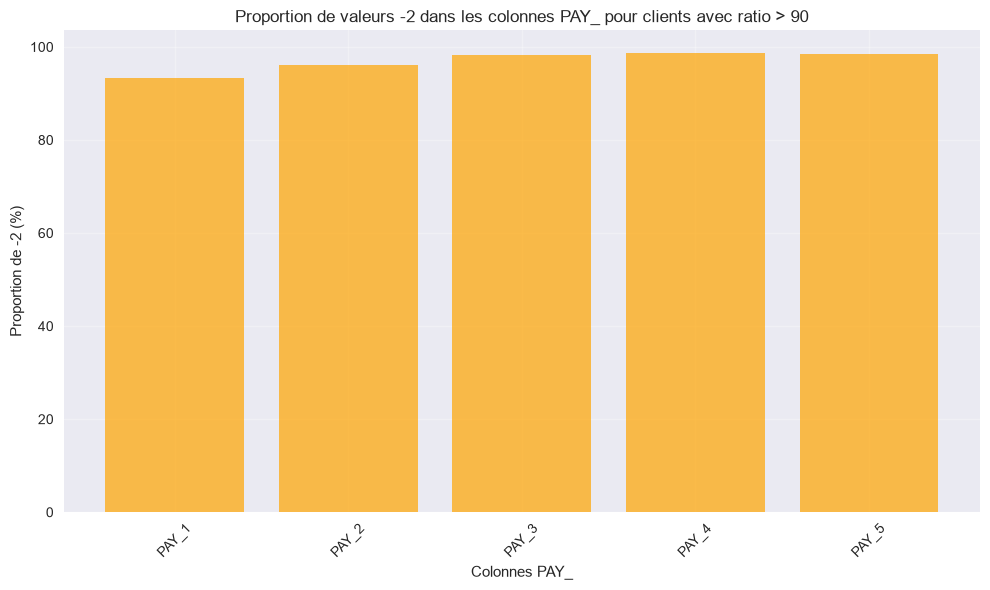

In [182]:
# Calculer la proportion de '-2' dans chaque colonne PAY_ pour les clients avec ratio > 90
if mask_gt_90.sum() > 0:
    # Compter le nombre total de -2 dans chaque colonne PAY_ pour les clients avec ratio > 90
    count_neg2_gt_90 = df.loc[mask_gt_90, pay_columns].eq(-2).sum()
    
    # Compter le nombre total de -2 dans chaque colonne PAY_ dans l'ensemble du dataset
    count_neg2_total = df[pay_columns].eq(-2).sum()
    
    # Calculer les proportions : proportion de -2 des clients avec ratio > 90 par rapport au total
    proportions_gt_90 = (count_neg2_gt_90 / count_neg2_total) * 100
    
    print("\n=== Proportions de '-2' dans les colonnes PAY_ ===")
    print("Pour les clients avec ratio_PAY_to_BILL_median > 90 :")
    for col in pay_columns:
        if count_neg2_total[col] > 0:  # Pour éviter la division par zéro
            print(f"{col}: {proportions_gt_90[col]:.2f}% ({count_neg2_gt_90[col]} sur {count_neg2_total[col]})")
        else:
            print(f"{col}: 0.00% (aucun -2 dans cette colonne)")
    
    # Optionnel : créer un graphique des proportions
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(proportions_gt_90)), proportions_gt_90.values, color='orange', alpha=0.7)
    plt.xlabel('Colonnes PAY_')
    plt.ylabel('Proportion de -2 (%)')
    plt.title('Proportion de valeurs -2 dans les colonnes PAY_ pour clients avec ratio > 90')
    plt.xticks(range(len(proportions_gt_90)), pay_columns, rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

**Inteprétation**  
La codification -2 semble être lié à une utilisation en paiement comptant de la carte

In [183]:
# -2 selon la facture du mois et son paiement le mois suivant (PAY_n avec BILL_AMTn et PAY_AMT(n-1))
lignes = []
for n in range(1, 7):
    m = df[f'PAY_{n}'] == -2
    facture = df.loc[m, f'BILL_AMT{n}']
    ligne = {'Mois': f'{MOIS[n]} (PAY_{n})', 'Codifications -2': int(m.sum()),
             'Pas de facture (%)': round((facture <= 0).mean() * 100, 1)}
    if n >= 2:
        solde = (facture > 0) & (df.loc[m, f'PAY_AMT{n - 1}'] >= facture)
        ligne['Facture soldée le mois suivant (%)'] = round(solde.mean() * 100, 1)
        ligne['Autre (%)'] = round(100 - ligne['Pas de facture (%)'] - ligne['Facture soldée le mois suivant (%)'], 1)
    lignes.append(ligne)
display(pd.DataFrame(lignes).set_index('Mois'))


,Codifications -2,Pas de facture (%),Facture soldée le mois suivant (%),Autre (%)
Mois,,,,
septembre (PAY_1),2758,32.7,NaN,NaN
août (PAY_2),3781,55.7,41.1,3.2
juillet (PAY_3),4084,61.5,36.2,2.3
juin (PAY_4),4347,66.8,31.2,2.0
mai (PAY_5),4544,68.2,29.7,2.1
avril (PAY_6),4895,70.8,27.3,1.9


**Interprétation**
-2 correspond presque toujours à un mois sans facture ou à une facture soldée le mois suivant : le client n'a pas de crédit à rembourser.
En septembre, beaucoup de -2 ont une facture, dont le paiement (octobre) n'est pas connu.

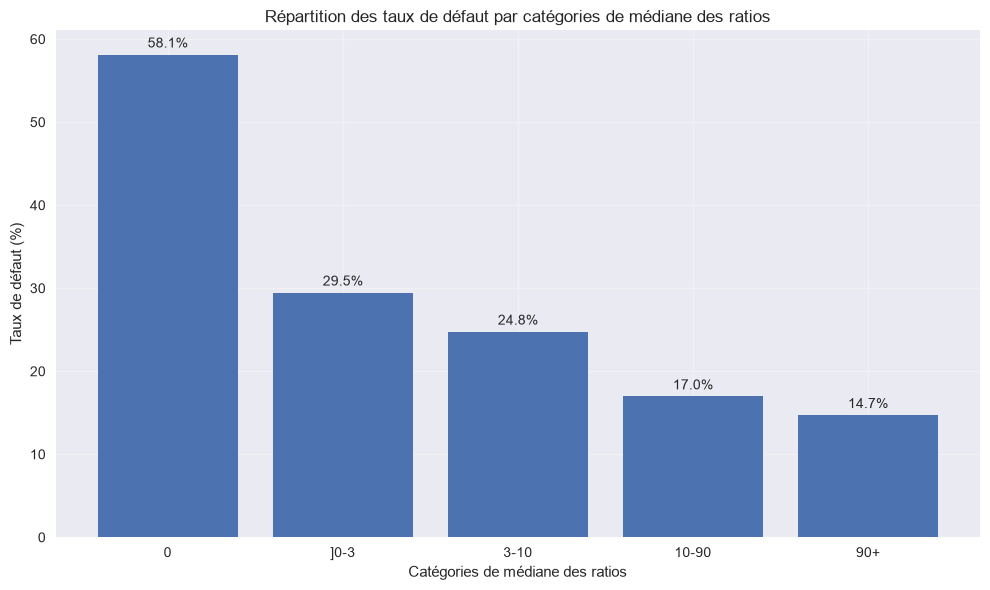

Statistiques de la répartition des taux de DPNM :
Nombre total de clients : 28590

Taux de DPNM par catégorie :
0: 58.13% (454/781 clients défauts/781 total)
]0-3: 29.46% (165/560 clients défauts/560 total)
3-10: 24.76% (3618/14613 clients défauts/14613 total)
10-90: 16.96% (770/4540 clients défauts/4540 total)
90+: 14.71% (1191/8096 clients défauts/8096 total)

Statistiques des médianes par client :
Moyenne des médianes : 36.1739
Médiane des médianes : 7.3601
Écart-type : 43.1257
Minimum : 0.0000
Maximum : 200.0000


In [184]:
import matplotlib.pyplot as plt
import numpy as np

# Définir les colonnes des ratios
ratio_columns = [
'ratio_PAY_BILL1',
'ratio_PAY_BILL2', 
'ratio_PAY_BILL3', 
'ratio_PAY_BILL4', 
'ratio_PAY_BILL5'
]

# Calculer la médiane de chaque ligne (médiane des ratios pour chaque client)
row_medians = ratios_affichables(df, ratio_columns).median(axis=1)

# Créer les catégories DPNM
def categorize_dpnms(median_value):
    if median_value == 0:
        return '0'
    elif median_value < 3 :
        return ']0-3'
    elif median_value < 10:
        return '3-10'
    elif median_value < 90:
        return '10-90'
    else:
        return '90+'

# Appliquer la catégorisation
# Clients sans aucune facture exigible sur la période : pas de médiane affichable, exclus
categories = row_medians.apply(categorize_dpnms).where(row_medians.notna())

# Calculer les taux de DPNM pour chaque catégorie
category_counts = categories.value_counts()
total_clients = int(row_medians.notna().sum())

# Calculer le taux de défaut (DPNM) par catégorie
dpmn_rates = {}
dpnm_counts = {}

for category in ['0',']0-3', '3-10', '10-90', '90+']:
    # Filtrer les clients de cette catégorie
    mask = categories == category
    clients_in_category = df[mask]
    
    # Calculer le taux de défaut (nombre de défauts / nombre total dans la catégorie)
    if len(clients_in_category) > 0:
        dpnm_count = clients_in_category['dpnm'].sum()  # Nombre de défauts
        dpnm_rate = (dpnm_count / len(clients_in_category)) * 100
        dpnm_counts[category] = dpnm_count
    else:
        dpnm_rate = 0
        dpnm_counts[category] = 0
    
    dpmn_rates[category] = dpnm_rate

# Créer le graphique en barres pour les taux de DPNM
plt.figure(figsize=(10, 6))
categories_list = ['0',']0-3', '3-10', '10-90', '90+']
rates = [dpmn_rates[cat] for cat in categories_list]

bars = plt.bar(categories_list, rates)

# Ajouter les étiquettes et le titre
plt.xlabel('Catégories de médiane des ratios')
plt.ylabel('Taux de défaut (%)')
plt.title('Répartition des taux de défaut par catégories de médiane des ratios')
plt.grid(True, alpha=0.3)

# Ajouter les valeurs sur les barres
for i, (bar, rate) in enumerate(zip(bars, rates)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{rate:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Afficher les statistiques détaillées
print("Statistiques de la répartition des taux de DPNM :")
print(f"Nombre total de clients : {total_clients}")
print("\nTaux de DPNM par catégorie :")
for category, rate in dpmn_rates.items():
    count = category_counts.get(category, 0)
    dpnm_count = dpnm_counts[category]
    print(f"{category}: {rate:.2f}% ({dpnm_count}/{count} clients défauts/{count} total)")

# Afficher également les statistiques sur les médianes
print("\nStatistiques des médianes par client :")
print(f"Moyenne des médianes : {row_medians.mean():.4f}")
print(f"Médiane des médianes : {row_medians.median():.4f}")
print(f"Écart-type : {row_medians.std():.4f}")
print(f"Minimum : {row_medians.min():.4f}")
print(f"Maximum : {row_medians.max():.4f}")

**Interprétation**  
Le type d'usage de la carte a clairement un impact sur le taux de défaut :
- ceux qui ont l'habitude de ne pas payer sont naturellement plus enclins à etre en défaut de paiement
- ceux qui utilisent la carte essentiellement à crédit  ont une taux de défaut plus haut que la moyenne et 2 fois plus important que ceux qui utilisent la carte comme un moyen de paiement standard (différé fin de mois)
- Plus le client a tendance à payer une grosse partie de ce qu'il doit chaque mois moins il a tendance à avoir un impayé

## Les retards sur les six mois

Part des clients en retard mois par mois (PAY_n = 2, PAY_n > 2, PAY_n > 1, PAY_n > 0). Rappel : `PAY_n` est la codification de la facture de fin du mois n, posée avec le paiement du mois suivant ; `PAY_1` dépend du paiement d'octobre.

In [185]:
# Calculer directement les pourcentages pour toutes les colonnes PAY_n
colonnes_pay = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# Créer un dictionnaire avec les pourcentages
pourcentages = {}
for col in colonnes_pay:
    pourcentages[col] = (df[col] == 2).mean() * 100

# Afficher les résultats
for col, pct in pourcentages.items():
    print(f"Pourcentage de {col} = 2 : {pct:.2f}%")

Pourcentage de PAY_1 = 2 : 8.89%
Pourcentage de PAY_2 = 2 : 13.09%
Pourcentage de PAY_3 = 2 : 12.73%
Pourcentage de PAY_4 = 2 : 10.53%
Pourcentage de PAY_5 = 2 : 8.75%
Pourcentage de PAY_6 = 2 : 9.22%


**Interprétation**
PAY_2 = 2 est plus fréquent que les autres mois. En septembre, la part des 2 baisse alors que beaucoup de clients sont codifiés 1 (codification 1 étudiée dans [05_04_EDA_codification1.ipynb](05_04_EDA_codification1.ipynb)).

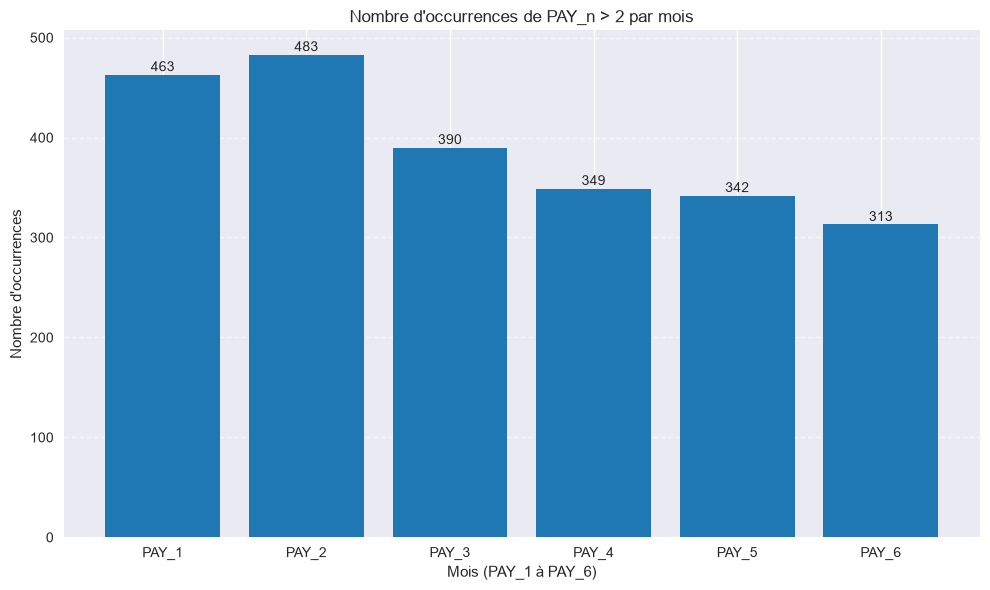

Résumé des occurrences de PAY_n > 2 :
    Mois  Occurrences
0  PAY_1          463
1  PAY_2          483
2  PAY_3          390
3  PAY_4          349
4  PAY_5          342
5  PAY_6          313


In [186]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Identifier les colonnes PAY_1 à PAY_6
colonnes_pay = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# Calculer le nombre d'occurrences de PAY_n > 2 pour chaque mois
occurrences = {}
for col in colonnes_pay:
    nb_occurrences = (df[col] > 2).sum()
    occurrences[col] = nb_occurrences

# Créer le graphique
plt.figure(figsize=(10, 6))

# Extraire les mois et les nombres d'occurrences
mois = list(occurrences.keys())
nb_occurrences = list(occurrences.values())

# Tracer le graphique en barres
bars = plt.bar(mois, nb_occurrences, color='#1f77b4')

# Ajouter les valeurs sur les barres
for i, (m, nb) in enumerate(zip(mois, nb_occurrences)):
    plt.text(i, nb + 0.5, str(nb), ha='center', va='bottom', fontsize=10)

plt.title('Nombre d\'occurrences de PAY_n > 2 par mois')
plt.xlabel('Mois (PAY_1 à PAY_6)')
plt.ylabel('Nombre d\'occurrences')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Afficher les résultats sous forme de tableau
print("Résumé des occurrences de PAY_n > 2 :")
resultats = pd.DataFrame({
    'Mois': mois,
    'Occurrences': nb_occurrences
})
print(resultats)

**Interprétation**
Hausse du nombre de clients en retard grave (3 et plus) sur la période.

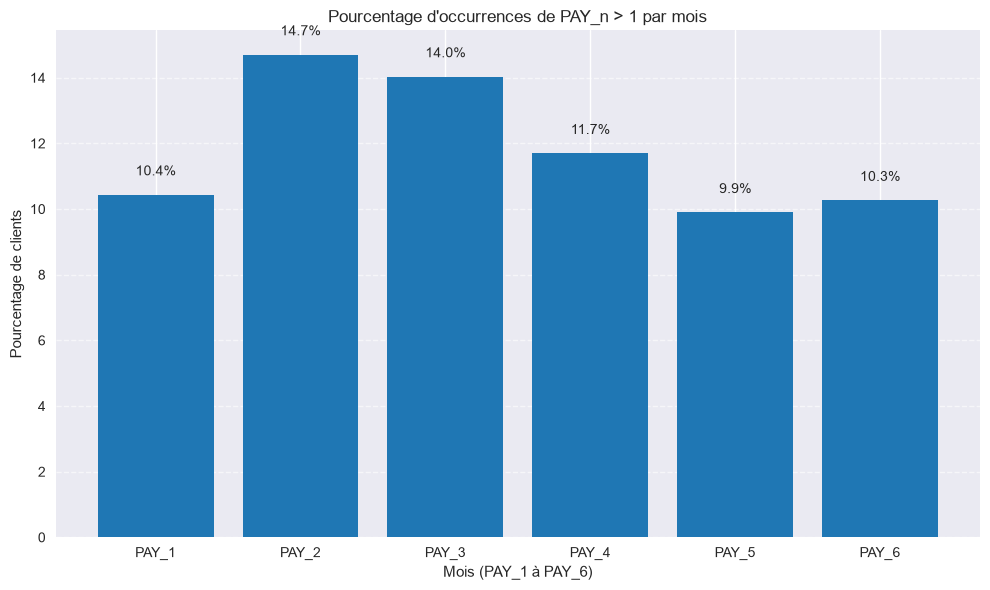

Résumé des pourcentages de PAY_n > 1 :
    Mois  Pourcentage
0  PAY_1    10.434725
1  PAY_2    14.701960
2  PAY_3    14.031871
3  PAY_4    11.694893
4  PAY_5     9.894653
5  PAY_6    10.264702


In [187]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Identifier les colonnes PAY_1 à PAY_6
colonnes_pay = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# Calculer le nombre d'occurrences de PAY_n > 1 pour chaque mois
occurrences = {}
for col in colonnes_pay:
    nb_occurrences = (df[col] > 1).sum()
    occurrences[col] = nb_occurrences

# Calculer les pourcentages par rapport au nombre total de clients
total_clients = len(df)
pourcentages = {}
for col, nb in occurrences.items():
    pourcentages[col] = (nb / total_clients) * 100

# Créer le graphique
plt.figure(figsize=(10, 6))

# Extraire les mois et les pourcentages
mois = list(pourcentages.keys())
pourcentages_values = list(pourcentages.values())

# Tracer le graphique en barres
bars = plt.bar(mois, pourcentages_values, color='#1f77b4')

# Ajouter les valeurs sur les barres
for i, (m, pct) in enumerate(zip(mois, pourcentages_values)):
    plt.text(i, pct + 0.5, f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)

plt.title('Pourcentage d\'occurrences de PAY_n > 1 par mois')
plt.xlabel('Mois (PAY_1 à PAY_6)')
plt.ylabel('Pourcentage de clients')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Afficher les résultats sous forme de tableau
print("Résumé des pourcentages de PAY_n > 1 :")
resultats = pd.DataFrame({
    'Mois': mois,
    'Pourcentage': pourcentages_values
})
print(resultats)

**Interprétation**
Hausse des retards (2 et plus) jusqu'en août ; en septembre, la baisse coïncide avec les codifications 1.

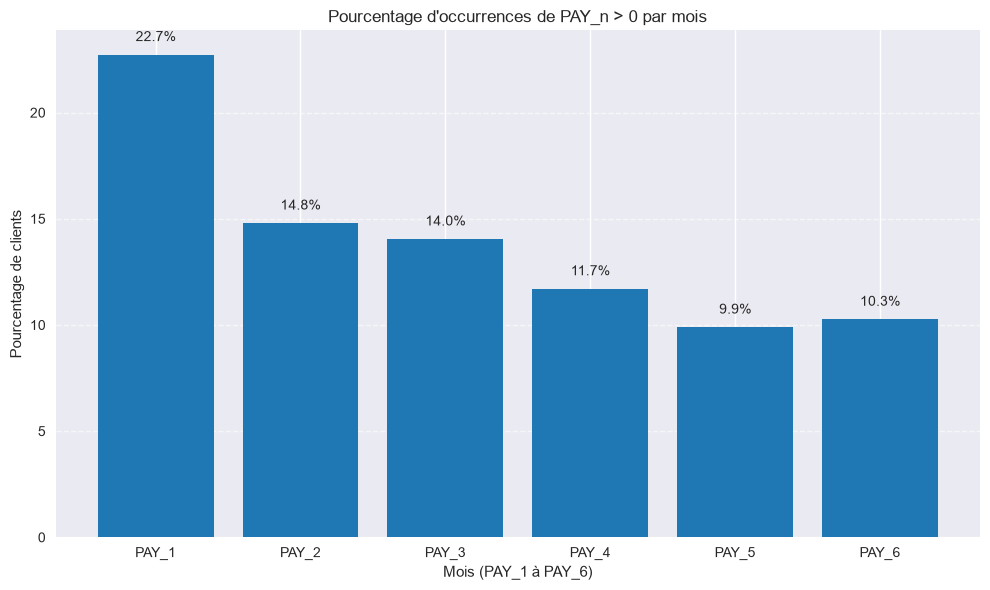

Résumé des pourcentages de PAY_n > 0 :
    Mois  Pourcentage
0  PAY_1    22.729697
1  PAY_2    14.795306
2  PAY_3    14.045206
3  PAY_4    11.701560
4  PAY_5     9.894653
5  PAY_6    10.264702


In [188]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Identifier les colonnes PAY_1 à PAY_6
colonnes_pay = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# Calculer le nombre d'occurrences de PAY_n > 0 pour chaque mois
occurrences = {}
for col in colonnes_pay:
    nb_occurrences = (df[col] > 0).sum()
    occurrences[col] = nb_occurrences

# Calculer les pourcentages par rapport au nombre total de clients
total_clients = len(df)
pourcentages = {}
for col, nb in occurrences.items():
    pourcentages[col] = (nb / total_clients) * 100

# Créer le graphique
plt.figure(figsize=(10, 6))

# Extraire les mois et les pourcentages
mois = list(pourcentages.keys())
pourcentages_values = list(pourcentages.values())

# Tracer le graphique en barres
bars = plt.bar(mois, pourcentages_values, color='#1f77b4')

# Ajouter les valeurs sur les barres
for i, (m, pct) in enumerate(zip(mois, pourcentages_values)):
    plt.text(i, pct + 0.5, f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)

plt.title('Pourcentage d\'occurrences de PAY_n > 0 par mois')
plt.xlabel('Mois (PAY_1 à PAY_6)')
plt.ylabel('Pourcentage de clients')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Afficher les résultats sous forme de tableau
print("Résumé des pourcentages de PAY_n > 0 :")
resultats = pd.DataFrame({
    'Mois': mois,
    'Pourcentage': pourcentages_values
})
print(resultats)

**Interprétation**
En comptant aussi les codifications 1 (PAY_n > 0), la part grimpe nettement en septembre : la lecture du dernier mois dépend de ce que représentent les 1 de septembre (05_04).

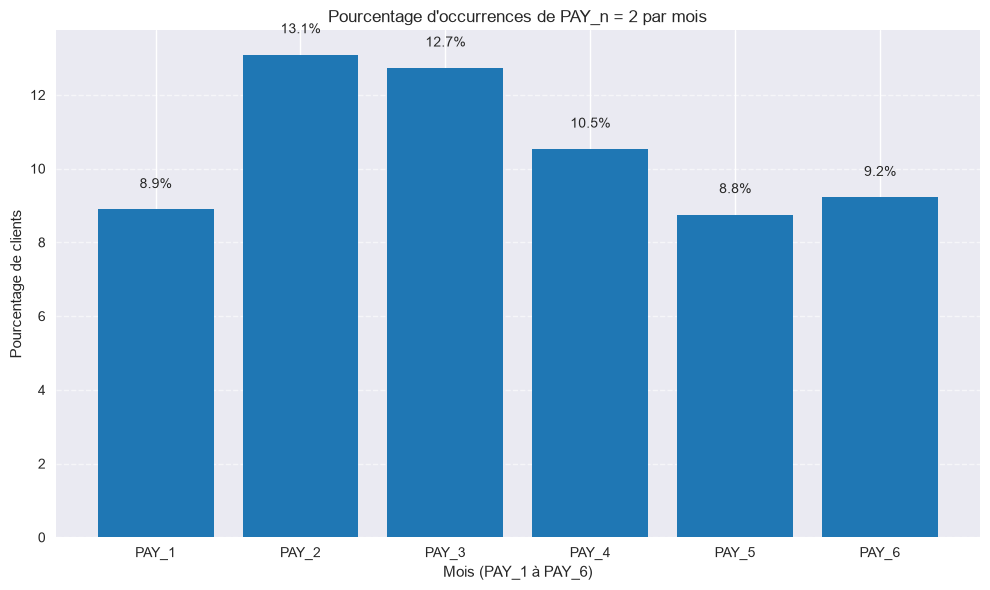

In [189]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Identifier les colonnes PAY_1 à PAY_6
colonnes_pay = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# Calculer le nombre d'occurrences de PAY_n = 2 pour chaque mois
occurrences = {}
for col in colonnes_pay:
    nb_occurrences = (df[col] == 2).sum()
    occurrences[col] = nb_occurrences

# Calculer les pourcentages par rapport au nombre total de clients
total_clients = len(df)
pourcentages = {}
for col, nb in occurrences.items():
    pourcentages[col] = (nb / total_clients) * 100

# Créer le graphique
plt.figure(figsize=(10, 6))

# Extraire les mois et les pourcentages
mois = list(pourcentages.keys())
pourcentages_values = list(pourcentages.values())

# Tracer le graphique en barres
bars = plt.bar(mois, pourcentages_values, color='#1f77b4')

# Ajouter les valeurs sur les barres
for i, (mois, pct) in enumerate(zip(mois, pourcentages_values)):
    plt.text(i, pct + 0.5, f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)

plt.title('Pourcentage d\'occurrences de PAY_n = 2 par mois')
plt.xlabel('Mois (PAY_1 à PAY_6)')
plt.ylabel('Pourcentage de clients')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [190]:
import pandas as pd

# 1. Identification des colonnes de statut de paiement (PAY_1 à PAY_6)
cols_pay = [
    c
    for c in ['PAY_1', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    if c in df.columns
]

# 2. Masque pour interroger la présence continue de la valeur 2
mask_always_2 = (df[cols_pay] == 2).all(axis=1)

# 3. Décompte total dans la base
count_always_2 = mask_always_2.sum()

print(
    f"Nombre total de clients avec PAY_n == 2 sur les 6 mois : {count_always_2}"
)

# 4. Isolement du sous-ensemble de clients
df_always_2 = df[mask_always_2]

# Affichage des colonnes clés
cols_display = [
    c
    for c in ['ID', 'LIMIT_BAL']
    + cols_pay
    + ['BILL_AMT1', 'BILL_AMT6', 'PAY_AMT1', 'dpnm']
    if c in df.columns
]
display(df_always_2[initial_col].head(10))
print(f"taux de défaut sur cette population : {round(df_always_2['dpnm'].sum()/len(df_always_2)*100,2)}%")

Nombre total de clients avec PAY_n == 2 sur les 6 mois : 530


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm
ID,,,,,,,,,,,,,,,,,,,,,
63,50000,1,1,2,29,2,2,2,2,2,...,25865,27667,28264,0,2700,0,2225,1200,0,1
72,320000,1,2,2,29,2,2,2,2,2,...,58622,62307,63526,2500,2500,0,4800,2400,1600,1
91,200000,1,1,1,53,2,2,2,2,2,...,144098,147124,149531,6300,5500,5500,5500,5000,5000,1
188,200000,2,3,2,47,2,2,2,2,2,...,196186,200162,189915,8214,7000,6800,7134,0,6836,1
330,150000,1,1,1,40,2,2,2,2,2,...,104975,107147,109428,5200,0,8100,4000,4200,4200,0
400,120000,2,2,2,25,2,2,2,2,2,...,116313,119311,117167,4007,0,8272,5000,0,4400,0
405,160000,2,1,2,29,2,2,2,2,2,...,166893,170098,153800,7500,0,11558,5800,0,5654,1
514,50000,1,2,2,23,2,2,2,2,2,...,31924,32566,33081,2000,1500,1300,1300,1200,1500,1
649,280000,2,2,1,44,2,2,2,2,2,...,195517,199250,195874,0,15000,8000,7000,0,15000,1


taux de défaut sur cette population : 77.55%


J'ai mis le doigt sur quelque chose
On a une codification gelée en 2 pour 530 clients avec un taux de défaut de 77%, cela ressemble à une gestion contentieuse.
Puis-je le vérifier ? Ces comptes sont-ils gelés ? Étude dans [05_02_EDA_contentieux.ipynb](05_02_EDA_contentieux.ipynb).

## L'utilisation du plafond et la vie des comptes

--- Décompte des clients par nombre d'occurrences de Ratio == 0 ---
Nombre de clients avec exactement 0 fois un ratio nul : 22437
Nombre de clients avec exactement 1 fois un ratio nul : 5016
Nombre de clients avec exactement 2 fois un ratio nul : 1849
Nombre de clients avec exactement 3 fois un ratio nul : 407
Nombre de clients avec exactement 4 fois un ratio nul : 113
Nombre de clients avec exactement 5 fois un ratio nul : 174
Nombre de clients avec 6 ou plus de ratios nuls : 0


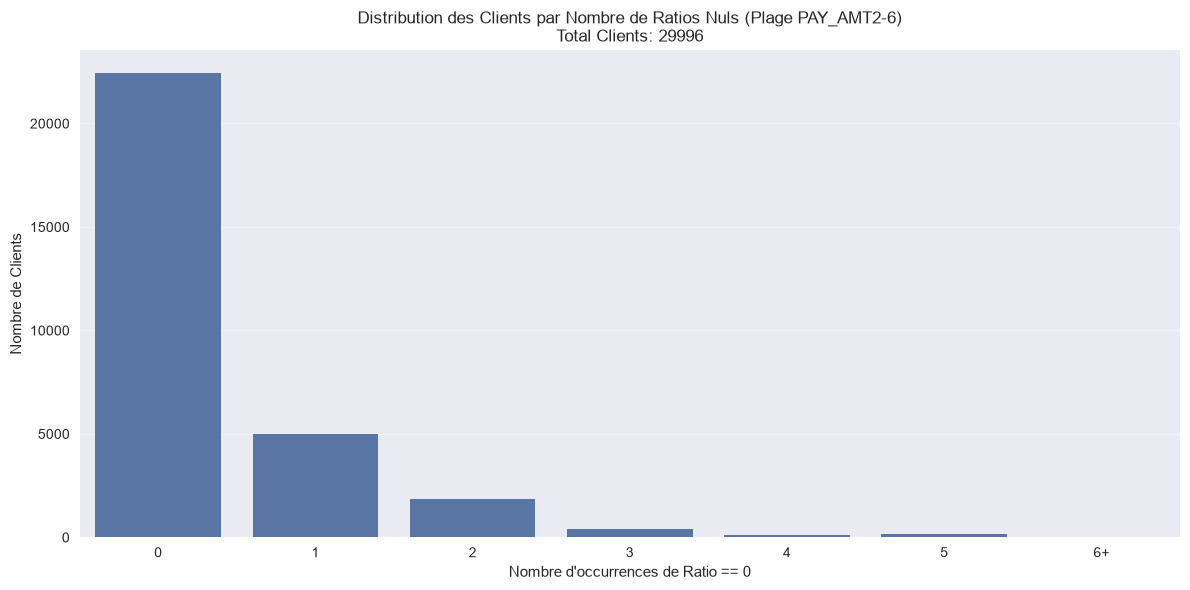

In [191]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cols_ciblees = [
    'ratio_PAY_BILL1',
    'ratio_PAY_BILL2', 
    'ratio_PAY_BILL3', 
    'ratio_PAY_BILL4', 
    'ratio_PAY_BILL5'
]

    
# 2. Création d'un masque booléen : True si le ratio est ~0, False sinon
# On utilise une tolérance très faible (< 0.01) pour éviter les problèmes d'arrondi float
mask_zeros = np.abs(df_ratios) < 0.01

# 3. Comptage des occurrences de zéro PAR CLIENT (par ligne)
# sum(axis=1) additionne les True (valeur 1) pour chaque ligne
zero_counts_per_client = mask_zeros.sum(axis=1)

# 4. Filtrage et Décompte pour les cas spécifiques (0, 1, ..., 5 fois)
# On filtre pour ne garder que les clients qui ont eu au moins un zero, 
# ou on garde tout si tu veux voir ceux à 0 aussi.
# Ici, je vais compter l'histogramme complet de 0 à max(zeros).

# Comptage des effectifs : combien de clients ont eu X occurrences ?
freq_distribution = zero_counts_per_client.value_counts().sort_index()



print("--- Décompte des clients par nombre d'occurrences de Ratio == 0 ---")

for i in range(6): # De 0 à 5
    count_clients = freq_distribution.get(i, 0)
    print(f"Nombre de clients avec exactement {i} fois un ratio nul : {count_clients}")
    
# Pour les cas > 5 (6, 7...)
clients_plus_5 = zero_counts_per_client[zero_counts_per_client >= 6].shape[0]
print(f"Nombre de clients avec 6 ou plus de ratios nuls : {clients_plus_5}")

# --- Visualisation Graphique ---
# On prépare les données pour le graphique en ne gardant que 0 à 5, et on regroupe >5 dans une catégorie "6+"
labels_plot = []
values_plot = []

for i in range(6):
    if i in freq_distribution.index:
        labels_plot.append(str(i))
        values_plot.append(freq_distribution[i])
    else:
        labels_plot.append(str(i))
        values_plot.append(0) # Si aucune donnée pour cette case
        
# Ajout du cas "6+"
labels_plot.append("6+")
values_plot.append(clients_plus_5)

plt.figure(figsize=(12, 6))
sns.barplot(x=labels_plot, y=values_plot)
plt.title(f'Distribution des Clients par Nombre de Ratios Nuls (Plage PAY_AMT2-6)\nTotal Clients: {len(zero_counts_per_client)}')
plt.xlabel('Nombre d\'occurrences de Ratio == 0')
plt.ylabel('Nombre de Clients')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [192]:
import pandas as pd
import numpy as np

# Tes colonnes définies pour le calcul
cols_ciblees = [
    'ratio_PAY_BILL1',
    'ratio_PAY_BILL2', 
    'ratio_PAY_BILL3', 
    'ratio_PAY_BILL4', 
    'ratio_PAY_BILL5'
]

# 1. Calcul du nombre de zéros par client (ligne)
df_ratios = df[cols_ciblees]
# Masque : True si abs(ratio) < tolérance (pour gérer les flottants proches de 0)
mask_zeros = np.abs(df_ratios) < 0.01

# Somme par ligne -> nombre de colonnes ciblées qui sont ~0 pour ce client
counts_zeros_per_client = mask_zeros.sum(axis=1)

# --- BOUCLE SUR LES CAS DEMANDÉS (3, 4 et 5 fois) ---
cas_cibles = [3, 4, 5]

for nb_zeros in cas_cibles:
    print("\n" + "="*60)
    print(f"--- GROUPE : Clients avec EXACTEMENT {nb_zeros} Ratios Nuls ---")
    print("="*60)
    
    # On filtre l'index original pour le nombre exact de zéros
    idx_groupe = counts_zeros_per_client[counts_zeros_per_client == nb_zeros].index
    
    if len(idx_groupe) > 0:
        print(f"Nombre total de clients dans ce groupe : {len(idx_groupe)}")
        
        # On prend les 10 premières lignes COMPLETES du dataframe original
        df_head = df.loc[idx_groupe].head(10)
        
        print(f"\n--- APERÇU DES 10 PREMIÈRES LIGNES (LIGNES COMPLÈTES) ---")
        # pd.set_option pour afficher toutes les colonnes sans troncature si possible
        with pd.option_context('display.max_columns', None, 'display.width', 1000):
            print(df_head)
        
    else:
        print(f"Aucun client trouvé avec exactement {nb_zeros} ratios nuls.")

# --- RÉCAPITULATIF GLOBAL (pour info) ---
print("\n" + "="*60)
print("--- RÉCAPITULATIF DU NOMBRE DE CLIENTS PAR NOMBRE DE ZEROS ---")
print("="*60)

dist_zeros = counts_zeros_per_client.value_counts().sort_index()

for i in range(0, 6): # De 0 à 5
    count = dist_zeros.get(i, 0)
    print(f"Nombre de clients avec exactement {i} ratio(s) nul(s) : {count}")




--- GROUPE : Clients avec EXACTEMENT 3 Ratios Nuls ---
Nombre total de clients dans ce groupe : 407

--- APERÇU DES 10 PREMIÈRES LIGNES (LIGNES COMPLÈTES) ---
     LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_1  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  dpnm  ratio_brut_PAY_BILL1  ratio_brut_PAY_BILL2  ratio_brut_PAY_BILL3  ratio_brut_PAY_BILL4  ratio_brut_PAY_BILL5  ratio_PAY_BILL1  ratio_PAY_BILL2  ratio_PAY_BILL3  ratio_PAY_BILL4  ratio_PAY_BILL5  ratio_PAY_to_BILL_median
ID                                                                                                                                                                                                                                                                                                                                                                                                             

Je crée une feature 'ratio_BILL_LIMITn' pour voir l'utilisation par rapport au plafond chaque mois

In [193]:
import pandas as pd
import numpy as np

# Vérification rapide des colonnes BILL_AMT existantes
bill_cols = [col for col in df.columns if col.startswith('BILL_AMT')]
print(f"Colonnes BILL_AMT trouvées : {bill_cols}")

# Boucle pour créer les 6 nouvelles colonnes de ratio
for i in range(1, 7):
    df[f'ratio_BILL_LIMIT{i}'] = (np.maximum(df[f'BILL_AMT{i}'], 0) / df['LIMIT_BAL']) * 100

# Affichage des premières lignes pour inspection
# On filtre pour ne voir que les colonnes BILL_AMT et ratio_BILL_LIMIT concernées
cols_to_show = bill_cols + [f'ratio_BILL_LIMIT{n}' for n in range(1, 7)]+['LIMIT_BAL']
pd.option_context('display.max_columns', None, 'display.width', 1000)

print("\n--- Aperçu des nouveaux ratios ---")
df[cols_to_show].head(10)

Colonnes BILL_AMT trouvées : ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

--- Aperçu des nouveaux ratios ---


,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,ratio_BILL_LIMIT1,ratio_BILL_LIMIT2,ratio_BILL_LIMIT3,ratio_BILL_LIMIT4,ratio_BILL_LIMIT5,ratio_BILL_LIMIT6,LIMIT_BAL
ID,,,,,,,,,,,,,
1,3913,3102,689,0,0,0,19.565000,15.510000,3.445000,0.000000,0.000000,0.000000,20000
2,2682,1725,2682,3272,3455,3261,2.235000,1.437500,2.235000,2.726667,2.879167,2.717500,120000
3,29239,14027,13559,14331,14948,15549,32.487778,15.585556,15.065556,15.923333,16.608889,17.276667,90000
4,46990,48233,49291,28314,28959,29547,93.980000,96.466000,98.582000,56.628000,57.918000,59.094000,50000
5,8617,5670,35835,20940,19146,19131,17.234000,11.340000,71.670000,41.880000,38.292000,38.262000,50000
6,64400,57069,57608,19394,19619,20024,128.800000,114.138000,115.216000,38.788000,39.238000,40.048000,50000
7,367965,412023,445007,542653,483003,473944,73.593000,82.404600,89.001400,108.530600,96.600600,94.788800,500000
8,11876,380,601,221,-159,567,11.876000,0.380000,0.601000,0.221000,0.000000,0.567000,100000
9,11285,14096,12108,12211,11793,3719,8.060714,10.068571,8.648571,8.722143,8.423571,2.656429,140000


In [194]:
cols_ratio = [f'ratio_BILL_LIMIT{i}' for i in range(1, 7)]

# Statistiques descriptives détaillées des 6 colonnes de ratio (transposées pour une meilleure lisibilité)
df[cols_ratio].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).T

,count,mean,std,min,5%,25%,50%,75%,90%,95%,99%,max
ratio_BILL_LIMIT1,29996.0,42.395587,41.126764,0.0,0.0,2.203167,31.399386,82.989413,98.162778,101.312412,123.194646,645.530
ratio_BILL_LIMIT2,29996.0,41.138631,40.416234,0.0,0.0,1.832621,29.605750,80.650000,97.840000,101.036584,116.423837,638.050
ratio_BILL_LIMIT3,29996.0,39.202319,39.119409,0.0,0.0,1.602141,27.297667,75.499163,96.975833,100.165417,111.650879,539.140
ratio_BILL_LIMIT4,29996.0,35.990505,36.806109,0.0,0.0,1.429853,24.204586,66.799970,93.953000,98.626417,105.478263,514.685
ratio_BILL_LIMIT5,29996.0,33.346320,35.005624,0.0,0.0,1.113309,21.202632,60.224500,90.056111,97.430000,103.094214,493.550
ratio_BILL_LIMIT6,29996.0,31.902083,34.443932,0.0,0.0,0.780000,18.517267,58.210500,88.634444,97.384062,102.230300,388.555


In [195]:
df.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm',
       'ratio_brut_PAY_BILL1', 'ratio_brut_PAY_BILL2', 'ratio_brut_PAY_BILL3',
       'ratio_brut_PAY_BILL4', 'ratio_brut_PAY_BILL5', 'ratio_PAY_BILL1',
       'ratio_PAY_BILL2', 'ratio_PAY_BILL3', 'ratio_PAY_BILL4',
       'ratio_PAY_BILL5', 'ratio_PAY_to_BILL_median', 'ratio_BILL_LIMIT1',
       'ratio_BILL_LIMIT2', 'ratio_BILL_LIMIT3', 'ratio_BILL_LIMIT4',
       'ratio_BILL_LIMIT5', 'ratio_BILL_LIMIT6'],
      dtype='str')

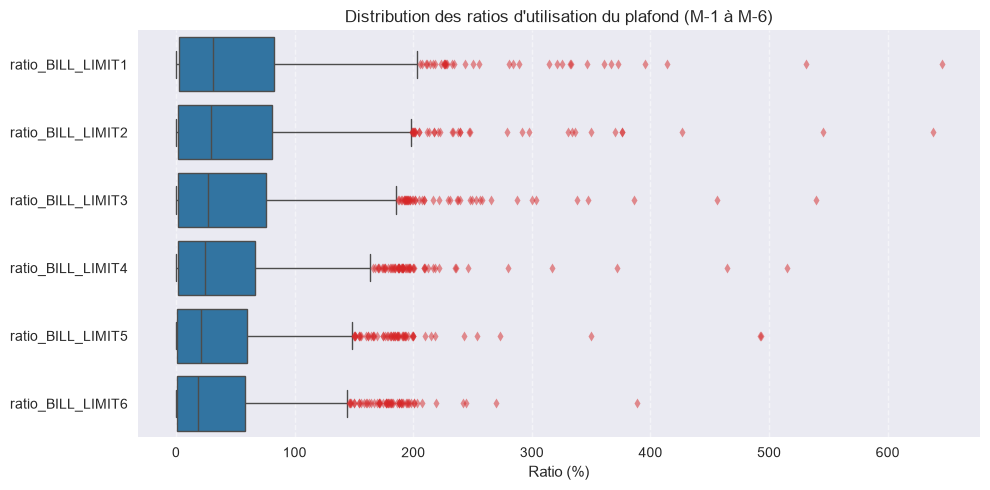

In [196]:
import matplotlib.pyplot as plt
import seaborn as sns

ratio_cols = [
    'ratio_BILL_LIMIT1', 'ratio_BILL_LIMIT2', 'ratio_BILL_LIMIT3',
    'ratio_BILL_LIMIT4', 'ratio_BILL_LIMIT5', 'ratio_BILL_LIMIT6'
]

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df[ratio_cols],
    orient='h',
    color='#1f77b4',
    flierprops={'marker': 'd', 'markerfacecolor': '#d62728', 'markeredgecolor': 'none', 'alpha': 0.5, 'markersize': 5}
)

plt.title("Distribution des ratios d'utilisation du plafond (M-1 à M-6)")
plt.xlabel('Ratio (%)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Interprétation**  
Des valeurs extremes difficilement explicable mais 2 théories non vérifiables :
- plafond baissé par la banque pour problème de paiement ou revue des revenus du client
- erreur de saisie dans le montant à devoir (il arrive que des montants soient multpliés par 100)
On peut essayer de controler si c'est une anomalie temporaire ou systémique chez un client

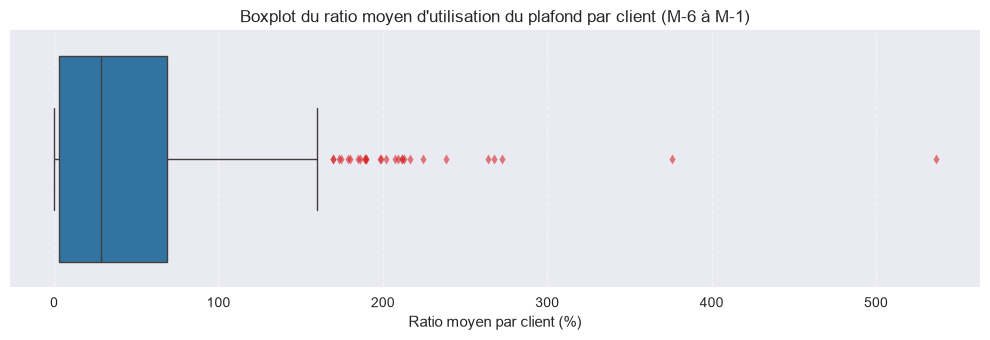

Nombre de clients avec un ratio moyen > 150 % : 37


,LIMIT_BAL,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,ratio_BILL_LIMIT1,ratio_BILL_LIMIT2,ratio_BILL_LIMIT3,ratio_BILL_LIMIT4,ratio_BILL_LIMIT5,ratio_BILL_LIMIT6,ratio_mean_client
ID,,,,,,,,,,,,,,
671,30000,99568,32326,31840,37075,37662,36904,331.893333,107.753333,106.133333,123.583333,125.540000,123.013333,152.986111
919,240000,471814,478380,395612,386295,356206,352257,196.589167,199.325000,164.838333,160.956250,148.419167,146.773750,169.483611
969,20000,42784,41009,44267,47149,48497,14774,213.920000,205.045000,221.335000,235.745000,242.485000,73.870000,198.733333
1676,50000,90231,90647,92309,93880,99418,101392,180.462000,181.294000,184.618000,187.760000,198.836000,202.784000,189.292333
2899,20000,66599,67259,69521,16970,17326,17688,332.995000,336.295000,347.605000,84.850000,86.630000,88.440000,212.802500
2917,20000,43340,42619,35381,31539,27409,23567,216.700000,213.095000,176.905000,157.695000,137.045000,117.835000,169.879167
3797,20000,129106,127610,107828,102937,98525,77711,645.530000,638.050000,539.140000,514.685000,492.625000,388.555000,536.430833
4223,30000,69707,71904,62630,57406,46231,73262,232.356667,239.680000,208.766667,191.353333,154.103333,244.206667,211.744444
4383,40000,144397,147924,26974,22710,37977,39347,360.992500,369.810000,67.435000,56.775000,94.942500,98.367500,174.720417


In [197]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ratio_cols = [f'ratio_BILL_LIMIT{i}' for i in range(1, 7)]

# 1. Calcul du ratio moyen et max par client
df['ratio_mean_client'] = df[ratio_cols].mean(axis=1)
df['ratio_max_client'] = df[ratio_cols].max(axis=1)

# 2. Boxplot du ratio moyen par client
plt.figure(figsize=(10, 3.5))
sns.boxplot(
    x=df['ratio_mean_client'],
    color='#1f77b4',
    flierprops={'marker': 'd', 'markerfacecolor': '#d62728', 'markeredgecolor': 'none', 'alpha': 0.6, 'markersize': 5}
)

plt.title("Boxplot du ratio moyen d'utilisation du plafond par client (M-6 à M-1)")
plt.xlabel("Ratio moyen par client (%)")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 3. Sélection et affichage des lignes des clients avec un ratio moyen > 200 %
cols_cles = ['LIMIT_BAL'] + [f'BILL_AMT{i}' for i in range(1, 7)] + ratio_cols + ['ratio_mean_client']
clients_sup_150 = df[df['ratio_mean_client'] > 150][cols_cles]

print(f"Nombre de clients avec un ratio moyen > 150 % : {len(clients_sup_150)}")
clients_sup_150

Ces valeurs semblent etre un comportement d'usage excessif volontaaire des clients et non une anomalie  
j'écrête ces valeurs à 200 % (0 en bas pour les encours négatifs), comme dans le storytelling, Streamlit et le ML, pour éviter les distorsions.
Je créerai une feature 'usage_excessif' pour les clients ayant un ratio_BILL_LIMIT conséquent (à partir de 120 ou 150)

In [198]:
ratio_cols = [f'ratio_BILL_LIMIT{i}' for i in range(1, 7)]

# Écrêtage directement sur les colonnes d'origine
for col in ratio_cols:
    df[col] = df[col].clip(lower=0, upper=200)

# Recalcul des métriques agrégées par client
df['ratio_mean_client'] = df[ratio_cols].mean(axis=1)
df['ratio_max_client'] = df[ratio_cols].max(axis=1)

# Vérification : le maximum doit désormais être à 200.00
df[ratio_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
ratio_BILL_LIMIT1,29996.0,42.288866,40.463846,0.0,2.203167,31.399386,82.989413,200.0
ratio_BILL_LIMIT2,29996.0,41.047089,39.817960,0.0,1.832621,29.605750,80.650000,200.0
ratio_BILL_LIMIT3,29996.0,39.137840,38.720131,0.0,1.602141,27.297667,75.499163,200.0
ratio_BILL_LIMIT4,29996.0,35.951729,36.530494,0.0,1.429853,24.204586,66.799970,200.0
ratio_BILL_LIMIT5,29996.0,33.314724,34.756724,0.0,1.113309,21.202632,60.224500,200.0
ratio_BILL_LIMIT6,29996.0,31.889608,34.361416,0.0,0.780000,18.517267,58.210500,200.0


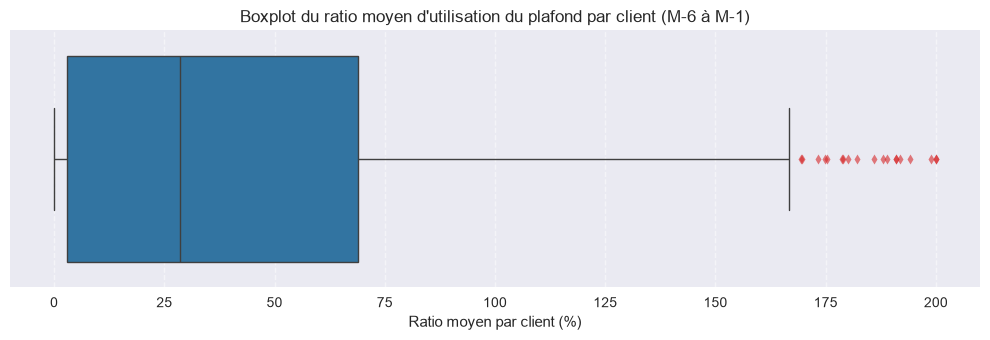

In [199]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ratio_cols = [f'ratio_BILL_LIMIT{i}' for i in range(1, 7)]

# 1. Calcul du ratio moyen et max par client
df['ratio_mean_client'] = df[ratio_cols].mean(axis=1)
df['ratio_max_client'] = df[ratio_cols].max(axis=1)

# 2. Boxplot du ratio moyen par client
plt.figure(figsize=(10, 3.5))
sns.boxplot(
    x=df['ratio_mean_client'],
    color='#1f77b4',
    flierprops={'marker': 'd', 'markerfacecolor': '#d62728', 'markeredgecolor': 'none', 'alpha': 0.6, 'markersize': 5}
)

plt.title("Boxplot du ratio moyen d'utilisation du plafond par client (M-6 à M-1)")
plt.xlabel("Ratio moyen par client (%)")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


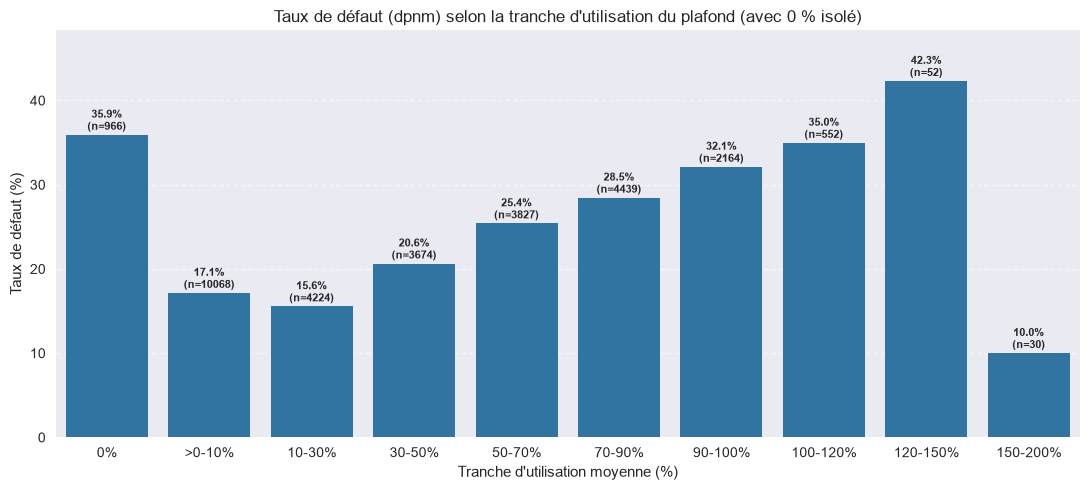

,ratio_mean_bin,nb_clients,taux_defaut
0,0%,966,35.921325
1,>0-10%,10068,17.143425
2,10-30%,4224,15.553977
3,30-50%,3674,20.631464
4,50-70%,3827,25.398484
5,70-90%,4439,28.452354
6,90-100%,2164,32.116451
7,100-120%,552,34.963768
8,120-150%,52,42.307692
9,150-200%,30,10.000000


In [200]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Redéfinition des tranches en isolant exactement la valeur 0 %
bins = [-0.01, 0.0, 10, 30, 50, 70, 90, 100, 120, 150, 200]
labels = ['0%', '>0-10%', '10-30%', '30-50%', '50-70%', '70-90%', '90-100%', '100-120%', '120-150%', '150-200%']

df['ratio_mean_bin'] = pd.cut(df['ratio_mean_client'], bins=bins, labels=labels)

# 2. Agrégation : effectifs et taux de défaut moyen (dpnm)
stats_defaut = df.groupby('ratio_mean_bin', observed=False)['dpnm'].agg(
    nb_clients='count',
    taux_defaut=lambda x: x.mean() * 100
).reset_index()

# 3. Tracé du graphique avec le bin 0 % isolé
plt.figure(figsize=(11, 5))
ax = sns.barplot(data=stats_defaut, x='ratio_mean_bin', y='taux_defaut', color='#1f77b4')

plt.title("Taux de défaut (dpnm) selon la tranche d'utilisation du plafond (avec 0 % isolé)")
plt.xlabel("Tranche d'utilisation moyenne (%)")
plt.ylabel("Taux de défaut (%)")
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Annotation du taux de défaut et du nombre de clients par barre
for i, row in stats_defaut.iterrows():
    if not pd.isna(row['taux_defaut']):
        plt.text(
            i, 
            row['taux_defaut'] + 0.6, 
            f"{row['taux_defaut']:.1f}%\n(n={int(row['nb_clients'])})", 
            ha='center', 
            fontsize=8, 
            fontweight='bold'
        )

plt.ylim(0, max(stats_defaut['taux_defaut'].dropna(), default=30) + 6)
plt.tight_layout()
plt.show()

# Tableau récapitulatif
stats_defaut

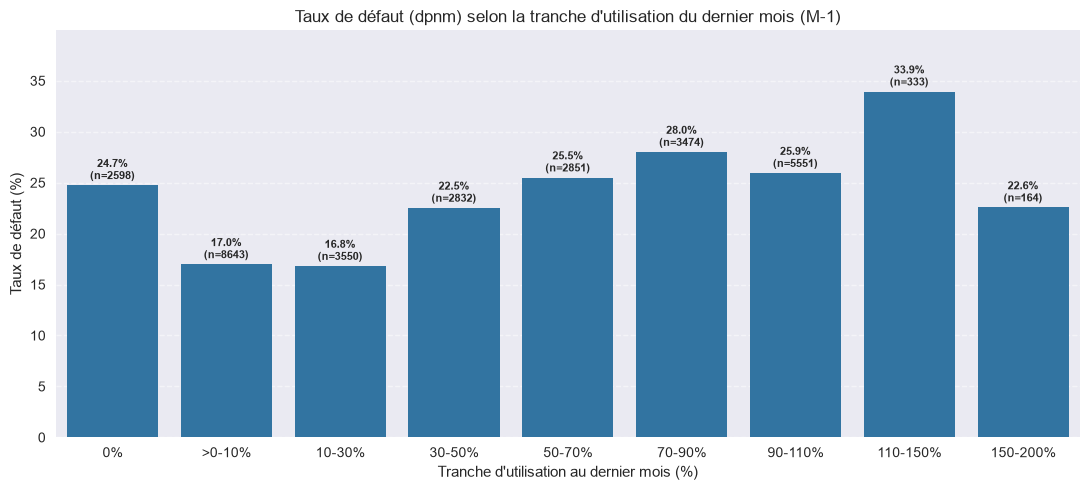

,ratio_m1_bin,nb_clients,taux_defaut
0,0%,2598,24.749808
1,>0-10%,8643,16.984843
2,10-30%,3550,16.816901
3,30-50%,2832,22.528249
4,50-70%,2851,25.499825
5,70-90%,3474,28.008060
6,90-110%,5551,25.941272
7,110-150%,333,33.933934
8,150-200%,164,22.560976


In [201]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tranches d'utilisation uniquement sur le dernier mois (ratio_BILL_LIMIT1)
bins = [-0.01, 0.0, 10, 30, 50, 70, 90, 110, 150, 200]
labels = ['0%', '>0-10%', '10-30%', '30-50%', '50-70%', '70-90%', '90-110%', '110-150%', '150-200%']

df['ratio_m1_bin'] = pd.cut(df['ratio_BILL_LIMIT1'], bins=bins, labels=labels)

# 2. Agrégation : effectifs et taux de défaut (dpnm) sur M-1
stats_defaut_m1 = df.groupby('ratio_m1_bin', observed=False)['dpnm'].agg(
    nb_clients='count',
    taux_defaut=lambda x: x.mean() * 100
).reset_index()

# 3. Tracé du graphique
plt.figure(figsize=(11, 5))
ax = sns.barplot(data=stats_defaut_m1, x='ratio_m1_bin', y='taux_defaut', color='#1f77b4')

plt.title("Taux de défaut (dpnm) selon la tranche d'utilisation du dernier mois (M-1)")
plt.xlabel("Tranche d'utilisation au dernier mois (%)")
plt.ylabel("Taux de défaut (%)")
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Annotation des barres
for i, row in stats_defaut_m1.iterrows():
    if not pd.isna(row['taux_defaut']):
        plt.text(
            i, 
            row['taux_defaut'] + 0.6, 
            f"{row['taux_defaut']:.1f}%\n(n={int(row['nb_clients'])})", 
            ha='center', 
            fontsize=8, 
            fontweight='bold'
        )

plt.ylim(0, max(stats_defaut_m1['taux_defaut'].dropna(), default=30) + 6)
plt.tight_layout()
plt.show()

# Tableau récapitulatif M-1
stats_defaut_m1

**Interprétation**  
Hausse du défaut de paiement en fonction de l'utilisation du plafond.  
2598 clients sans encours ayant un défaut de paiement, certains ayant meme un encours <=0 sur les 6 derniers mois.  
Pour rappel : les 30 000 clients, y compris inactifs, sont présents dans cet EDA  
Ces défauts sans encours sont regardés dans la partie « Défaut de paiement sans encours ».

In [202]:
import pandas as pd

# 1. Calcul du ratio moyen par client si non déjà présent dans le DataFrame
cols_ratio = [f'ratio_BILL_LIMIT{i}' for i in range(1, 7)]
df['ratio_mean_client'] = df[cols_ratio].mean(axis=1)

# 2. Filtrage des clients ayant une moyenne de ratio strictement égale à 0
df_ratio_zero = df[df['ratio_mean_client'] == 0].copy()

# 3. Sélection des colonnes pertinentes pour une inspection claire
cols_a_afficher = (
    ['LIMIT_BAL'] +
    [f'PAY_{i}' for i in range(1, 7) if f'PAY_{i}' in df.columns] +
    [f'BILL_AMT{i}' for i in range(1, 7)] +
    [f'PAY_AMT{i}' for i in range(1, 7)] +
    ['dpnm']
)

print(f"Nombre de clients avec ratio moyen = 0 % : {len(df_ratio_zero)}")

# Affichage du sous-ensemble de données
df_ratio_zero[cols_a_afficher]

Nombre de clients avec ratio moyen = 0 % : 966


,LIMIT_BAL,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm
ID,,,,,,,,,,,,,,,,,,,,
19,360000,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0
20,180000,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0
46,210000,-2,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,1
80,240000,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,1
110,360000,1,-2,-2,-2,-2,-2,-103,-103,-103,-103,-103,-103,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29910,360000,-2,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0
29923,150000,1,-2,-2,-2,-2,-2,-18,-18,-18,-18,-18,-18,0,0,0,0,0,0,0
29974,230000,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,1


In [203]:
import pandas as pd

cols_pay = [f'PAY_{i}' for i in range(1, 7) if f'PAY_{i}' in df.columns]
cols_bill = [f'BILL_AMT{i}' for i in range(1, 7)]

# 1. Isolation des clients ayant -2 sur l'ensemble des 6 mois
mask_always_minus2 = (df[cols_pay] == -2).all(axis=1)

# 2. Séparation : Avec au moins un encours positif VS strictement aucun encours
mask_has_positive_bill = (df[cols_bill] > 0).any(axis=1)

# Groupe 1 : Faux inactifs (PAY_n = -2 continu MAIS BILL_AMT > 0)
df_faux_inactifs = df[mask_always_minus2 & mask_has_positive_bill]

# Groupe 2 : Vrais inactifs (PAY_n = -2 ET BILL_AMT <= 0 partout)
df_vrais_inactifs = df[mask_always_minus2 & ~mask_has_positive_bill]

print("--- Décomposition des clients à PAY_n == -2 continu ---")
print(f"1. Vrais inactifs (Encours <= 0) : {len(df_vrais_inactifs)} clients | Taux de défaut : {df_vrais_inactifs['dpnm'].mean()*100:.2f}%")
print(f"2. Faux inactifs (Encours > 0)  : {len(df_faux_inactifs)} clients | Taux de défaut : {df_faux_inactifs['dpnm'].mean()*100:.2f}%")

--- Décomposition des clients à PAY_n == -2 continu ---
1. Vrais inactifs (Encours <= 0) : 361 clients | Taux de défaut : 32.69%
2. Faux inactifs (Encours > 0)  : 1748 clients | Taux de défaut : 9.50%


In [204]:
# Vérification des PAY_AMTn pour les vrais inactifs
cols_pay_amt = [f'PAY_AMT{i}' for i in range(1, 7)]

# Sont-ils tous à 0 ou <= 0 sur les 6 mois ?
all_pay_amt_zero = (df_vrais_inactifs[cols_pay_amt] <= 0).all(axis=1).sum()

print(f"Sur les 361 vrais inactifs :")
print(f"- Nombre avec des PAY_AMT <= 0 sur toute la période : {all_pay_amt_zero}")
print(f"- Nombre avec au moins un PAY_AMT > 0 : {len(df_vrais_inactifs) - all_pay_amt_zero}")

Sur les 361 vrais inactifs :
- Nombre avec des PAY_AMT <= 0 sur toute la période : 320
- Nombre avec au moins un PAY_AMT > 0 : 41


In [205]:
import pandas as pd

# 1. Calcul du ratio moyen par client si non déjà présent dans le DataFrame
cols_ratio = [f'ratio_BILL_LIMIT{i}' for i in range(1, 7)]
df['ratio_mean_client'] = df[cols_ratio].mean(axis=1)

# 2. Filtrage des clients ayant une moyenne de ratio strictement égale à 0
df_ratio_zero = df[df['ratio_mean_client'] == 0].copy()

# 3. Sélection des colonnes pertinentes pour une inspection claire
cols_a_afficher = (
    ['LIMIT_BAL'] +
    [f'PAY_{i}' for i in range(1, 7) if f'PAY_{i}' in df.columns] +
    [f'BILL_AMT{i}' for i in range(1, 7)] +
    [f'PAY_AMT{i}' for i in range(1, 7)] +
    ['dpnm']
)

print(f"Nombre de clients avec ratio moyen = 0 % : {len(df_ratio_zero)}")

# Affichage du sous-ensemble de données
df_ratio_zero[cols_a_afficher]

Nombre de clients avec ratio moyen = 0 % : 966


,LIMIT_BAL,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm
ID,,,,,,,,,,,,,,,,,,,,
19,360000,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0
20,180000,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0
46,210000,-2,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,1
80,240000,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,1
110,360000,1,-2,-2,-2,-2,-2,-103,-103,-103,-103,-103,-103,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29910,360000,-2,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0
29923,150000,1,-2,-2,-2,-2,-2,-18,-18,-18,-18,-18,-18,0,0,0,0,0,0,0
29974,230000,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,1


In [206]:
# -2 avec ou sans facture du mois (PAY_n avec BILL_AMTn)
results = []
for n in range(1, 7):
    mask_minus2 = df[f'PAY_{n}'] == -2
    total_minus2 = mask_minus2.sum()
    if total_minus2 > 0:
        results.append({
            'Mois': f'{MOIS[n]} (PAY_{n} et BILL_AMT{n})',
            'Total PAY_n = -2': total_minus2,
            'Facture du mois > 0 (%)': round((mask_minus2 & (df[f'BILL_AMT{n}'] > 0)).sum() / total_minus2 * 100, 2),
            'Pas de facture du mois (%)': round((mask_minus2 & (df[f'BILL_AMT{n}'] <= 0)).sum() / total_minus2 * 100, 2)
        })
df_Bilan_Minus2 = pd.DataFrame(results)
df_Bilan_Minus2


,Mois,Total PAY_n = -2,Facture du mois > 0 (%),Pas de facture du mois (%)
0,septembre (PAY_1 et BILL_AMT1),2758,67.26,32.74
1,août (PAY_2 et BILL_AMT2),3781,44.33,55.67
2,juillet (PAY_3 et BILL_AMT3),4084,38.49,61.51
3,juin (PAY_4 et BILL_AMT4),4347,33.24,66.76
4,mai (PAY_5 et BILL_AMT5),4544,31.78,68.22
5,avril (PAY_6 et BILL_AMT6),4895,29.17,70.83


**Interprétation**
Un -2 avec une facture n'est pas un « faux inactif » : la facture est le plus souvent soldée le mois suivant (voir « -2 selon la facture » dans la partie sur les ratios). La part de -2 avec une facture augmente vers septembre.

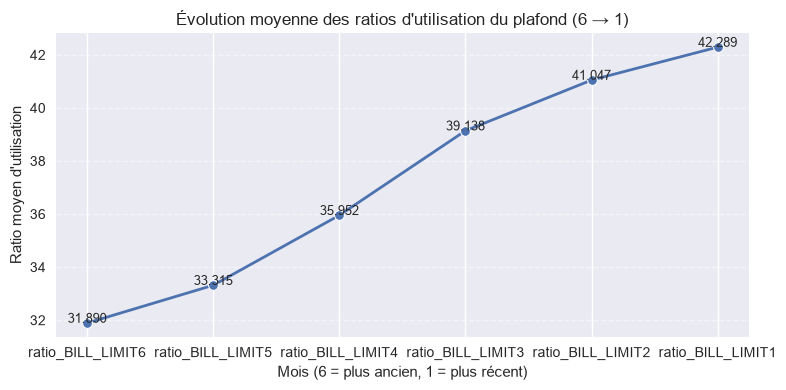

In [207]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Liste des colonnes dans l'ordre souhaité (6 -> 1)
colonnes = [
    'ratio_BILL_LIMIT6', 
    'ratio_BILL_LIMIT5', 
    'ratio_BILL_LIMIT4', 
    'ratio_BILL_LIMIT3', 
    'ratio_BILL_LIMIT2', 
    'ratio_BILL_LIMIT1'
]

# Filtrer pour ne garder que celles qui existent dans ton dataframe
colonnes_presentes = [c for c in colonnes if c in df.columns]

if colonnes_presentes:
    # 2. Calcul de la moyenne par colonne
    moyennes = df[colonnes_presentes].mean()

    # 3. Visualisation simple (courbe linéaire pour voir l'évolution)
    plt.figure(figsize=(8, 4))
    
    # On utilise les index (6,5,4...) pour l'axe X et les valeurs moyennes pour l'axe Y
    sns.lineplot(x=moyennes.index, y=moyennes.values, marker='o', linewidth=2)
    
    plt.title('Évolution moyenne des ratios d\'utilisation du plafond (6 → 1)')
    plt.xlabel('Mois (6 = plus ancien, 1 = plus récent)')
    plt.ylabel('Ratio moyen d\'utilisation')
    
    # Ajouter les valeurs sur les points pour plus de clarté
    for i, v in enumerate(moyennes.values):
        plt.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("Vérifie les noms des colonnes dans ton dataframe.")

**Interprétation**
Sur les 6 mois, le taux d'utilisation des cartes actives a bondi de 10 points en moyenne

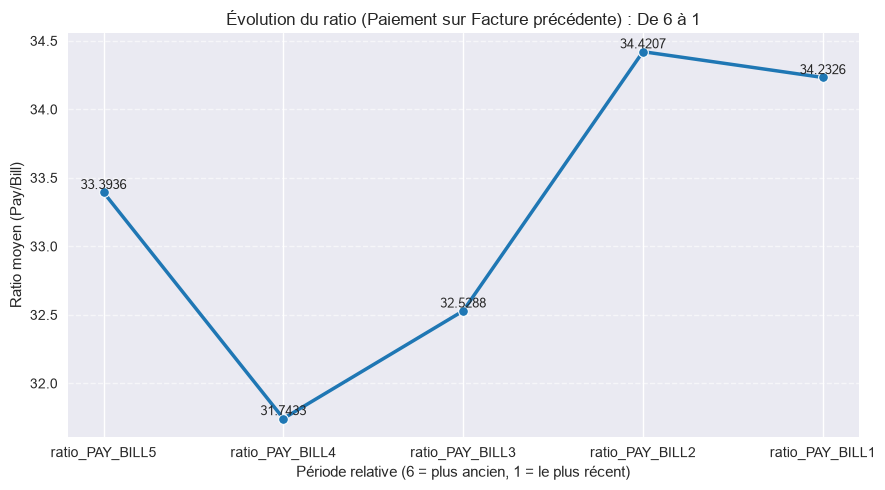

In [208]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Définition de l'ordre d'affichage souhaité (de 6 à 1)
# On construit la liste en partant du suffixe 6 jusqu'à 1
ordre_souhaite = [f'ratio_PAY_BILL{i}' for i in range(5, 0, -1)]

# Filtrer pour ne garder que les colonnes réellement présentes dans le dataframe
colonnes_actives = [col for col in ordre_souhaite if col in df.columns]

if len(colonnes_actives) > 0:
    # 2. Extraction des données et calcul de la moyenne par mois
    # On prend les colonnes dans l'ordre du graphique (6 -> 1)
    df_temp = ratios_affichables(df, colonnes_actives)
    
    # Calcul des moyennes
    moyennes = df_temp.mean()

    # 3. Visualisation
    plt.figure(figsize=(9, 5))
    
    # sns.lineplot prend les index (6,5,4...) comme axe X et les valeurs moyennes en Y
    sns.lineplot(
        x=moyennes.index, 
        y=moyennes.values, 
        marker='o', 
        linewidth=2.5,
        color='#1f77b4'  # Bleu standard pour la clarté
    )

    plt.title('Évolution du ratio (Paiement sur Facture précédente) : De 6 à 1')
    plt.xlabel('Période relative (6 = plus ancien, 1 = le plus récent)')
    plt.ylabel('Ratio moyen (Pay/Bill)')
    
    # Ajout des valeurs textuelles pour précision
    for i, val in enumerate(moyennes.values):
        plt.text(i, val + 0.005, f'{val:.4f}', ha='center', va='bottom', fontsize=9)

    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print(f"Attention : Aucune des colonnes de la liste '{ordre_souhaite}' n'a été trouvée.")

**Interprétation**  
pas de tendance  
Mais la moyenne est très affectée par des valeurs aberrantes, je regarde plutot la médiane pour cette valeur :

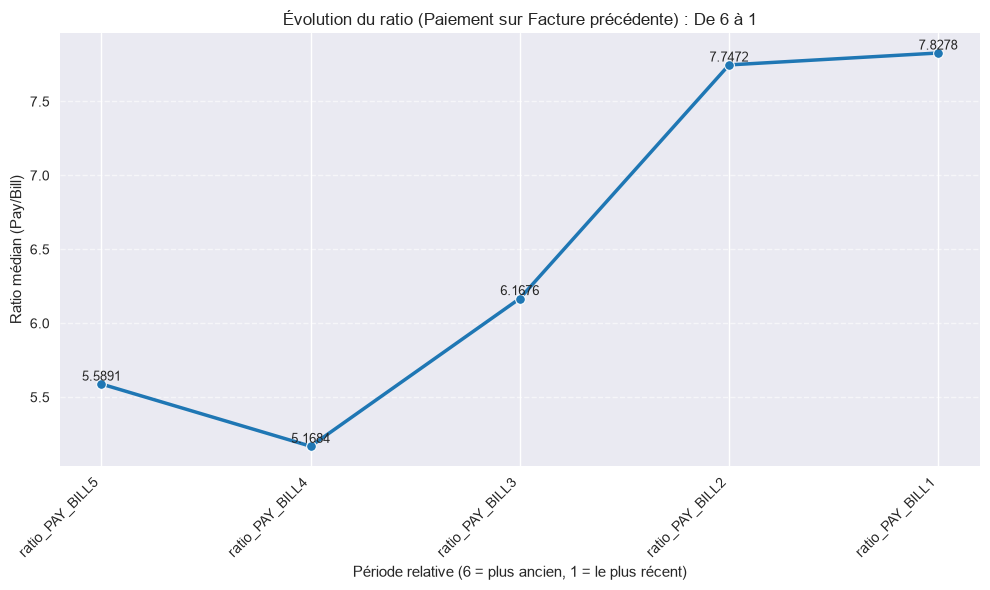

In [209]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Définition de l'ordre d'affichage souhaité (de 6 à 1)
ordre_souhaite = [f'ratio_PAY_BILL{i}' for i in range(5, 0, -1)]

# Filtrer pour ne garder que les colonnes réellement présentes dans le dataframe
colonnes_actives = [col for col in ordre_souhaite if col in df.columns]

if len(colonnes_actives) > 0:
    # 2. Extraction des données et calcul de la médiane par période
    df_temp = ratios_affichables(df, colonnes_actives)
    medianes = df_temp.median()

    # 3. Visualisation
    plt.figure(figsize=(10, 6))
    
    # Tracer la ligne avec les médianes
    sns.lineplot(
        x=medianes.index,
        y=medianes.values,
        marker='o',
        linewidth=2.5,
        color='#1f77b4'
    )

    plt.title('Évolution du ratio (Paiement sur Facture précédente) : De 6 à 1')
    plt.xlabel('Période relative (6 = plus ancien, 1 = le plus récent)')
    plt.ylabel('Ratio médian (Pay/Bill)')

    # Ajout des valeurs textuelles
    for i, val in enumerate(medianes.values):
        plt.text(i, val + 0.005, f'{val:.4f}', ha='center', va='bottom', fontsize=9)

    # Ajuster les ticks sur l'axe X pour améliorer la lisibilité
    plt.xticks(rotation=45, ha='right')

    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

else:
    print(f"Attention : Aucune des colonnes de la liste '{ordre_souhaite}' n'a été trouvée.")

**Interprétation**
Evolution en hausse sur les 3 derniers mois

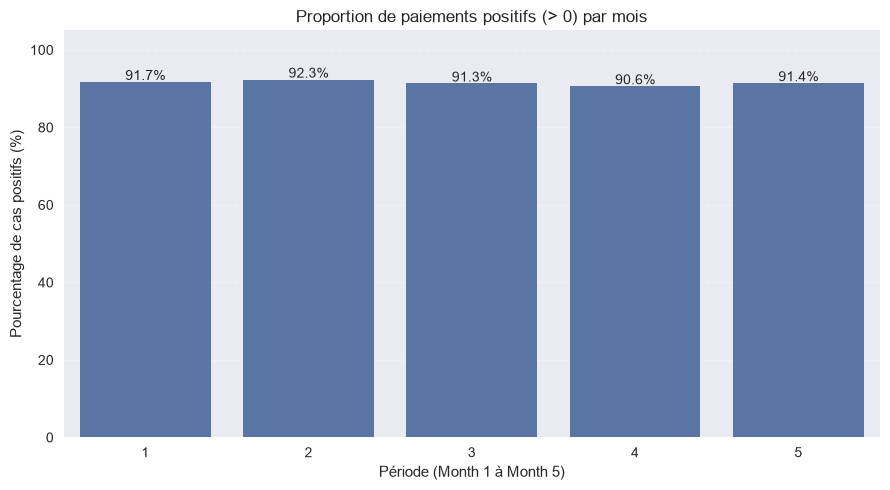

In [210]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Définition des colonnes dans l'ordre "1 vers 5" (comme demandé : Month 1 à Month 5)
# Note: Month 1 est le plus récent, Month 5 est le plus ancien de cet ensemble
colonnes = [
    'ratio_PAY_BILL1',  # Month 1
    'ratio_PAY_BILL2',  # Month 2
    'ratio_PAY_BILL3',  # Month 3
    'ratio_PAY_BILL4',  # Month 4
    'ratio_PAY_BILL5'   # Month 5
]

# Filtrer pour ne garder que les colonnes présentes
colonnes_actives = [c for c in colonnes if c in df.columns]

if len(colonnes_actives) >= 2:
    # 2. Calcul de la proportion de valeurs > 0 pour chaque colonne
    # .mean() sur un booléen (condition > 0) donne la fraction de True (positifs)
    proportions = ratios_affichables(df, colonnes_actives).apply(lambda x: (x.dropna() > 0).mean())

    # Normalisation en pourcentage pour l'affichage
    proportions_pct = proportions * 100

    # 3. Visualisation en histogramme (bar chart)
    plt.figure(figsize=(9, 5))
    
    sns.barplot(x=proportions_pct.index, y=proportions_pct.values)
    
    # Ajouter les valeurs sur les barres pour plus de clarté
    for i, val in enumerate(proportions_pct.values):
        plt.text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=10)

    plt.title('Proportion de paiements positifs (> 0) par mois')
    plt.xlabel('Période (Month 1 à Month 5)')
    plt.ylabel('Pourcentage de cas positifs (%)')
    
    # Personnalisation de l'axe X pour être très clair
    labels = [c.replace('ratio_PAY_BILL', '') for c in proportions_pct.index]
    plt.xticks(range(len(proportions_pct.index)), labels)

    plt.ylim(0, 105) # Petit marge au dessus
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Il manque des colonnes pour réaliser l'analyse.")

**Interprétation**  
La proportion de clients qui paient tout ou partie de leur échéance augmente.  
Il faut aussi y voir que 20% des échéances ne sont pas honorées dans les 30 jours !

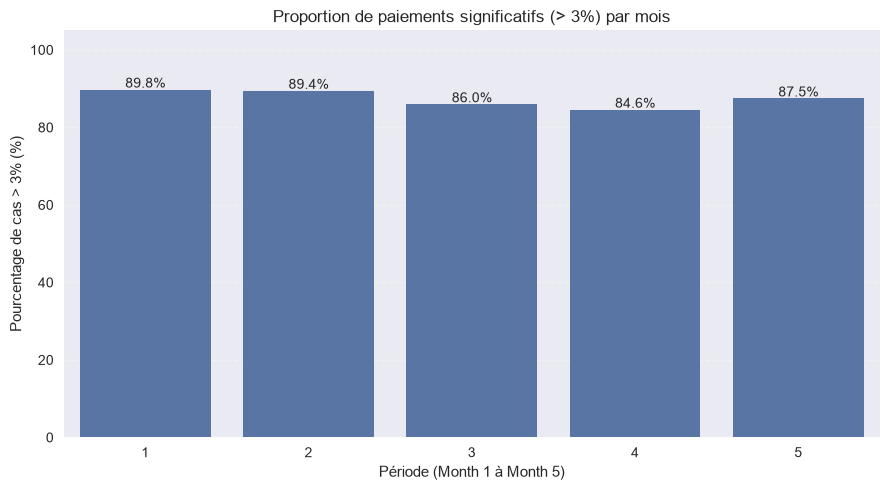

In [211]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Définition des colonnes (Month 1 à Month 5)
colonnes = [
    'ratio_PAY_BILL1',
    'ratio_PAY_BILL2',
    'ratio_PAY_BILL3',
    'ratio_PAY_BILL4',
    'ratio_PAY_BILL5'
]

# Filtrer pour ne garder que les colonnes présentes
colonnes_actives = [c for c in colonnes if c in df.columns]

if len(colonnes_actives) >= 2:
    # 2. Calcul de la proportion où le ratio est STRICTEMENT SUPÉRIEUR à 0.03 (3%)
    # On applique la condition > 0.03 colonne par colonne
    proportions = ratios_affichables(df, colonnes_actives).apply(lambda x: (x.dropna() > 3).mean())

    # En pourcentage
    proportions_pct = proportions * 100

    # 3. Visualisation en histogramme
    plt.figure(figsize=(9, 5))
    
    sns.barplot(x=proportions_pct.index, y=proportions_pct.values)
    
    # Ajout des valeurs sur les barres
    for i, val in enumerate(proportions_pct.values):
        plt.text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=10)

    plt.title('Proportion de paiements significatifs (> 3%) par mois')
    plt.xlabel('Période (Month 1 à Month 5)')
    plt.ylabel('Pourcentage de cas > 3% (%)')
    
    # Labels X clairs (1, 2, 3, 4, 5)
    labels = [c.replace('ratio_PAY_BILL', '') for c in proportions_pct.index]
    plt.xticks(range(len(proportions_pct.index)), labels)

    plt.ylim(0, 105) 
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Colonnes manquantes pour l'analyse.")

**Interprétation**  
Même tendance, mais on voit qu'une part des clients (2 à 5% selon les mois) paient partiellement leur échéance

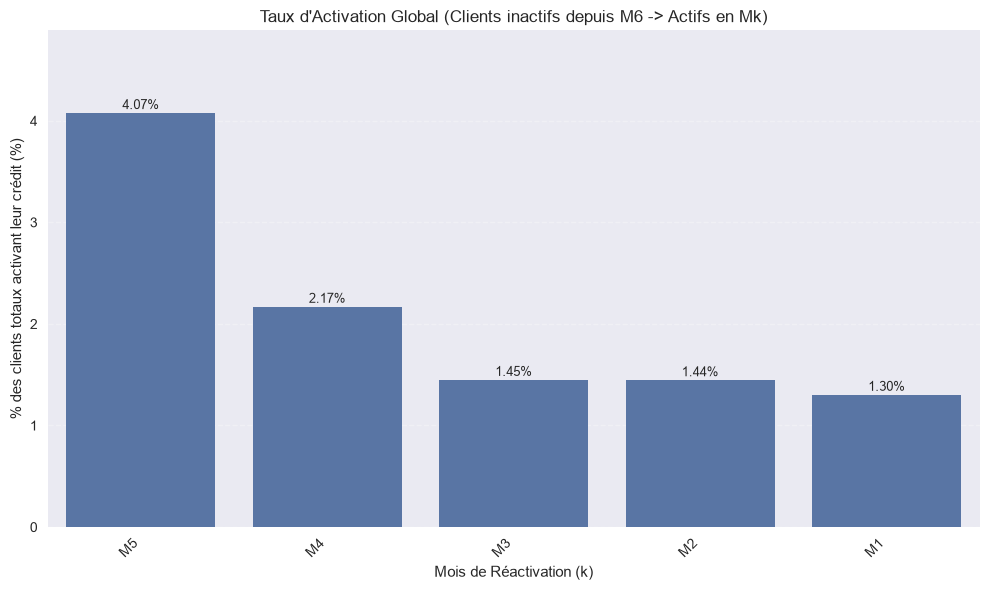

In [212]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Préparation des colonnes BILL_AMT
colonnes_bill = [f'BILL_AMT{i}' for i in range(6, 0, -1)]
cols_existantes = [c for c in colonnes_bill if c in df.columns]

if len(cols_existantes) < 2:
    print("Pas assez de colonnes BILL_AMT disponibles.")
else:
    taux_activation_globale = []
    labels_x = []
    n_total_clients = len(df)

    # On calcule pour chaque mois k (de 5 down to 1) la probabilité qu'un client :
    # 1. Ait BILL_AMT == 0 pour tous les mois de 6 à k+1 (inactivité prolongée)
    # 2. Aie BILL_AMT > 0 en mois k (réactivation)
    
    for k in range(5, 0, -1):
        col_activ = f'BILL_AMT{k}'
        
        if col_activ not in df.columns:
            taux_activation_globale.append(0)
            labels_x.append(f'M{k} (missing)')
            continue

        # Masque d'inactivité prolongée : 0 pour tous les mois [6, k+1]
        mask_inactif = pd.Series([True] * n_total_clients, index=df.index)
        
        for m in range(6, k, -1):
            col_m = f'BILL_AMT{m}'
            if col_m in df.columns:
                # On applique la condition stricte : solde nul
                mask_inactif &= (df[col_m] == 0)
        
        # Masque de réactivation : > 0 en mois k
        mask_reactivation = df[col_activ] > 0
        
        # Intersection : Les deux conditions doivent être vraies
        # Note: Si un client n'a pas de données pour l'un des mois (NaN), 
        # il ne sera pas compté comme "inactif avec certitude" ni "réactivé". 
        # C'est la méthode stricte.
        
        mask_total = mask_inactif & mask_reactivation
        
        # Calcul du taux par rapport à l'ENSEMBLE du dataset
        count_activation = mask_total.sum()
        taux_global = (count_activation / n_total_clients) * 100
        
        taux_activation_globale.append(taux_global)
        labels_x.append(f'M{k}')

    # 2. Visualisation
    plt.figure(figsize=(10, 6))
    
    sns.barplot(x=labels_x, y=taux_activation_globale)
    
    # Ajout des valeurs
    for i, val in enumerate(taux_activation_globale):
        if val > 0: # Afficher seulement si > 0 pour éviter le bruit
            plt.text(i, val + (max(taux_activation_globale)*0.01 if max(taux_activation_globale)>0 else 0.1), 
                     f'{val:.2f}%', ha='center', fontsize=9)

    plt.title('Taux d\'Activation Global (Clients inactifs depuis M6 -> Actifs en Mk)')
    plt.xlabel('Mois de Réactivation (k)')
    plt.ylabel('% des clients totaux activant leur crédit (%)')
    
    # Ajustement Y
    max_val = max(taux_activation_globale) if taux_activation_globale else 1
    plt.ylim(0, max_val * 1.2 if max_val > 0 else 5)
    
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

**Interprétation**
Le taux d'activation ou réactivation de comptes diminue fortement entre M-5 et M-3 pour atteindre un taux de 1.3% sur le mois le plus récent.  
Attention, la statistique de M-5 peut être augmentée par une non utilisation succinte en M-6.  
On peut aussi interpréter cette statistiques comme : moins de compte sortent de recouvrement/contentieux s'il s'agit ici de compte gelés pour défaut de paiement excessif

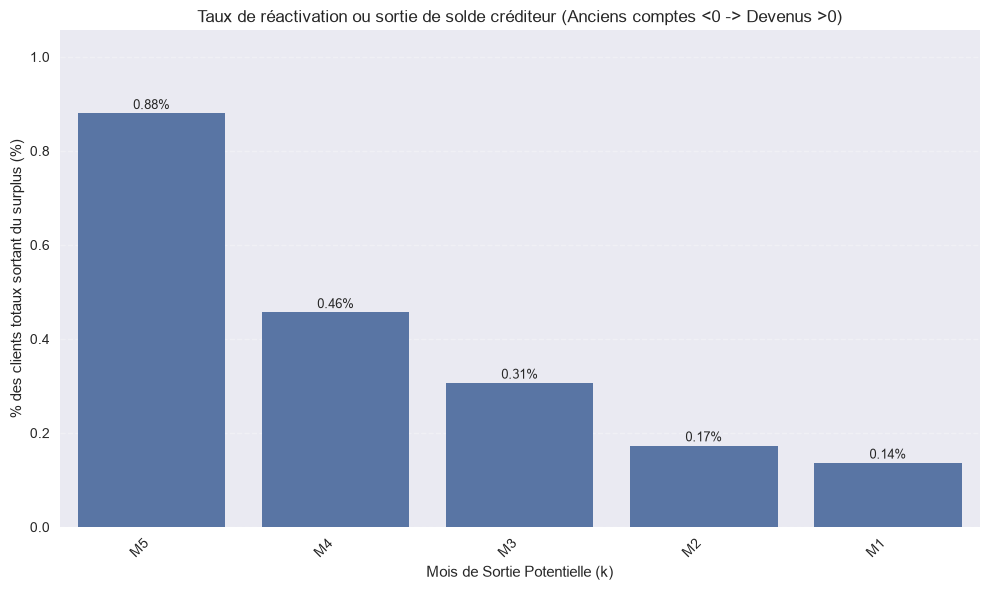

Taux de 'décongestion' calculé : passage de solde négatif vers positif.


In [213]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Préparation des colonnes BILL_AMT (6 à 1)
colonnes_bill = [f'BILL_AMT{i}' for i in range(6, 0, -1)]
cols_existantes = [c for c in colonnes_bill if c in df.columns]

if len(cols_existantes) < 2:
    print("Pas assez de colonnes BILL_AMT disponibles.")
else:
    taux_decongestion = []
    labels_x = []
    n_total_clients = len(df)

    # On cherche la sortie de l'état "< 0" vers "> 0"
    # Le "gel" ou surplus commence à M6.
    
    for k in range(5, 0, -1):
        col_sortie = f'BILL_AMT{k}'       # Mois où on espère un retour à > 0
        
        if col_sortie not in df.columns:
            taux_decongestion.append(0)
            labels_x.append(f'M{k} (missing)')
            continue

        # Masque d'inactivité en surplus : < 0 pour tous les mois [6, k+1]
        # Note: On traite les NaN comme "pas de donnée", donc on exclut ceux qui ont des trous.
        mask_surplus = pd.Series([True] * n_total_clients, index=df.index)
        
        for m in range(6, k, -1):
            col_m = f'BILL_AMT{m}'
            if col_m in df.columns:
                # Condition stricte : Solde négatif (débit versé > dette)
                mask_surplus &= (df[col_m] < 0)
        
        # Masque de sortie de surplus : > 0 en mois k
        mask_sortie = df[col_sortie] > 0
        
        # Intersection : Étaient tous en négatif ET sont maintenant en positif
        mask_total = mask_surplus & mask_sortie
        
        # Calcul du taux par rapport à l'ENSEMBLE du dataset
        count_decongeste = mask_total.sum()
        taux_global = (count_decongeste / n_total_clients) * 100
        
        taux_decongestion.append(taux_global)
        labels_x.append(f'M{k}')

    # 2. Visualisation
    plt.figure(figsize=(10, 6))
    
    # Palette différente pour marquer le contraste (ex: rouge/orange pour le "décongé")
    sns.barplot(x=labels_x, y=taux_decongestion)
    
    # Ajout des valeurs
    for i, val in enumerate(taux_decongestion):
        if val > 0:
            plt.text(i, val + (max(taux_decongestion)*0.01 if max(taux_decongestion)>0 else 0.1), 
                     f'{val:.2f}%', ha='center', fontsize=9)

    plt.title('Taux de réactivation ou sortie de solde créditeur (Anciens comptes <0 -> Devenus >0)')
    plt.xlabel('Mois de Sortie Potentielle (k)')
    plt.ylabel('% des clients totaux sortant du surplus (%)')
    
    # Ajustement Y
    max_val = max(taux_decongestion) if taux_decongestion else 1
    plt.ylim(0, max_val * 1.2 if max_val > 0 else 5)
    
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

print("Taux de 'décongestion' calculé : passage de solde négatif vers positif.")

**Interpétation**  
Ici aussi 2 inteprétations possibles selon que le compte est réellement en état de surpaiement du client ou géré dans une autre phase.  
Taux globalement très faible mais on remarque que comme pour les comptes à 0, le taux de sortie des comptes en négatifs diminue fortement entre M-5 et M-3.  
2 possibilités face aux 2 précédents constats :
- la banque régularise moins de comptes, les clients ont moins la possibilités de régulariser un défaut important à mesure que les banques restreignent l'accès au crédit
- la banque autorise moins d'ouvertures de comptes à mesure que les défaillances se font sentir

In [214]:
import pandas as pd
import numpy as np

# 1. Définition des colonnes BILL_AMT de 1 à 6
cols_bill = [f'BILL_AMT{i}' for i in range(1, 7)]
cols_presentes = [c for c in cols_bill if c in df.columns]

if len(cols_presentes) == 6:
    # On prend uniquement les colonnes d'intérêt pour le calcul
    df_bill = df[cols_presentes]
    
    # 2. Identification des lignes où BILL_AMT est constant sur les 6 mois
    # Si l'écart-type (std) est nul, toutes les valeurs sont identiques.
    std_per_row = df_bill.std(axis=1)
    mask_constant = std_per_row == 0
    
    nb_total_constantes = mask_constant.sum()
    
    if nb_total_constantes > 0:
        # On extrait ces lignes spécifiques pour analyse
        df_constants = df.loc[mask_constant].copy()
        
        # Puisque std=0, la valeur est identique sur les 6 mois.
        # On peut se baser sur n'importe quelle colonne (ex: BILL_AMT1) pour classer la ligne.
        val_constante = df_constants['BILL_AMT1']
        
        # Catégorisation
        mask_negatif = val_constante < 0
        mask_nul = val_constante == 0
        mask_positif = val_constante > 0
        
        nb_negatif = mask_negatif.sum()
        nb_nul = mask_nul.sum()
        nb_positif = mask_positif.sum()
        
        # Vérification de la cohérence (somme des parties = tout)
        if nb_negatif + nb_nul + nb_positif == nb_total_constantes:
            print("--- Analyse des Soldes BILL_AMT Constants sur 6 Mois ---")
            print(f"Total lignes avec BILL_AMT constant : {nb_total_constantes}")
            print(f"  - Strictement Nuls (== 0) : {nb_nul} ({(nb_nul/nb_total_constantes)*100:.2f}%)")
            print(f"  - Positifs (> 0) : {nb_positif} ({(nb_positif/nb_total_constantes)*100:.2f}%)")
            print(f"  - Négatifs (< 0) : {nb_negatif} ({(nb_negatif/nb_total_constantes)*100:.2f}%)")
            
        else:
            print("Erreur de cohérence dans le comptage.")

else:
    print(f"Impossible : Seules {len(cols_presentes)} colonnes BILL_AMT sur 6 sont présentes.")

--- Analyse des Soldes BILL_AMT Constants sur 6 Mois ---
Total lignes avec BILL_AMT constant : 1227
  - Strictement Nuls (== 0) : 866 (70.58%)
  - Positifs (> 0) : 298 (24.29%)
  - Négatifs (< 0) : 63 (5.13%)


In [215]:
import pandas as pd

cols_bill = [f'BILL_AMT{i}' for i in range(1, 7)]
cols_pay = [f'PAY_AMT{i}' for i in range(1, 7)]

# 1. Condition : tous les PAY_AMTn sont égaux à 0 sur les 6 mois
mask_pay_zero = (df[cols_pay] == 0).all(axis=1)

# 2. Condition : BILL_AMTn est strictement constant sur les 6 mois
mask_bill_const = df[cols_bill].std(axis=1) == 0

# 3. Intersection des deux règles
mask_target = mask_bill_const & mask_pay_zero
df_filtered = df[mask_target]

# 4. Ventilation selon la valeur du solde constant (BILL_AMT1 sert de référence)
val_bill = df_filtered['BILL_AMT1']

nb_positif = (val_bill > 0).sum()
nb_nul = (val_bill == 0).sum()
nb_negatif = (val_bill < 0).sum()
total = len(df_filtered)

print("--- DÉCOMPTE : BILL_AMT constant ET PAY_AMT == 0 sur 6 mois ---")
print(f"Total clients concernés : {total}")
if total > 0:
    print(f"  • Facture constante > 0 : {nb_positif} ({nb_positif / total * 100:.2f} %)")
    print(f"  • Facture constante == 0 : {nb_nul} ({nb_nul / total * 100:.2f} %)")
    print(f"  • Facture constante < 0 : {nb_negatif} ({nb_negatif / total * 100:.2f} %)")

--- DÉCOMPTE : BILL_AMT constant ET PAY_AMT == 0 sur 6 mois ---
Total clients concernés : 954
  • Facture constante > 0 : 111 (11.64 %)
  • Facture constante == 0 : 795 (83.33 %)
  • Facture constante < 0 : 48 (5.03 %)


795 clients sont clairement dormants au sens bancaire du terme : aucune opération créditrice ou débitrice sur les 6 mois. Ou selon le SI et ses artéfacts, ils peuvent être en gestion contentieuse.  
**=> Au pire, on les supprime du jeu de données pour ne s'intéresser qu'aux clients actifs en gestion normale, au mieux on masque ces lignes lors des graphiques et de l'apprentissage automatique.**
Il faut creuser sur les autres catégories

In [216]:
import pandas as pd
import numpy as np

# 1. Colonnes concernées
cols_bill = [f'BILL_AMT{i}' for i in range(1, 7)]
cols_pay = [f'PAY_AMT{i}' for i in range(1, 7)]
cols_presentes = [c for c in cols_bill + cols_pay if c in df.columns]

if len(cols_presentes) == 12:
    # Condition globale : TOUT est constant (BILL et PAY) ET PAY est partout à 0
    mask_constant_pay_zero = (df[cols_pay].apply(lambda x: (x == 0).all(), axis=1)) & \
                             (df[cols_bill].std(axis=1) == 0)
    
    df_cibles = df[mask_constant_pay_zero]
    
    if len(df_cibles) > 0:
        # On utilise BILL_AMT1 pour classifier
        val_bill = df_cibles['BILL_AMT1']
        
        # --- CAS 1 : NÉGATIF (< 0) ---
        mask_negatif = val_bill < 0
        if mask_negatif.any():
            print("--- Aperçu : BILL Constant Négatif & PAY Toujours 0 (Top 10) ---")
            display_neg = df_cibles.loc[mask_negatif].head(10)
            # Affichage des colonnes clés + les 6 BILL + les 6 PAY pour voir la constance
            cols_affichage = ['LIMIT_BAL'] + [c for c in df.columns if 'PAY' in c or 'BILL' in c]
            cols_affichage = [c for c in cols_affichage if c in display_neg.columns]
            print(display_neg[cols_affichage].to_string())
            
        # --- CAS 2 : POSITIF (> 0) ---
        mask_positif = val_bill > 0
        if mask_positif.any():
            print("\n--- Aperçu : BILL Constant Positif & PAY Toujours 0 (Top 10) ---")
            display_pos = df_cibles.loc[mask_positif].head(10)
            cols_affichage = ['LIMIT_BAL'] + [c for c in df.columns if 'PAY' in c or 'BILL' in c]
            cols_affichage = [c for c in cols_affichage if c in display_pos.columns]
            print(display_pos[cols_affichage].to_string())

    else:
        print("Aucune ligne avec PAY=0 et BILL constant trouvé.")
else:
    print("Colonnes manquantes.")

--- Aperçu : BILL Constant Négatif & PAY Toujours 0 (Top 10) ---
      LIMIT_BAL  PAY_1  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  ratio_brut_PAY_BILL1  ratio_brut_PAY_BILL2  ratio_brut_PAY_BILL3  ratio_brut_PAY_BILL4  ratio_brut_PAY_BILL5  ratio_PAY_BILL1  ratio_PAY_BILL2  ratio_PAY_BILL3  ratio_PAY_BILL4  ratio_PAY_BILL5  ratio_PAY_to_BILL_median  ratio_BILL_LIMIT1  ratio_BILL_LIMIT2  ratio_BILL_LIMIT3  ratio_BILL_LIMIT4  ratio_BILL_LIMIT5  ratio_BILL_LIMIT6
ID                                                                                                                                                                                                                                                                                                                                                                                                                              

Les 2 cas de figure sont très intéressants.  
1. Dans le cas des encours négatifs constants sans paiement, le compte est considéré comme sain et inactif (codification -2). Pas de dette au sens métier du terme envers la banque. Ces lignes sont clairement des clients inactifs sans dette ou une anomalie du SI.  
**=> je classe des clients en inactifs qu'il faut retirer des analyses et apprentissages automatiques**  
2. Dans le cas des non payeurs avec dette constante, leur retard semble figé dans les colonnes PAY_n.  
J'ai besoin d'analyser plus en détail la population des non payeurs pour voir si cette confirguration spécifique est isolée, cohérente, standard

In [217]:
import pandas as pd
import numpy as np

# 1. Définition des colonnes
cols_pay = [f'PAY_AMT{i}' for i in range(1, 7)]
cols_bill = [f'BILL_AMT{i}' for i in range(1, 7)]
cols_presentes_pay = [c for c in cols_pay if c in df.columns]
cols_presentes_bill = [c for c in cols_bill if c in df.columns]

if len(cols_presentes_pay) == 6 and len(cols_presentes_bill) == 6:
    # --- Étape 1 : Identifier les non-payeurs sur 6 mois (PAY=0 partout) ---
    mask_no_payment = df[cols_presentes_pay].apply(lambda x: (x == 0).all(), axis=1)
    
    nb_non_payeurs = mask_no_payment.sum()
    
    if nb_non_payeurs > 0:
        # On isole les lignes concernées
        df_non_payeurs = df[mask_no_payment].copy()
        
        # --- Étape 2 : Analyser la stabilité de BILL_AMT ---
        std_bill = df_non_payeurs[cols_presentes_bill].std(axis=1)
        
        mask_stable = std_bill == 0
        mask_instable = std_bill != 0
        
        # --- Étape 3 : Appliquer la condition STRICTE sur la stabilité (BILL > 0) ---
        # Pour les stables : on veut que BILL soit > 0
        # On vérifie si toutes les valeurs de BILL sont > 0 pour ces lignes stables
        mask_stable_positif = False
        if mask_stable.any():
            # On prend les sous-ensemble stable et on teste (>0) partout
            df_stable_part = df_non_payeurs.loc[mask_stable]
            # Si une ligne a au moins un BILL <= 0, elle n'est pas "strictement positive"
            # Donc on garde uniquement celles où TOUTES les colonnes BILL > 0
            mask_stable_positif = (df_stable_part[cols_presentes_bill] > 0).all(axis=1)
            
        # --- Comptage et Affichage ---
        nb_stable_total = mask_stable.sum()
        nb_stable_positif = mask_stable_positif.sum() if mask_stable.any() else 0
        
        # Pour les instables, on garde tout ce qui est stable != 0 (comme avant)
        nb_instable = mask_instable.sum()

        print("--- Analyse des clients sans paiement (PAY=0) ---")
        print(f"Total non-payeurs : {nb_non_payeurs}")
        print(f"  - Dette STABLE ET STRICTEMENT POSITIVE (>0) : {nb_stable_positif} ({(nb_stable_positif/nb_non_payeurs)*100:.2f}%)")
        print(f"  - Dette INSTABLE (variable) : {nb_instable} ({(nb_instable/nb_non_payeurs)*100:.2f}%)")
        
        # Optionnel : Affichage des instables (comme demandé précédemment)
        if nb_instable > 0:
            print(f"\n--- Aperçu des cas INSTABLES (10 lignes) ---")
            df_instables = df.loc[mask_no_payment & mask_instable].head(10)
            cols_affichage = [c for c in df_instables.columns if 'BILL' in c or 'PAY' in c]
            print(df_instables[cols_affichage].to_string())

else:
    print("Colonnes manquantes.")

--- Analyse des clients sans paiement (PAY=0) ---
Total non-payeurs : 1432
  - Dette STABLE ET STRICTEMENT POSITIVE (>0) : 111 (7.75%)
  - Dette INSTABLE (variable) : 478 (33.38%)

--- Aperçu des cas INSTABLES (10 lignes) ---
     PAY_1  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  ratio_brut_PAY_BILL1  ratio_brut_PAY_BILL2  ratio_brut_PAY_BILL3  ratio_brut_PAY_BILL4  ratio_brut_PAY_BILL5  ratio_PAY_BILL1  ratio_PAY_BILL2  ratio_PAY_BILL3  ratio_PAY_BILL4  ratio_PAY_BILL5  ratio_PAY_to_BILL_median  ratio_BILL_LIMIT1  ratio_BILL_LIMIT2  ratio_BILL_LIMIT3  ratio_BILL_LIMIT4  ratio_BILL_LIMIT5  ratio_BILL_LIMIT6
ID                                                                                                                                                                                                                                                                         

On a des encours négatifs qui varient : ces cas seront exclus des prédictions de facto, mais ce sont des clients actifs à maintenir dans les analyses et l'apprentissage.  
On a de nombreux clients inactifs jusque M-2 qui deviennent actifs en M-1. Ce sont des clients sans historique de paiement, nous n'avons donc aucun historique du comportement
**=> pour le ML, on pourra tester la création d'une feature 'client_récent'**  
Ce ne sont pas ici des clients non payeurs contrairement à ceux dont on a vus la dette figée et existante sur les 6 mois.  
Nous avons environ 390 nouveaux clients actifs sur le dernier mois, ils représentent donc la majorité des clients sans paiement avec un encours qui évolue.  

J'ai besoin de voir de vrais clients en incidents sur la période pour comparer avec ceux dont la dette est figée

In [218]:
import pandas as pd
import numpy as np

# 1. Définition des colonnes
cols_pay = [f'PAY_AMT{i}' for i in range(1, 7)]
cols_bill = [f'BILL_AMT{i}' for i in range(1, 7)]
cols_presentes_pay = [c for c in cols_pay if c in df.columns]
cols_presentes_bill = [c for c in cols_bill if c in df.columns]

if len(cols_presentes_pay) == 6 and len(cols_presentes_bill) == 6:
    # --- Étape 1 : Identifier les non-payeurs sur 6 mois (PAY=0 partout) ---
    mask_no_payment = df[cols_presentes_pay].apply(lambda x: (x == 0).all(), axis=1)
    
    if mask_no_payment.any():
        df_non_payeurs = df[mask_no_payment].copy()
        
        # --- Étape 2 : Filtrer les dettes positives sur AU MOINS 2 mois ---
        # On compte combien de mois ont une dette > 0 pour chaque client
        nb_mois_dettes_positives = (df_non_payeurs[cols_presentes_bill] > 0).sum(axis=1)
        
        # Condition : Au moins 2 mois avec dettes positives
        mask_dette_partielle = nb_mois_dettes_positives >= 2
        
        if mask_dette_partielle.any():
            df_cibles = df.loc[mask_no_payment & mask_dette_partielle].copy()
            
            # Statistiques sur les mois de dette positive
            print("--- Analyse : Sans paiement, mais dette > 0 sur ≥ 2 mois ---")
            print(f"Total non-payeurs ayant une dette > 0 sur au moins 2 mois : {len(df_cibles)}")
            
            # Distribution du nombre de mois avec dette positive
            mois_dist = nb_mois_dettes_positives.loc[mask_dette_partielle].value_counts().sort_index()
            print("\nRépartition du nombre de mois avec dette > 0 :")
            for mois, count in mois_dist.items():
                print(f"  - {mois} mois : {count} clients ({(count/len(df_cibles))*100:.1f}%)")

            # --- Visualisation des 10 premiers cas (Top par nombre de mois de dette) ---
            print(f"\n--- Exemples de ces profils (Top 10) ---")
            
            # Tri pour voir ceux qui ont le plus de dettes en premier
            df_cibles_sorted = df_cibles.loc[mask_dette_partielle & nb_mois_dettes_positives.sort_values(ascending=False).index] if len(df_cibles) > 0 else pd.DataFrame()

            if not df_cibles.empty:
                # On affiche les colonnes clés pour voir l'évolution de la dette sans paiement
                cols_affichage = [c for c in df_cibles_sorted.columns if 'BILL' in c or 'PAY' in c]
                print(df_cibles_sorted.head(10)[cols_affichage].to_string())

        else:
            print("Aucun non-payeur avec une dette > 0 sur au moins 2 mois.")

else:
    print("Colonnes manquantes.")

--- Analyse : Sans paiement, mais dette > 0 sur ≥ 2 mois ---
Total non-payeurs ayant une dette > 0 sur au moins 2 mois : 206

Répartition du nombre de mois avec dette > 0 :
  - 2 mois : 43 clients (20.9%)
  - 3 mois : 4 clients (1.9%)
  - 4 mois : 3 clients (1.5%)
  - 5 mois : 5 clients (2.4%)
  - 6 mois : 151 clients (73.3%)

--- Exemples de ces profils (Top 10) ---
      PAY_1  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  ratio_brut_PAY_BILL1  ratio_brut_PAY_BILL2  ratio_brut_PAY_BILL3  ratio_brut_PAY_BILL4  ratio_brut_PAY_BILL5  ratio_PAY_BILL1  ratio_PAY_BILL2  ratio_PAY_BILL3  ratio_PAY_BILL4  ratio_PAY_BILL5  ratio_PAY_to_BILL_median  ratio_BILL_LIMIT1  ratio_BILL_LIMIT2  ratio_BILL_LIMIT3  ratio_BILL_LIMIT4  ratio_BILL_LIMIT5  ratio_BILL_LIMIT6
ID                                                                                                                        

Chez les non-payeurs à dette constante, deux comportements de retard : un retard qui monte d'un cran par mois sans paiement, ou un retard figé à 2 (voir la partie « Les retards sur les six mois » ; étude dans 05_02).
Volontairement, je n'affiche plus le dpnm pour ne pas être moi-meme influencé dans mes stratégies.  
On pourrait mettre en place un filtre complexe pour sortir ces clients présumés en recouvrement, mais je n'ai qu'une intuition de par mon expérience bancaire et l'analyse fine de certaines lignes pour lesquelles on détecte 2 comportements d'évolution d'encours de PAY_n. Pas de preuve scientifique, pas de preuve statistique, pas d'info sur la nomenclature du dataset donc cela sera compliqué de nettoyer.
Par contre, je peux prendre en compte cette intuition dans la classification que je peux donner à PAY_n = 2

**Répartition des plafonds**

Nombre de clients par tranche de plafond :
        0 à 50 k : 7676
      50 à 100 k : 4822
     100 à 150 k : 3902
     150 à 200 k : 3978
     200 à 250 k : 2905
     250 à 300 k : 2154
     300 à 350 k : 1206
     350 à 400 k : 1553
     400 à 450 k : 573
     450 à 500 k : 1025
     500 à 550 k : 76
     550 à 600 k : 51
     600 à 650 k : 37
     650 à 700 k : 19
     700 à 750 k : 17
     750 à 800 k : 5
     800 à 850 k : 0
     850 à 900 k : 0
     900 à 950 k : 0
    950 à 1000 k : 1

Clients avec un plafond de 500 000 NT$ pile : 722
Clients avec un plafond > 500 000 NT$ : 206 sur 30000 (0.69 %)
Plafond médian de l'ensemble des clients : 140,000 NT$
Plafond médian des clients > 500 000 NT$ : 580,000 NT$
Plafond maximum : 1,000,000 NT$ (1 client(s))


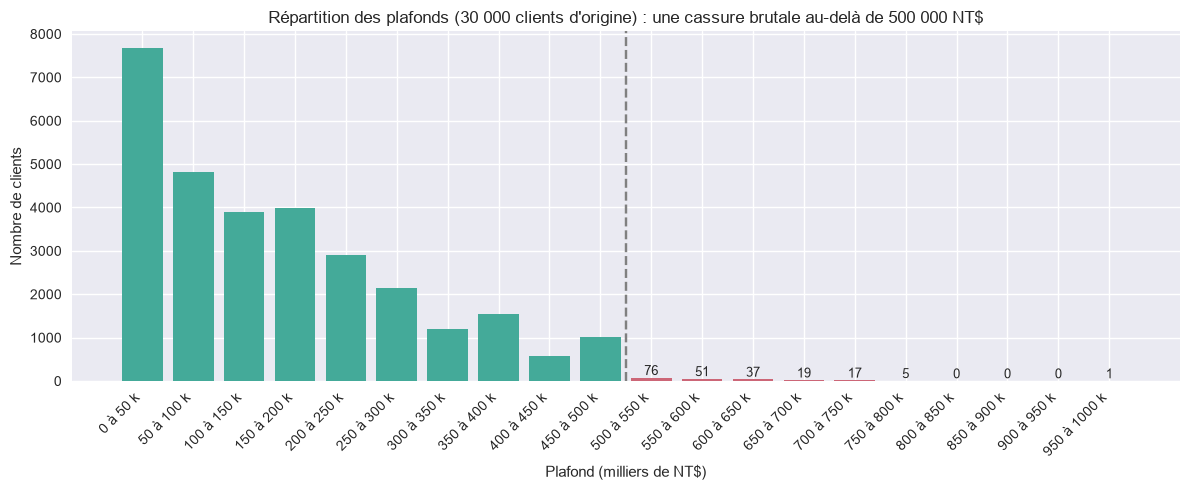

In [219]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Répartition des plafonds sur les 30 000 clients d'origine (df_initial, avant retrait des 4 paiements géants)
# Tranches de 50 000 NT$, borne haute incluse : la tranche « 450 à 500 k » contient les plafonds de 500 000 NT$
bornes = np.arange(0, 1_050_000, 50_000)
tranches = pd.cut(df_initial['LIMIT_BAL'], bins=bornes)
repartition = tranches.value_counts().sort_index()
libelles = [f"{int(i.left) // 1000} à {int(i.right) // 1000} k" for i in repartition.index]

print("Nombre de clients par tranche de plafond :")
for libelle, n in zip(libelles, repartition.values):
    print(f"  {libelle:>14} : {n}")

seuil = 500_000
au_dela = df_initial['LIMIT_BAL'] > seuil
print(f"\nClients avec un plafond de 500 000 NT$ pile : {(df_initial['LIMIT_BAL'] == seuil).sum()}")
print(f"Clients avec un plafond > 500 000 NT$ : {au_dela.sum()} sur {len(df_initial)} ({au_dela.mean() * 100:.2f} %)")
print(f"Plafond médian de l'ensemble des clients : {df_initial['LIMIT_BAL'].median():,.0f} NT$")
print(f"Plafond médian des clients > 500 000 NT$ : {df_initial.loc[au_dela, 'LIMIT_BAL'].median():,.0f} NT$")
print(f"Plafond maximum : {df_initial['LIMIT_BAL'].max():,.0f} NT$ ({(df_initial['LIMIT_BAL'] == df_initial['LIMIT_BAL'].max()).sum()} client(s))")

couleurs = ['#44AA99' if i.right <= seuil else '#CC6677' for i in repartition.index]
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(libelles, repartition.values, color=couleurs)
for x, n, i in zip(libelles, repartition.values, repartition.index):
    if i.right > seuil:
        ax.text(x, n, str(n), ha='center', va='bottom', fontsize=9)
ax.axvline(9.5, linestyle='--', color='grey')
ax.set_title("Répartition des plafonds (30 000 clients d'origine) : une cassure brutale au-delà de 500 000 NT$")
ax.set_xlabel("Plafond (milliers de NT$)")
ax.set_ylabel("Nombre de clients")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [220]:
# Usage maximal du plafond sur les 6 mois : facture la plus élevée (BILL_AMT1 à BILL_AMT6) / plafond, en %
bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]
usage_max = df_initial[bill_cols].max(axis=1) / df_initial['LIMIT_BAL'] * 100
groupe = np.where(df_initial['LIMIT_BAL'] > 500_000, "Plafond > 500 000 NT$", "Plafond <= 500 000 NT$")

synthese = pd.DataFrame({'usage_max': usage_max, 'groupe': groupe}).groupby('groupe')['usage_max'].agg(
    clients='size',
    usage_max_median=lambda s: round(s.median(), 1),
    jamais_plus_de_10_pct=lambda s: round((s < 10).mean() * 100, 1),
    au_moins_50_pct=lambda s: round((s >= 50).mean() * 100, 1),
)
print("Usage maximal du plafond sur les 6 mois (en %) :")
display(synthese)


Usage maximal du plafond sur les 6 mois (en %) :


,clients,usage_max_median,jamais_plus_de_10_pct,au_moins_50_pct
groupe,,,,
Plafond <= 500 000 NT$,29794,43.3,28.9,46.7
Plafond > 500 000 NT$,206,21.1,35.9,30.1


## Le ratio médian et les types d'usage

Travail sur la définition d'un ratio médian de paiement sur facture pour un client en évitant les factures à 0 et les ratios calculés sur une moyenne si 2 valeurs sont à égalité

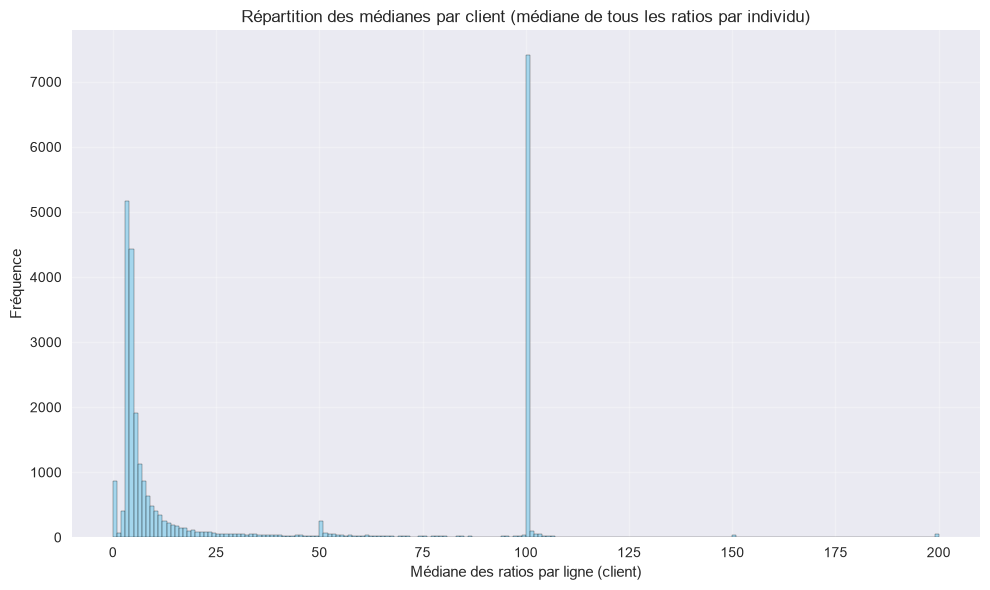

Statistiques de la répartition des moyennes par client :
Nombre total de clients : 28590
Moyenne globale des moyennes : 36.1739
Médiane : 7.3601
Écart-type : 43.1257
Minimum : 0.0000
Maximum : 200.0000


In [221]:
# version standard comprenant des valeurs à 50% non désirées

import matplotlib.pyplot as plt

# Définir les colonnes des ratios
ratio_columns = [
    'ratio_PAY_BILL1',
    'ratio_PAY_BILL2', 
    'ratio_PAY_BILL3', 
    'ratio_PAY_BILL4', 
    'ratio_PAY_BILL5'
]

# Calculer la médiane de chaque ligne (médiane des ratios pour chaque client)
# Colonne créée : définition unique (docs/colonnes_creees.md)
df['ratio_PAY_to_BILL_median'] = df[ratio_columns].median(axis=1)
# Graphique : médiane des seuls mois avec une facture exigible
row_medians = ratios_affichables(df, ratio_columns).median(axis=1).dropna()

# Enregistrer la médiane dans une nouvelle colonne du DataFrame

# Créer l'histogramme
plt.figure(figsize=(10, 6))
plt.hist(row_medians, bins=200, color='skyblue', edgecolor='black', alpha=0.7)

# Ajouter les étiquettes et le titre
plt.xlabel('Médiane des ratios par ligne (client)')
plt.ylabel('Fréquence')
plt.title('Répartition des médianes par client (médiane de tous les ratios par individu)')
plt.grid(True, alpha=0.3)

# Afficher le graphique
plt.tight_layout()
plt.show()

# Afficher quelques statistiques descriptives
print("Statistiques de la répartition des moyennes par client :")
print(f"Nombre total de clients : {len(row_medians)}")
print(f"Moyenne globale des moyennes : {row_medians.mean():.4f}")
print(f"Médiane : {row_medians.median():.4f}")
print(f"Écart-type : {row_medians.std():.4f}")
print(f"Minimum : {row_medians.min():.4f}")
print(f"Maximum : {row_medians.max():.4f}")

meme graphe avec la définition suivante initiale de ratio PAY to BILL median : médiane de tous les raio PAY BILLn (100% si pas de facture éexigible le mois précédent)

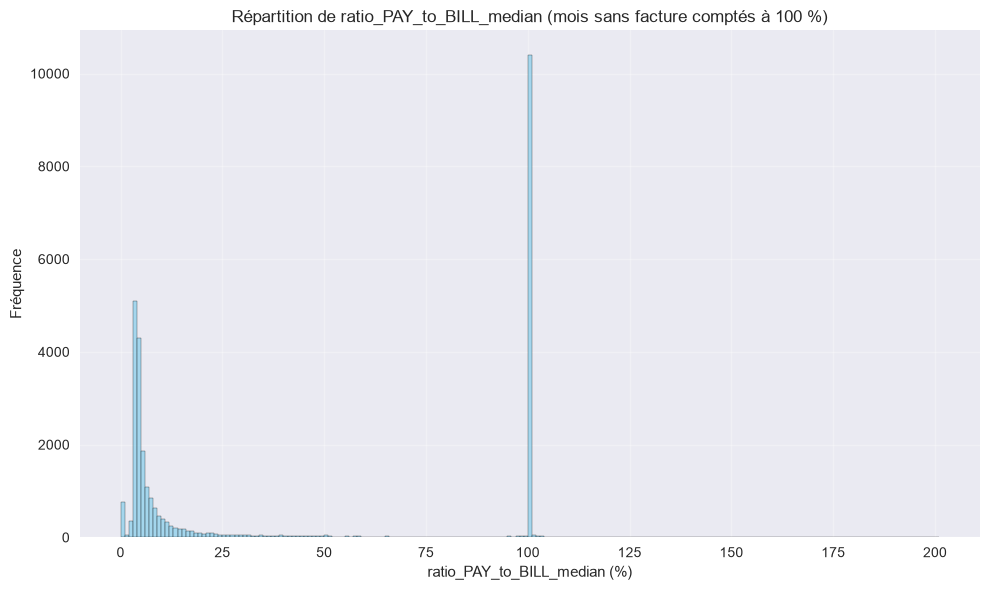

Statistiques de ratio_PAY_to_BILL_median :
Nombre total de clients : 29996
Moyenne : 41.7763
Médiane : 9.0447
Écart-type : 44.8944
Minimum : 0.0000
Maximum : 200.0000
Clients à 50 % pile : 18
Clients à 100 % pile : 9062


In [222]:
# version colonnes_creees.md : médiane des 5 ratios, mois sans facture exigible comptés à 100 %

import matplotlib.pyplot as plt

ratio_columns = [
    'ratio_PAY_BILL1',
    'ratio_PAY_BILL2',
    'ratio_PAY_BILL3',
    'ratio_PAY_BILL4',
    'ratio_PAY_BILL5'
]

# Colonne créée : définition unique (docs/colonnes_creees.md), valeurs à 100 comprises
df['ratio_PAY_to_BILL_median'] = df[ratio_columns].median(axis=1)
medianes_colonne = df['ratio_PAY_to_BILL_median'].dropna()

# Histogramme au grain de 1 %
plt.figure(figsize=(10, 6))
plt.hist(medianes_colonne, bins=range(0, 202, 1), color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('ratio_PAY_to_BILL_median (%)')
plt.ylabel('Fréquence')
plt.title('Répartition de ratio_PAY_to_BILL_median (mois sans facture comptés à 100 %)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Statistiques descriptives
print("Statistiques de ratio_PAY_to_BILL_median :")
print(f"Nombre total de clients : {len(medianes_colonne)}")
print(f"Moyenne : {medianes_colonne.mean():.4f}")
print(f"Médiane : {medianes_colonne.median():.4f}")
print(f"Écart-type : {medianes_colonne.std():.4f}")
print(f"Minimum : {medianes_colonne.min():.4f}")
print(f"Maximum : {medianes_colonne.max():.4f}")
print(f"Clients à 50 % pile : {(medianes_colonne == 50).sum()}")
print(f"Clients à 100 % pile : {(medianes_colonne == 100).sum()}")


moins de 50%, mais des comptes inactifs ou récents qui ressortent à 100%

Devenir des paiements :
          facture propre  retard (n+2)  avance (n)  trop-perçu
PAY_AMT1           24603            71           0          73
PAY_AMT2           24439            78          48          35
PAY_AMT3           23857            87          52          32
PAY_AMT4           23410            78          53          47
PAY_AMT5           23116             0         110          67

Contrôle : paiements 784,127,938 = affectés 783,009,664 + trop-perçus 1,118,274 -> OK


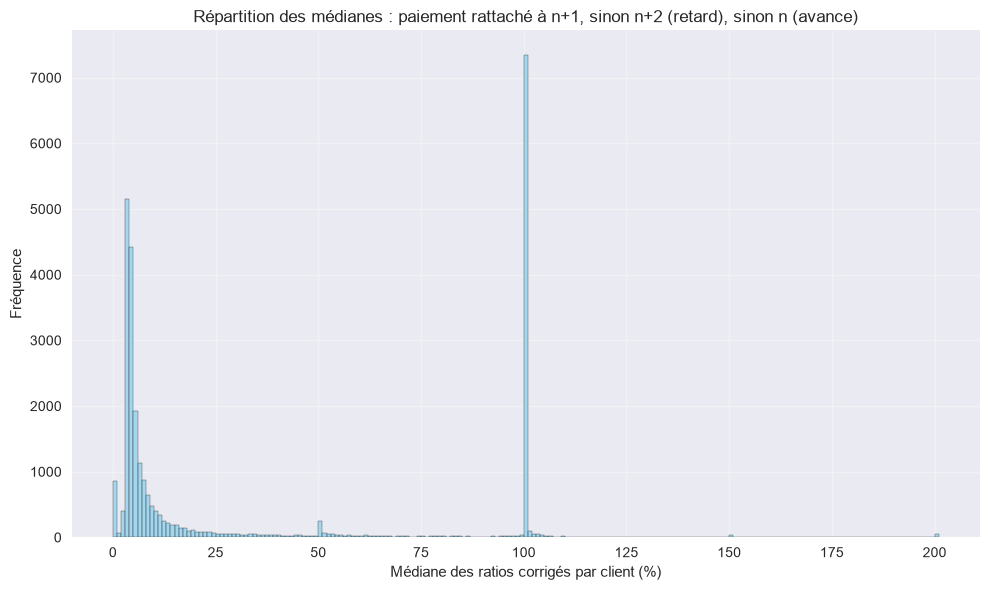

Nombre total de clients : 28590
Clients à 0 % pile : 777
Clients à 50 % pile : 173
Clients à 100 % pile : 5641


In [223]:
# version « chaque paiement cherche sa facture » : PAY_AMTn règle BILL_AMT(n+1) ;
# si elle n'est pas due (<= 0) : rattaché à BILL_AMT(n+2) (paiement en retard) ;
# sinon, si possible : rattaché à BILL_AMT(n) (paiement en avance).
# Chaque paiement n'est affecté qu'à une seule facture : aucun paiement n'est compté deux fois.
# Médiane classique (pandas) : comparable au graphique d'origine.

import numpy as np
import matplotlib.pyplot as plt

paye = {k: pd.Series(0.0, index=df.index) for k in range(2, 7)}   # montant affecté à BILL_AMT2 ... BILL_AMT6
statut = {}
total_trop_percu = 0.0

for n in range(1, 6):                       # PAY_AMT1 à PAY_AMT5 (PAY_AMT6 règle la facture de mars, non visible)
    p = df[f'PAY_AMT{n}']
    reste = p > 0                            # paiements pas encore affectés

    propre = reste & (df[f'BILL_AMT{n+1}'] > 0)                    # 1. sa facture
    reste &= ~propre
    retard = reste & (df[f'BILL_AMT{n+2}'] > 0) if n + 2 <= 6 else reste & False   # 2. facture d'avant (retard)
    reste &= ~retard
    avance = reste & (df[f'BILL_AMT{n}'] > 0) if n >= 2 else reste & False         # 3. facture suivante (avance)
    reste &= ~avance                                                # 4. ce qui reste : trop-perçu

    paye[n + 1] += p.where(propre, 0)
    if n + 2 <= 6:
        paye[n + 2] += p.where(retard, 0)
    if n >= 2:
        paye[n] += p.where(avance, 0)
    total_trop_percu += p.where(reste, 0).sum()
    statut[f'PAY_AMT{n}'] = {'facture propre': int(propre.sum()), 'retard (n+2)': int(retard.sum()),
                             'avance (n)': int(avance.sum()), 'trop-perçu': int(reste.sum())}

# Contrôle : paiements = affectés + trop-perçus (rien n'est compté deux fois)
total_paiements = sum(df[f'PAY_AMT{n}'].where(df[f'PAY_AMT{n}'] > 0, 0).sum() for n in range(1, 6))
total_affecte = sum(s.sum() for s in paye.values())
print("Devenir des paiements :")
print(pd.DataFrame(statut).T)
print(f"\nContrôle : paiements {total_paiements:,.0f} = affectés {total_affecte:,.0f} + trop-perçus {total_trop_percu:,.0f} "
      f"-> {'OK' if abs(total_paiements - total_affecte - total_trop_percu) < 1 else 'ERREUR'}")

# Ratios corrigés, rangés comme ratio_PAY_BILLn (ratio n = facture n+1), seulement quand la facture était due
ratios_corriges = pd.DataFrame({
    f'ratio_corr{k-1}': (paye[k] / df[f'BILL_AMT{k}'].where(df[f'BILL_AMT{k}'] > 0) * 100).clip(0, 200)
    for k in range(2, 7)
})

# Médiane classique, calculée automatiquement par pandas
df['ratio_median_corrige'] = ratios_corriges.median(axis=1)
medianes_corrigees = df['ratio_median_corrige'].dropna()

plt.figure(figsize=(10, 6))
plt.hist(medianes_corrigees, bins=range(0, 202, 1), color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Médiane des ratios corrigés par client (%)')
plt.ylabel('Fréquence')
plt.title('Répartition des médianes : paiement rattaché à n+1, sinon n+2 (retard), sinon n (avance)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Nombre total de clients : {len(medianes_corrigees)}")
print(f"Clients à 0 % pile : {(medianes_corrigees == 0).sum()}")
print(f"Clients à 50 % pile : {(medianes_corrigees == 50).sum()}")
print(f"Clients à 100 % pile : {(medianes_corrigees == 100).sum()}")


cherche la facture ne résout pas le problème de l'artefact du ratio à 50%

Répartition des cas :
cas
impair                                        25103
pair, départagé par la moyenne                 1452
sans valeur                                    1406
pair, valeurs du milieu égales                 1268
pair, égalité parfaite (médiane classique)      767
Name: count, dtype: int64


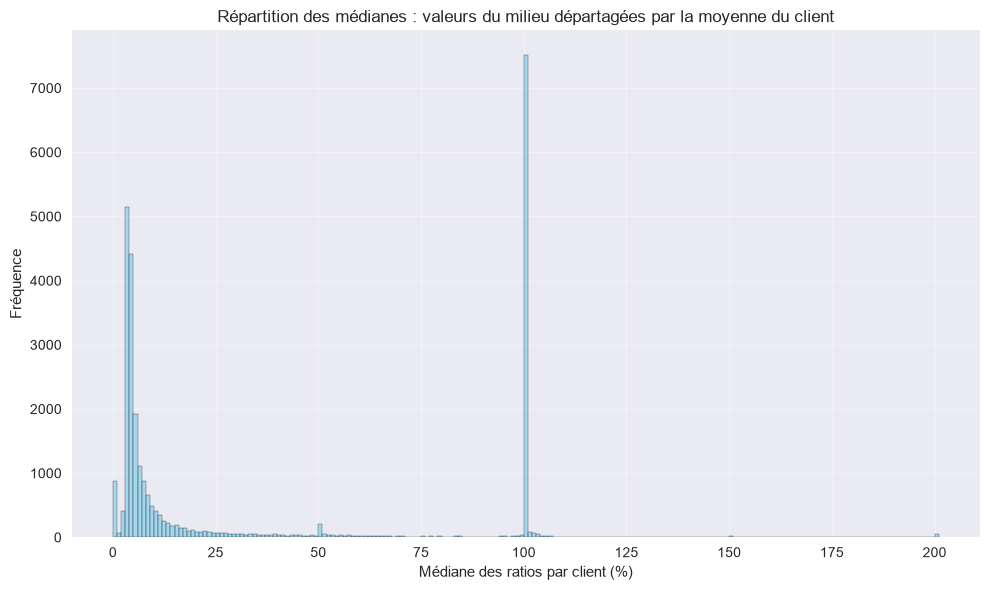


Clients à 50 % pile : médiane classique 176 -> départage 150
Clients à 0 % pile : médiane classique 781 -> départage 781
Clients à 100 % pile : médiane classique 5702 -> départage 5817


In [224]:
# Médiane avec départage par la moyenne : nombre pair de mois -> la valeur du milieu la plus proche
# de la moyenne des ratios du client ; en cas d'égalité parfaite, médiane classique (moyenne des deux)

import numpy as np
import matplotlib.pyplot as plt

ratios_dus = ratios_affichables(df, ratio_columns)      # ratios d'origine, seulement les mois avec une facture due

def mediane_departage_moyenne(ligne):
    v = ligne.dropna()
    if v.empty:
        return np.nan, 'sans valeur'
    t = np.sort(v.values); m = len(t)
    if m % 2:
        return t[m // 2], 'impair'
    bas, haut = t[m // 2 - 1], t[m // 2]
    if bas == haut:
        return bas, 'pair, valeurs du milieu égales'
    moyenne = v.mean()
    ecart_bas, ecart_haut = abs(moyenne - bas), abs(moyenne - haut)
    if np.isclose(ecart_bas, ecart_haut):
        return (bas + haut) / 2, 'pair, égalité parfaite (médiane classique)'
    return (bas if ecart_bas < ecart_haut else haut), 'pair, départagé par la moyenne'

resultat = ratios_dus.apply(lambda l: pd.Series(mediane_departage_moyenne(l), index=['mediane', 'cas']), axis=1)
df['ratio_median_departage'] = resultat['mediane'].astype(float)

print("Répartition des cas :")
print(resultat['cas'].value_counts())

medianes_departage = df['ratio_median_departage'].dropna()
plt.figure(figsize=(10, 6))
plt.hist(medianes_departage, bins=range(0, 202, 1), color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Médiane des ratios par client (%)')
plt.ylabel('Fréquence')
plt.title('Répartition des médianes : valeurs du milieu départagées par la moyenne du client')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

classique = ratios_dus.median(axis=1)
print(f"\nClients à 50 % pile : médiane classique {(classique == 50).sum()} -> départage {(medianes_departage == 50).sum()}")
print(f"Clients à 0 % pile : médiane classique {(classique == 0).sum()} -> départage {(medianes_departage == 0).sum()}")
print(f"Clients à 100 % pile : médiane classique {(classique == 100).sum()} -> départage {(medianes_departage == 100).sum()}")


les clients qui paient avec un mois de différé se retrouvent toujours avec une médiane à 50% dans ce cas de figure

Répartition des cas :
cas
impair                                        25103
pair, départagé par le taux global             2215
sans valeur                                    1406
pair, valeurs du milieu égales                 1268
pair, égalité parfaite (médiane classique)        4
Name: count, dtype: int64


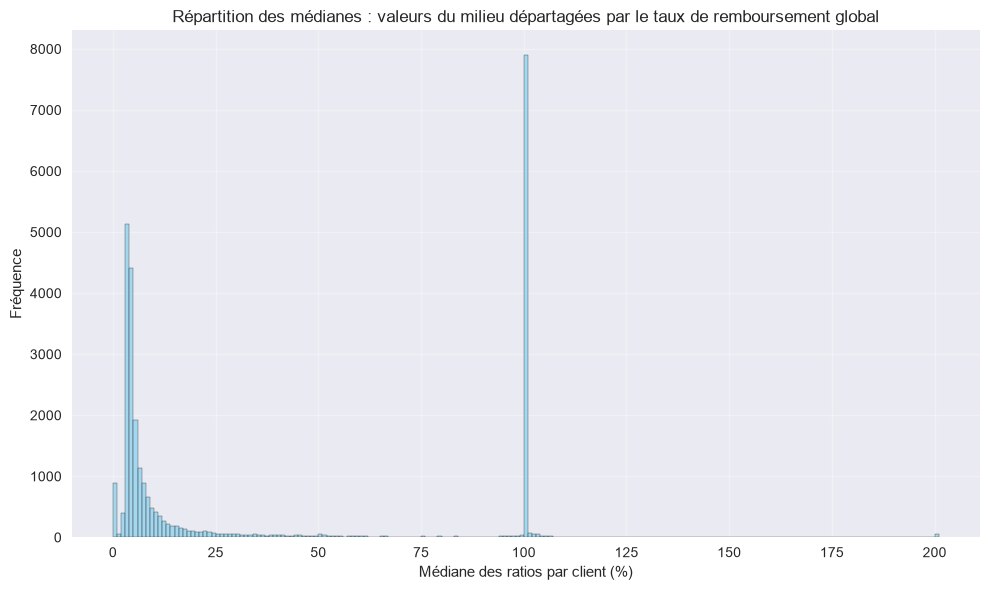

Clients à 0 % pile : médiane classique 781 -> départage global 796
Clients à 50 % pile : médiane classique 176 -> départage global 19
Clients à 100 % pile : médiane classique 5702 -> départage global 6240


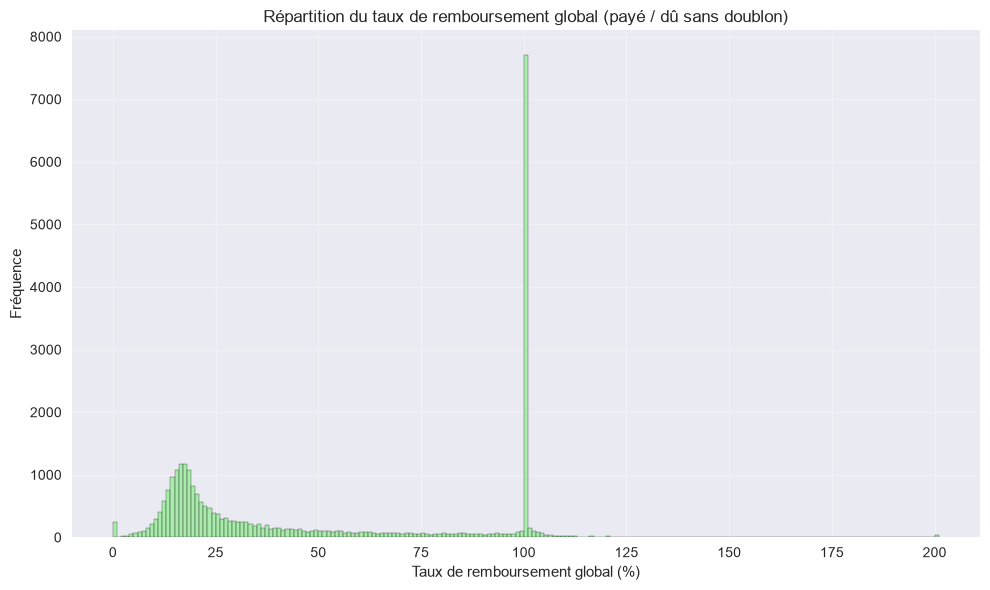

In [225]:
# Médiane départagée par le taux de remboursement global (dû sans doublon)
# dû sans doublon = BILL_AMT2 + PAY_AMT2..5 (la facture reportée n'est comptée qu'une fois)
# taux global = PAY_AMT1..5 / dû sans doublon ; nombre pair de mois avec deux valeurs du milieu différentes
# -> on garde celle qui est la plus proche du taux global

import numpy as np
import matplotlib.pyplot as plt

paye_total = df[[f'PAY_AMT{n}' for n in range(1, 6)]].sum(axis=1)
du_sans_doublon = df['BILL_AMT2'] + df[[f'PAY_AMT{n}' for n in range(2, 6)]].sum(axis=1)
df['taux_global'] = (paye_total / du_sans_doublon.where(du_sans_doublon > 0) * 100).clip(0, 200)

ratios_dus = ratios_affichables(df, ratio_columns)      # ratios d'origine, seulement les mois avec une facture due

def mediane_departage_global(ligne, reference):
    v = ligne.dropna()
    if v.empty:
        return np.nan, 'sans valeur'
    t = np.sort(v.values); m = len(t)
    if m % 2:
        return t[m // 2], 'impair'
    bas, haut = t[m // 2 - 1], t[m // 2]
    if bas == haut:
        return bas, 'pair, valeurs du milieu égales'
    if np.isnan(reference):
        return (bas + haut) / 2, 'pair, pas de taux global (médiane classique)'
    ecart_bas, ecart_haut = abs(reference - bas), abs(reference - haut)
    if np.isclose(ecart_bas, ecart_haut):
        return (bas + haut) / 2, 'pair, égalité parfaite (médiane classique)'
    return (bas if ecart_bas < ecart_haut else haut), 'pair, départagé par le taux global'

resultat = pd.DataFrame(
    [mediane_departage_global(ratios_dus.loc[i], df.at[i, 'taux_global']) for i in df.index],
    index=df.index, columns=['mediane', 'cas'])
df['ratio_median_global'] = resultat['mediane'].astype(float)

print("Répartition des cas :")
print(resultat['cas'].value_counts())

medianes_global = df['ratio_median_global'].dropna()
plt.figure(figsize=(10, 6))
plt.hist(medianes_global, bins=range(0, 202, 1), color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Médiane des ratios par client (%)')
plt.ylabel('Fréquence')
plt.title('Répartition des médianes : valeurs du milieu départagées par le taux de remboursement global')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

classique = ratios_dus.median(axis=1)
for valeur in (0, 50, 100):
    print(f"Clients à {valeur} % pile : médiane classique {(classique == valeur).sum()} -> départage global {(medianes_global == valeur).sum()}")

# Le taux global lui-même, pour voir s'il pourrait servir directement
plt.figure(figsize=(10, 6))
plt.hist(df['taux_global'].dropna(), bins=range(0, 202, 1), color='lightgreen', edgecolor='black', alpha=0.7)
plt.xlabel('Taux de remboursement global (%)')
plt.ylabel('Fréquence')
plt.title('Répartition du taux de remboursement global (payé / dû sans doublon)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [226]:
# Création des 2 colonnes candidates, puis taux de valeurs manquantes
# 1. taux_remboursement_global = payé / dû sans doublon, en %, écrêté entre 0 et 200
#    dû sans doublon = BILL_AMT2 + PAY_AMT2..PAY_AMT5 (une facture reportée n'est comptée qu'une fois)
# 2. ratio_PAY_to_BILL_median_global = médiane des ratio_PAY_BILLn sur les seuls mois avec une facture due ;
#    si deux valeurs du milieu différentes (nombre pair de mois) : la plus proche du taux global ;
#    égalité parfaite : médiane classique

import numpy as np

colonnes_ratio = [f'ratio_PAY_BILL{n}' for n in range(1, 6)]

# 1. Taux de remboursement global
paye_total = df[[f'PAY_AMT{n}' for n in range(1, 6)]].sum(axis=1)
du_sans_doublon = df['BILL_AMT2'] + df[[f'PAY_AMT{n}' for n in range(2, 6)]].sum(axis=1)
df['taux_remboursement_global'] = (paye_total / du_sans_doublon.where(du_sans_doublon > 0) * 100).clip(0, 200)

# 2. Médiane départagée par le taux global
# ratios des seuls mois avec une facture due (ratio_PAY_BILLn va avec BILL_AMT(n+1))
ratios_dus = pd.DataFrame({c: df[c].where(df[f'BILL_AMT{n + 1}'] > 0) for n, c in enumerate(colonnes_ratio, start=1)})

def mediane_departage_global(valeurs, reference):
    v = valeurs[~np.isnan(valeurs)]
    if v.size == 0:
        return np.nan
    t = np.sort(v); m = t.size
    if m % 2:
        return t[m // 2]
    bas, haut = t[m // 2 - 1], t[m // 2]
    if bas == haut or np.isnan(reference):
        return (bas + haut) / 2
    ecart_bas, ecart_haut = abs(reference - bas), abs(reference - haut)
    if np.isclose(ecart_bas, ecart_haut):
        return (bas + haut) / 2
    return bas if ecart_bas < ecart_haut else haut

df['ratio_PAY_to_BILL_median_global'] = [
    mediane_departage_global(valeurs, reference)
    for valeurs, reference in zip(ratios_dus.to_numpy(dtype=float), df['taux_remboursement_global'].to_numpy(dtype=float))
]

# Taux de valeurs manquantes
manquants = pd.DataFrame({
    'clients': len(df),
    'valeurs manquantes': df[['taux_remboursement_global', 'ratio_PAY_to_BILL_median_global']].isna().sum(),
})
manquants['taux de NaN (%)'] = (manquants['valeurs manquantes'] / manquants['clients'] * 100).round(2)
print(manquants)

# Contrôles
sans_mediane = df['ratio_PAY_to_BILL_median_global'].isna()
print(f"\nClients avec une médiane mais sans taux global : {(~sans_mediane & df['taux_remboursement_global'].isna()).sum()}")
print(f"Clients sans médiane mais avec une facture en septembre (BILL_AMT1 > 0) : {(sans_mediane & (df['BILL_AMT1'] > 0)).sum()}")
print(f"Clients sans médiane ni facture positive sur 6 mois : {(sans_mediane & (df[[f'BILL_AMT{k}' for k in range(1, 7)]] <= 0).all(axis=1)).sum()}")


                                 clients  valeurs manquantes  taux de NaN (%)
taux_remboursement_global          29996                1371             4.57
ratio_PAY_to_BILL_median_global    29996                1406             4.69

Clients avec une médiane mais sans taux global : 0
Clients sans médiane mais avec une facture en septembre (BILL_AMT1 > 0) : 440
Clients sans médiane ni facture positive sur 6 mois : 966


**Classification des clients par types d'usage de leur carte : crédit / comptant / autre**

Clients avec une médiane : 28590 sur 29996 (sans médiane : 440 à -1, 966 vides)


,clients,part (%)
type_usage,,
Ne paie rien,796,2.8
Client en difficulté,535,1.9
Crédit par mensualité,11477,40.1
Usage mixte,5978,20.9
Remboursement élevé,1424,5.0
Paiement comptant,8150,28.5
Paie plus que sa facture,230,0.8


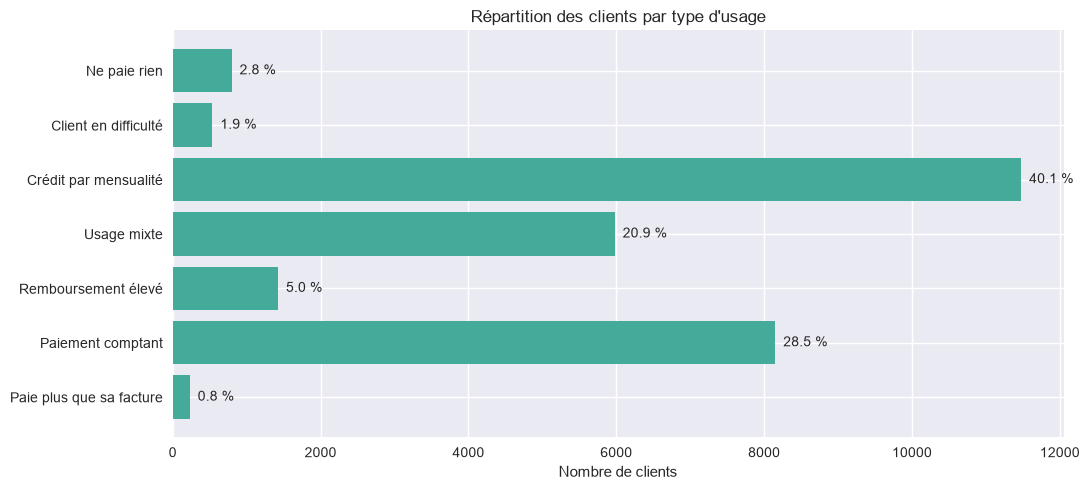

In [227]:
# Répartition des clients par type d'usage (7 catégories, mêmes tranches que la page 4.3 et ratio_PAY_BILL_regularite)
# Population : df du lab (29 996 lignes, sans les 4 paiements géants) ; médiane créée à la cellule précédente
import numpy as np
import matplotlib.pyplot as plt

mediane = df['ratio_PAY_to_BILL_median_global'].copy()
# Seule la facture de septembre est due (paiement en octobre, hors période) : -1, pas de type d'usage
mediane[mediane.isna() & (df['BILL_AMT1'] > 0)] = -1

types_usage = ['Ne paie rien', 'Client en difficulté', 'Crédit par mensualité', 'Usage mixte',
               'Remboursement élevé', 'Paiement comptant', 'Paie plus que sa facture']
# 0 % exactement, ]0-3[, [3-6[, [6-30[, [30-99[, [99-105], plus de 105 %
df['type_usage'] = pd.Series(
    np.select([mediane == 0, mediane < 3, mediane < 6, mediane < 30, mediane < 99, mediane <= 105, mediane > 105],
              types_usage, default=None),
    index=df.index).where(mediane >= 0)

repartition = df['type_usage'].value_counts().reindex(types_usage).rename('clients').to_frame()
repartition['part (%)'] = (repartition['clients'] / repartition['clients'].sum() * 100).round(1)
print(f"Clients avec une médiane : {int(repartition['clients'].sum())} sur {len(df)} "
      f"(sans médiane : {int((mediane == -1).sum())} à -1, {int(mediane.isna().sum())} vides)")
display(repartition)

plt.figure(figsize=(11, 5))
barres = plt.barh(types_usage[::-1], repartition['clients'][::-1], color='#44AA99')
for barre, part in zip(barres, repartition['part (%)'][::-1]):
    plt.text(barre.get_width(), barre.get_y() + barre.get_height() / 2, f'  {part:.1f} %', va='center')
plt.xlabel('Nombre de clients')
plt.title("Répartition des clients par type d'usage")
plt.tight_layout()
plt.show()


In [228]:
# Clients qui paient plus que leur facture (médiane > 105 %) : d'où vient le trop-payé ? (sans dpnm)
# Comparaison avec les payeurs au comptant (médiane de 99 à 105 %), sur les mois où le client paie plus de 105 % de sa facture
groupes = {'Paie plus que sa facture': df['type_usage'] == 'Paie plus que sa facture',
           'Paiement comptant': df['type_usage'] == 'Paiement comptant'}

# 1. Profil des clients
profil = pd.DataFrame({
    nom: {
        'clients': int(masque.sum()),
        'plafond médian (NT$)': df.loc[masque, 'LIMIT_BAL'].median(),
        'mois avec une facture due (médiane)': sum((df.loc[masque, f'BILL_AMT{n + 1}'] > 0).astype(int) for n in range(1, 6)).median(),
        'facture due médiane (NT$)': pd.concat([df.loc[masque & (df[f'BILL_AMT{n + 1}'] > 0), f'BILL_AMT{n + 1}'] for n in range(1, 6)]).median(),
    } for nom, masque in groupes.items()
})
print("1. Profil des clients")
display(profil.round(0))

# 2. Les mois de trop-payé : PAY_AMTn > 105 % de BILL_AMT(n+1), facture due
lignes = []
for n in range(1, 6):
    facture, paiement, solde_suivant = df[f'BILL_AMT{n + 1}'], df[f'PAY_AMT{n}'], df[f'BILL_AMT{n}']
    trop_paye = (facture > 0) & (paiement > 1.05 * facture)
    for nom, masque in groupes.items():
        sel = masque & trop_paye
        lignes.append(pd.DataFrame({
            'groupe': nom,
            'facture': facture[sel].to_numpy(),
            'paiement': paiement[sel].to_numpy(),
            'excès': (paiement - facture)[sel].to_numpy(),
            # Avance : le paiement en trop laisse un solde créditeur (facture suivante négative)
            'solde suivant créditeur': (solde_suivant[sel] < 0).to_numpy(),
            # Le client règle la facture du mois même (BILL_AMTn) plutôt que celle du mois précédent (à 5 % près)
            'paie la facture du mois même': ((paiement - solde_suivant).abs() <= 0.05 * solde_suivant.abs())[sel].to_numpy(),
            'petite facture (moins de 1 000 NT$)': (facture[sel] < 1000).to_numpy(),
            'paiement rond (multiple de 1 000 NT$)': (paiement[sel] % 1000 == 0).to_numpy(),
            # Rattrapage : la facture réglée (BILL_AMT(n+1)) est codifiée en retard (PAY_(n+1) >= 2)
            'facture réglée codifiée en retard': (df[f'PAY_{n + 1}'][sel] >= 2).to_numpy(),
        }))
mois_trop_paye = pd.concat(lignes, ignore_index=True)

resume = mois_trop_paye.groupby('groupe').agg(
    **{'mois de trop-payé': ('facture', 'size'), 'facture médiane (NT$)': ('facture', 'median'),
       'paiement médian (NT$)': ('paiement', 'median'), 'excès médian (NT$)': ('excès', 'median')})
for col in ['solde suivant créditeur', 'paie la facture du mois même', 'petite facture (moins de 1 000 NT$)',
            'paiement rond (multiple de 1 000 NT$)', 'facture réglée codifiée en retard']:
    resume[f'{col} (%)'] = mois_trop_paye.groupby('groupe')[col].mean() * 100
print("2. Les mois où le client paie plus de 105 % de sa facture")
display(resume.round(1).T)

# 3. Paiement fixe chaque mois (prélèvement d'un montant constant, supérieur à une petite facture ?)
paiements = df[[f'PAY_AMT{n}' for n in range(1, 6)]]
montant_le_plus_frequent = paiements.where(paiements > 0).apply(lambda l: l.value_counts().max() if l.notna().any() else 0, axis=1)
print("3. Clients qui paient le même montant au moins 3 mois sur 5 :")
for nom, masque in groupes.items():
    print(f"   {nom} : {(montant_le_plus_frequent[masque] >= 3).mean() * 100:.1f} %")

# 4. Exemples de clients qui paient plus que leur facture
colonnes = ['LIMIT_BAL'] + [f'PAY_{n}' for n in range(1, 7)] + [f'BILL_AMT{n}' for n in range(1, 7)] + [f'PAY_AMT{n}' for n in range(1, 6)]
print("4. Exemples (10 premiers clients)")
display(df.loc[groupes['Paie plus que sa facture'], colonnes].head(10))


1. Profil des clients


,Paie plus que sa facture,Paiement comptant
clients,230.0,8150.0
plafond médian (NT$),160000.0,200000.0
mois avec une facture due (médiane),3.0,5.0
facture due médiane (NT$),1683.0,2662.0


2. Les mois où le client paie plus de 105 % de sa facture


groupe,Paie plus que sa facture,Paiement comptant
mois de trop-payé,468.0,1549.0
facture médiane (NT$),1518.0,2418.0
paiement médian (NT$),2811.5,3773.0
excès médian (NT$),745.0,754.0
solde suivant créditeur (%),35.0,16.3
paie la facture du mois même (%),1.7,2.2
petite facture (moins de 1 000 NT$) (%),41.2,29.2
paiement rond (multiple de 1 000 NT$) (%),32.3,13.4
facture réglée codifiée en retard (%),0.2,0.2


3. Clients qui paient le même montant au moins 3 mois sur 5 :
   Paie plus que sa facture : 4.3 %
   Paiement comptant : 9.2 %
4. Exemples (10 premiers clients)


,LIMIT_BAL,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5
ID,,,,,,,,,,,,,,,,,,
27,60000,1,-2,-1,-1,-1,-1,-109,-425,259,-57,127,-189,0,1000,0,500,0
93,100000,-2,-2,-2,-2,-2,-2,-2000,5555,0,0,0,0,7555,0,0,0,0
150,260000,1,-2,-1,-1,-1,-1,-1100,-1100,21400,0,969,869,0,22500,0,969,1000
352,200000,1,-2,-1,-1,-2,-1,-14386,-13543,3432,-3684,0,1386,10118,47015,0,4000,100000
496,50000,-1,-1,-1,-1,-1,-1,508,672,226,390,220,320,1000,390,1000,220,640
622,180000,-1,-1,-1,-1,-1,-1,340,-120,420,460,460,610,0,1000,500,460,610
792,70000,1,-1,-1,-1,-2,-1,-54,273,19,-254,-527,1096,600,19,0,0,1896
794,280000,1,-2,-2,-2,-2,-2,-288,-288,-288,-288,-288,2124,0,0,0,0,2412
844,110000,1,-2,-2,-2,-2,-1,0,0,0,0,0,150,0,0,0,0,300


In [229]:
# Test d'ajustement des types d'usage (sans dpnm) : chaque règle est appliquée l'une après l'autre,
# on compte les clients qu'elle déplace, puis on regarde qui reste dans « Paie plus que sa facture »
NON_MESURABLE, COMPTANT, TROP_PAYE = 'Usage non mesurable (une seule facture due)', 'Paiement comptant', 'Paie plus que sa facture'
mediane_type = df['ratio_PAY_to_BILL_median_global']
taux_global = df['taux_remboursement_global']
nb_mois_dus = sum((df[f'BILL_AMT{n + 1}'] > 0).astype(int) for n in range(1, 6))
nb_moins_2 = (df[[f'PAY_{n}' for n in range(1, 7)]] == -2).sum(axis=1)

type_ajuste = df['type_usage'].astype(object).copy()
regles = {
    # 1. Une seule facture due : la médiane est un paiement isolé, pas une habitude
    "1. Une seule facture due -> usage non mesurable": type_ajuste.notna() & (nb_mois_dus == 1),
}
type_ajuste[regles["1. Une seule facture due -> usage non mesurable"]] = NON_MESURABLE
# 2. Codifié -2 au moins 5 mois sur 6 et médiane d'au moins 99 % : la banque le voit comme un client sans crédit
regles["2. -2 au moins 5 mois sur 6, médiane >= 99 % -> paiement comptant"] = (type_ajuste == TROP_PAYE) & (nb_moins_2 >= 5) & (mediane_type >= 99)
type_ajuste[regles["2. -2 au moins 5 mois sur 6, médiane >= 99 % -> paiement comptant"]] = COMPTANT
# 3. Trop-payé compensé : sur la période, il a payé ce qu'il devait (taux global de 99 à 105 %), en avance certains mois
regles["3. Taux global de 99 à 105 % -> paiement comptant"] = (type_ajuste == TROP_PAYE) & taux_global.between(99, 105)
type_ajuste[regles["3. Taux global de 99 à 105 % -> paiement comptant"]] = COMPTANT

print("Clients déplacés par chaque règle :")
for nom, masque in regles.items():
    print(f"   {nom} : {int(masque.sum())}")

ordre = types_usage + [NON_MESURABLE]
avant_apres = pd.DataFrame({'avant': df['type_usage'].value_counts(), 'après ajustement': type_ajuste.value_counts()}).reindex(ordre).fillna(0).astype(int)
avant_apres['écart'] = avant_apres['après ajustement'] - avant_apres['avant']
display(avant_apres)

# Ceux qui restent « en dehors des clous »
reste = type_ajuste == TROP_PAYE
print(f"Restent dans « {TROP_PAYE} » : {int(reste.sum())} clients | mois avec une facture due :",
      nb_mois_dus[reste].value_counts().sort_index().to_dict(),
      f"| taux global : médiane {taux_global[reste].median():.0f} %, plus de 105 % pour {(taux_global[reste] > 105).mean() * 100:.0f} % d'entre eux")
colonnes = ['LIMIT_BAL'] + [f'PAY_{n}' for n in range(1, 7)] + [f'BILL_AMT{n}' for n in range(1, 7)] + [f'PAY_AMT{n}' for n in range(1, 5 + 1)]
display(df.loc[reste, colonnes + ['ratio_PAY_to_BILL_median_global', 'taux_remboursement_global']].head(15))


Clients déplacés par chaque règle :
   1. Une seule facture due -> usage non mesurable : 939
   2. -2 au moins 5 mois sur 6, médiane >= 99 % -> paiement comptant : 29
   3. Taux global de 99 à 105 % -> paiement comptant : 46


,avant,après ajustement,écart
type_usage,,,
Ne paie rien,796,750,-46
Client en difficulté,535,516,-19
Crédit par mensualité,11477,11417,-60
Usage mixte,5978,5893,-85
Remboursement élevé,1424,1390,-34
Paiement comptant,8150,7579,-571
Paie plus que sa facture,230,106,-124
Usage non mesurable (une seule facture due),0,939,939


Restent dans « Paie plus que sa facture » : 106 clients | mois avec une facture due : {2: 45, 3: 18, 4: 27, 5: 16} | taux global : médiane 117 %, plus de 105 % pour 89 % d'entre eux


,LIMIT_BAL,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,ratio_PAY_to_BILL_median_global,taux_remboursement_global
ID,,,,,,,,,,,,,,,,,,,,
27,60000,1,-2,-1,-1,-1,-1,-109,-425,259,-57,127,-189,0,1000,0,500,0,200.000000,139.534884
352,200000,1,-2,-1,-1,-2,-1,-14386,-13543,3432,-3684,0,1386,10118,47015,0,4000,100000,200.000000,117.211505
496,50000,-1,-1,-1,-1,-1,-1,508,672,226,390,220,320,1000,390,1000,220,640,172.566372,111.225188
792,70000,1,-1,-1,-1,-2,-1,-54,273,19,-254,-527,1096,600,19,0,0,1896,172.992701,114.945155
1003,90000,-1,-1,-1,-1,-1,-1,4989,-818,1114,657,1332,780,0,2806,2256,2274,780,170.720721,111.208550
1320,250000,-1,-1,-1,0,0,-1,17454,-50,45297,17371,11481,5922,24890,48394,0,5461,15000,106.837097,136.247366
1651,500000,-1,-1,-1,-1,-1,-1,36954,-24704,22999,18339,-3876,15586,0,83000,0,0,20000,128.320287,131.552059
1663,90000,-2,-2,2,2,-2,-2,1179,6346,4607,-6,-2153,-4306,7020,2980,3000,0,0,110.620864,105.468116
1856,220000,-1,-1,-1,-1,-2,-2,8727,2553,147,0,0,0,3011,147,0,0,0,117.939679,116.962963


In [230]:
# ============================================================================================================
# TYPES D'USAGE : MÉTHODE PROPOSÉE, ÉTAPE PAR ÉTAPE, COMPARÉE AU CLASSEMENT ACTUEL (sans dpnm)
# Cellule autonome : elle recalcule tout à partir des colonnes du df du lab (ratio_PAY_BILLn, PAY_AMTn, BILL_AMTn, PAY_n)
# ============================================================================================================
TYPES = ['Ne paie rien', 'Client en difficulté', 'Crédit par mensualité', 'Usage mixte',
         'Remboursement élevé', 'Paiement comptant', 'Paie plus que sa facture']
NON_MESURABLE = 'Usage non mesurable (une seule facture due)'
ordre = TYPES + [NON_MESURABLE]


def type_selon(valeur):
    """Tranches du type d'usage : 0 %, ]0-3[, [3-6[, [6-30[, [30-99[, [99-105], plus de 105 %."""
    return pd.Series(np.select([valeur == 0, valeur < 3, valeur < 6, valeur < 30, valeur < 99, valeur <= 105, valeur > 105],
                               TYPES, default=None), index=df.index).where(valeur >= 0).astype(object)


def mediane_departagee(valeurs, reference):
    """Médiane des ratios ; nombre pair de mois et deux valeurs du milieu différentes : la plus proche de la référence."""
    v = np.sort(valeurs[~np.isnan(valeurs)])
    if v.size == 0:
        return np.nan
    if v.size % 2:
        return v[v.size // 2]
    bas, haut = v[v.size // 2 - 1], v[v.size // 2]
    if bas == haut or np.isnan(reference) or np.isclose(abs(reference - bas), abs(reference - haut)):
        return (bas + haut) / 2
    return bas if abs(reference - bas) < abs(reference - haut) else haut


# --- Mesures ------------------------------------------------------------------------------------------------
ratios_mois = pd.DataFrame({n: df[f'ratio_PAY_BILL{n}'].where(df[f'BILL_AMT{n + 1}'] > 0) for n in range(1, 6)})  # mois avec facture due
nb_factures = ratios_mois.notna().sum(axis=1)
paye = df[[f'PAY_AMT{n}' for n in range(1, 6)]].sum(axis=1)
du = df['BILL_AMT2'] + df[[f'PAY_AMT{n}' for n in range(2, 6)]].sum(axis=1)
taux_base = (paye / du.where(du > 0) * 100).clip(0, 200)
# Taux corrigé : le trop-payé ne compte que s'il est encore sur la carte fin septembre (partie négative de BILL_AMT1)
exces, avoir_final = paye - du, (-df['BILL_AMT1']).clip(lower=0)
taux_corrige = (paye.where(exces <= 0, du + np.minimum(exces, avoir_final)) / du.where(du > 0) * 100).clip(0, 200)


def mediane_avec(reference):
    m = pd.Series([mediane_departagee(v, r) for v, r in zip(ratios_mois.to_numpy(dtype=float), reference.to_numpy(dtype=float))],
                  index=df.index)
    m[m.isna() & (df['BILL_AMT1'] > 0)] = -1      # seule la facture de septembre est due : pas de type
    return m


# --- Étape 0 : classement actuel ----------------------------------------------------------------------------
actuel = type_selon(mediane_avec(taux_base))
print("ÉTAPE 0. Point de départ : le classement actuel, par la médiane des ratios mensuels (départagée par le taux global de remboursement sur toute la période de base).")
print(f"   {int(actuel.notna().sum())} clients ont un type d'usage.\n")

# --- Étape 1 : une seule facture due ------------------------------------------------------------------------
etape1 = actuel.notna() & (nb_factures == 1)
type_final = actuel.copy()
type_final[etape1] = NON_MESURABLE
print("ÉTAPE 1. Une seule facture due sur la période : la médiane n'est qu'un paiement isolé, pas une habitude.")
print(f"   -> {int(etape1.sum())} clients passent en « {NON_MESURABLE} ». Ils étaient classés :")
for t, n in actuel[etape1].value_counts().reindex(TYPES).dropna().astype(int).items():
    print(f"        {t:28} : {n}")
print()

# --- Étape 2 : médiane départagée par le taux corrigé -------------------------------------------------------
type_etape2 = type_selon(mediane_avec(taux_corrige))
type_etape2[etape1] = NON_MESURABLE
etape2 = type_final.fillna('-') != type_etape2.fillna('-')
print("ÉTAPE 2. La médiane est départagée par le taux global de remboursement sur toute la période CORRIGÉ (une avance dépensée ensuite n'est plus un trop-payé).")
print("         Seuls les clients avec un nombre pair de mois et deux valeurs du milieu différentes peuvent changer.")
print(f"   -> {int(etape2.sum())} clients changent de type :")
for (de, vers), n in pd.Series(list(zip(type_final[etape2], type_etape2[etape2])), dtype=object).value_counts().items():
    print(f"        {de} -> {vers} : {n}")
type_final = type_etape2
print()

# --- Étape 3 : confirmation du trop-payé --------------------------------------------------------------------
candidats = type_final == 'Paie plus que sa facture'
confirmes = candidats & (taux_corrige > 105)
print("ÉTAPE 3. Vérification des clients classés « Paie plus que sa facture » par leur médiane (habitude mensuelle) :")
print("         on refait le compte sur toute la période (taux global corrigé : tout ce qu'il a payé / tout ce qu'il devait,")
print("         sans compter les avances dépensées ensuite).")
print(f"   -> {int(candidats.sum())} clients vérifiés :")
print(f"        plus de 105 % : il a vraiment laissé de l'argent en trop sur sa carte -> restent « Paie plus que sa facture » : {int(confirmes.sum())}")
print(f"        99 à 105 %    : il a payé exactement sa dette, en avance certains mois -> « Paiement comptant » : "
      f"{int((candidats & taux_corrige.between(99, 105)).sum())}")
print(f"        moins de 99 % : son habitude reste de solder ses factures, mais un gros achat récent n'est pas encore remboursé"
      f" -> « Paiement comptant » (l'habitude prime ; la dette récente est portée par d'autres mesures) : "
      f"{int((candidats & (taux_corrige < 99)).sum())}\n")
type_final[candidats & ~confirmes] = 'Paiement comptant'


# --- Bilan --------------------------------------------------------------------------------------------------
bilan = pd.DataFrame({'Classement actuel (clients)': actuel.value_counts(),
                      'Méthode proposée (clients)': type_final.value_counts()}).reindex(ordre).fillna(0).astype(int)
bilan['Différence'] = bilan['Méthode proposée (clients)'] - bilan['Classement actuel (clients)']
bilan['Part, méthode proposée (%)'] = (bilan['Méthode proposée (clients)'] / bilan['Méthode proposée (clients)'].sum() * 100).round(1)
print("BILAN : nombre de clients par type d'usage, avant et après les trois étapes")
display(bilan.rename_axis("Type d'usage"))

# --- Vérification par les codifications de la banque --------------------------------------------------------
codifs = df[[f'PAY_{n}' for n in range(1, 7)]].clip(upper=2)


def plus_frequente(l):
    comptes = l.value_counts()
    return next(v for v in l if comptes[v] == comptes.max())     # égalité : la plus récente (PAY_1 d'abord)


FAMILLES = ['-2 ou -1 (comptant / rien à payer)', '0 (crédit renouvelable)', '1 ou plus (retard)']
habituelle = codifs.apply(plus_frequente, axis=1)
famille = pd.Series(np.select([habituelle <= -1, habituelle == 0, habituelle >= 1], FAMILLES, default=None), index=df.index)


def verif(types):
    return (pd.crosstab(types, famille, normalize='index') * 100).round(1).reindex(index=ordre, columns=FAMILLES)


ÉTAPE 0. Point de départ : le classement actuel, par la médiane des ratios mensuels (départagée par le taux global de remboursement sur toute la période de base).
   28590 clients ont un type d'usage.

ÉTAPE 1. Une seule facture due sur la période : la médiane n'est qu'un paiement isolé, pas une habitude.
   -> 939 clients passent en « Usage non mesurable (une seule facture due) ». Ils étaient classés :
        Ne paie rien                 : 46
        Client en difficulté         : 19
        Crédit par mensualité        : 60
        Usage mixte                  : 85
        Remboursement élevé          : 34
        Paiement comptant            : 646
        Paie plus que sa facture     : 49

ÉTAPE 2. La médiane est départagée par le taux global de remboursement sur toute la période CORRIGÉ (une avance dépensée ensuite n'est plus un trop-payé).
         Seuls les clients avec un nombre pair de mois et deux valeurs du milieu différentes peuvent changer.
   -> 26 clients changent de typ

,Classement actuel (clients),Méthode proposée (clients),Différence,"Part, méthode proposée (%)"
Type d'usage,,,,
Ne paie rien,796,750,-46,2.6
Client en difficulté,535,516,-19,1.8
Crédit par mensualité,11477,11417,-60,39.9
Usage mixte,5978,5893,-85,20.6
Remboursement élevé,1424,1392,-32,4.9
Paiement comptant,8150,7658,-492,26.8
Paie plus que sa facture,230,25,-205,0.1
Usage non mesurable (une seule facture due),0,939,939,3.3


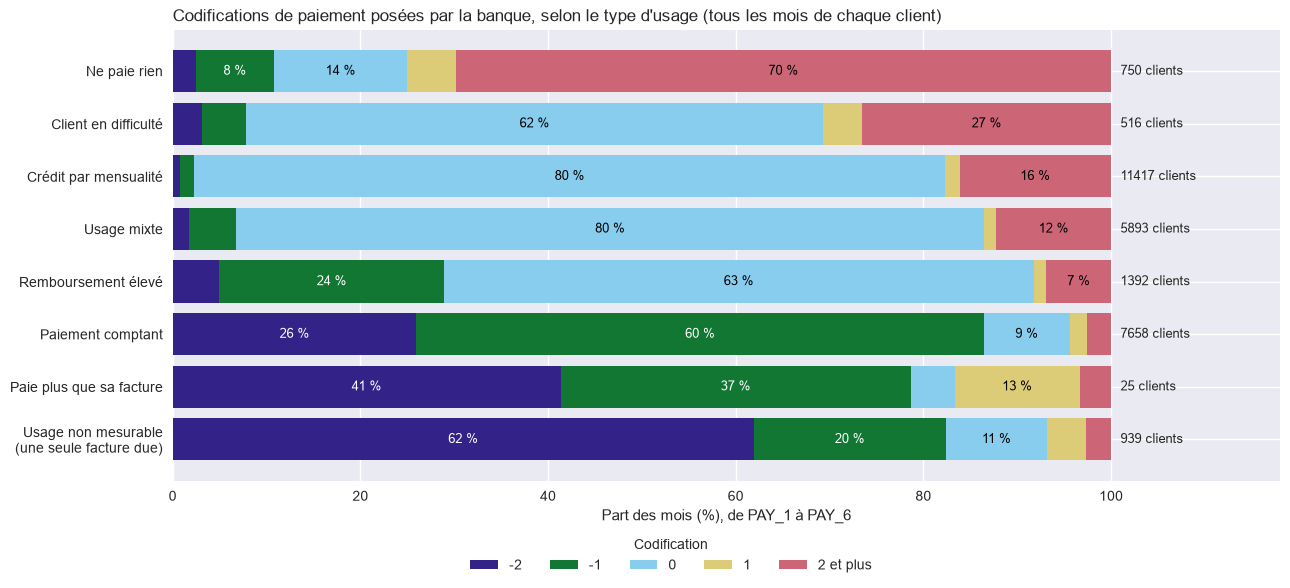

Comment lire : chaque barre fait 100 % des mois des clients du type. Les payeurs au comptant devraient être surtout codifiés -2 ou -1, les clients à crédit surtout 0, et les retards (2 et plus) se concentrer chez ceux qui paient peu.
   Paiement comptant : 86 % des mois codifiés -2 ou -1 | Crédit par mensualité : 80 % des mois codifiés 0 | Ne paie rien : 70 % des mois en retard.



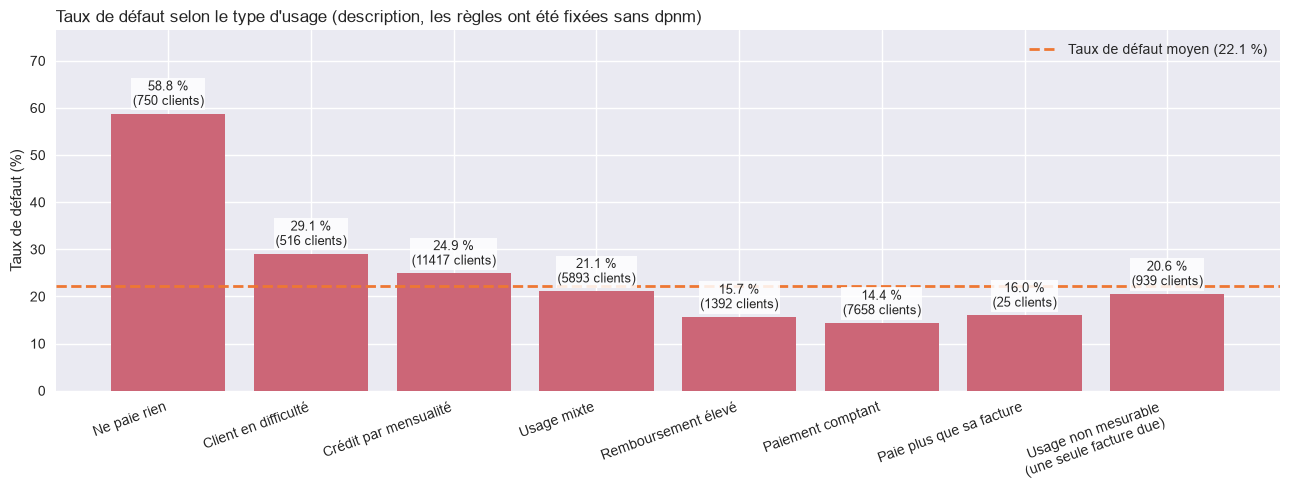

Comment lire : la ligne en pointillés est le taux de défaut moyen de tous les clients. Attention aux petits groupes (« Paie plus que sa facture » : 25 clients) : leur taux est peu fiable.


In [231]:
# Graphiques par type d'usage (méthode proposée, variable type_final de la cellule précédente)
# 1. Codifications PAY_n : tous les mois de PAY_1 à PAY_6 de chaque client, mis ensemble (sans dpnm)
# 2. Taux de défaut (dpnm) : description seulement, les règles ont été fixées sans dpnm
import matplotlib.pyplot as plt

COULEURS_CODIF = {'-2': '#332288', '-1': '#117733', '0': '#88CCEE', '1': '#DDCC77', '2 et plus': '#CC6677'}
ordre_types = [t for t in ordre if (type_final == t).any()]
etiquettes = [t.replace(' (une seule facture due)', '\n(une seule facture due)') for t in ordre_types]

# --- 1. Répartition des codifications PAY_n ------------------------------------------------------------------
mois = df[[f'PAY_{n}' for n in range(1, 7)]].clip(upper=2).astype(int).astype(str).replace({'2': '2 et plus'})
mois['type'] = type_final
codifs_long = mois.melt(id_vars='type', value_name='codification').dropna(subset=['type'])
parts = (pd.crosstab(codifs_long['type'], codifs_long['codification'], normalize='index') * 100)
parts = parts.reindex(index=ordre_types, columns=list(COULEURS_CODIF), fill_value=0)

fig, ax = plt.subplots(figsize=(13, 6))
gauche = np.zeros(len(parts))
for codif, couleur in COULEURS_CODIF.items():
    ax.barh(etiquettes, parts[codif], left=gauche, color=couleur, label=codif)
    for y, (g, v) in enumerate(zip(gauche, parts[codif])):
        if v >= 6:
            ax.text(g + v / 2, y, f'{v:.0f} %', ha='center', va='center', fontsize=9,
                    color='white' if codif in ('-2', '-1') else 'black')
    gauche += parts[codif].to_numpy()
for y, t in enumerate(ordre_types):
    ax.text(101, y, f'{int((type_final == t).sum())} clients', va='center', fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, 118)
ax.set_xticks(range(0, 101, 20))
ax.set_xlabel('Part des mois (%), de PAY_1 à PAY_6')
ax.set_title("Codifications de paiement posées par la banque, selon le type d'usage (tous les mois de chaque client)", loc='left')
ax.legend(title='Codification', ncol=5, loc='upper center', bbox_to_anchor=(0.45, -0.1), frameon=False)
plt.tight_layout()
plt.show()
print("Comment lire : chaque barre fait 100 % des mois des clients du type. Les payeurs au comptant devraient être surtout "
      "codifiés -2 ou -1, les clients à crédit surtout 0, et les retards (2 et plus) se concentrer chez ceux qui paient peu.")
print(f"   Paiement comptant : {parts.loc['Paiement comptant', ['-2', '-1']].sum():.0f} % des mois codifiés -2 ou -1 | "
      f"Crédit par mensualité : {parts.loc['Crédit par mensualité', '0']:.0f} % des mois codifiés 0 | "
      f"Ne paie rien : {parts.loc['Ne paie rien', '2 et plus']:.0f} % des mois en retard.\n")

# --- 2. Taux de défaut par type d'usage ----------------------------------------------------------------------
taux_moyen = df['dpnm'].mean() * 100
stats = df.groupby(type_final)['dpnm'].agg(clients='size', taux='mean').reindex(ordre_types)
stats['taux'] *= 100

fig, ax = plt.subplots(figsize=(13, 5))
barres = ax.bar(etiquettes, stats['taux'], color='#CC6677')
ax.axhline(taux_moyen, color='#EE7733', linestyle='--', linewidth=2, label=f'Taux de défaut moyen ({taux_moyen:.1f} %)')
for barre, (taux, n) in zip(barres, zip(stats['taux'], stats['clients'])):
    ax.text(barre.get_x() + barre.get_width() / 2, taux + 1, f'{taux:.1f} %\n({int(n)} clients)', ha='center', va='bottom', fontsize=9,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=1))
ax.set_ylim(0, stats['taux'].max() * 1.3)
ax.set_ylabel('Taux de défaut (%)')
ax.set_title("Taux de défaut selon le type d'usage (description, les règles ont été fixées sans dpnm)", loc='left')
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()
print("Comment lire : la ligne en pointillés est le taux de défaut moyen de tous les clients. Attention aux petits groupes "
      f"(« Paie plus que sa facture » : {int(stats.loc['Paie plus que sa facture', 'clients'])} clients) : leur taux est peu fiable.")


les tranches de comportements sont claires  
la catégorie des 25 clients non départagée avec un comportement aberrant de remboursement excessif (peut etre non récurrent sur toute la période) est intégré aux non mesurables car population atypique, trop petite  
"remboursement élevé" semble etre une catégorie qui en mélange d'autres : je souhaite départager cette catégorie entre 2, essayer de départager les types d'usage qui s'y cachent

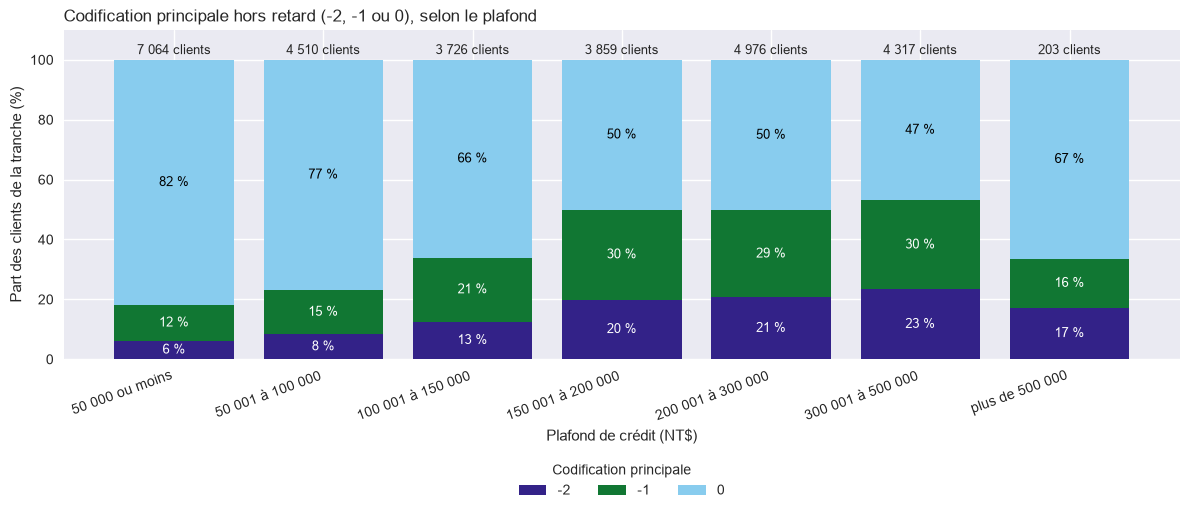

Comment lire : chaque barre fait 100 % des clients de la tranche de plafond ; la couleur donne la codification qu'ils reçoivent le plus souvent quand ils ne sont pas en retard (les mois en retard sont ignorés).
   Rappel du sens (page 3.3) : -1 = facture payée à temps, -2 = crédit non utilisé (tout payé ou rien à payer), 0 = crédit renouvelable en cours.
   Codification 0 : 82 % des clients aux plafonds de 50 000 NT$ ou moins, 47 % entre 300 001 et 500 000 NT$ ; codifications -2 ou -1 : 18 % contre 53 %.
   Clients écartés (aucun mois codifié -2, -1 ou 0) : 1341


In [232]:
# Codification principale hors retard (-2, -1 ou 0) selon la tranche de plafond (sans dpnm)
# Pour chaque client : codification la plus fréquente parmi ses seuls mois codifiés -2, -1 ou 0 (les mois en retard,
# 1 et plus, sont ignorés) ; égalité : la plus récente. Clients sans aucun mois codifié -2, -1 ou 0 : écartés
import matplotlib.pyplot as plt

COULEURS_SAINES = {'-2': '#332288', '-1': '#117733', '0': '#88CCEE'}
codes = df[[f'PAY_{n}' for n in range(1, 7)]]           # de PAY_1 (septembre, le plus récent) à PAY_6


def principale_hors_retard(ligne):
    sains = ligne[ligne <= 0]
    if sains.empty:
        return None
    comptes = sains.value_counts()
    return str(int(next(v for v in sains if comptes[v] == comptes.max())))


principale = codes.apply(principale_hors_retard, axis=1)
bornes = [0, 50_000, 100_000, 150_000, 200_000, 300_000, 500_000, np.inf]
noms = ['50 000 ou moins', '50 001 à 100 000', '100 001 à 150 000', '150 001 à 200 000',
        '200 001 à 300 000', '300 001 à 500 000', 'plus de 500 000']
tranche_plafond = pd.cut(df['LIMIT_BAL'], bornes, labels=noms)

parts = (pd.crosstab(tranche_plafond, principale, normalize='index') * 100).reindex(index=noms, columns=list(COULEURS_SAINES), fill_value=0)
clients = principale.notna().groupby(tranche_plafond, observed=False).sum().reindex(noms)

fig, ax = plt.subplots(figsize=(12, 5.5))
bas = np.zeros(len(parts))
for c, couleur in COULEURS_SAINES.items():
    ax.bar(noms, parts[c], bottom=bas, color=couleur, label=c)
    for x, (b, v) in enumerate(zip(bas, parts[c])):
        if v >= 5:
            ax.text(x, b + v / 2, f'{v:.0f} %', ha='center', va='center', fontsize=9, color='white' if c != '0' else 'black')
    bas += parts[c].to_numpy()
for x, n in enumerate(clients):
    ax.text(x, 101, f'{int(n):,} clients'.replace(',', ' '), ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, 110)
ax.set_ylabel('Part des clients de la tranche (%)')
ax.set_xlabel('Plafond de crédit (NT$)')
ax.set_title('Codification principale hors retard (-2, -1 ou 0), selon le plafond', loc='left')
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend(title='Codification principale', ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.28), frameon=False)
plt.tight_layout()
plt.show()

print("Comment lire : chaque barre fait 100 % des clients de la tranche de plafond ; la couleur donne la codification qu'ils "
      "reçoivent le plus souvent quand ils ne sont pas en retard (les mois en retard sont ignorés).")
print("   Rappel du sens (page 3.3) : -1 = facture payée à temps, -2 = crédit non utilisé (tout payé ou rien à payer), "
      "0 = crédit renouvelable en cours.")
print(f"   Codification 0 : {parts.loc[noms[0], '0']:.0f} % des clients aux plafonds de 50 000 NT$ ou moins, "
      f"{parts.loc['300 001 à 500 000', '0']:.0f} % entre 300 001 et 500 000 NT$ ; "
      f"codifications -2 ou -1 : {parts.loc[noms[0], ['-2', '-1']].sum():.0f} % contre {parts.loc['300 001 à 500 000', ['-2', '-1']].sum():.0f} %.")
print(f"   Clients écartés (aucun mois codifié -2, -1 ou 0) : {int(principale.isna().sum())}")


le montant du plafond ne semble avoir aucun impact sur la codification de la banque  
néanmoins les crédits renouvelables semble plus présents sur les plus petits plafonds

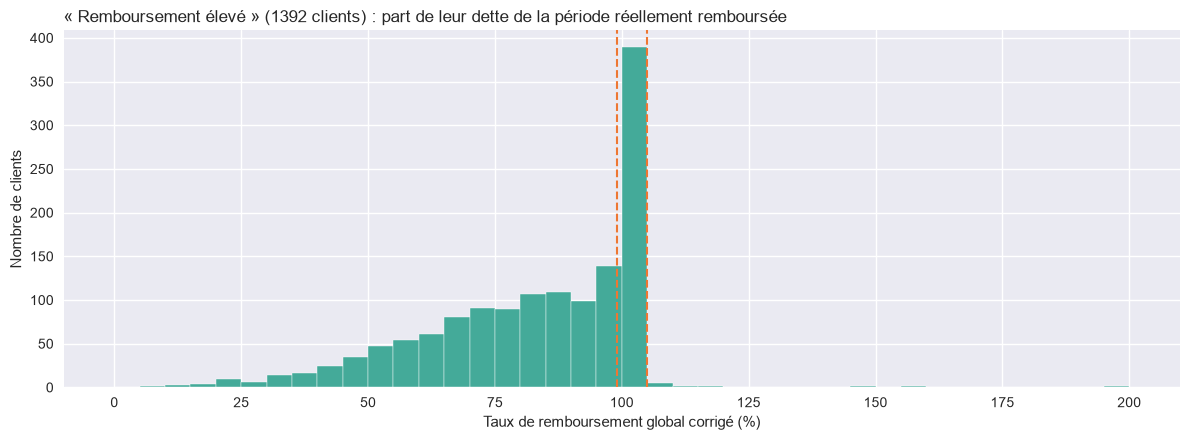

Comment lire : chaque barre compte les clients du « Remboursement élevé » selon ce qu'ils ont remboursé sur toute la période,
   rapporté à ce qu'ils devaient (avances dépensées ensuite non comptées). Entre les pointillés (99 à 105 %), le client a tout remboursé.

Clients du « Remboursement élevé » par tranche de taux corrigé (lignes) et codification la plus fréquente (colonnes) :


Codification la plus fréquente,-2,-1,0,1 ou plus,Total,dont avec au moins un retard (2 et plus)
Taux global corrigé,,,,,,
30 % ou moins,0,1,24,0,25,5
30 à 50 %,2,6,78,3,89,19
50 à 70 %,4,14,210,14,242,46
70 à 90 %,9,38,338,12,397,79
90 à 99 %,5,35,151,10,201,59
99 à 105 % (tout remboursé),22,169,215,20,426,114
plus de 105 %,5,0,5,2,12,6


   Tout remboursé sur la période : 426 clients (31 %), dont 191 habituellement codifiés -2 ou -1 et 127 de ceux-là sans aucun retard.
   Médiane du taux corrigé : 88 % | moins de 70 % : 26 % des clients.


In [233]:
# « Remboursement élevé » : répartition par taux de remboursement global corrigé (sans dpnm)
# Utilise type_final et taux_corrige de la cellule « méthode proposée », et les codifications d'origine du lab
import matplotlib.pyplot as plt

re = type_final == 'Remboursement élevé'
taux_re = taux_corrige[re]
codes = df[[f'PAY_{n}' for n in range(1, 7)]]
eu_retard = (codes >= 2).any(axis=1)


def plus_frequente(l):
    comptes = l.clip(upper=2).value_counts()
    return next(v for v in l.clip(upper=2) if comptes[v] == comptes.max())   # égalité : la plus récente


codif_hab = codes[re].apply(plus_frequente, axis=1).map({-2: '-2', -1: '-1', 0: '0', 1: '1 ou plus', 2: '1 ou plus'})

# 1. Histogramme du taux corrigé, par pas de 5 points
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.hist(taux_re.dropna(), bins=np.arange(0, 205, 5), color='#44AA99', edgecolor='white')
ax.axvline(99, color='#EE7733', linestyle='--', linewidth=1.5)
ax.axvline(105, color='#EE7733', linestyle='--', linewidth=1.5)
ax.set_xlabel('Taux de remboursement global corrigé (%)')
ax.set_ylabel('Nombre de clients')
ax.set_title(f"« Remboursement élevé » ({int(re.sum())} clients) : part de leur dette de la période réellement remboursée", loc='left')
plt.tight_layout()
plt.show()
print("Comment lire : chaque barre compte les clients du « Remboursement élevé » selon ce qu'ils ont remboursé sur toute la période,")
print("   rapporté à ce qu'ils devaient (avances dépensées ensuite non comptées). Entre les pointillés (99 à 105 %), le client a tout remboursé.\n")

# 2. Tableau : tranches de taux corrigé x codification habituelle, et part des clients qui ont eu un retard
tranches = pd.cut(taux_re, [-0.1, 30, 50, 70, 90, 99, 105, 200.1],
                  labels=['30 % ou moins', '30 à 50 %', '50 à 70 %', '70 à 90 %', '90 à 99 %', '99 à 105 % (tout remboursé)', 'plus de 105 %'])
tableau = pd.crosstab(tranches, codif_hab).reindex(columns=['-2', '-1', '0', '1 ou plus'], fill_value=0)
tableau['Total'] = tableau.sum(axis=1)
tableau['dont avec au moins un retard (2 et plus)'] = eu_retard[re].groupby(tranches, observed=False).sum()
print("Clients du « Remboursement élevé » par tranche de taux corrigé (lignes) et codification la plus fréquente (colonnes) :")
display(tableau.rename_axis(index='Taux global corrigé', columns='Codification la plus fréquente'))

tout = tranches == '99 à 105 % (tout remboursé)'
print(f"   Tout remboursé sur la période : {int(tout.sum())} clients ({tout.mean() * 100:.0f} %), "
      f"dont {int((tout & codif_hab.isin(['-2', '-1'])).sum())} habituellement codifiés -2 ou -1 "
      f"et {int((tout & codif_hab.isin(['-2', '-1']) & ~eu_retard[re]).sum())} de ceux-là sans aucun retard.")
print(f"   Médiane du taux corrigé : {taux_re.median():.0f} % | moins de 70 % : {(taux_re < 70).mean() * 100:.0f} % des clients.")


In [234]:
# Hors retard, les clients changent-ils souvent de codification (-2, -1, 0) d'un mois à l'autre ? (sans dpnm)
# On ne garde, pour chaque client, que ses mois codifiés -2, -1 ou 0, dans l'ordre chronologique (avril -> septembre)
codes_chrono = df[[f'PAY_{n}' for n in range(6, 0, -1)]]          # PAY_6 (avril) ... PAY_1 (septembre)


def profil_hors_retard(ligne):
    sains = ligne[ligne <= 0].to_numpy()
    if sains.size < 2:
        return pd.Series({'mois sains': sains.size, 'codifications différentes': len(set(sains)), 'changements': np.nan, 'part de la principale': np.nan})
    valeurs, nb = np.unique(sains, return_counts=True)
    return pd.Series({'mois sains': sains.size,
                      'codifications différentes': len(valeurs),
                      'changements': int((sains[1:] != sains[:-1]).sum()),        # passages d'une codification à une autre
                      'part de la principale': nb.max() / sains.size * 100})


profils = codes_chrono.apply(profil_hors_retard, axis=1)
assez = profils['mois sains'] >= 3                      # au moins 3 mois sains pour parler de stabilité
p = profils[assez]

print(f"Clients avec au moins 3 mois codifiés -2, -1 ou 0 : {int(assez.sum())} sur {len(df)}\n")
print("1. Nombre de codifications différentes utilisées hors retard (en % des clients) :")
display((p['codifications différentes'].value_counts(normalize=True).sort_index() * 100).round(1)
        .rename('% des clients').rename_axis('Codifications différentes (-2, -1, 0)').to_frame())
print("2. Nombre de changements de codification d'un mois sain au suivant (en % des clients) :")
display((p['changements'].value_counts(normalize=True).sort_index() * 100).round(1)
        .rename('% des clients').rename_axis('Changements sur la période').to_frame())

# 3. Quels changements ? Paires (codification d'un mois sain -> codification du mois sain suivant)
paires = []
for ligne in codes_chrono[assez].to_numpy():
    sains = ligne[ligne <= 0]
    paires += [f"{a} -> {b}" for a, b in zip(sains[:-1], sains[1:]) if a != b]
print("3. Les changements les plus fréquents (tous clients confondus) :")
display(pd.Series(paires).value_counts().head(6).rename('nombre de changements').rename_axis('Changement').to_frame())

print("Comment lire : 1 codification différente = le client garde toujours la même hors retard ; 0 changement = idem.")
print(f"   {(p['codifications différentes'] == 1).mean() * 100:.0f} % des clients gardent une seule codification hors retard, "
      f"{(p['changements'] >= 2).mean() * 100:.0f} % en changent au moins deux fois ; "
      f"en moyenne, la codification principale couvre {p['part de la principale'].mean():.0f} % de leurs mois sains.")


Clients avec au moins 3 mois codifiés -2, -1 ou 0 : 27406 sur 29996

1. Nombre de codifications différentes utilisées hors retard (en % des clients) :


,% des clients
"Codifications différentes (-2, -1, 0)",
1.0,69.9
2.0,26.5
3.0,3.7


2. Nombre de changements de codification d'un mois sain au suivant (en % des clients) :


,% des clients
Changements sur la période,
0.0,69.9
1.0,17.3
2.0,10.4
3.0,2.2
4.0,0.3
5.0,0.0


3. Les changements les plus fréquents (tous clients confondus) :


,nombre de changements
Changement,
0 -> -1,4400
-1 -> 0,3543
-1 -> -2,1895
-2 -> -1,1577
-2 -> 0,1109
0 -> -2,8


Comment lire : 1 codification différente = le client garde toujours la même hors retard ; 0 changement = idem.
   70 % des clients gardent une seule codification hors retard, 13 % en changent au moins deux fois ; en moyenne, la codification principale couvre 90 % de leurs mois sains.


Panel « Remboursement élevé » : 1392 clients, répartis selon leur codification hors retard (mois -2, -1, 0) :


,Clients,Taux corrigé médian (%),"Tout remboursé, 99 à 105 % (%)",Moins de 70 % remboursé (%),Avec au moins un retard (%)
Codification hors retard,,,,,
Inchangée -2,16,85.3,18.8,31.2,12.5
Inchangée -1,42,97.4,42.9,16.7,97.6
Inchangée 0,265,77.1,2.6,28.7,14.3
A changé de codification,1057,91.7,37.5,25.3,22.2
Moins de 2 mois hors retard,12,89.1,16.7,8.3,100.0


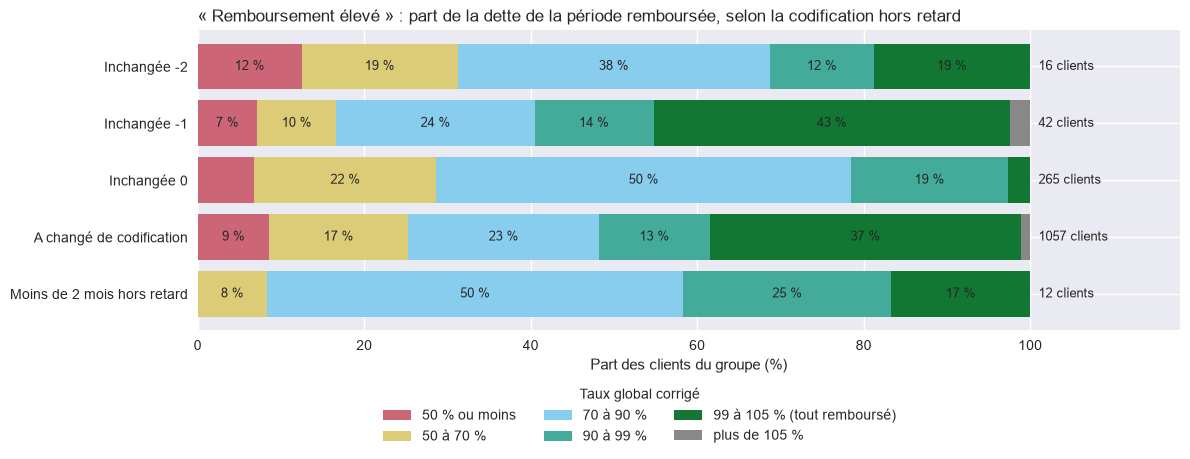

Comment lire : « Inchangée » = le client garde toujours la même codification quand il n'est pas en retard ;
   « A changé » = il en utilise au moins deux. La barre verte foncée = les clients qui ont tout remboursé sur la période.
   Inchangée -2 : 16 clients, taux médian 85 %, 19 % ont tout remboursé.
   Inchangée -1 : 42 clients, taux médian 97 %, 43 % ont tout remboursé.
   Inchangée 0 : 265 clients, taux médian 77 %, 3 % ont tout remboursé.
   A changé de codification : 1057 clients, taux médian 92 %, 38 % ont tout remboursé.
   Moins de 2 mois hors retard : 12 clients, taux médian 89 %, 17 % ont tout remboursé.


In [235]:
# Panel « Remboursement élevé » à répartir : codification hors retard inchangée (-2, -1 ou 0) ou changeante,
# et taux de remboursement global corrigé de chaque groupe (sans dpnm)
# Utilise type_final, taux_corrige (cellule « méthode proposée »), profils et principale (cellules précédentes)
import matplotlib.pyplot as plt

re = type_final == 'Remboursement élevé'
eu_retard = (df[[f'PAY_{n}' for n in range(1, 7)]] >= 2).any(axis=1)
groupe = pd.Series(np.select(
    [profils['mois sains'] < 2,
     profils['codifications différentes'] == 1,
     profils['codifications différentes'] >= 2],
    ['Moins de 2 mois hors retard',
     'Inchangée ' + principale.fillna(9).astype(int).astype(str),
     'A changé de codification'], default='?'), index=df.index)[re]
ordre = ['Inchangée -2', 'Inchangée -1', 'Inchangée 0', 'A changé de codification', 'Moins de 2 mois hors retard']
taux_re = taux_corrige[re]
tranches = pd.cut(taux_re, [-0.1, 50, 70, 90, 99, 105, 200.1],
                  labels=['50 % ou moins', '50 à 70 %', '70 à 90 %', '90 à 99 %', '99 à 105 % (tout remboursé)', 'plus de 105 %'])

# 1. Tableau : nombre de clients, taux de remboursement, retards
resume = pd.DataFrame({
    'Clients': groupe.value_counts(),
    'Taux corrigé médian (%)': taux_re.groupby(groupe).median(),
    'Tout remboursé, 99 à 105 % (%)': (tranches == '99 à 105 % (tout remboursé)').groupby(groupe).mean() * 100,
    'Moins de 70 % remboursé (%)': (taux_re < 70).groupby(groupe).mean() * 100,
    'Avec au moins un retard (%)': eu_retard[re].groupby(groupe).mean() * 100,
}).reindex(ordre).dropna(how='all').round(1)
resume['Clients'] = resume['Clients'].astype(int)
print(f"Panel « Remboursement élevé » : {int(re.sum())} clients, répartis selon leur codification hors retard (mois -2, -1, 0) :")
display(resume.rename_axis('Codification hors retard'))

# 2. Graphique : répartition du taux corrigé dans chaque groupe (chaque barre fait 100 %)
parts = (pd.crosstab(groupe, tranches, normalize='index') * 100).reindex(index=resume.index)
couleurs = ['#CC6677', '#DDCC77', '#88CCEE', '#44AA99', '#117733', '#888888']
fig, ax = plt.subplots(figsize=(12, 4.8))
gauche = np.zeros(len(parts))
for col, couleur in zip(parts.columns, couleurs):
    ax.barh(parts.index, parts[col], left=gauche, color=couleur, label=col)
    for y, (g, v) in enumerate(zip(gauche, parts[col])):
        if v >= 7:
            ax.text(g + v / 2, y, f'{v:.0f} %', ha='center', va='center', fontsize=9)
    gauche += parts[col].to_numpy()
for y, n in enumerate(resume['Clients']):
    ax.text(101, y, f'{n} clients', va='center', fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, 118)
ax.set_xticks(range(0, 101, 20))
ax.set_xlabel('Part des clients du groupe (%)')
ax.set_title('« Remboursement élevé » : part de la dette de la période remboursée, selon la codification hors retard', loc='left')
ax.legend(title='Taux global corrigé', ncol=3, loc='upper center', bbox_to_anchor=(0.45, -0.15), frameon=False)
plt.tight_layout()
plt.show()

print("Comment lire : « Inchangée » = le client garde toujours la même codification quand il n'est pas en retard ;")
print("   « A changé » = il en utilise au moins deux. La barre verte foncée = les clients qui ont tout remboursé sur la période.")
for g in resume.index:
    print(f"   {g} : {resume.loc[g, 'Clients']} clients, taux médian {resume.loc[g, 'Taux corrigé médian (%)']:.0f} %, "
          f"{resume.loc[g, 'Tout remboursé, 99 à 105 % (%)']:.0f} % ont tout remboursé.")


cette catégorie semble changer de codification beaucoup plus que le reste de la population  
elle peut englober, un crédit remboursé plus rapidement, un paiement au comptant payé partiellement, un retard régulariséc'est vrai que quelqueun 

In [236]:
# ============================================================================================================
# NOUVELLE TYPOLOGIE À TESTER (sans dpnm) : tranches de la médiane, médiane départagée par le taux global corrigé
#   0 % : Ne paie rien | ]0-3] : Client en difficulté | ]3-6] : Crédit lent | ]6-15] : Crédit rapide
#   ]15-95] : Usage mixte | ]95-105] : Paiement comptant | plus de 105 % ou une seule facture due : Autre / non mesurable
# Utilise mediane_avec, taux_base, taux_corrige, nb_factures et type_final de la cellule « méthode proposée »
# ============================================================================================================
NOUVEAUX = ['Ne paie rien', 'Client en difficulté', 'Crédit lent', 'Crédit rapide', 'Usage mixte', 'Paiement comptant', 'Autre / non mesurable']


def nouvelle_typologie(mediane):
    t = pd.Series(np.select([mediane == 0, mediane <= 3, mediane <= 6, mediane <= 15, mediane <= 95, mediane <= 105, mediane > 105],
                            NOUVEAUX, default=None), index=df.index).where(mediane >= 0).astype(object)
    t[t.notna() & (nb_factures == 1)] = 'Autre / non mesurable'          # une seule facture due : pas d'habitude
    return t


med_base, med_corrigee = mediane_avec(taux_base), mediane_avec(taux_corrige)
nouveau_base = nouvelle_typologie(med_base)          # médiane départagée par le taux global de base
nouveau = nouvelle_typologie(med_corrigee)           # médiane départagée par le taux global corrigé (proposition)

# 1. Répartition
repart = pd.DataFrame({'Clients': nouveau.value_counts(), 'Part (%)': nouveau.value_counts(normalize=True) * 100}).reindex(NOUVEAUX).round(1)
repart['Clients'] = repart['Clients'].fillna(0).astype(int)
print("1. NOUVELLE TYPOLOGIE : clients par catégorie (médiane départagée par le taux global corrigé)")
display(repart.rename_axis('Catégorie'))

# 2. Effet du départage par le taux corrigé (au lieu du taux de base), à tranches identiques
change_departage = nouveau_base.fillna('-') != nouveau.fillna('-')
print(f"\n2. EFFET DU DÉPARTAGE PAR LE TAUX CORRIGÉ : {int(change_departage.sum())} clients changent de catégorie "
      "(seuls les clients avec 2 ou 4 mois de facture et deux valeurs du milieu différentes peuvent changer) :")
for (de, vers), n in pd.Series(list(zip(nouveau_base[change_departage], nouveau[change_departage])), dtype=object).value_counts().items():
    print(f"   {de} -> {vers} : {n}")

# 3. Passages depuis la méthode précédente (type_final)
print("\n3. D'OÙ VIENNENT LES CLIENTS : méthode précédente (lignes) -> nouvelle typologie (colonnes)")
precedent = type_final.replace({'Paie plus que sa facture': 'Autre / non mesurable', 'Usage non mesurable (une seule facture due)': 'Autre / non mesurable'})
ordre_prec = ['Ne paie rien', 'Client en difficulté', 'Crédit par mensualité', 'Usage mixte', 'Remboursement élevé', 'Paiement comptant', 'Autre / non mesurable']
display(pd.crosstab(precedent, nouveau).reindex(index=ordre_prec, columns=NOUVEAUX, fill_value=0)
        .rename_axis(index='Méthode précédente', columns='Nouvelle typologie'))
print("Comment lire : chaque case compte les clients qui étaient dans la catégorie de la ligne et passent dans celle de la colonne ;")
print("   la diagonale (même nom de part et d'autre) = clients qui ne changent pas.")
sauves = (precedent == 'Paiement comptant') & (med_corrigee > 105)
print(f"   À noter : {int(sauves.sum())} clients dont la médiane dépasse 105 % étaient gardés au comptant (avance dépensée ou compensée) ;"
      " avec cette typologie, ils passent en « Autre / non mesurable ».")

# Nouvelle typologie AVEC ou SANS la condition « au moins 2 factures dues » (sans dpnm)
# Avec : un client qui n'a qu'une facture due va en « Autre / non mesurable » ; sans : il est classé par sa médiane (= son seul ratio)
# Utilise NOUVEAUX, med_corrigee et nb_factures des cellules précédentes
sans_condition = pd.Series(np.select([med_corrigee == 0, med_corrigee <= 3, med_corrigee <= 6, med_corrigee <= 15,
                                      med_corrigee <= 95, med_corrigee <= 105, med_corrigee > 105], NOUVEAUX, default=None),
                           index=df.index).where(med_corrigee >= 0).astype(object)
avec_condition = sans_condition.copy()
une_facture = avec_condition.notna() & (nb_factures == 1)
avec_condition[une_facture] = 'Autre / non mesurable'

comparaison = pd.DataFrame({'Sans la condition (clients)': sans_condition.value_counts(),
                            'Avec au moins 2 factures (clients)': avec_condition.value_counts()}).reindex(NOUVEAUX).fillna(0).astype(int)
comparaison['Différence'] = comparaison['Avec au moins 2 factures (clients)'] - comparaison['Sans la condition (clients)']
comparaison['Écart (% de la catégorie sans condition)'] = (comparaison['Différence'] / comparaison['Sans la condition (clients)'] * 100).round(1)
print(f"Clients avec une seule facture due : {int(une_facture.sum())} sur {int(sans_condition.notna().sum())} clients classés "
      f"({une_facture.sum() / sans_condition.notna().sum() * 100:.1f} %)\n")
display(comparaison.rename_axis('Catégorie'))
print("Comment lire : « Différence » = clients retirés de la catégorie par la condition (ils partent en « Autre / non mesurable »).")
print("   Où étaient les clients à une seule facture sans la condition :")
for t, n in sans_condition[une_facture].value_counts().reindex(NOUVEAUX).dropna().astype(int).items():
    print(f"      {t:22} : {n} ({n / une_facture.sum() * 100:.0f} %)")


1. NOUVELLE TYPOLOGIE : clients par catégorie (médiane départagée par le taux global corrigé)


,Clients,Part (%)
Catégorie,,
Ne paie rien,750,2.6
Client en difficulté,517,1.8
Crédit lent,11418,39.9
Crédit rapide,4527,15.8
Usage mixte,2682,9.4
Paiement comptant,7602,26.6
Autre / non mesurable,1094,3.8



2. EFFET DU DÉPARTAGE PAR LE TAUX CORRIGÉ : 26 clients changent de catégorie (seuls les clients avec 2 ou 4 mois de facture et deux valeurs du milieu différentes peuvent changer) :
   Autre / non mesurable -> Paiement comptant : 24
   Autre / non mesurable -> Usage mixte : 2

3. D'OÙ VIENNENT LES CLIENTS : méthode précédente (lignes) -> nouvelle typologie (colonnes)


Nouvelle typologie,Ne paie rien,Client en difficulté,Crédit lent,Crédit rapide,Usage mixte,Paiement comptant,Autre / non mesurable
Méthode précédente,,,,,,,
Ne paie rien,750,0,0,0,0,0,0
Client en difficulté,0,516,0,0,0,0,0
Crédit par mensualité,0,1,11416,0,0,0,0
Usage mixte,0,0,2,4527,1364,0,0
Remboursement élevé,0,0,0,0,1318,74,0
Paiement comptant,0,0,0,0,0,7528,130
Autre / non mesurable,0,0,0,0,0,0,964


Comment lire : chaque case compte les clients qui étaient dans la catégorie de la ligne et passent dans celle de la colonne ;
   la diagonale (même nom de part et d'autre) = clients qui ne changent pas.
   À noter : 130 clients dont la médiane dépasse 105 % étaient gardés au comptant (avance dépensée ou compensée) ; avec cette typologie, ils passent en « Autre / non mesurable ».
Clients avec une seule facture due : 939 sur 28590 clients classés (3.3 %)



,Sans la condition (clients),Avec au moins 2 factures (clients),Différence,Écart (% de la catégorie sans condition)
Catégorie,,,,
Ne paie rien,796,750,-46,-5.8
Client en difficulté,536,517,-19,-3.5
Crédit lent,11478,11418,-60,-0.5
Crédit rapide,4582,4527,-55,-1.2
Usage mixte,2744,2682,-62,-2.3
Paiement comptant,8250,7602,-648,-7.9
Autre / non mesurable,204,1094,890,436.3


Comment lire : « Différence » = clients retirés de la catégorie par la condition (ils partent en « Autre / non mesurable »).
   Où étaient les clients à une seule facture sans la condition :
      Ne paie rien           : 46 (5 %)
      Client en difficulté   : 19 (2 %)
      Crédit lent            : 60 (6 %)
      Crédit rapide          : 55 (6 %)
      Usage mixte            : 62 (7 %)
      Paiement comptant      : 648 (69 %)
      Autre / non mesurable  : 49 (5 %)


In [237]:
# ============================================================================================================
# TYPOLOGIE COMPLÈTE (sans dpnm), construite uniquement sur les paiements :
#   1. médiane des ratios mensuels, départagée par le taux global corrigé (avance dépensée en septembre non comptée) ;
#   2. tranches : 0 % Ne paie rien | ]0-3] Client en difficulté | ]3-6] Crédit lent | ]6-15] Crédit rapide |
#                 ]15-95] Usage mixte | ]95-105] Paiement comptant | plus de 105 % : vérification (étape 4) ;
#   3. une seule facture due : la médiane ne vaut rien, le client est classé par son taux global corrigé (mêmes tranches) ;
#   4. au-dessus de 105 % : taux global corrigé jusqu'à 105 % -> Paiement comptant (avance dépensée ou compensée),
#      sinon -> Autre (argent payé en trop encore sur la carte) ;
#   5. variante : « Autre » regroupé avec « Usage mixte ».
# Utilise df, mediane_avec, taux_corrige et nb_factures de la cellule « méthode proposée »
# ============================================================================================================
CATEGORIES = ['Ne paie rien', 'Client en difficulté', 'Crédit lent', 'Crédit rapide', 'Usage mixte', 'Paiement comptant', 'Autre']


def tranche(valeur):
    return pd.Series(np.select([valeur == 0, valeur <= 3, valeur <= 6, valeur <= 15, valeur <= 95, valeur <= 105, valeur > 105],
                               CATEGORIES, default=None), index=df.index).where(valeur >= 0).astype(object)


mediane_finale = mediane_avec(taux_corrige)

# Étapes 1 et 2 : médiane départagée, tranches
categorie = tranche(mediane_finale)
print("ÉTAPES 1-2. Médiane départagée par le taux global corrigé, puis tranches.")
print(f"   {int(categorie.notna().sum())} clients classés ; sans catégorie (aucune facture due d'avril à août) : {int(categorie.isna().sum())}\n")

# Étape 3 : une seule facture due -> classé par le taux global corrigé
une_facture = categorie.notna() & (nb_factures == 1)
par_taux = tranche(taux_corrige)
avant3 = categorie[une_facture].copy()
categorie[une_facture] = par_taux[une_facture].fillna(categorie[une_facture])
change3 = avant3 != categorie[une_facture]
print(f"ÉTAPE 3. Une seule facture due ({int(une_facture.sum())} clients) : classés par leur taux global corrigé au lieu de leur seul ratio.")
print(f"   -> {int(change3.sum())} changent de catégorie :")
for (de, vers), n in pd.Series(list(zip(avant3[change3], categorie[une_facture][change3])), dtype=object).value_counts().items():
    print(f"        {de} -> {vers} : {n}")
print()

# Étape 4 : vérification au-dessus de 105 %
au_dessus = categorie == 'Autre'
rattrapes = au_dessus & (taux_corrige <= 105)
categorie[rattrapes] = 'Paiement comptant'
print("ÉTAPE 4. Au-dessus de 105 % : on vérifie avec le taux global corrigé (tout payé sur la période / tout ce qui était dû).")
print(f"   -> sur {int(au_dessus.sum())} clients : {int(rattrapes.sum())} passent en « Paiement comptant » (avance dépensée ou compensée), "
      f"{int((au_dessus & ~rattrapes).sum())} restent en « Autre » (argent payé en trop encore sur la carte).\n")

# Bilan, et variante avec « Autre » regroupé dans « Usage mixte »
variante = categorie.replace({'Autre': 'Usage mixte'})
bilan = pd.DataFrame({'Clients': categorie.value_counts(), 'Part (%)': categorie.value_counts(normalize=True) * 100,
                      'Variante « Autre » dans « Usage mixte » (clients)': variante.value_counts()}).reindex(CATEGORIES).round(1)
bilan = bilan.fillna(0)
bilan[['Clients', 'Variante « Autre » dans « Usage mixte » (clients)']] = bilan[['Clients', 'Variante « Autre » dans « Usage mixte » (clients)']].astype(int)
print("BILAN : clients par catégorie")
display(bilan.rename_axis('Catégorie'))

# Vérification indépendante par les codifications de la banque (la typologie n'utilise aucune codification)
codifs = df[[f'PAY_{n}' for n in range(1, 7)]].clip(upper=2)
def plus_frequente(l):
    comptes = l.value_counts()
    return next(v for v in l if comptes[v] == comptes.max())
habituelle = codifs.apply(plus_frequente, axis=1).map({-2: '-2', -1: '-1', 0: '0', 1: '1 ou plus', 2: '1 ou plus'})
verif = (pd.crosstab(categorie, habituelle, normalize='index') * 100).round(1).reindex(index=CATEGORIES, columns=['-2', '-1', '0', '1 ou plus'])
print("\nVÉRIFICATION INDÉPENDANTE : codification la plus fréquente posée par la banque, selon la catégorie (en % des clients ; chaque ligne fait 100 %).")
print("   La typologie n'utilise aucune codification : si les catégories ont un sens, la banque doit les codifier différemment.")
display(verif.rename_axis(index='Catégorie', columns='Codification la plus fréquente'))


ÉTAPES 1-2. Médiane départagée par le taux global corrigé, puis tranches.
   28590 clients classés ; sans catégorie (aucune facture due d'avril à août) : 1406

ÉTAPE 3. Une seule facture due (939 clients) : classés par leur taux global corrigé au lieu de leur seul ratio.
   -> 50 changent de catégorie :
        Autre -> Paiement comptant : 34
        Paiement comptant -> Autre : 5
        Crédit rapide -> Usage mixte : 2
        Usage mixte -> Paiement comptant : 2
        Crédit lent -> Usage mixte : 2
        Ne paie rien -> Crédit rapide : 1
        Client en difficulté -> Crédit lent : 1
        Client en difficulté -> Usage mixte : 1
        Ne paie rien -> Crédit lent : 1
        Crédit lent -> Crédit rapide : 1

ÉTAPE 4. Au-dessus de 105 % : on vérifie avec le taux global corrigé (tout payé sur la période / tout ce qui était dû).
   -> sur 175 clients : 130 passent en « Paiement comptant » (avance dépensée ou compensée), 45 restent en « Autre » (argent payé en trop encore sur la

,Clients,Part (%),Variante « Autre » dans « Usage mixte » (clients)
Catégorie,,,
Ne paie rien,794,2.8,794
Client en difficulté,534,1.9,534
Crédit lent,11477,40.1,11477
Crédit rapide,4582,16.0,4582
Usage mixte,2747,9.6,2792
Paiement comptant,8411,29.4,8411
Autre,45,0.2,0



VÉRIFICATION INDÉPENDANTE : codification la plus fréquente posée par la banque, selon la catégorie (en % des clients ; chaque ligne fait 100 %).
   La typologie n'utilise aucune codification : si les catégories ont un sens, la banque doit les codifier différemment.


Codification la plus fréquente,-2,-1,0,1 ou plus
Catégorie,,,,
Ne paie rien,6.5,9.3,10.1,74.1
Client en difficulté,2.2,4.3,65.4,28.1
Crédit lent,0.5,0.4,84.2,14.9
Crédit rapide,0.5,1.1,86.4,12.1
Usage mixte,2.6,10.4,82.6,4.4
Paiement comptant,28.5,65.8,5.1,0.6
Autre,75.6,24.4,0.0,0.0
